# LDSC vs HDL Results Notebook

## Get data ready

#### Import data and libraries

In [1]:
import os
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2, venn2_circles
import seaborn as sns
from scipy.stats import skew, kurtosis
import scipy.stats as stats
from scipy.stats import fisher_exact
import numpy as np
import html
import xlsxwriter
import jinja2
import openpyxl

In [2]:
# Define paths for saving results
results_tables_dir = "/home/maria/git/SOROLLA/Results/OUTPUTS/tables/"
results_plots_dir = "/home/maria/git/SOROLLA/Results/OUTPUTS/plots/"
heritability = "heritability/"
jaccard = "jaccard/"
general = "general/"
significance = "significance/"
tests = "tests/"
comparison = "comparison/"

# Dirs paths
# Create directories if they don't exist
os.makedirs(os.path.join(results_tables_dir, heritability), exist_ok=True)
os.makedirs(os.path.join(results_tables_dir, jaccard), exist_ok=True)
os.makedirs(os.path.join(results_tables_dir, general), exist_ok=True)
os.makedirs(os.path.join(results_tables_dir, significance), exist_ok=True)
os.makedirs(os.path.join(results_tables_dir, tests), exist_ok=True)
os.makedirs(os.path.join(results_tables_dir, comparison), exist_ok=True)

os.makedirs(os.path.join(results_plots_dir, heritability), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, jaccard), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, general), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, significance), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, tests), exist_ok=True)
os.makedirs(os.path.join(results_plots_dir, comparison), exist_ok=True)

heritability_plots_dir = os.path.join(results_plots_dir, heritability)
heritability_tables_dir = os.path.join(results_tables_dir, heritability)
jaccard_plots_dir = os.path.join(results_plots_dir, jaccard)
jaccard_tables_dir = os.path.join(results_tables_dir, jaccard)
general_plots_dir = os.path.join(results_plots_dir, general)
general_tables_dir = os.path.join(results_tables_dir, general)
significance_plots_dir = os.path.join(results_plots_dir, significance)
significance_tables_dir = os.path.join(results_tables_dir, significance)
tests_plots_dir = os.path.join(results_plots_dir, tests)
tests_tables_dir = os.path.join(results_tables_dir, tests)
comparison_plots_dir = os.path.join(results_plots_dir, comparison)
comparison_tables_dir = os.path.join(results_tables_dir, comparison)

#### Load data

In [3]:
# Uncorrected and not filled last version of the file
ldsc = pd.read_csv("/home/maria/git/SOROLLA/Results/ldsc_genetic_correlation_pcorrected.csv")
hdl = pd.read_csv("/home/maria/git/SOROLLA/Results/hdl_genetic_correlation_pcorrected.csv")
ref = pd.read_csv('/home/maria/git/SOROLLA/SumStats/excell_sumstats_description.csv')


In [4]:
print("This is the dataframe showing the results from ldsc and the corrected p-values from the correlation.")
print(f"The shape of this dataframe is",{ldsc.shape})
with pd.option_context('display.max_columns', None):
    display(ldsc.head())

print("This is the dataframe showing the results from hdl and the raw p-values from the correlation.")
print(f"The shape of this dataframe is",{hdl.shape})
with pd.option_context('display.max_columns', None):
      display(hdl.head())


print("This is the reference columns from the original description_sumstats file.")
print(f"The shape of this dataframe is",{ref.shape})
with pd.option_context('display.max_columns', None):
      display(ref.head())


This is the dataframe showing the results from ldsc and the corrected p-values from the correlation.
The shape of this dataframe is {(6670, 34)}


,id_1,label_1,disease_1,type_1,selection_1,disease_subtype_1,pubmedId_1,id_2,label_2,disease_2,type_2,selection_2,disease_subtype_2,pubmedId_2,rg,se,z,p,N_num_1,Nca_val_1,Nco_val_1,N_num_2,Nca_val_2,Nco_val_2,gcov_int,gcov_int_se,h2_1,h2_1_se,h2_2,h2_2_se,p_corrected_bonf,p_bonf_rejected,p_corrected_FDR,p_FDR_rejected
0,GCST90275158,schizophrenia-M1,schizophrenia,PSY,minor,NaN,37689771,GCST90013410,bcc-1,skin cancer,CAN,subtype,basal cell,33549134,-0.0130,0.051700,-0.2519,0.8011,48523,11602.0,36921.0,392871,17416.0,375455.0,0.0004,0.0057,0.1280,0.0131,0.0317,0.0044,1.0,False,0.907609,False
1,GCST90042698,lung-cancer-family-sibling,lung cancer,CAN,subtype-family,family history,34737426,GCST90041853,prostate-cancer-5,prostate cancer,CAN,minor,NaN,34737426,0.0827,0.150000,0.5509,0.5817,356353,8126.0,348227.0,208808,5796.0,203012.0,-0.0028,0.0045,0.0043,0.0014,0.0180,0.0029,1.0,False,0.763148,False
2,GCST90137411,bcc-2,skin cancer,CAN,subtype,basal cell,36496446,GCST90137411,bcc-2,skin cancer,CAN,subtype,basal cell,36496446,1.0000,0.000002,453429.6142,0.0000,307684,20791.0,286893.0,307684,20791.0,286893.0,0.9758,0.0235,0.0697,0.0121,0.0697,0.0121,0.0,True,0.000000,True
3,GCST90011816,cervical-cancer-2,cervical cancer,CAN,main,NaN,32887889,GCST90013410,bcc-1,skin cancer,CAN,subtype,basal cell,33549134,0.0549,0.082900,0.6613,0.5084,416913,6563.0,410350.0,392871,17416.0,375455.0,0.0363,0.0055,0.0089,0.0025,0.0315,0.0044,1.0,False,0.709272,False
4,GCST90042843,anxiety-treatment-1,anxiety,PSY,subtype,treatment,34737426,GCST90271619,partial-epilepsy-2,epilepsy,NEU,subtype,partial,37653029,-0.1741,0.133000,-1.3089,0.1906,123823,16124.0,107699.0,48214,5778.0,42436.0,0.0082,0.0071,0.0383,0.0049,0.0468,0.0111,1.0,False,0.375680,False


This is the dataframe showing the results from hdl and the raw p-values from the correlation.
The shape of this dataframe is {(5904, 42)}


,id_1,label_1,type_1,selection_1,disease_1,disease_subtype_1,pubmedId_1,id_2,label_2,type_2,selection_2,disease_2,disease_subtype_2,pubmedId_2,h2_1,h2_1_se,h2_2,h2_2_se,N_num_1,Nca_val_1,Nco_val_1,N_num_2,Nca_val_2,Nco_val_2,gcov,gcov_se,rg,se,p,output_file,output_file_path,SNP_rm_GWAS1_Nmiss,SNP_rm_GWAS2_Nmiss,SNP_RP_GWAS1_TOTAL,SNP_RP_GWAS1_PERC,SNP_RP_GWAS2_TOTAL,SNP_RP_GWAS2_PERC,p_corrected_bonf,p_bonf_rejected,missing_p,p_corrected_FDR,p_FDR_rejected
0,GCST004744,adenocarcinoma-lung,CAN,subtype,lung cancer,adenocarcinoma,28604730,GCST90137412,squamous-carcinoma,CAN,subtype,skin cancer,squamous cell,36496446,0.0320,0.0079,0.0592,0.0050,66756,11273.0,55483.0,294294,7402.0,286892.0,0.0203,0.0030,0.4668,0.0852,4.240000e-08,GCST004744_adenocarcinoma-lung_GCST90137412_sq...,/gpfs/projects/bsc02/mflores/gencor/Results/HD...,0,0,972817,1029876,907187,1029876,0.000283,True,False,2.314304e-07,True
1,GCST90042685,intestinal-cancer-mother,CAN,subtype-family,intestinal cancer,family history,34737426,GCST004750,lung-cancer-squamous,CAN,subtype,lung cancer,squamous cell,28604730,0.0043,0.0009,0.0227,0.0083,417208,21763.0,395445.0,63053,7426.0,55627.0,0.0044,0.0019,0.4506,0.2240,4.420000e-02,GCST90042685_intestinal-cancer-mother_GCST0047...,/gpfs/projects/bsc02/mflores/gencor/Results/HD...,0,0,1029867,1029876,971756,1029876,1.000000,False,False,1.082681e-01,False
2,GCST002245,alzheimers-late-onset-4,NEU,minor,alzheimer's disease,NaN,24162737,GCST90271613,partial-epilepsy-1,NEU,subtype,epilepsy,partial,37653029,0.0366,0.0143,0.1216,0.0106,55134,17008.0,37154.0,57375,14939.0,42436.0,0.0167,0.0051,0.2500,0.1024,1.470000e-02,GCST002245_alzheimers-late-onset-4_GCST9027161...,/gpfs/projects/bsc02/mflores/gencor/Results/HD...,0,336,1008231,1029876,836400,1029876,1.000000,False,False,4.163439e-02,True
3,GCST90435919,headache-disorder-1,NEU,main,headache disorder,NaN,30104761,GCST004744,adenocarcinoma-lung,CAN,subtype,lung cancer,adenocarcinoma,28604730,0.0058,0.0010,0.0320,0.0079,406671,7891.0,398780.0,66756,11273.0,55483.0,0.0032,0.0019,0.2304,0.1454,1.130000e-01,GCST90435919_headache-disorder-1_GCST004744_ad...,/gpfs/projects/bsc02/mflores/gencor/Results/HD...,0,0,1029738,1029876,972817,1029876,1.000000,False,False,2.370157e-01,False
4,GCST90128471-all,SCZ-PGC-2022-all,PSY,main,schizophrenia,NaN,35396580,GCST90239856,uterine-leiomyoma-2,CAN,minor,uterus cancer,benign,36726022,0.3665,0.0092,0.0201,0.0021,130644,53386.0,77258.0,367903,38466.0,329437.0,0.0021,0.0022,0.0242,0.0252,3.370000e-01,GCST90128471-all_SCZ-PGC-2022-all_GCST90239856...,/gpfs/projects/bsc02/mflores/gencor/Results/HD...,0,0,1029721,1029876,1016163,1029876,1.000000,False,False,5.432069e-01,False


This is the reference columns from the original description_sumstats file.
The shape of this dataframe is {(115, 33)}


,type,selection,title,pubmedId,efoTraits,disease,disease_subtype,label,condition_label,summaryStatistics,id,filename,Ancestry,ref_genome,snp,a1,a2,frq,FRQ_U,FRQ_A,z,b,OR,se,p,N_col,N_num,Nca_col,Nca_val,Nco_col,Nco_val,INFO,ignore
0,NEU,subtype-family,"Genome-wide meta-analysis, fine-mapping and in...",33589840,alzheimer's disease,alzheimer's disease,family history,alzheimers-disease-family-history,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,GCST90012878,GCST90012878.tsv.gz,European,GRCh37,variant_id,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,408942,NaN,53042.0,NaN,355900.0,INFO,SNP_ID
1,NEU,main,Genetic meta-analysis of diagnosed Alzheimer's...,30820047,late-onset Alzheimers disease,alzheimer's disease,NaN,alzheimers-late-onset-1,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,GCST007511,GCST007511.txt,European,GRCh37,MarkerName,Effect_allele,Non_Effect_allele,NaN,NaN,NaN,NaN,Beta,NaN,SE,Pvalue,NaN,63926,NaN,21982.0,NaN,41944.0,NaN,NaN
2,NEU,minor,"Meta-analysis of 74,046 individuals identifies...",24162737,Alzheimer disease,alzheimer's disease,NaN,alzheimers-late-onset-4,ALZ,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,GCST002245,GCST002245.zip,European,GRCh37,MarkerName,Effect_allele,Non_Effect_allele,NaN,NaN,NaN,NaN,Beta,NaN,SE,Pvalue,NaN,55134,NaN,17008.0,NaN,37154.0,NaN,NaN
3,NEU,main,Common and rare variant association analyses i...,34873335,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-1,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,GCST90027164,GCST90027164.tsv.gz,European,GRCh37,rsid,effect_allele,other_allele,effect_allele_frequency,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,138086,NaN,27205.0,NaN,110881.0,NaN,NaN
4,NEU,minor,Genome-wide association analyses identify new ...,27455348,amyotrophic lateral sclerosis,amyotrophic lateral sclerosis,NaN,lateral-sclerosis-2,SCLE,http://ftp.ebi.ac.uk/pub/databases/gwas/summar...,GCST004692,GCST004692.tsv.gz,European,GRCh37,variant_id,effect_allele,other_allele,freq,NaN,NaN,NaN,beta,NaN,standard_error,p_value,NaN,36052,NaN,12577.0,controls,23475.0,NaN,NaN


In [5]:
ldsc.columns

Index(['id_1', 'label_1', 'disease_1', 'type_1', 'selection_1',
       'disease_subtype_1', 'pubmedId_1', 'id_2', 'label_2', 'disease_2',
       'type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2', 'rg', 'se',
       'z', 'p', 'N_num_1', 'Nca_val_1', 'Nco_val_1', 'N_num_2', 'Nca_val_2',
       'Nco_val_2', 'gcov_int', 'gcov_int_se', 'h2_1', 'h2_1_se', 'h2_2',
       'h2_2_se', 'p_corrected_bonf', 'p_bonf_rejected', 'p_corrected_FDR',
       'p_FDR_rejected'],
      dtype='object')

In [6]:
labels_hdl_computed = set(list(hdl["label_1"].unique())+list(hdl["label_2"].unique()))
# Print how many unique labels we have in total
print(f"We have {len(labels_hdl_computed)} unique labels in total in HDL.")

We have 109 unique labels in total in HDL.


### Create new dfs

In [7]:
ldsc["Category"] = ldsc.apply(lambda row:"Intra" if row["type_1"]==row["type_2"] else "Inter", axis=1)
print(f"Number per: {ldsc["Category"].value_counts()}")
ldsc["Polarity"] = ldsc.apply(lambda row:"Positive" if row["rg"]>0 else "Negative", axis=1)
print(f"Number per: {ldsc["Polarity"].value_counts()}")
ldsc["Pair"] = ldsc.apply(lambda row: f'{"-".join(sorted([row["type_1"], row["type_2"]]))}', axis=1)
print(f"Number per: {ldsc["Pair"].value_counts()}")

Number per: Category
Inter    4092
Intra    2578
Name: count, dtype: int64
Number per: Polarity
Positive    4908
Negative    1762
Name: count, dtype: int64
Number per: Pair
CAN-PSY    2346
CAN-CAN    1326
PSY-PSY    1081
CAN-NEU     918
NEU-PSY     828
NEU-NEU     171
Name: count, dtype: int64


In [8]:
ldsc_corr = ldsc[['id_1', 'label_1', 'type_1', 'disease_1','selection_1','disease_subtype_1', 'pubmedId_1',
				  'id_2', 'label_2', 'disease_2','type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2',
				  'rg', 'se', 'z', 'p','p_corrected_bonf', 'p_bonf_rejected', 'p_corrected_FDR', 'p_FDR_rejected',
				  'Category', 'Polarity','Pair']]
ldsc_heritability = ldsc[['id_1', 'label_1', 'id_2', 'label_2', 'h2_1', 'h2_1_se', 'h2_2', 'h2_2_se']]

In [9]:
hdl["Category"] = hdl.apply(lambda row:"Intra" if row["type_1"]==row["type_2"] else "Inter", axis=1)
print(f"Number per: {hdl["Category"].value_counts()}")
hdl["Polarity"] = hdl.apply(lambda row:"Positive" if row["rg"]>0 else "Negative", axis=1)
print(f"Number per: {hdl["Polarity"].value_counts()}")
hdl["Pair"] = hdl.apply(lambda row: f'{"-".join(sorted([row["type_1"], row["type_2"]]))}', axis=1)
print(f"Number per: {hdl["Pair"].value_counts()}")

Number per: Category
Inter    3650
Intra    2254
Name: count, dtype: int64
Number per: Polarity
Positive    4504
Negative    1400
Name: count, dtype: int64
Number per: Pair
CAN-PSY    2162
CAN-CAN    1082
PSY-PSY    1050
CAN-NEU     752
NEU-PSY     736
NEU-NEU     122
Name: count, dtype: int64


In [10]:
hdl_corr = hdl[['id_1', 'label_1', 'type_1', 'disease_1','selection_1','disease_subtype_1', 'pubmedId_1',
				  'id_2', 'label_2', 'disease_2','type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2',
				  'rg', 'se', 'p','p_corrected_bonf', 'p_bonf_rejected', 'p_corrected_FDR', 'p_FDR_rejected',
				  'Category', 'Polarity','Pair']]
hdl_heritability = hdl[['id_1', 'label_1', 'id_2', 'label_2', 'h2_1', 'h2_1_se', 'h2_2', 'h2_2_se']]

In [11]:
ldsc_hdl = pd.merge(ldsc_corr, hdl_corr, on=['id_1', 'label_1', 'type_1', 'disease_1','selection_1','disease_subtype_1', 'pubmedId_1',
												   'id_2', 'label_2', 'disease_2','type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2','Category','Pair'], 
												   how="outer", suffixes=("_ldsc", "_hdl"), indicator=True)

print(f"The shape of the merged dataframe is {ldsc_hdl.shape}")
print(f"The names of the columns are: {ldsc_hdl.columns}")

The shape of the merged dataframe is (6670, 34)
The names of the columns are: Index(['id_1', 'label_1', 'type_1', 'disease_1', 'selection_1',
       'disease_subtype_1', 'pubmedId_1', 'id_2', 'label_2', 'disease_2',
       'type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2', 'rg_ldsc',
       'se_ldsc', 'z', 'p_ldsc', 'p_corrected_bonf_ldsc',
       'p_bonf_rejected_ldsc', 'p_corrected_FDR_ldsc', 'p_FDR_rejected_ldsc',
       'Category', 'Polarity_ldsc', 'Pair', 'rg_hdl', 'se_hdl', 'p_hdl',
       'p_corrected_bonf_hdl', 'p_bonf_rejected_hdl', 'p_corrected_FDR_hdl',
       'p_FDR_rejected_hdl', 'Polarity_hdl', '_merge'],
      dtype='object')


In [12]:
just_ldsc = ldsc_hdl[ldsc_hdl['_merge']=='left_only']
print(f"The shape of the ldsc-only dataframe is {just_ldsc.shape}")
just_hdl = ldsc_hdl[ldsc_hdl['_merge']=='right_only']
print(f"The shape of the hdl-only dataframe is {just_hdl.shape}")
ldsc_hdl_both = ldsc_hdl[ldsc_hdl['_merge']=='both']
print(f"The shape of the both dataframe is {ldsc_hdl_both.shape}")

The shape of the ldsc-only dataframe is (766, 34)
The shape of the hdl-only dataframe is (0, 34)
The shape of the both dataframe is (5904, 34)


In [13]:
ldsc_hdl_both["color"] = [
	"red" if row['rg_ldsc'] * row['rg_hdl'] < 0 and abs(row['rg_ldsc'] - row['rg_hdl']) > 0.1 else
    "purple" if abs(row["rg_ldsc"] - row["rg_hdl"]) > 0.25 else
    "orange" if row["rg_ldsc"] * row["rg_hdl"] < 0 else
    "blue" for idx, row in ldsc_hdl_both.iterrows()
]

/tmp/ipykernel_58242/418416461.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ldsc_hdl_both["color"] = [


In [14]:
ldsc_hdl_both_main = ldsc_hdl_both[(ldsc_hdl_both["selection_1"]=="main") & (ldsc_hdl_both["selection_2"]=="main")]
ldsc_hdl_both_main_significant = ldsc_hdl_both[((ldsc_hdl_both["selection_1"]=="main") & (ldsc_hdl_both["selection_2"]=="main"))&((ldsc_hdl_both["p_FDR_rejected_ldsc"]==True) | (ldsc_hdl_both["p_FDR_rejected_hdl"]==True))]
ldsc_hdl_significant_either = ldsc_hdl_both[(ldsc_hdl_both["p_FDR_rejected_ldsc"]==True) | (ldsc_hdl_both["p_FDR_rejected_hdl"]==True)]
ldsc_hdl_significant_both = ldsc_hdl_both[(ldsc_hdl_both["p_FDR_rejected_ldsc"]==True) & (ldsc_hdl_both["p_FDR_rejected_hdl"]==True)]


In [15]:
# Heritability df
h2_ldsc_hdl = pd.merge(ldsc_heritability, hdl_heritability, on=['id_1', 'label_1', 'id_2', 'label_2'], 
												   how="outer", suffixes=("_ldsc", "_hdl"), indicator=True)

print(f"The shape of the merged dataframe is {h2_ldsc_hdl.shape}")
print(f"The names of the columns are: {h2_ldsc_hdl.columns}")

The shape of the merged dataframe is (6670, 13)
The names of the columns are: Index(['id_1', 'label_1', 'id_2', 'label_2', 'h2_1_ldsc', 'h2_1_se_ldsc',
       'h2_2_ldsc', 'h2_2_se_ldsc', 'h2_1_hdl', 'h2_1_se_hdl', 'h2_2_hdl',
       'h2_2_se_hdl', '_merge'],
      dtype='object')


### Dfs for corrplot

In [16]:
singnificant_ldsc = ldsc_corr[(ldsc_corr["p_FDR_rejected"] == True)&((ldsc_corr["selection_1"] == "main")&(ldsc_corr["selection_2"] == "main"))]
singnificant_ldsc = singnificant_ldsc[['label_1','label_2', 'rg']]
singnificant_ldsc["Software"] = "LDSC"

singnificant_hdl = hdl_corr[(hdl_corr["p_FDR_rejected"] == True)&((hdl_corr["selection_1"] == "main")&(hdl_corr["selection_2"] == "main"))]
singnificant_hdl = singnificant_hdl[['label_1','label_2', 'rg']]
singnificant_hdl["Software"] = "HDL"

hdl_ldsc_shared = pd.concat([singnificant_ldsc, singnificant_hdl], ignore_index=True)
hdl_ldsc_shared.to_csv('/home/maria/git/SOROLLA/Results/hdl_ldsc_shared.csv', index=False)

excell_shared = ref[["type","disease","label"]]
excell_shared.to_csv('/home/maria/git/SOROLLA/Results/excell_shared.csv', index=False)

ldsc_hdl_both.to_csv('/home/maria/git/SOROLLA/Results/ldsc_hdl_both_joined.csv', index=False)


## Heritability

### Functions

In [19]:
def build_hierarchical_dfs(df, type_priority=None, selection_priority=None):
    """
    Build two wide tables (h2 and h2_se) from pairwise LDSC results.

    Each unique dataset label is treated as one 'trait'. For each label, we collect all
    h2 estimates observed across all pairwise runs where that label appears:
      - if the label is in label_1 -> take h2_1 and h2_1_se
      - if the label is in label_2 -> take h2_2 and h2_2_se

    Output tables are wide-form:
      rows   = repeated observations of h2 across different pairwise runs
      cols   = traits (labels), represented as a MultiIndex: (Type, Disease, Selection, Label)

    Columns are sorted by:
      1) Type     (categorical order given by type_priority)
      2) Disease  (alphabetical)
      3) Selection(categorical order given by selection_priority)
      4) Label    (alphabetical, as final tie-breaker)

    Notes
    -----
    - We normalize 'Type' to uppercase and strip spaces to ensure categorical ordering works.
    - We normalize 'Selection' to lowercase and strip spaces for the same reason.
    - Labels with no numeric h2 values after coercion are skipped (prevents empty/NaN-only columns).

    Returns
    -------
    h2_df : pd.DataFrame
        Wide table of h2 values (float), with MultiIndex columns.
    se_df : pd.DataFrame
        Wide table of h2 standard errors (float), aligned to h2_df columns.
    """
    if type_priority is None:
        type_priority = ["NEU", "CAN", "PSY"]
    if selection_priority is None:
        selection_priority = ["main", "minor", "subtype", "subtype-family"]

    # --- Required columns sanity check (fail fast with a helpful message)
    required = {
        "label_1", "label_2",
        "h2_1", "h2_2",
        "h2_1_se", "h2_2_se",
        "type_1", "type_2",
        "disease_1", "disease_2",
        "selection_1", "selection_2",
    }
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"df is missing required columns: {sorted(missing)}")

    # Collect all unique labels appearing in either side of the pairwise LDSC table
    unique_labels = pd.unique(df[["label_1", "label_2"]].values.ravel("K"))

    h2_dict = {}
    se_dict = {}
    meta_records = []

    for label in unique_labels:
        if pd.isna(label):
            continue

        mask1 = df["label_1"].eq(label)
        mask2 = df["label_2"].eq(label)

        if not (mask1.any() or mask2.any()):
            continue

        # --- Extract metadata deterministically:
        # Prefer the side where the label appears as label_1; otherwise use label_2.
        if mask1.any():
            row = df.loc[mask1].iloc[0]
            tipo = row.get("type_1", "Unknown")
            disease = row.get("disease_1", "Unknown")
            selection = row.get("selection_1", "Unknown")
        else:
            row = df.loc[mask2].iloc[0]
            tipo = row.get("type_2", "Unknown")
            disease = row.get("disease_2", "Unknown")
            selection = row.get("selection_2", "Unknown")

        # Normalize strings to make categorical ordering reliable
        tipo = str(tipo).strip().upper()
        disease = str(disease).strip()
        selection = str(selection).strip().lower()

        # --- Collect h2 and se values across all pairwise runs for this label
        h2_vals = pd.concat(
            [
                pd.to_numeric(df.loc[mask1, "h2_1"], errors="coerce"),
                pd.to_numeric(df.loc[mask2, "h2_2"], errors="coerce"),
            ],
            ignore_index=True
        ).dropna()

        se_vals = pd.concat(
            [
                pd.to_numeric(df.loc[mask1, "h2_1_se"], errors="coerce"),
                pd.to_numeric(df.loc[mask2, "h2_2_se"], errors="coerce"),
            ],
            ignore_index=True
        ).dropna()

        # Skip labels that ended up having no numeric values (prevents NaN-only columns)
        if h2_vals.empty:
            continue

        h2_dict[label] = h2_vals.tolist()
        se_dict[label] = se_vals.tolist()
        meta_records.append({"Type": tipo, "Disease": disease, "Selection": selection, "Label": label})

    if not meta_records:
        # Return empty aligned frames if nothing was collected
        empty = pd.DataFrame()
        return empty, empty

    # --- Build a metadata frame (one row per Label) and sort using explicit categorical priorities
    meta_df = pd.DataFrame(meta_records).set_index("Label")

    meta_df["Type"] = pd.Categorical(meta_df["Type"], categories=type_priority, ordered=True)
    meta_df["Selection"] = pd.Categorical(meta_df["Selection"], categories=selection_priority, ordered=True)

    meta_df = meta_df.sort_values(["Type", "Disease", "Selection", "Label"])
    ordered_labels = meta_df.index.tolist()

    # --- Build wide tables (columns in the sorted order)
    # Using Series-per-label preserves ragged lengths (pads with NaN down the rows)
    h2_df = pd.DataFrame({lab: pd.Series(h2_dict[lab], dtype="float") for lab in ordered_labels})
    se_df = pd.DataFrame({lab: pd.Series(se_dict.get(lab, []), dtype="float") for lab in ordered_labels})

    # Safety: remove columns that are all NaN (should be rare due to earlier skipping)
    h2_df = h2_df.dropna(axis=1, how="all")
    se_df = se_df.reindex(columns=h2_df.columns)

    # --- Convert sorted metadata into MultiIndex columns
    meta_df = meta_df.loc[h2_df.columns]
    meta_df.index.name = "Label"

    m_index = pd.MultiIndex.from_arrays(
        [
            meta_df["Type"].astype(str).to_numpy(),
            meta_df["Disease"].astype(str).to_numpy(),
            meta_df["Selection"].astype(str).to_numpy(),
            meta_df.index.astype(str).to_numpy(),
        ],
        names=["Type", "Disease", "Selection", "Label"]
    )

    h2_df.columns = m_index
    se_df.columns = m_index

    return h2_df, se_df

In [20]:
def add_right_margin_px(fig, ax, right_px):
    # Keep the axes position/size in pixels, but enlarge the figure canvas to the right.
    W, H = fig.get_size_inches()
    dpi = fig.dpi

    pos = ax.get_position()
    left_px   = pos.x0 * W * dpi
    bottom_px = pos.y0 * H * dpi
    width_px  = pos.width  * W * dpi
    height_px = pos.height * H * dpi

    W_new = W + right_px / dpi
    fig.set_size_inches(W_new, H, forward=True)

    ax.set_position([
        left_px / (W_new * dpi),
        bottom_px / (H * dpi),
        width_px / (W_new * dpi),
        height_px / (H * dpi),
    ])


def plot_disease_heritability_relationships(
    df,
    title_suffix="",
    output_dir="",
    output_suffix="",
    show=True,
    dpi=300,
    alpha_value=0.35,
    figsize=(24, 8),
    marker_size=80,
    label_order=None,
    xtick_fontsize=10,
    ytick_fontsize=12,
    axis_label_fontsize=16,
    title_fontsize=20,
    legend_fontsize=10,
    legend_title_fontsize=11,
):
    """
    Scatter plot of heritability values (h2_1) per disease label_1, encoding:
      - color: type_2
      - marker shape: same disease (square) vs different disease (circle)
      - marker edge: same pubmedId/PMCID (black edge) vs different (no edge)

    Parameters
    ----------
    df : pd.DataFrame
        Must contain: label_1, disease_1, disease_2, type_1, type_2, h2_1, pubmedId_1, pubmedId_2
    label_order : list[str] or None
        If provided, x-axis will follow this exact order (no sorting surprises).
    """

    df = df.copy()

    # --- Flags (robust to NaN) ---
    df["same_disease"] = (df["disease_1"].astype(str) == df["disease_2"].astype(str)).fillna(False).astype(int)

    df["same_pmcid"] = (
        df["pubmedId_1"].notna()
        & df["pubmedId_2"].notna()
        & (df["pubmedId_1"].astype(str) == df["pubmedId_2"].astype(str))
    ).astype(int)

    # --- Colors (CHANGE HERE if you want a different palette) ---
    # A slightly softer, readable palette (still distinct)
    type_colors = {
        "NEU": "#2E7D32",  # green
        "CAN": "#EF6C00",  # orange
        "PSY": "#B42AC3",  # purple
    }

    # Marker per same-disease
    disease_markers = {1: "s", 0: "o"}  # square if same disease, circle otherwise

    # Edge for same PMCID
    edge_map = {1: ("black", 1.6), 0: ("none", 0.0)}

    # --- Determine x order (critical for "same as before") ---
    if label_order is None:
        # fallback: keep first-appearance order in df (stable)
        label_order = df["label_1"].dropna().astype(str).drop_duplicates().tolist()
    else:
        # keep only labels that exist in df; preserve requested order
        present = set(df["label_1"].dropna().astype(str))
        label_order = [lab for lab in label_order if lab in present]

    x_pos = {lab: i for i, lab in enumerate(label_order)}
    df = df[df["label_1"].astype(str).isin(label_order)].copy()

    # --- Plot ---
    fig, ax = plt.subplots(figsize=figsize)

    legend_entries = {}  # label -> (color, marker, edgecolor, linewidth)

    # Group directly by the encodings we care about (simpler + no empty subsets)
    group_cols = ["label_1", "type_2", "same_disease", "same_pmcid"]
    for (lab, type2, same_dis, same_pmc), sub in df.groupby(group_cols, dropna=False, sort=False):
        lab = str(lab)
        type2 = str(type2) if type2 is not None else "Unknown"

        color = type_colors.get(type2, "gray")
        marker = disease_markers[int(same_dis)]
        edgecolor, linewidth = edge_map[int(same_pmc)]

        # Legend key
        leg_key = f"{type2} | {'Same' if same_dis else 'Diff'} disease | {'Same' if same_pmc else 'Diff'} PMCID"
        if leg_key not in legend_entries:
            legend_entries[leg_key] = (color, marker, edgecolor, linewidth)

        ax.scatter(
            x=[x_pos[lab]] * len(sub),
            y=sub["h2_1"],
            marker=marker,
            s=marker_size,
            c=color,
            edgecolors=edgecolor,
            linewidths=linewidth,
            alpha=alpha_value,
        )

    # --- X ticks: only label, in the given order ---
    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(label_order, rotation=90, ha="right", fontsize=xtick_fontsize)

    # Color x tick labels by type_1 (based on the first row for that label)
    type1_by_label = (
        df.dropna(subset=["label_1"])
          .assign(label_1=df["label_1"].astype(str))
          .groupby("label_1", sort=False)["type_1"]
          .first()
          .astype(str)
          .to_dict()
    )
    for tick in ax.get_xticklabels():
        lab = tick.get_text()
        t1 = type1_by_label.get(lab, None)
        tick.set_color(type_colors.get(str(t1), "black"))

    # --- Fix spacing on x axis (remove extra margins) ---
    ax.margins(x=0)                       # no automatic padding
    ax.set_xlim(-0.5, len(label_order)-0.5)

    # --- Labels / title sizes ---
    ax.tick_params(axis="y", labelsize=ytick_fontsize)
    ax.set_xlabel("Label", fontsize=axis_label_fontsize)
    ax.set_ylabel("Heritability (h2)", fontsize=axis_label_fontsize)

    title = "Disease Heritability Relationships"
    if title_suffix:
        title = f"{title} — {title_suffix}"
    ax.set_title(title, fontsize=title_fontsize, pad=14)

    ax.grid(True, linestyle="--", alpha=0.25)


    ### --- Manual legend (compact + stable order) ---
    # --- Three separate legends: Type (color), Disease (marker), PMID (edge) ---
    # 1) TYPE legend (colors) in fixed order
    type_order = ["NEU", "CAN", "PSY"]
    type_handles, type_labels = [], []
    for t in type_order:
        if t not in type_colors:
            continue
        type_handles.append(
            plt.Line2D([0], [0], marker="o", linestyle="",
                    markerfacecolor=type_colors[t], markeredgecolor=type_colors[t],
                    markersize=10)
        )
        type_labels.append(t)

    leg1 = ax.legend(
        type_handles, type_labels,
        title="Type",
        fontsize=legend_fontsize,
        title_fontsize=legend_title_fontsize,
        loc="upper left",
        bbox_to_anchor=(1, 1.00),
        frameon=False,
    )
    ax.add_artist(leg1)  # keep it when adding the next legends

    # 2) DISEASE legend (shapes)
    disease_handles = [
        plt.Line2D([0], [0], marker="s", linestyle="", color="black",
                markerfacecolor="black", markeredgecolor="black",
                markersize=10),
        plt.Line2D([0], [0], marker="o", linestyle="", color="black",
                markerfacecolor="black", markeredgecolor="black",
                markersize=10),
    ]
    disease_labels = ["Same", "Different"]

    leg2 = ax.legend(
        disease_handles, disease_labels,
        title="Disease",
        fontsize=legend_fontsize,
        title_fontsize=legend_title_fontsize,
        loc="upper left",
        bbox_to_anchor=(1, 0.72),
        frameon=False,
    )
    ax.add_artist(leg2)

    # 3) PMID legend (outline)
    pmid_handles = [
        plt.Line2D([0], [0], marker="o", linestyle="",
                markerfacecolor="grey", markeredgecolor="black",
                markeredgewidth=2.0, markersize=10),
        plt.Line2D([0], [0], marker="o", linestyle="",
                markerfacecolor="grey", markeredgecolor="white",
                markeredgewidth=0.0, markersize=10),
    ]
    pmid_labels = ["Same", "Different"]

    ax.legend(
        pmid_handles, pmid_labels,
        title="PMID",
        fontsize=legend_fontsize,
        title_fontsize=legend_title_fontsize,
        loc="upper left",
        bbox_to_anchor=(1, 0.50),
        frameon=False,
    )

    fig.tight_layout()
    # fig.subplots_adjust(right=1.4)

    
    # --- Save ---
    output_dir = str(output_dir) if output_dir is not None else ""
    base_name = f"heritability_relationships_{output_suffix}".rstrip("_")

    if output_dir:
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        full_path = str(Path(output_dir) / base_name)
    else:
        full_path = base_name

    fig.savefig(f"{full_path}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{full_path}.jpg", bbox_inches="tight", dpi=dpi)

    if show:
        plt.show()
    plt.close(fig)

    return {"png": f"{full_path}.png", "jpg": f"{full_path}.jpg"}

### LDSC

In [21]:
# #Get all the heritabilities for each disease considering that each disease might appear in two columns (label_1 and label_2)

# unique_labels_heritability_ldsc = {}
# unique_labels_se_ldsc = {} 

# unique_labels_ldsc = pd.unique(ldsc[["label_1", "label_2"]].values.ravel("K"))
# print(len(unique_labels_ldsc))
# # unique_labels = list(set((ldsc["label_1"].unique().tolist())+(ldsc["label_2"].unique().tolist()))) #This was my way, but it is simpler and neater the code above.

# for label in unique_labels_ldsc:
# 	label_rows_ldsc = ldsc[(ldsc["label_1"]==label)|(ldsc["label_2"]==label)]
# 	h2_1_ldsc = label_rows_ldsc[label_rows_ldsc['label_1'] == label]['h2_1']
# 	h2_2_ldsc = label_rows_ldsc[label_rows_ldsc['label_2'] == label]['h2_2']
# 	heritability_ldsc  = pd.concat([h2_1_ldsc, h2_2_ldsc])
# 	unique_labels_heritability_ldsc[label] = heritability_ldsc.tolist()

# 	se_1_ldsc = label_rows_ldsc[label_rows_ldsc['label_1'] == label]['h2_1_se']
# 	se_2_ldsc = label_rows_ldsc[label_rows_ldsc['label_2'] == label]['h2_2_se']
# 	se_ldsc  = pd.concat([se_1_ldsc, se_2_ldsc])
# 	unique_labels_se_ldsc[label] = se_ldsc.tolist()

# h2df_ldsc = pd.DataFrame.from_dict(unique_labels_heritability_ldsc, orient="index").T
# se_ldsc = pd.DataFrame.from_dict(unique_labels_se_ldsc, orient="index").T

# h2df_ldsc = h2df_ldsc.reindex(sorted(h2df_ldsc.columns), axis=1)
# se_ldsc = se_ldsc.reindex(sorted(se_ldsc.columns), axis=1)

In [22]:
h2df_ldsc, se_ldsc = build_hierarchical_dfs(ldsc)
h2df_ldsc

Type                          NEU                          \
Disease       alzheimer's disease                           
Selection                    main                   minor   
Label     alzheimers-late-onset-1 alzheimers-late-onset-4   
0                          0.0430                  0.0532   
1                          0.0534                  0.0496   
2                          0.0512                  0.0464   
3                          0.0514                  0.0531   
4                          0.0498                  0.0532   
..                            ...                     ...   
111                        0.0537                  0.0473   
112                        0.0498                  0.0576   
113                        0.0540                  0.0532   
114                        0.0535                  0.0536   
115                        0.0496                  0.0494   

Type                                                                       \
Disease                                     amyotrophic lateral sclerosis   
Selection                    subtype-family                          main   
Label     alzheimers-disease-family-history           lateral-sclerosis-1   
0                                    0.0087                        0.0338   
1                                    0.0089                        0.0343   
2                                    0.0073                        0.0341   
3                                    0.0078                        0.0350   
4                                    0.0089                        0.0349   
..                                      ...                           ...   
111                                  0.0079                        0.0341   
112                                  0.0088                        0.0346   
113                                  0.0089                        0.0342   
114                                  0.0080                        0.0340   
115                                  0.0087                        0.0346   

Type                                                           \
Disease                         epilepsy                        
Selection               minor       main              subtype   
Label     lateral-sclerosis-2 epilepsy-2 generalised-epilepsy   
0                      0.0410     0.0883               0.2405   
1                      0.0393     0.0886               0.2412   
2                      0.0402     0.0882               0.2410   
3                      0.0682     0.0885               0.2403   
4                      0.0387     0.0890               0.2407   
..                        ...        ...                  ...   
111                    0.0392     0.0883               0.2410   
112                    0.0390     0.0889               0.2409   
113                    0.0420     0.0886               0.2409   
114                    0.0395     0.0889               0.2404   
115                    0.0381     0.0896               0.2409   

Type                                                                 ...  \
Disease                                           headache disorder  ...   
Selection                                                      main  ...   
Label     partial-epilepsy-1 partial-epilepsy-2 headache-disorder-1  ...   
0                     0.0390             0.0467              0.0068  ...   
1                     0.0422             0.0461              0.0066  ...   
2                     0.0385             0.0464              0.0067  ...   
3                     0.0385             0.0461              0.0067  ...   
4                     0.0383             0.0475              0.0066  ...   
..                       ...                ...                 ...  ...   
111                   0.0388             0.0462              0.0066  ...   
112                   0.0385             0.0469              0.0068  ...   
113                   0.0379            

In [23]:
path_ldsc_se_h2 = f"{heritability_tables_dir}ldsc_h2_se.xlsx"

with pd.ExcelWriter(path_ldsc_se_h2, engine="openpyxl") as w:
    h2df_ldsc.to_excel(w, sheet_name="h2", merge_cells=True)
    se_ldsc.to_excel(w, sheet_name="se", merge_cells=True)

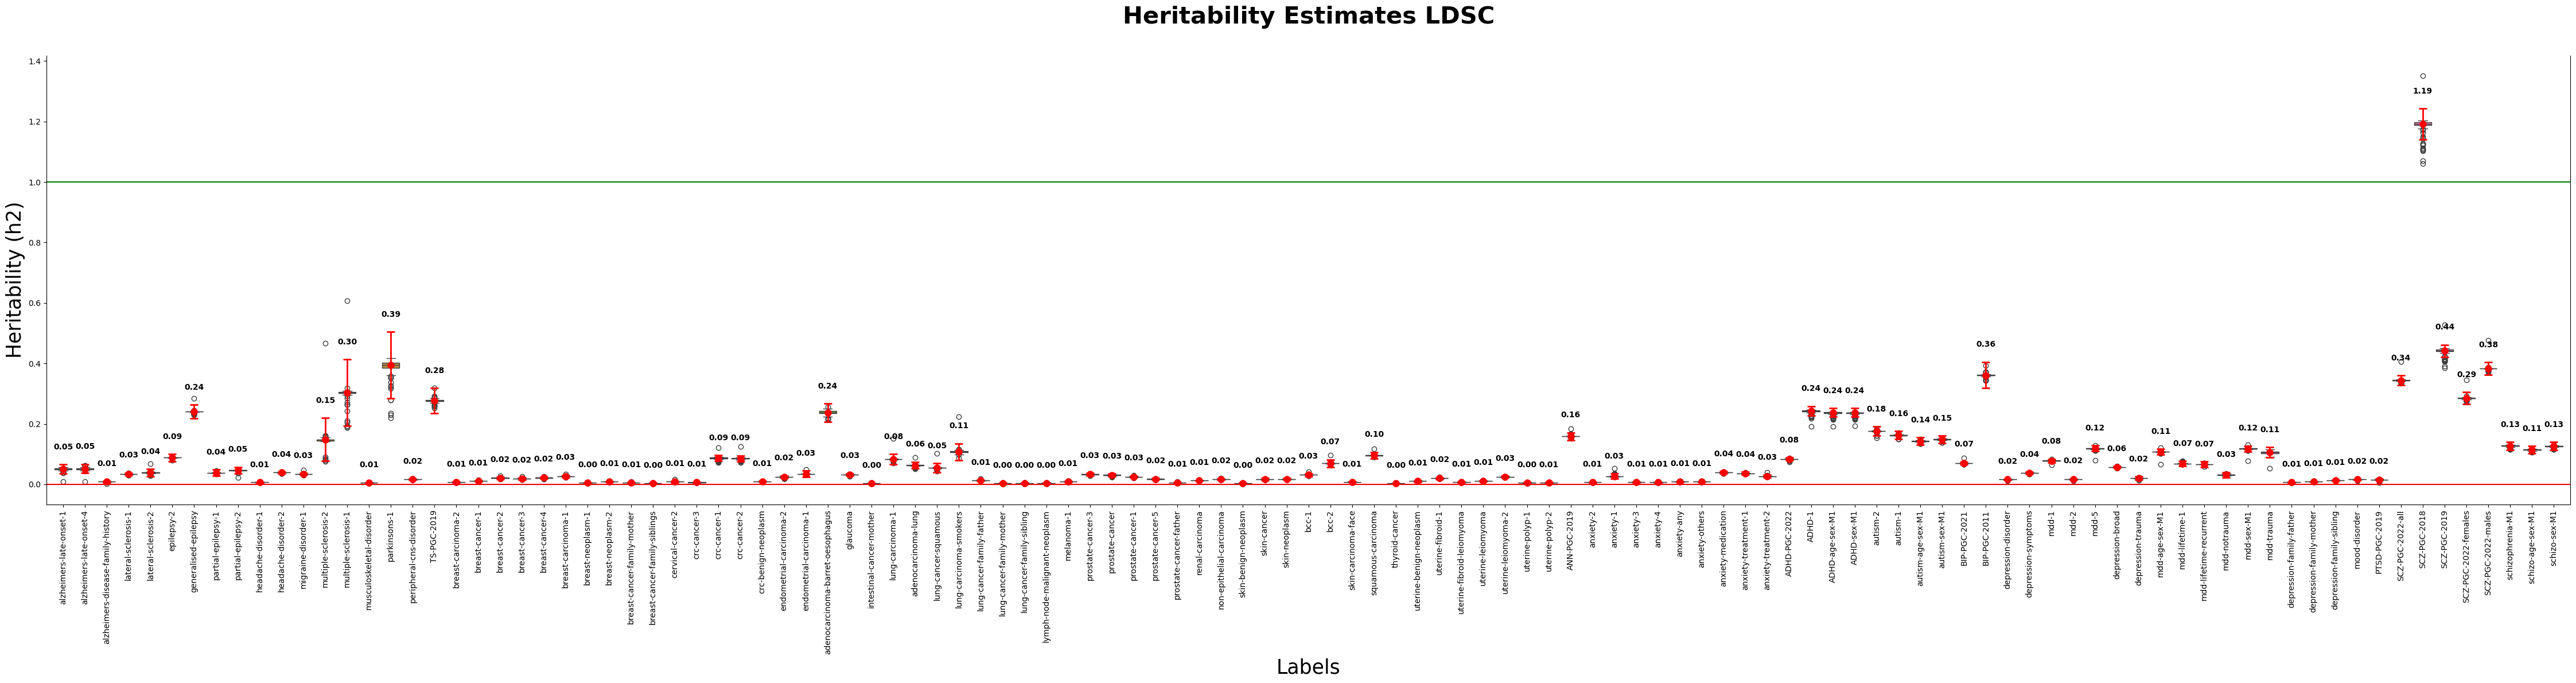

In [24]:
h2_plot = h2df_ldsc.copy()
se_plot = se_ldsc.copy()

flat_cols = [f"{t}|{d}|{s}|{lab}" for (t, d, s, lab) in h2df_ldsc.columns]
h2_plot.columns = flat_cols
se_plot.columns = flat_cols

new_labels = [f"{lab}" for (t, d, s, lab) in h2df_ldsc.columns]

plt.figure(figsize=(45, 12))

sns.boxplot(data=h2_plot)

for i, col in enumerate(h2_plot.columns):
    median_value = h2_plot[col].median()
    mean_se = se_plot[col].mean()

    plt.errorbar(i, median_value, yerr=mean_se, fmt='o', color='red',
                 markersize=8, capsize=5, capthick=2, elinewidth=2)

    median_str = f"{median_value:.2f}"
    y_pos = median_value + mean_se + 0.05
    plt.text(i, y_pos, median_str, ha='center', fontweight='bold', color='black')

plt.xticks(range(len(new_labels)), new_labels, rotation=90, fontsize=10)
plt.axhline(y=0, color='r', linestyle='-')
plt.axhline(y=1, color='green', linestyle='-')
plt.title('Heritability Estimates LDSC', fontsize=30, fontweight='bold', pad=40)
plt.xlabel('Labels', fontsize=25)
plt.ylabel('Heritability (h2)', fontsize=25)
plt.tight_layout()
plt.xlim(-0.75, len(h2_plot.columns) - 0.25)
sns.despine(right=False)

png_path = f"{heritability_plots_dir}ldsc_heritability_boxplot.png"
jpg_path = f"{heritability_plots_dir}ldsc_heritability_boxplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

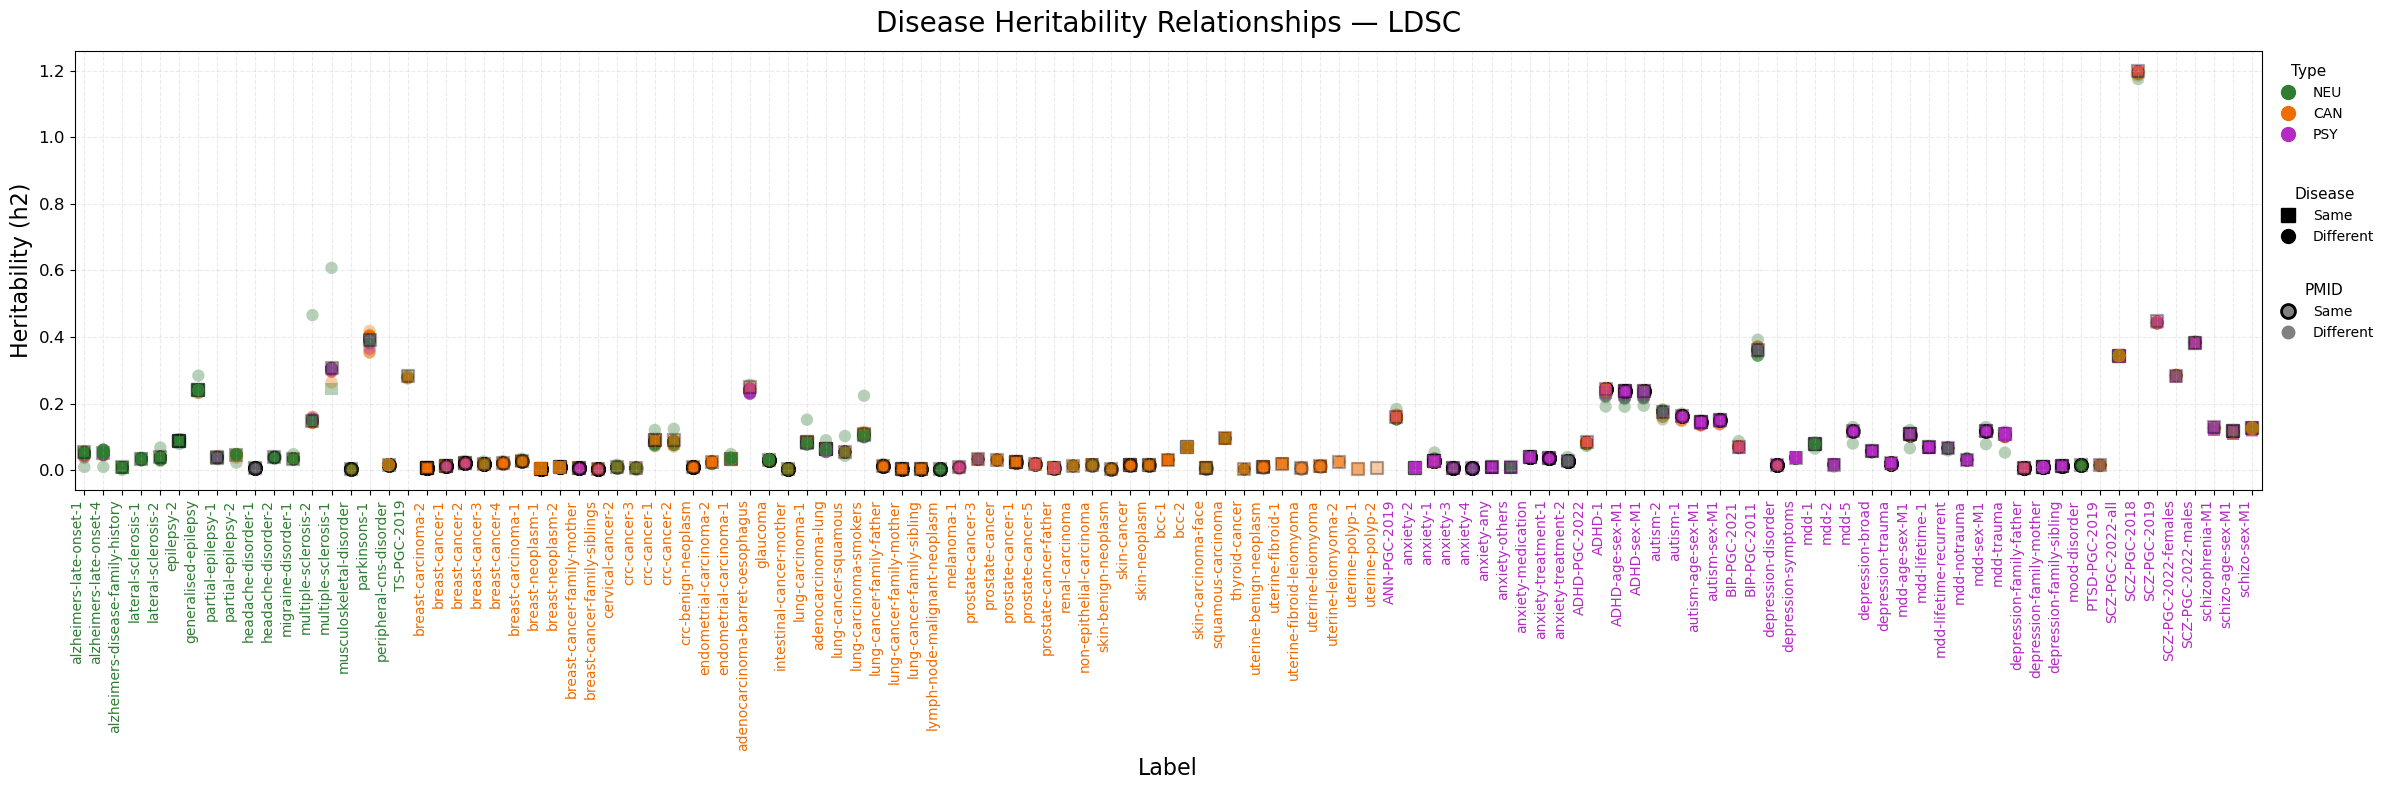

{'png': '/home/maria/git/SOROLLA/Results/OUTPUTS/plots/heritability/heritability_relationships_LDSC.png',
 'jpg': '/home/maria/git/SOROLLA/Results/OUTPUTS/plots/heritability/heritability_relationships_LDSC.jpg'}

In [25]:
label_order = [c[3] for c in h2df_ldsc.columns]

plot_disease_heritability_relationships(
    df=ldsc,
	label_order=label_order,            
    title_suffix="LDSC",
    output_dir=heritability_plots_dir, 
    output_suffix="LDSC",
    show=True
)

### HDL

In [26]:
h2df_hdl, se_hdl = build_hierarchical_dfs(hdl)
h2df_hdl

Type                          NEU                          \
Disease       alzheimer's disease                           
Selection                    main                   minor   
Label     alzheimers-late-onset-1 alzheimers-late-onset-4   
0                          0.0490                  0.0366   
1                          0.0475                  0.0366   
2                          0.0475                  0.0366   
3                          0.0475                  0.0473   
4                          0.0475                  0.0473   
..                            ...                     ...   
105                        0.0475                  0.0473   
106                        0.0475                  0.0473   
107                        0.0475                  0.0473   
108                           NaN                     NaN   
109                           NaN                     NaN   

Type                                                                       \
Disease                                     amyotrophic lateral sclerosis   
Selection                    subtype-family                          main   
Label     alzheimers-disease-family-history           lateral-sclerosis-1   
0                                    0.0171                        0.0384   
1                                    0.0171                        0.0384   
2                                    0.0127                        0.0384   
3                                    0.0171                        0.0384   
4                                    0.0171                        0.0384   
..                                      ...                           ...   
105                                  0.0171                        0.0384   
106                                  0.0171                        0.0384   
107                                  0.0171                        0.0451   
108                                     NaN                           NaN   
109                                     NaN                           NaN   

Type                                                           \
Disease                         epilepsy                        
Selection               minor       main              subtype   
Label     lateral-sclerosis-2 epilepsy-2 generalised-epilepsy   
0                      0.0279     0.1448               0.2967   
1                      0.0279     0.1448               0.2967   
2                      0.0279     0.1448               0.2967   
3                      0.0279     0.1448               0.2967   
4                      0.0279     0.1448               0.2967   
..                        ...        ...                  ...   
105                    0.0279     0.1448               0.2967   
106                    0.0279     0.1448               0.2967   
107                    0.0279     0.1448               0.2967   
108                       NaN        NaN               0.2967   
109                       NaN        NaN               0.2967   

Type                                                                 ...  \
Disease                                           headache disorder  ...   
Selection                                                      main  ...   
Label     partial-epilepsy-1 partial-epilepsy-2 headache-disorder-1  ...   
0                     0.1216             0.1186              0.0058  ...   
1                     0.1216             0.1186              0.0080  ...   
2                     0.1216             0.1186              0.0058  ...   
3                     0.1216             0.1186              0.0080  ...   
4                     0.1216             0.1186              0.0058  ...   
..                       ...                ...                 ...  ...   
105                   0.1216             0.1186              0.0080  ...   
106                   0.1216             0.1186              0.0080  ...   
107                   0.1216            

In [27]:
path_hdl_se_h2 = f"{heritability_tables_dir}hdl_h2_se.xlsx"

with pd.ExcelWriter(path_hdl_se_h2, engine="openpyxl") as w:
    h2df_hdl.to_excel(w, sheet_name="h2", merge_cells=True)
    se_hdl.to_excel(w, sheet_name="se", merge_cells=True)

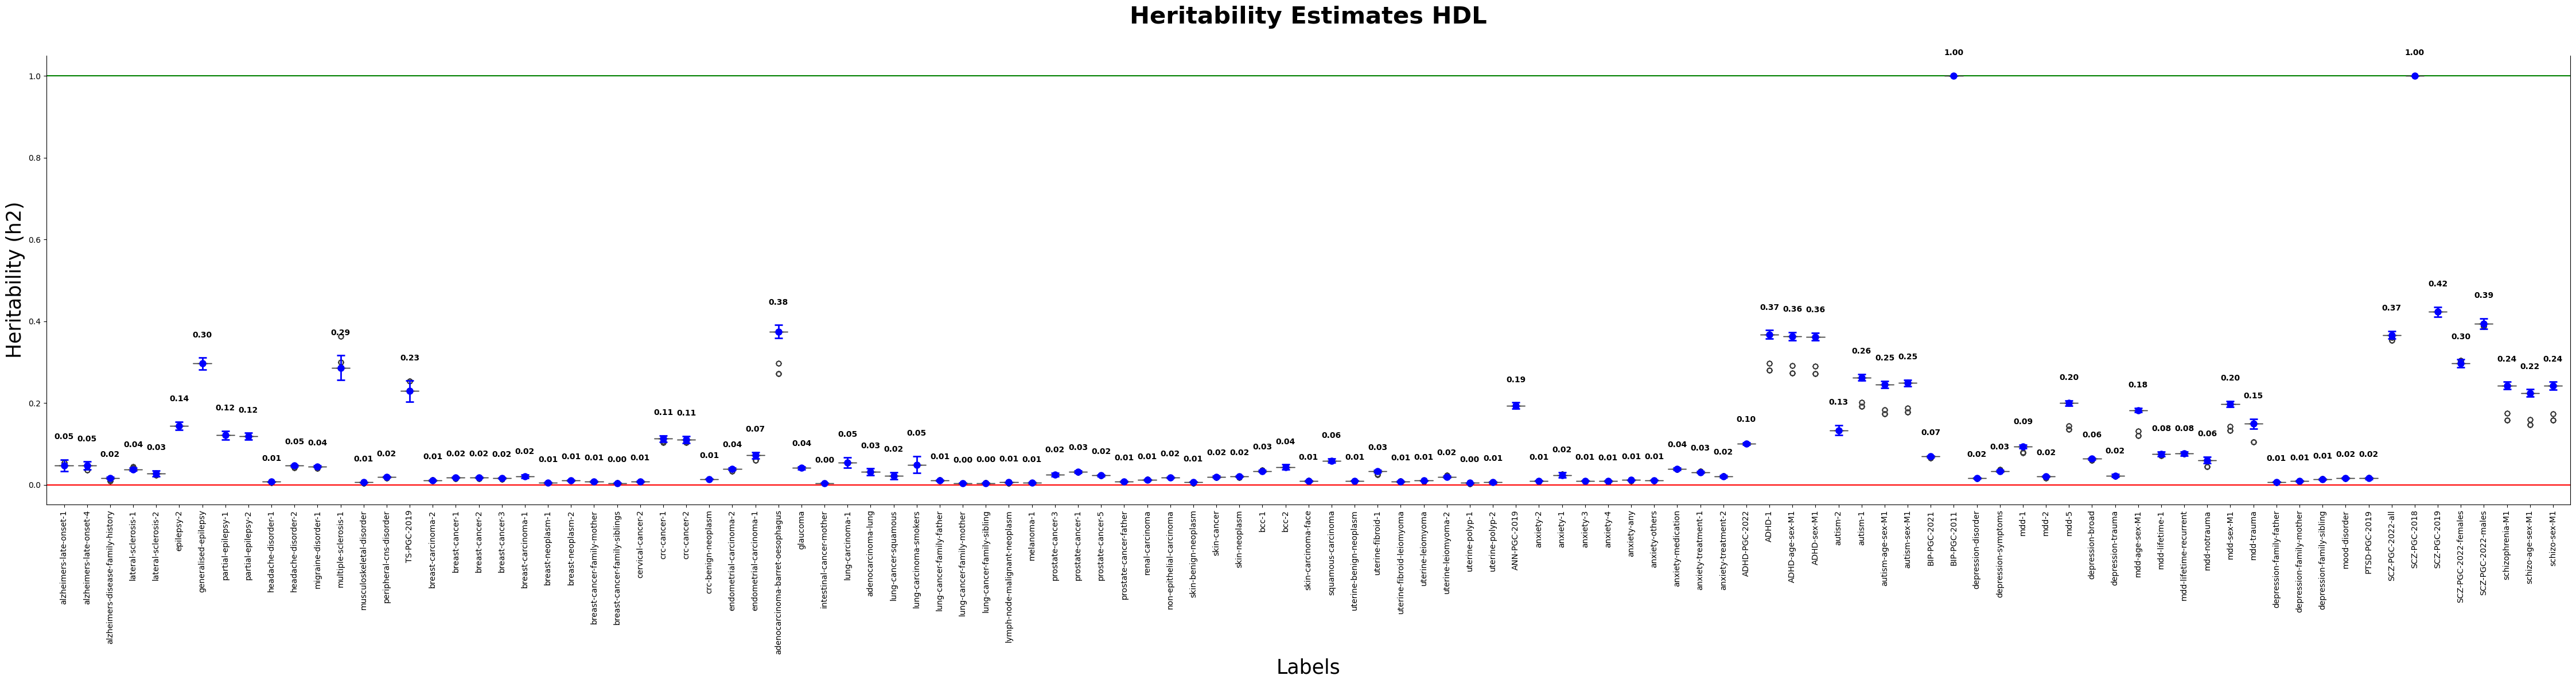

In [28]:
h2_plot = h2df_hdl.copy()
se_plot = se_hdl.copy()

flat_cols = [f"{t}|{d}|{s}|{lab}" for (t, d, s, lab) in h2df_hdl.columns]
h2_plot.columns = flat_cols
se_plot.columns = flat_cols

new_labels = [f"{lab}" for (t, d, s, lab) in h2df_hdl.columns]

plt.figure(figsize=(45, 12))

sns.boxplot(data=h2_plot)

for i, col in enumerate(h2_plot.columns):
    median_value = h2_plot[col].median()
    mean_se = se_plot[col].mean()

    plt.errorbar(i, median_value, yerr=mean_se, fmt='o', color='blue',
                 markersize=8, capsize=5, capthick=2, elinewidth=2)

    median_str = f"{median_value:.2f}"
    y_pos = median_value + mean_se + 0.05
    plt.text(i, y_pos, median_str, ha='center', fontweight='bold', color='black')

plt.xticks(range(len(new_labels)), new_labels, rotation=90, fontsize=10)
plt.axhline(y=0, color='r', linestyle='-')
plt.axhline(y=1, color='green', linestyle='-')
plt.title('Heritability Estimates HDL', fontsize=30, fontweight='bold', pad=40)
plt.xlabel('Labels', fontsize=25)
plt.ylabel('Heritability (h2)', fontsize=25)
plt.tight_layout()
plt.xlim(-0.75, len(h2_plot.columns) - 0.25)
sns.despine(right=False)

png_path = f"{heritability_plots_dir}hdl_heritability_boxplot.png"
jpg_path = f"{heritability_plots_dir}hdl_heritability_boxplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

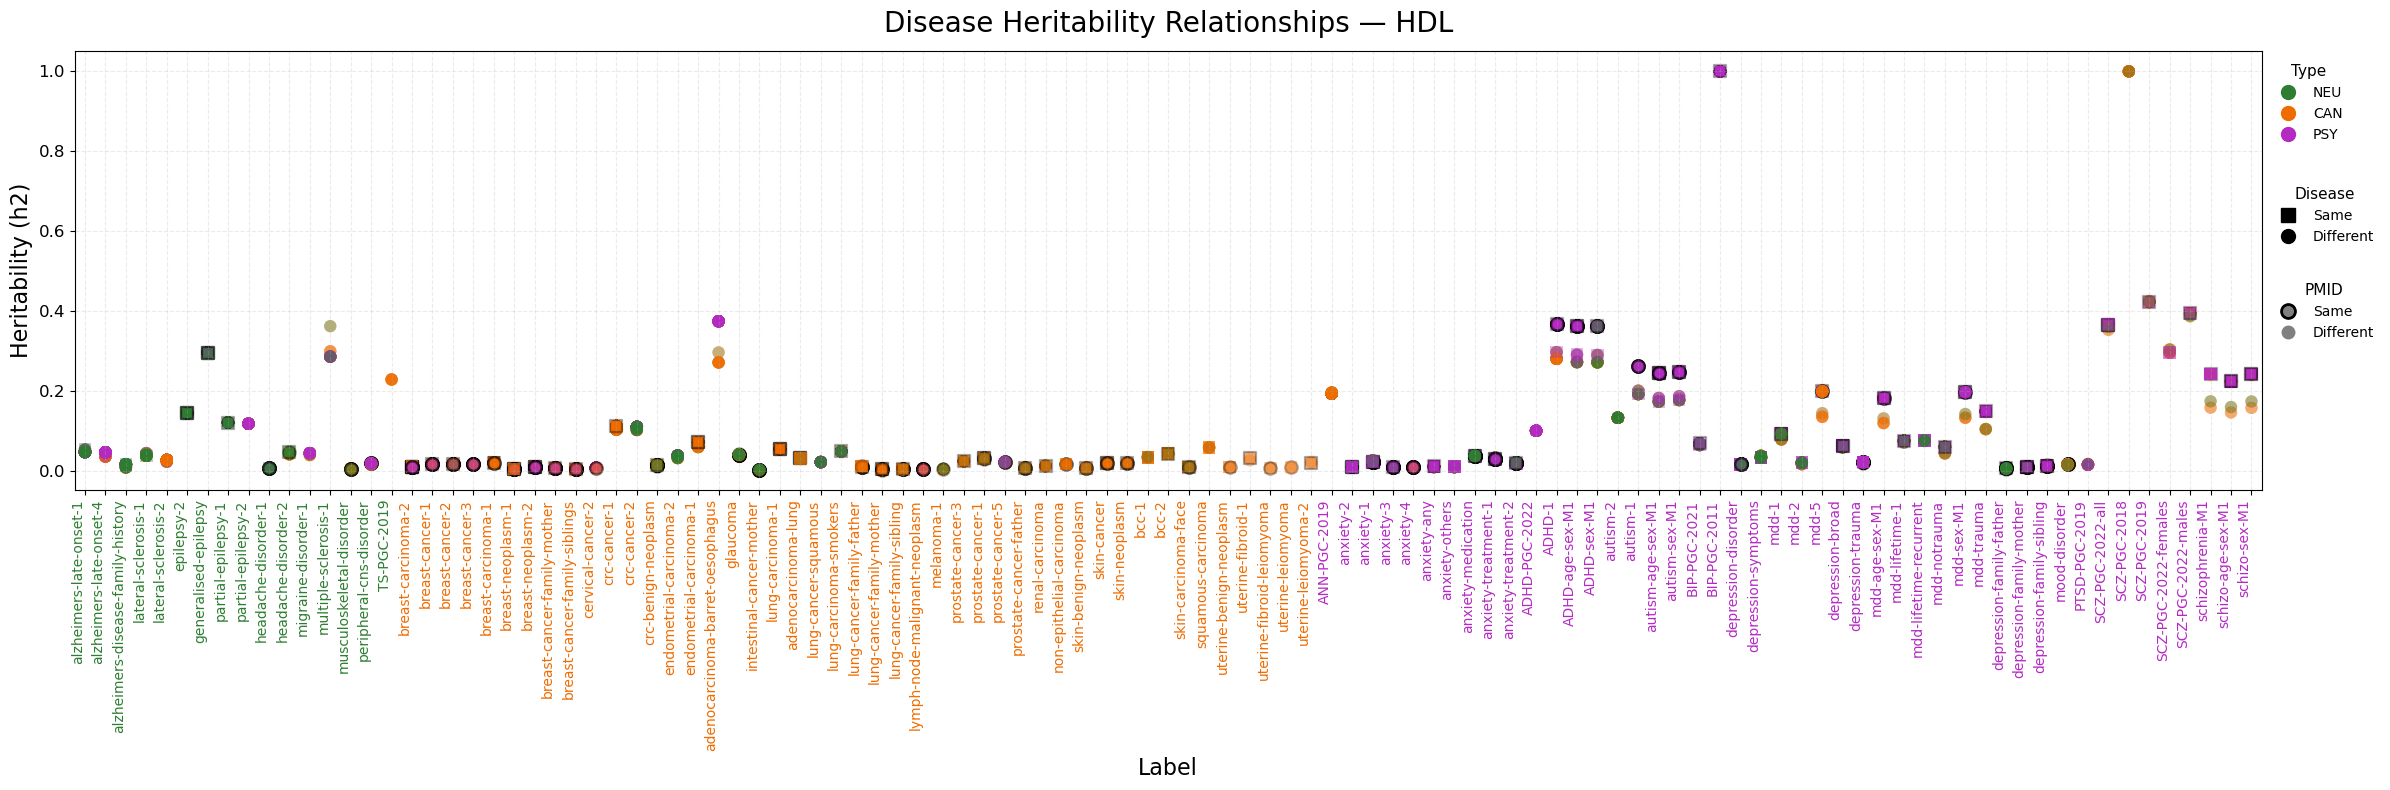

{'png': '/home/maria/git/SOROLLA/Results/OUTPUTS/plots/heritability/heritability_relationships_HDL.png',
 'jpg': '/home/maria/git/SOROLLA/Results/OUTPUTS/plots/heritability/heritability_relationships_HDL.jpg'}

In [29]:
label_order = [c[3] for c in h2df_hdl.columns]

plot_disease_heritability_relationships(
    df=hdl,
	label_order=label_order,            
    title_suffix="HDL",
    output_dir=heritability_plots_dir, 
    output_suffix="HDL",
    show=True
)

### Both

In [125]:
# h2df_ldsc_melt = h2df_ldsc.melt(var_name='Dataset', value_name='Heritability_Estimate')
# h2df_ldsc_melt = h2df_ldsc_melt.reset_index() 

# ldsc_se_melt = se_ldsc.melt(var_name='Dataset', value_name='Heritability_SE')
# ldsc_se_melt = ldsc_se_melt.reset_index()

# h2ldscse = pd.merge(h2df_ldsc_melt, ldsc_se_melt, on=['Dataset', 'index'])
# h2ldscse = h2ldscse.drop(columns=['index'])
# h2ldscse = h2ldscse.dropna()
# print(f"LDSC shape: {h2ldscse.shape}")
# h2ldscse["Origin"] = "LDSC"



In [117]:
# Asegura que están alineadas (misma estructura de columnas)
h2df_ldsc = h2df_ldsc.sort_index(axis=1)
se_ldsc   = se_ldsc.reindex(columns=h2df_ldsc.columns)

nlevels = h2df_ldsc.columns.nlevels  # aquí debería ser 4: Type,Disease,Selection,Label

h2_long = (
    h2df_ldsc
    .stack(list(range(nlevels)))              # convierte columnas MultiIndex a filas
    .rename("Heritability_Estimate")
)

se_long = (
    se_ldsc
    .stack(list(range(nlevels)))
    .rename("Heritability_SE")
)

h2ldscse = (
    pd.concat([h2_long, se_long], axis=1)     # junta h2 y se por el mismo índice
    .dropna()
    .reset_index()
)

# Pon nombres bonitos a las columnas del índice resultante
# La primera columna es tu índice original (replicate/obs). Si no te interesa, la puedes tirar.
h2ldscse.columns = ["Obs", "Type", "Disease", "Selection", "Label",
                    "Heritability_Estimate", "Heritability_SE"]

h2ldscse["Origin"] = "LDSC"
print(f"LDSC shape: {h2ldscse.shape}")
h2ldscse

/tmp/ipykernel_550848/3100372839.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(list(range(nlevels)))              # convierte columnas MultiIndex a filas


LDSC shape: (13340, 8)


/tmp/ipykernel_550848/3100372839.py:15: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(list(range(nlevels)))


,Obs,Type,Disease,Selection,Label,Heritability_Estimate,Heritability_SE,Origin
0,0,CAN,breast cancer,main,breast-carcinoma-2,0.0080,0.0015,LDSC
1,0,CAN,breast cancer,minor,breast-cancer-1,0.0111,0.0017,LDSC
2,0,CAN,breast cancer,minor,breast-cancer-2,0.0220,0.0034,LDSC
3,0,CAN,breast cancer,minor,breast-cancer-3,0.0198,0.0032,LDSC
4,0,CAN,breast cancer,minor,breast-cancer-4,0.0219,0.0036,LDSC
...,...,...,...,...,...,...,...,...
13335,115,PSY,schizophrenia,minor,SCZ-PGC-2022-females,0.2865,0.0192,LDSC
13336,115,PSY,schizophrenia,minor,SCZ-PGC-2022-males,0.3721,0.0212,LDSC
13337,115,PSY,schizophrenia,minor,schizophrenia-M1,0.1281,0.0124,LDSC
13338,115,PSY,schizophrenia,subtype,schizo-age-sex-M1,0.1164,0.0118,LDSC


In [123]:
# h2df_hdl_melt = h2df_hdl.melt(var_name='Dataset', value_name='Heritability_Estimate')
# h2df_hdl_melt = h2df_hdl_melt.reset_index()

# hdl_se_melt = se_hdl.melt(var_name='Dataset', value_name='Heritability_SE')
# hdl_se_melt = hdl_se_melt.reset_index()

# h2hdlse = pd.merge(h2df_hdl_melt, hdl_se_melt, on=['Dataset', 'index'])
# h2hdlse = h2hdlse.drop(columns=['index'])
# h2hdlse = h2hdlse.dropna() 
# print(f"HDL shape: {h2hdlse.shape}")
# h2hdlse["Origin"] = "HDL"

In [120]:
# Asegura que están alineadas (misma estructura de columnas)
h2df_hdl = h2df_hdl.sort_index(axis=1)
se_hdl   = se_hdl.reindex(columns=h2df_hdl.columns)

nlevels = h2df_hdl.columns.nlevels  # aquí debería ser 4: Type,Disease,Selection,Label

h2_long = (
    h2df_hdl
    .stack(list(range(nlevels)))              # convierte columnas MultiIndex a filas
    .rename("Heritability_Estimate")
)

se_long = (
    se_hdl
    .stack(list(range(nlevels)))
    .rename("Heritability_SE")
)

h2hdlse = (
    pd.concat([h2_long, se_long], axis=1)     # junta h2 y se por el mismo índice
    .dropna()
    .reset_index()
)

# Pon nombres bonitos a las columnas del índice resultante
# La primera columna es tu índice original (replicate/obs). Si no te interesa, la puedes tirar.
h2hdlse.columns = ["Obs", "Type", "Disease", "Selection", "Label",
                    "Heritability_Estimate", "Heritability_SE"]

h2hdlse["Origin"] = "HDL"
print(f"hdl shape: {h2hdlse.shape}")
h2hdlse

/tmp/ipykernel_550848/2166802914.py:9: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(list(range(nlevels)))              # convierte columnas MultiIndex a filas
/tmp/ipykernel_550848/2166802914.py:15: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(list(range(nlevels)))


hdl shape: (11808, 8)


,Obs,Type,Disease,Selection,Label,Heritability_Estimate,Heritability_SE,Origin
0,0,CAN,breast cancer,main,breast-carcinoma-2,0.0115,0.0014,HDL
1,0,CAN,breast cancer,minor,breast-cancer-1,0.0147,0.0019,HDL
2,0,CAN,breast cancer,minor,breast-cancer-2,0.0178,0.0017,HDL
3,0,CAN,breast cancer,minor,breast-cancer-3,0.0170,0.0016,HDL
4,0,CAN,breast cancer,minor,breast-carcinoma-1,0.0213,0.0040,HDL
...,...,...,...,...,...,...,...,...
11803,109,PSY,major depression disorder,subtype,mdd-sex-M1,0.1978,0.0063,HDL
11804,109,PSY,schizophrenia,main,SCZ-PGC-2022-all,0.3665,0.0092,HDL
11805,109,PSY,schizophrenia,minor,SCZ-PGC-2019,0.4231,0.0115,HDL
11806,109,PSY,schizophrenia,minor,schizophrenia-M1,0.2428,0.0087,HDL


In [132]:
combined_heritability = pd.concat([h2ldscse, h2hdlse], ignore_index=True)
combined_heritability.to_csv(f"{heritability_tables_dir}combined_heritability.csv", index=False)
print(f"Combined shape: {combined_heritability.shape}")

Combined shape: (25148, 8)


In [131]:
# disease_map = ref.set_index('label')['disease'].to_dict()
# combined_heritability['Disease'] = combined_heritability['Dataset'].map(disease_map)
# combined_heritability

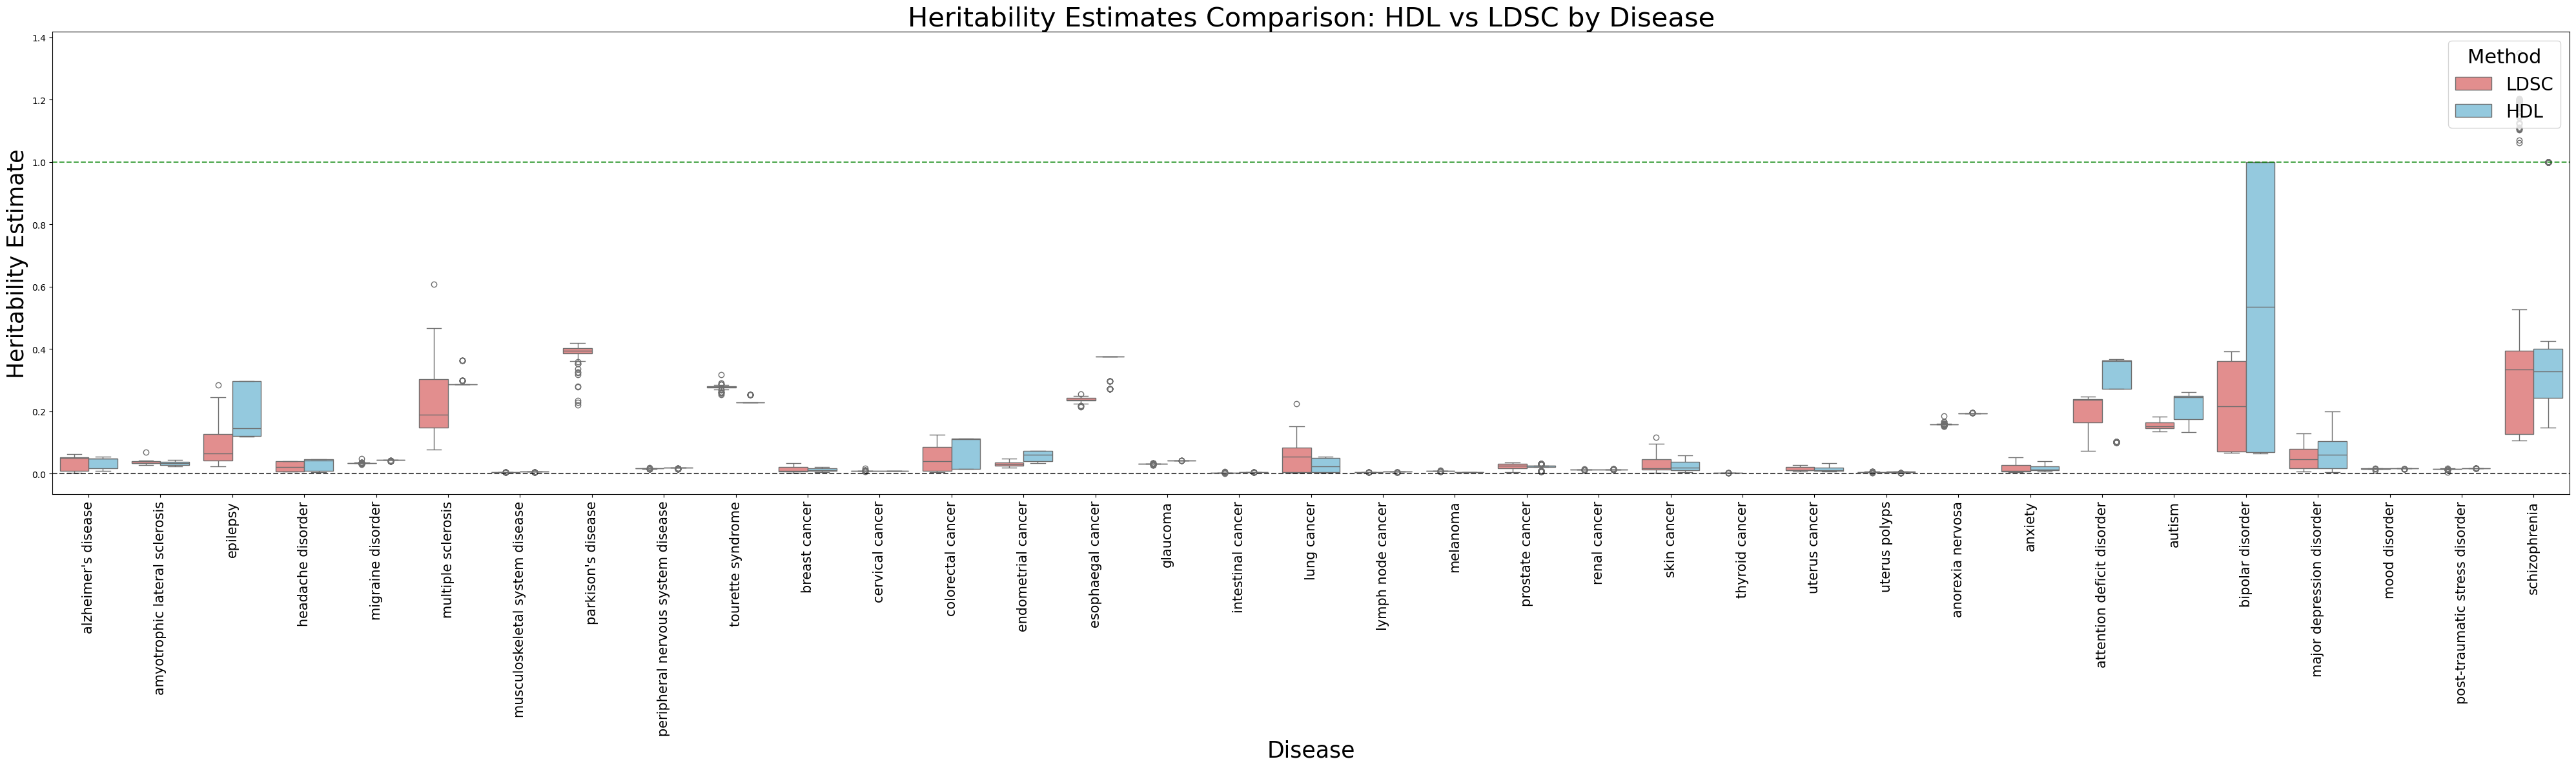

In [145]:
plt.figure(figsize=(40, 12))

sns.boxplot(data=combined_heritability, x='Disease', y='Heritability_Estimate', 
            hue='Origin', palette={'LDSC': 'lightcoral', 'HDL': 'skyblue'})

plt.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(y=1, color='green', linestyle='--', linewidth=1.5, alpha=0.7)

plt.xticks(rotation=90, fontsize=15)
plt.title('Heritability Estimates Comparison: HDL vs LDSC by Disease', fontsize=30)
plt.xlabel('Disease', fontsize=25)
plt.ylabel('Heritability Estimate', fontsize=25)
plt.legend(title='Method', fontsize=20, title_fontsize=22, loc='upper right')
plt.tight_layout()

png_path = f"{heritability_plots_dir}combined_heritability_boxplot.png"
jpg_path = f"{heritability_plots_dir}combined_heritability_boxplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

In [146]:
def create_scatter_plot(data, heritability_plots_dir):

    data['color_1'] = ['grey' if abs(row['h2_1_ldsc'] - row['h2_1_hdl']) > 0.3 else 'blue' 
                     for idx, row in data.iterrows()]
    data['color_2'] = ['orange' if abs(row['h2_2_ldsc'] - row['h2_2_hdl']) > 0.3 else 'blue' 
                     for idx, row in data.iterrows()]

    # Pearson correlation (represent in the plot with r)
    correlation1 = data['h2_1_ldsc'].corr(data['h2_1_hdl'])
    correlation2 = data['h2_2_ldsc'].corr(data['h2_2_hdl'])

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle("Heritability comparison between softwares")
    ax1.scatter(data['h2_1_ldsc'], data['h2_1_hdl'], c=data["color_1"])
    ax1.plot([0, 1], [0, 1], color='green', linestyle='--', linewidth=3.4)
    ax1.set_title(f'(r = {correlation1:.2f})', fontsize=13)
    ax1.set_xlabel('h2_1_ldsc', fontsize=14)
    ax1.set_ylabel('h2_1_hdl', fontsize=14)
    ax1.legend()
    ax1.grid(alpha=0.4)

    ax2.scatter(data['h2_2_ldsc'], data['h2_2_hdl'], c=data["color_2"])
    ax2.plot([0, 1], [0, 1], color='green', linestyle='--', linewidth=3.4)
    ax2.set_title(f'(r = {correlation2:.2f})', fontsize=13)
    ax2.set_xlabel('h2_2_ldsc', fontsize=14)
    ax2.set_ylabel('h2_2_hdl', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.4)

    plt.savefig(f"{heritability_plots_dir}ldsc_hdl_heritability_comparison.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{heritability_plots_dir}ldsc_hdl_heritability_comparison.jpg", bbox_inches='tight', dpi=300)


/tmp/ipykernel_550848/2765214513.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()
/tmp/ipykernel_550848/2765214513.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


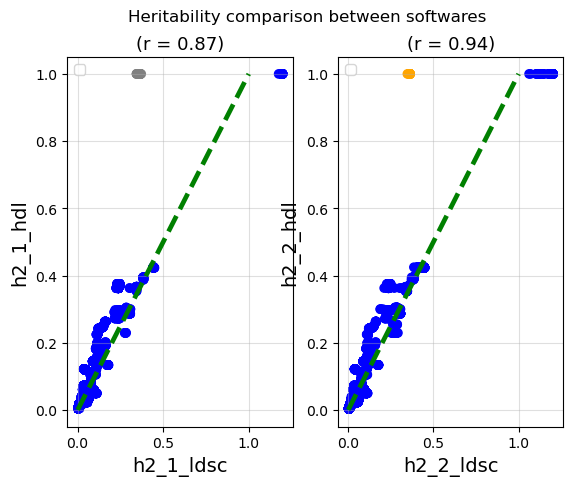

In [147]:
create_scatter_plot(h2_ldsc_hdl, heritability_plots_dir)


## General Analysis

### Category

In [141]:
# Plot categories 
cat_pairs = ldsc_hdl.groupby(['Category', 'Pair']).size().reset_index(name='Counts')
cat_pairs

,Category,Pair,Counts
0,Inter,CAN-NEU,918
1,Inter,CAN-PSY,2346
2,Inter,NEU-PSY,828
3,Intra,CAN-CAN,1326
4,Intra,NEU-NEU,171
5,Intra,PSY-PSY,1081


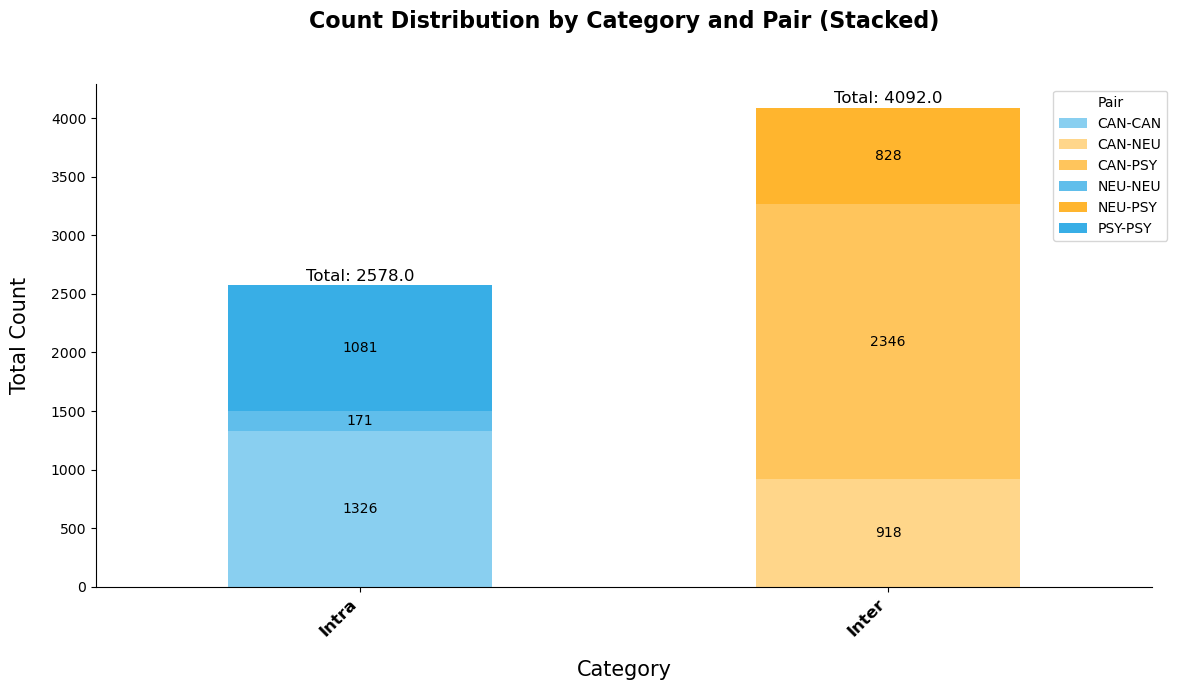

In [ ]:
### LEYENDA EN ORDEN PORFA


category_order = ['Intra', 'Inter']
cat_pairs['Category'] = pd.Categorical(cat_pairs['Category'], categories=category_order, ordered=True)


pivoted_cat_pairs = cat_pairs.pivot(
    index='Category', 
    columns='Pair', 
    values='Counts'
)

total_counts = pivoted_cat_pairs.sum(axis=1)



fig, ax = plt.subplots(figsize=(12, 7))

pivoted_cat_pairs.plot.bar(
    stacked=True, 
    ax=ax,
    color=['#89CFF0', "#FFD68A", '#FFC55C', "#60BEEB", "#FFB52E", '#38AEE6']
)

pivoted_cat_pairs = pivoted_cat_pairs.reset_index()
bars = ax.containers

for i, bar_container in enumerate(bars):
    for j, rect in enumerate(bar_container):
        height = rect.get_height()
        if height > 0:
            if i == 0:
                cumulative_height = 0
            else:
                cumulative_height = sum(bars[k][j].get_height() for k in range(i))

            x_pos = rect.get_x() + rect.get_width() / 2.0
            y_pos = cumulative_height + height / 2.0
            
            pair_name = pivoted_cat_pairs.columns[i+1]
            
            count_value = cat_pairs[
                (cat_pairs['Category'] == pivoted_cat_pairs.iloc[j]['Category']) & 
                (cat_pairs['Pair'] == pair_name)
            ]['Counts'].iloc[0]

            ax.text(
                x_pos, 
                y_pos, 
                f'{count_value}', 
                ha='center', 
                va='center', 
                color='black', 
                fontsize=10, 
                # fontweight='bold'
            )

for idx, (category, total) in enumerate(total_counts.items()):
    x_pos = ax.patches[idx].get_x() + ax.patches[idx].get_width() / 2.0
    y_pos = total + 10 
    
    ax.text(
        x_pos, 
        y_pos, 
        f'Total: {total}', 
        ha='center', 
        va='bottom', 
        fontsize=12,
        # fontweight='bold',
        color='black'
    )


plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_title('Count Distribution by Category and Pair (Stacked)', fontsize=16, fontweight='bold', pad=40)
ax.set_xlabel('Category', fontsize=15, labelpad=15)
ax.set_ylabel('Total Count', fontsize=15, labelpad=15)
ax.legend(title='Pair', bbox_to_anchor=(0.9, 1), loc='upper left')
sns.despine(ax=ax)

plt.tight_layout()

png_path = f"{general_plots_dir}category_pairs_stacked_barplot.png"
jpg_path = f"{general_plots_dir}category_pairs_stacked_barplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

### Table general data

In [ ]:
def table_categories_numbers(
    ldsc_df,
    hdl_df,
    output_dir,
    basename="table_categories_numbers",
    image_ext="png",
    max_rows_image=60,
    dpi=300,
):
    os.makedirs(output_dir, exist_ok=True)

    resultados = []

    for dataset_name, df in [("LDSC", ldsc_df), ("HDL", hdl_df)]:
        total_dataset = len(df)

        for category in ["Intra", "Inter"]:
            cat_df = df[df["Category"] == category]
            total_cat = len(cat_df)
            perc_cat = round((total_cat / total_dataset) * 100, 2) if total_dataset else 0.0

            for _, row in cat_df.iterrows():
                pair = row["Pair"]
                resultados.append(
                    {
                        "Dataset": dataset_name,
                        "Dataset total": total_dataset,
                        "Category": category,
                        "Category total": total_cat,
                        "Category percentage": perc_cat,
                        "Pair": pair,
                        "Sample size": 1,
                    }
                )

    tabla = pd.DataFrame(resultados)

    tabla_grouped = (
        tabla.groupby(
            ["Dataset", "Dataset total", "Category", "Category total", "Category percentage", "Pair"],
            dropna=False,
        )
        .agg({"Sample size": "sum"})
        .reset_index()
    )

    tabla_grouped["Category %"] = round(
        (tabla_grouped["Sample size"] / tabla_grouped["Category total"] * 100).replace([float("inf")], 0),
        2,
    ).fillna(0)

    tabla_grouped["Total %"] = round(
        (tabla_grouped["Sample size"] / tabla_grouped["Dataset total"] * 100).replace([float("inf")], 0),
        2,
    ).fillna(0)

    tabla_final = tabla_grouped.set_index(
        ["Dataset", "Dataset total", "Category", "Category total", "Category percentage", "Pair"]
    ).sort_index()

    # ---------- SAVE FILES ----------
    xlsx_path = os.path.join(output_dir, f"{basename}.xlsx")
    csv_path = os.path.join(output_dir, f"{basename}.csv")
    img_path = os.path.join(output_dir, f"{basename}.{image_ext}")

    # Excel
    tabla_final.to_excel(xlsx_path)

    # CSV (mejor con el index “expandido”)
    tabla_final.reset_index().to_csv(csv_path, index=False)

    # Image (render tabla en matplotlib)
    df_img = tabla_final.reset_index()
    if max_rows_image is not None and len(df_img) > max_rows_image:
        df_img = df_img.head(max_rows_image)

    fig_h = max(2, 0.5 * (len(df_img) + 3))
    fig_w = max(8, 0.3 * len(df_img.columns) + 12)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    table = ax.table(
        cellText=df_img.values,
        colLabels=df_img.columns,
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.2)

    plt.savefig(img_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)

    return tabla_final

In [152]:
tabla_sample_sizes_and_perc = table_categories_numbers(ldsc, hdl, output_dir=general_tables_dir, basename="categories_percentages_software")
tabla_sample_sizes_and_perc

Sample size  \
Dataset Dataset total Category Category total Category percentage Pair                   
HDL     5904          Inter    3650           61.82               CAN-NEU          752   
                                                                  CAN-PSY         2162   
                                                                  NEU-PSY          736   
                      Intra    2254           38.18               CAN-CAN         1082   
                                                                  NEU-NEU          122   
                                                                  PSY-PSY         1050   
LDSC    6670          Inter    4092           61.35               CAN-NEU          918   
                                                                  CAN-PSY         2346   
                                                                  NEU-PSY          828   
                      Intra    2578           38.65               CAN-CAN         1326   
                                                                  NEU-NEU          171   
                                                                  PSY-PSY         1081   

                                                                           Category %  \
Dataset Dataset total Category Category total Category percentage Pair                  
HDL     5904          Inter    3650           61.82               CAN-NEU       20.60   
                                                                  CAN-PSY       59.23   
                                                                  NEU-PSY       20.16   
                      Intra    2254           38.18               CAN-CAN       48.00   
                                                                  NEU-NEU        5.41   
                                                                  PSY-PSY       46.58   
LDSC    6670          Inter    4092           61.35               CAN-NEU       22.43   
                                                                  CAN-PSY       57.33   
                                                                  NEU-PSY       20.23   
                      Intra    2578           38.65               CAN-CAN       51.44   
                                                                  NEU-NEU        6.63   
                                                                  PSY-PSY       41.93   

                                                                           Total %  
Dataset Dataset total Category Category total Category percentage Pair              
HDL     5904          Inter    3650           61.82               CAN-NEU    12.74  
                                                                  CAN-PSY    36.62  
                                                                  NEU-PSY    12.47  
                      Intra    2254           38.18               CAN-CAN    18.33  
                                                                  NEU-NEU     2.07  
                                                                  PSY-PSY    17.78  
LDSC    6670          Inter    4092           61.35               CAN-NEU    13.76  
                                                                  CAN-PSY    35.17  
                                                                  NEU-PSY    12.41  
                      Intra    2578           38.65               CAN-CAN    19.88  
                                                                  NEU-NEU     2.56  
                                                                  PSY-PSY    16.21

In [154]:
html_tabla_sample_sizes_and_perc = tabla_sample_sizes_and_perc.to_html(border=0, classes="dataframe")

html_page_tabla_sample_sizes_and_perc = f"""
<html>
<head>
<style>
body {{
    font-family: "Times New Roman", serif;
    margin: 20px;
    color: #000;
    background: #fff;
}}
h2 {{
    text-align: center;
    font-size: 14pt;
    margin-bottom: 10px;
}}
table.dataframe {{
    border-collapse: collapse;
    table-layout: auto;
    width: auto;
    display: inline-table;
}}
body > table.dataframe {{
    margin: 0 auto;
}}
table.dataframe th, table.dataframe td {{
    border: 1px solid #000;
    padding: 3px 6px;
    text-align: center;
    white-space: normal;      /* permitir envolver cuando haga falta */
    word-break: break-word;   /* romper palabras largas */
    max-width: 220px;         /* límite para columnas largas */
}}
table.dataframe th {{
    background: #f0f0f0;
    font-weight: bold;
}}
table.dataframe tr:nth-child(even) {{
    background: #f9f9f9;
}}
</style>
</head>
<body>
<h1>Sample Size and Percentages of LDSC and HDL Data</h1>
{html_tabla_sample_sizes_and_perc}
</body>
</html>
"""


save_tabla_sample_sizes_and_perc_html = f"{general_tables_dir}categories_percentages_software.html"
with open(save_tabla_sample_sizes_and_perc_html, "w", encoding="utf-8") as f:
    f.write(html_page_tabla_sample_sizes_and_perc)

### Polarity

In [18]:
# Print overall polarity for both softwares and their percentages
print("Overall Polarity LDSC:")
ldsc_polarity_counts = ldsc['Polarity'].value_counts()
print(ldsc_polarity_counts)
total_ldsc = ldsc_polarity_counts.sum()
print(f"Total LDSC entries: {total_ldsc}")
for polarity, count in ldsc_polarity_counts.items():
    percentage = (count / total_ldsc * 100)
    print(f"  {polarity}: {count} ({percentage:.2f}%)")
    
print("\nOverall Polarity HDL:")
hdl_polarity_counts = hdl['Polarity'].value_counts()
print(hdl_polarity_counts)
total_hdl = hdl_polarity_counts.sum()
print(f"Total HDL entries: {total_hdl}")
for polarity, count in hdl_polarity_counts.items():
	percentage = (count / total_hdl * 100)
	print(f"  {polarity}: {count} ({percentage:.2f}%)")

Overall Polarity LDSC:
Polarity
Positive    4908
Negative    1762
Name: count, dtype: int64
Total LDSC entries: 6670
  Positive: 4908 (73.58%)
  Negative: 1762 (26.42%)

Overall Polarity HDL:
Polarity
Positive    4504
Negative    1400
Name: count, dtype: int64
Total HDL entries: 5904
  Positive: 4504 (76.29%)
  Negative: 1400 (23.71%)


In [27]:
print("Significance Polarity LDSC:")
ldsc_sig = ldsc[ldsc["p_FDR_rejected"] == True]

for polarity in ['Positive', 'Negative']:
    count_sig = len(ldsc_sig[ldsc_sig['Polarity'] == polarity])
    total_polarity = len(ldsc[ldsc['Polarity'] == polarity])
    percentage = (count_sig / total_polarity * 100) if total_polarity > 0 else 0
    print(f"  {polarity}: {count_sig} out of {total_polarity} in total ({percentage:.2f}%)")


print("\nSignificance Polarity HDL:")
hdl_sig = hdl[hdl["p_FDR_rejected"] == True]

for polarity in ['Positive', 'Negative']:
    count_sig = len(hdl_sig[hdl_sig['Polarity'] == polarity])
    total_polarity = len(hdl[hdl['Polarity'] == polarity])
    percentage = (count_sig / total_polarity * 100) if total_polarity > 0 else 0
    print(f"  {polarity}: {count_sig} out of {total_polarity} in total ({percentage:.2f}%)")

Significance Polarity LDSC:
  Positive: 1948 out of 4908 in total (39.69%)
  Negative: 92 out of 1762 in total (5.22%)

Significance Polarity HDL:
  Positive: 2247 out of 4504 in total (49.89%)
  Negative: 172 out of 1400 in total (12.29%)


#### Tables

In [367]:
cat_pol_software = pd.concat([
    ldsc.assign(Software="LDSC"), 
    hdl.assign(Software="HDL")
], ignore_index=True)

cat_pol_software_table = cat_pol_software.groupby(['Software', 'Category', 'Polarity']).size().unstack(fill_value=0)

# 2. Calcular Totales y Porcentajes
cat_pol_software_table['Total'] = cat_pol_software_table['Positive'] + cat_pol_software_table['Negative']
cat_pol_software_table['Total%'] = (cat_pol_software_table['Total'] / cat_pol_software_table['Total'].sum() * 100).map('{:.2f}%'.format)
cat_pol_software_table['Positive (%)'] = (cat_pol_software_table['Positive'] / cat_pol_software_table['Total'] * 100).map('{:.2f}%'.format)
cat_pol_software_table['Negative (%)'] = (cat_pol_software_table['Negative'] / cat_pol_software_table['Total'] * 100).map('{:.2f}%'.format)

# 3. Reordenar columnas para que sea legible en Excel
cols = ['Total', 'Total%', 'Positive', 'Positive (%)', 'Negative', 'Negative (%)']
cat_pol_software_table = cat_pol_software_table[cols]


grouped_cat_pol_software_plot_path = f"{general_tables_dir}category_polarity_distribution_summary.xlsx"
cat_pol_software_table.to_excel(grouped_cat_pol_software_plot_path)

print(f"Saved at: {grouped_cat_pol_software_plot_path}")
display(cat_pol_software_table)

Saved at: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/general/category_polarity_distribution_summary.xlsx


Polarity           Total  Total%  Positive Positive (%)  Negative Negative (%)
Software Category                                                             
HDL      Inter      3650  29.03%      2477       67.86%      1173       32.14%
         Intra      2254  17.93%      2027       89.93%       227       10.07%
LDSC     Inter      4092  32.54%      2635       64.39%      1457       35.61%
         Intra      2578  20.50%      2273       88.17%       305       11.83%

In [158]:
def table_polarities_numbers(ldsc_df, hdl_df):

    resultados = []

    for dataset_name, df in [("LDSC", ldsc_df), ("HDL", hdl_df)]:
        total_dataset = len(df)

        for polarity in ["Positive", "Negative"]:
            pol_df = df[df["Polarity"] == polarity]
            total_pol_dataset = len(pol_df)
            perc_pol_dataset = round((total_pol_dataset / total_dataset) * 100, 2) if total_dataset > 0 else 0

            for category in ["Intra", "Inter"]:
                cat_pol_df = pol_df[pol_df["Category"] == category]
                total_cat_pol = len(cat_pol_df)
                perc_cat_pol = round((total_cat_pol / total_pol_dataset) * 100, 2) if total_pol_dataset > 0 else 0

                for _, row in cat_pol_df.iterrows():
                    pair = row["Pair"]
                    resultados.append({
                        "Dataset": dataset_name,
                        "Dataset total": total_dataset,
                        "Polarity": polarity,
                        "Polarity total": total_pol_dataset,
                        "Polarity percentage": perc_pol_dataset,
                        "Category": category,
                        "Category total": total_cat_pol,
                        "Category percentage": perc_cat_pol,
                        "Pair": pair,
                        "Sample size": 1
                    })

    tabla = pd.DataFrame(resultados)

    tabla_grouped = (
        tabla.groupby([
            "Dataset", "Dataset total",
            "Polarity", "Polarity total", "Polarity percentage",
            "Category", "Category total", "Category percentage",
            "Pair"
        ], dropna=False)
        .agg({"Sample size": "sum"})
        .reset_index()
    )

    tabla_grouped["Pair % (of Category)"] = round(
        (tabla_grouped["Sample size"] / tabla_grouped["Category total"] * 100).replace([float("inf")], 0),
        2
    ).fillna(0)

    tabla_grouped["Pair % (of Total)"] = round(
        (tabla_grouped["Sample size"] / tabla_grouped["Dataset total"] * 100).replace([float("inf")], 0),
        2
    ).fillna(0)

    tabla_final = tabla_grouped.set_index([
        "Dataset", "Dataset total",
        "Polarity", "Polarity total", "Polarity percentage",
        "Category", "Category total", "Category percentage",
        "Pair"
    ]).sort_index()

    return tabla_final

In [159]:
tabla_sample_polarity_perc = table_polarities_numbers(ldsc, hdl)
tabla_sample_polarity_perc

Sample size  \
Dataset Dataset total Polarity Polarity total Polarity percentage Category Category total Category percentage Pair                   
HDL     5904          Negative 1400           23.71               Inter    1173           83.79               CAN-NEU          272   
                                                                                                              CAN-PSY          679   
                                                                                                              NEU-PSY          222   
                                                                  Intra    227            16.21               CAN-CAN          166   
                                                                                                              NEU-NEU           23   
                                                                                                              PSY-PSY           38   
                      Positive 4504           76.29               Inter    2477           55.00               CAN-NEU          480   
                                                                                                              CAN-PSY         1483   
                                                                                                              NEU-PSY          514   
                                                                  Intra    2027           45.00               CAN-CAN          916   
                                                                                                              NEU-NEU           99   
                                                                                                              PSY-PSY         1012   
LDSC    6670          Negative 1762           26.42               Inter    1457           82.69               CAN-NEU          380   
                                                                                                              CAN-PSY          770   
                                                                                                              NEU-PSY          307   
                                                                  Intra    305            17.31               CAN-CAN          235   
                                                                                                              NEU-NEU           47   
                                                                                                              PSY-PSY           23   
                      Positive 4908           73.58               Inter    2635           53.69               CAN-NEU          538   
                                                                                                              CAN-PSY         1576   
                                                                                                              NEU-PSY          521   
                                                                  Intra    2273           46.31               CAN-CAN         1091   
                                                                                                              NEU-NEU          124   
                                                                                                              PSY-PSY         1058   

                                                                                                                       Pair % (of Category)  \
Dataset Dataset total Polarity Polarity total Polarity percentage Category Category total Category percentage Pair                            
HDL     5904          Negative 1400           23.71               Inter    1173           83.79               CAN-NEU                 23.19   
                                                                                                              CAN-PSY                 57.89   
                                                              

In [161]:
html_tabla_sample_polarity_perc = tabla_sample_polarity_perc.to_html(border=0, classes="dataframe")

html_page_tabla_sample_polarity_perc = f"""
<html>
<head>
<style>
body {{
    font-family: "Times New Roman", serif;
    margin: 20px;
    color: #000;
    background: #fff;
}}
h1 {{
    text-align: center;
    font-size: 16pt;
    margin-bottom: 10px;
}}
table.dataframe {{
    border-collapse: collapse;
    table-layout: auto;
    width: auto;
    display: inline-table;
}}
body > table.dataframe {{
    margin: 0 auto;
}}
table.dataframe th, table.dataframe td {{
    border: 1px solid #000;
    padding: 3px 6px;
    text-align: center;
    white-space: normal;      /* permitir envolver cuando haga falta */
    word-break: break-word;   /* romper palabras largas */
    max-width: 220px;         /* límite para columnas largas */
}}
table.dataframe th {{
    background: #f0f0f0;
    font-weight: bold;
}}
table.dataframe tr:nth-child(even) {{
    background: #f9f9f9;
}}
</style>
</head>
<body>
<h1>Sample Size and Percentages by Polarity (LDSC and HDL Data)</h1>
{html_tabla_sample_polarity_perc}
</body>
</html>
"""

save_tabla_sample_polarity_perc_html = os.path.join(general_tables_dir, "tabla_sample_polarity_perc.html")
with open(save_tabla_sample_polarity_perc_html, "w", encoding="utf-8") as f:
    f.write(html_page_tabla_sample_polarity_perc)

save_tabla_sample_polarity_perc_xlsx = os.path.join(general_tables_dir, "tabla_sample_polarity_perc.xlsx")
tabla_sample_polarity_perc.to_excel(save_tabla_sample_polarity_perc_xlsx, index=True)

print(f"Tabla guardada en: {save_tabla_sample_polarity_perc_html}")
print(f"Tabla guardada en: {save_tabla_sample_polarity_perc_xlsx}")

Tabla guardada en: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/general/tabla_sample_polarity_perc.html
Tabla guardada en: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/general/tabla_sample_polarity_perc.xlsx


#### Plots

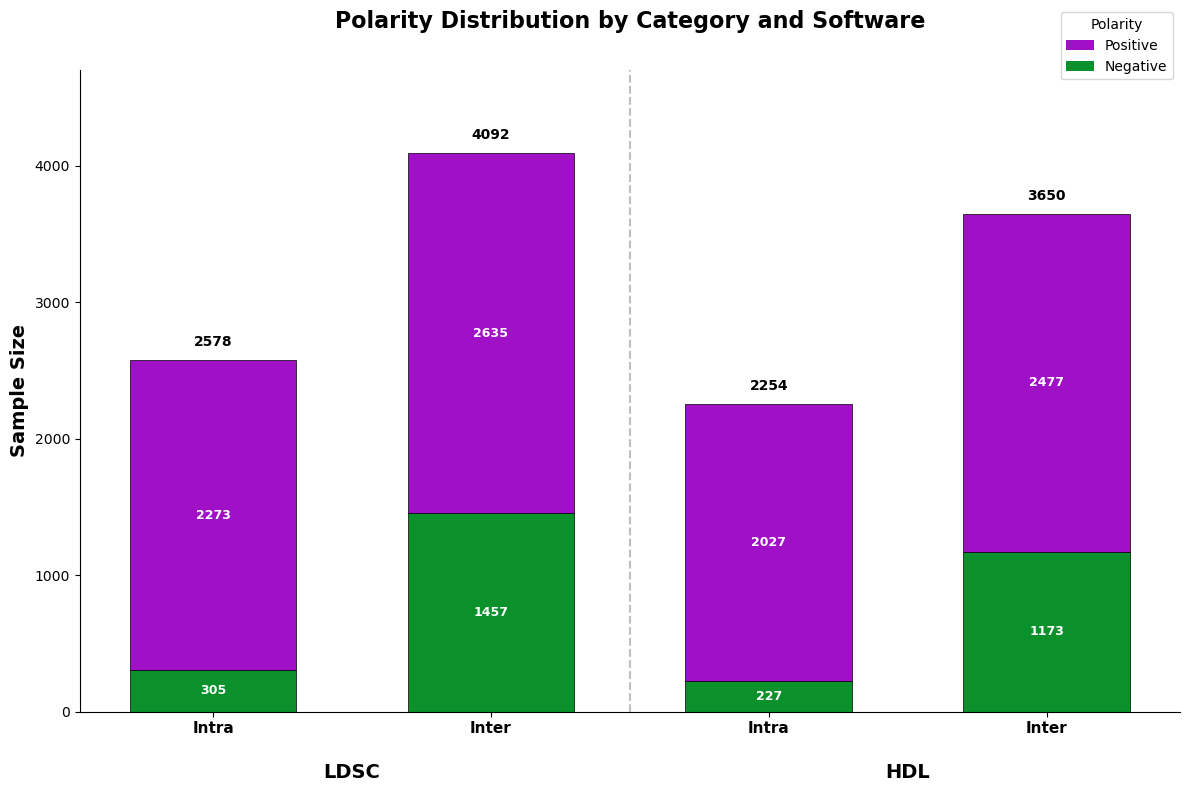

In [ ]:
grouped_cat_pol_software_plot = cat_pol_software.groupby(['Software', 'Category', 'Polarity']).size().reset_index(name='Count')

colors = {'Positive': "#9f10c7", 'Negative': "#0a912c"}
softwares_unique = ['LDSC', 'HDL']
categories_unique = ['Intra', 'Inter']

fig, ax = plt.subplots(figsize=(12, 8))
x_pos = 0
x_ticks = []
x_labels = []
software_centers = {}

max_height = grouped_cat_pol_software.groupby(['Software', 'Category'])['Count'].sum().max()
min_height_threshold = max_height * 0.05 

for sw in softwares_unique:
    sw_start = x_pos
    sw_data = grouped_cat_pol_software[grouped_cat_pol_software['Software'] == sw]
    
    for cat in categories_unique:
        cat_data = sw_data[sw_data['Category'] == cat]
        
        pos_val = cat_data[cat_data['Polarity'] == 'Positive']['Count'].sum()
        neg_val = cat_data[cat_data['Polarity'] == 'Negative']['Count'].sum()
        
        if neg_val > 0:
            ax.bar(x_pos, neg_val, color=colors['Negative'], width=0.6, edgecolor='black', linewidth=0.5)
            if neg_val < min_height_threshold:
                ax.text(x_pos + 0.35, neg_val, f'{int(neg_val)}', ha='left', va='center', 
                        color=colors['Negative'], fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=colors['Negative'], linewidth=1))
            else:
                ax.text(x_pos, neg_val/2, f'{int(neg_val)}', ha='center', va='center', 
                        color='white', fontsize=9, fontweight='bold')

        if pos_val > 0:
            ax.bar(x_pos, pos_val, bottom=neg_val, color=colors['Positive'], width=0.6, edgecolor='black', linewidth=0.5)
            if pos_val < min_height_threshold:
                ax.text(x_pos + 0.35, neg_val + pos_val/2, f'{int(pos_val)}', ha='left', va='center',
                        color=colors['Positive'], fontsize=8, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor=colors['Positive'], linewidth=1))
            else:
                ax.text(x_pos, neg_val + pos_val/2, f'{int(pos_val)}', ha='center', va='center',
                        color='white', fontsize=9, fontweight='bold')

        total = pos_val + neg_val
        ax.text(x_pos, total + (max_height * 0.02), f'{int(total)}', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color='black')

        x_ticks.append(x_pos)
        x_labels.append(cat)
        x_pos += 1

    software_centers[sw] = (sw_start + x_pos - 1) / 2
    
    if sw != softwares_unique[-1]:
        ax.axvline(x=x_pos - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=11, fontweight='bold')

for sw, center in software_centers.items():
    ax.text(center, -0.08, sw, ha='center', va='top', fontsize=14, 
            fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_ylabel('Sample Size', fontsize=14, fontweight='bold')
ax.set_title('Polarity Distribution by Category and Software', fontsize=16, fontweight='bold', pad=30)
ax.set_ylim(0, max_height * 1.15)

legend_elements = [
    Patch(facecolor=colors['Positive'], label='Positive'),
    Patch(facecolor=colors['Negative'], label='Negative')
]
ax.legend(handles=legend_elements, title='Polarity', loc='upper right', bbox_to_anchor=(1, 1.1))

sns.despine()
plt.tight_layout()

png_path = f"{general_plots_dir}category_polarity_grouped_barplot.png"
jpg_path = f"{general_plots_dir}category_polarity_grouped_barplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

plt.show()

In [165]:
polarity_pair_software = tabla_sample_polarity_perc.reset_index()

# Order by Category
polarity_pair_software['Category_order'] = polarity_pair_software['Category'].map({'Intra': 0, 'Inter': 1})
polarity_pair_software = polarity_pair_software.sort_values(['Category_order', 'Pair', 'Dataset'])
# Group by Pair, Dataset and Polarity
grouped = polarity_pair_software.groupby(['Pair', 'Dataset', 'Polarity'])['Sample size'].sum().reset_index()
grouped['Total_Pair_Dataset'] = grouped.groupby(['Pair', 'Dataset'])['Sample size'].transform('sum')
grouped['Percentage'] = (grouped['Sample size'] / grouped['Total_Pair_Dataset']) * 100
pairs_unique = polarity_pair_software[['Pair', 'Category_order']].drop_duplicates().sort_values('Category_order')['Pair'].unique()



Gráficos guardados en:
- /home/maria/git/SOROLLA/Results/OUTPUTS/plots/general/pairs_polarity_grouped_barplot.png
- /home/maria/git/SOROLLA/Results/OUTPUTS/plots/general/pairs_polarity_grouped_barplot.jpg


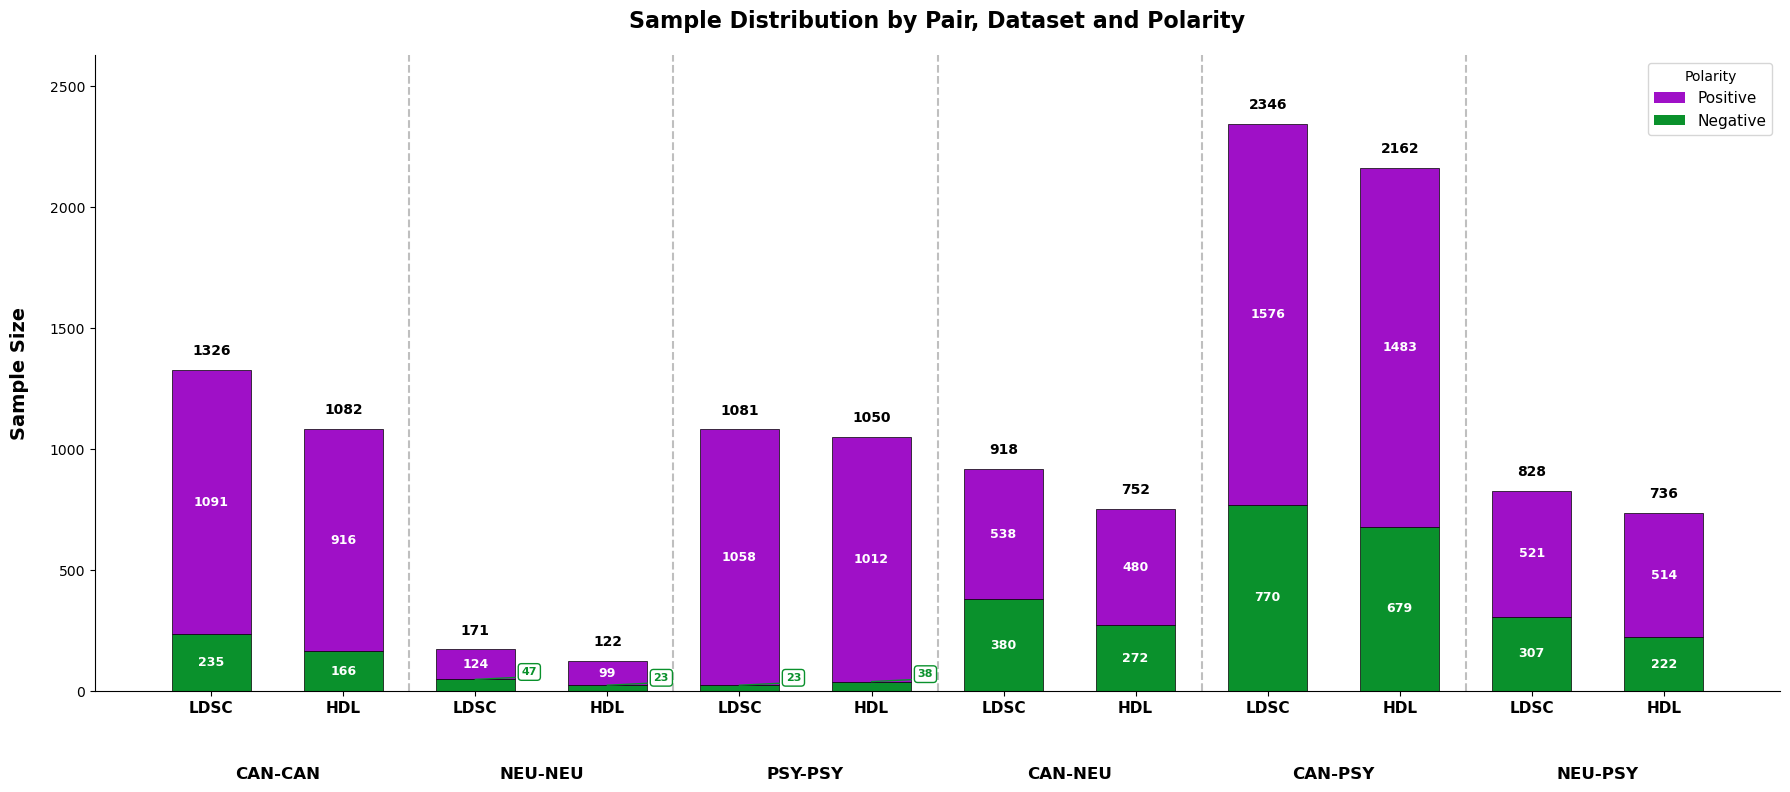

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))
x_pos = 0
x_labels = []
x_ticks = []
pair_centers = {}
colors = {'Positive': "#9f10c7", 'Negative': "#0a912c"}
max_height = grouped.groupby(['Pair', 'Dataset'])['Sample size'].sum().max()
min_height_threshold = max_height * 0.03  # 3% of the maximum

for pair in pairs_unique:
    pair_data = grouped[grouped['Pair'] == pair]
    
    pair_start = x_pos
    
    for dataset in ['LDSC', 'HDL']:
        dataset_data = pair_data[pair_data['Dataset'] == dataset]
        pos_val = dataset_data[dataset_data['Polarity'] == 'Positive']['Sample size'].sum()
        neg_val = dataset_data[dataset_data['Polarity'] == 'Negative']['Sample size'].sum()
        
        # Draw negative bar
        if neg_val > 0:
            ax.bar(x_pos, neg_val, color=colors['Negative'], width=0.6, edgecolor='black', linewidth=0.5)
            
            # If the bar is very small, put label above with arrow
            if neg_val < min_height_threshold:
                ax.text(x_pos + 0.35, neg_val + 10, f'{int(neg_val)}', ha='left', va='bottom', 
                       color=colors['Negative'], fontsize=8, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors['Negative'], linewidth=1))
                ax.plot([x_pos, x_pos + 0.3], [neg_val, neg_val + 8], 
                       color=colors['Negative'], linewidth=1, linestyle='-')
            else:
                ax.text(x_pos, neg_val/2, f'{int(neg_val)}', ha='center', va='center', 
                       color='white', fontsize=9, fontweight='bold')
        
        # Draw positive bar 
        if pos_val > 0:
            ax.bar(x_pos, pos_val, bottom=neg_val, color=colors['Positive'], width=0.6, 
                   edgecolor='black', linewidth=0.5)
            
            # If the bar is very small, put label beside it
            if pos_val < min_height_threshold:
                ax.text(x_pos + 0.35, neg_val + pos_val/2, f'{int(pos_val)}', ha='left', va='center',
                       color=colors['Positive'], fontsize=8, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors['Positive'], linewidth=1))
                ax.plot([x_pos, x_pos + 0.3], [neg_val + pos_val/2, neg_val + pos_val/2], 
                       color=colors['Positive'], linewidth=1, linestyle='-')
            else:
                ax.text(x_pos, neg_val + pos_val/2, f'{int(pos_val)}', ha='center', va='center',
                       color='white', fontsize=9, fontweight='bold')
        
        total = pos_val + neg_val
        ax.text(x_pos, total + 50, f'{int(total)}', ha='center', va='bottom',
               fontsize=10, fontweight='bold', color='black')
        
        x_labels.append(dataset)
        x_ticks.append(x_pos)
        
        x_pos += 1
    
    pair_centers[pair] = (pair_start + x_pos - 1) / 2
    
    # Add separator after the pair (except the last one)
    if pair != pairs_unique[-1]:
        ax.axvline(x=x_pos - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=11, fontweight='bold')

# Pair labels
for pair, center in pair_centers.items():
    ax.text(center, -0.12, pair, ha='center', va='top', fontsize=12, 
           fontweight='bold', transform=ax.get_xaxis_transform())

ax.set_ylabel('Sample Size', fontsize=14, fontweight='bold', labelpad=15)
ax.set_title('Sample Distribution by Pair, Dataset and Polarity', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, max_height * 1.12)

# Legend
legend_elements = [
    Patch(facecolor=colors['Positive'], label='Positive'),
    Patch(facecolor=colors['Negative'], label='Negative')
]
ax.legend(handles=legend_elements, title='Polarity', loc='upper right', fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()

# Save
png_path = f"{general_plots_dir}pairs_polarity_grouped_barplot.png"
jpg_path = f"{general_plots_dir}pairs_polarity_grouped_barplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

print(f"Saved graph in:\n- {png_path}\n- {jpg_path}")
plt.show()

Graphs saved in:
- /home/maria/git/SOROLLA/Results/OUTPUTS/plots/general/pairs_polarity_relative_percentage_barplot.png
- /home/maria/git/SOROLLA/Results/OUTPUTS/plots/general/pairs_polarity_relative_percentage_barplot.jpg


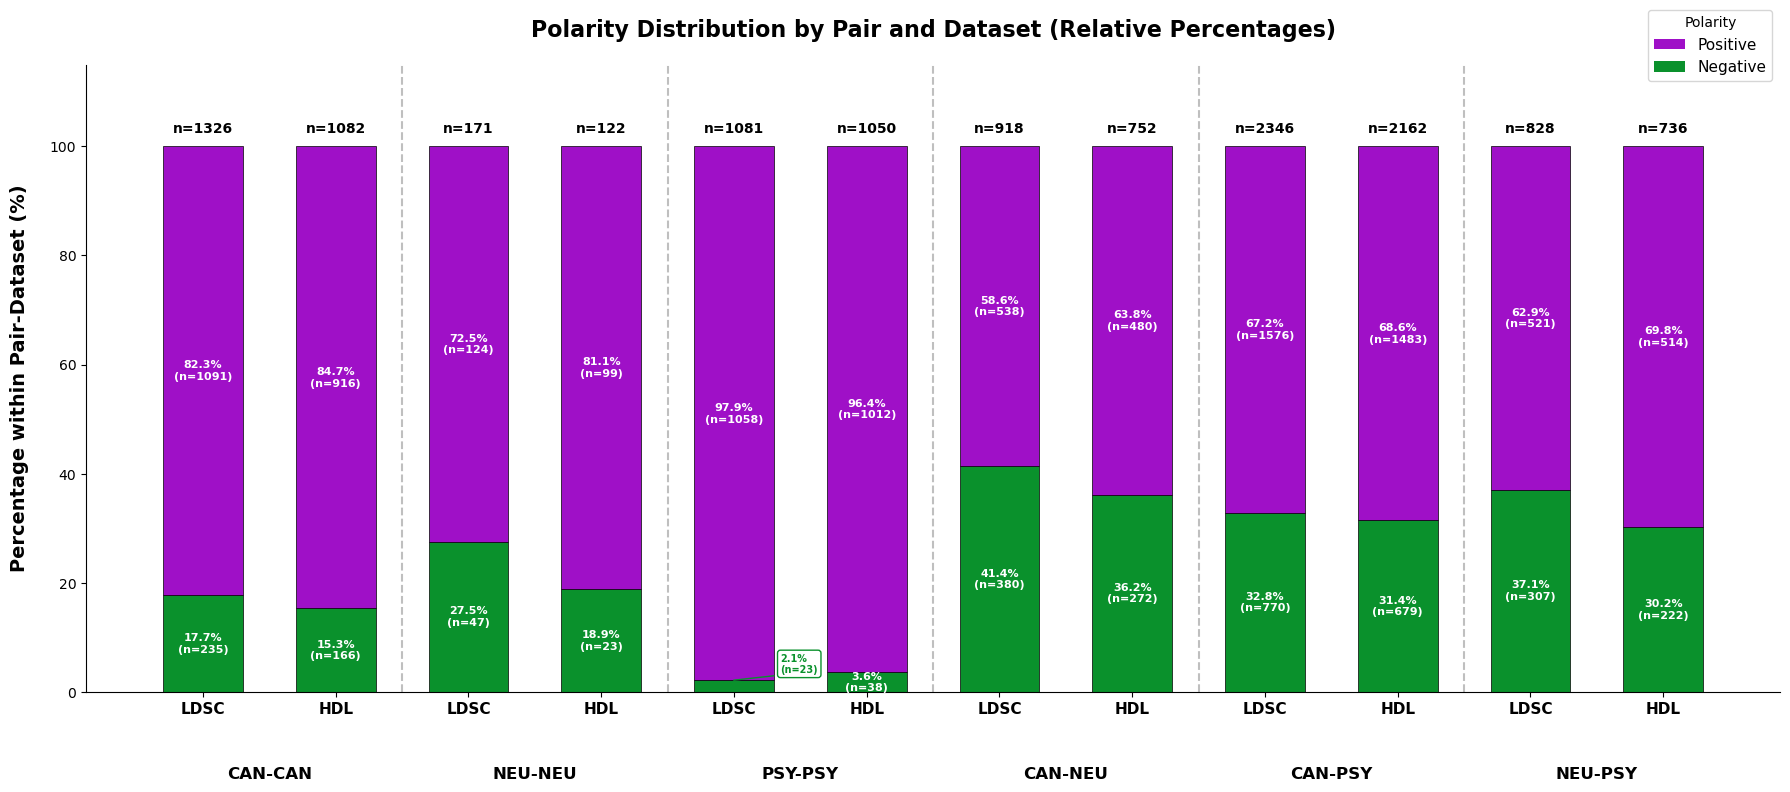

In [356]:
fig, ax = plt.subplots(figsize=(18, 8))
x_pos = 0
x_labels = []
x_ticks = []
pair_centers = {}
max_height = 100
min_height_threshold = 3  # 3% threshold

for pair in pairs_unique:
    pair_data = grouped[grouped['Pair'] == pair]
    
    pair_start = x_pos
    
    for dataset in ['LDSC', 'HDL']:
        dataset_data = pair_data[pair_data['Dataset'] == dataset]
        
        # Get percentage values of positive and negative
        pos_perc = dataset_data[dataset_data['Polarity'] == 'Positive']['Percentage'].sum()
        neg_perc = dataset_data[dataset_data['Polarity'] == 'Negative']['Percentage'].sum()
        
        # Get absolute values for display
        pos_val = dataset_data[dataset_data['Polarity'] == 'Positive']['Sample size'].sum()
        neg_val = dataset_data[dataset_data['Polarity'] == 'Negative']['Sample size'].sum()
        
        # Draw negative bar (bottom)
        if neg_perc > 0:
            ax.bar(x_pos, neg_perc, color=colors['Negative'], width=0.6, edgecolor='black', linewidth=0.5)
            
            # If the bar is very small, put label above with arrow
            if neg_perc < min_height_threshold:
                ax.text(x_pos + 0.35, neg_perc + 1, f'{neg_perc:.1f}%\n(n={int(neg_val)})', ha='left', va='bottom', 
                       color=colors['Negative'], fontsize=7, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors['Negative'], linewidth=1))
                # Small indicator line
                ax.plot([x_pos, x_pos + 0.3], [neg_perc, neg_perc + 0.8], 
                       color=colors['Negative'], linewidth=1, linestyle='-')
            else:
                # Label inside the bar
                ax.text(x_pos, neg_perc/2, f'{neg_perc:.1f}%\n(n={int(neg_val)})', ha='center', va='center', 
                       color='white', fontsize=8, fontweight='bold')
        
        # Draw positive bar (top)
        if pos_perc > 0:
            ax.bar(x_pos, pos_perc, bottom=neg_perc, color=colors['Positive'], width=0.6, 
                   edgecolor='black', linewidth=0.5)
            
            # If the bar is very small, put label beside it
            if pos_perc < min_height_threshold:
                ax.text(x_pos + 0.35, neg_perc + pos_perc/2, f'{pos_perc:.1f}%\n(n={int(pos_val)})', ha='left', va='center',
                       color=colors['Positive'], fontsize=7, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=colors['Positive'], linewidth=1))
                # Small indicator line
                ax.plot([x_pos, x_pos + 0.3], [neg_perc + pos_perc/2, neg_perc + pos_perc/2], 
                       color=colors['Positive'], linewidth=1, linestyle='-')
            else:
                # Label inside the bar
                ax.text(x_pos, neg_perc + pos_perc/2, f'{pos_perc:.1f}%\n(n={int(pos_val)})', ha='center', va='center',
                       color='white', fontsize=8, fontweight='bold')
        
        # Total count on top (always 100%)
        total_val = pos_val + neg_val
        ax.text(x_pos, 100 + 2, f'n={int(total_val)}', ha='center', va='bottom',
               fontsize=10, fontweight='bold', color='black')
        
        # Save position and label
        x_labels.append(dataset)
        x_ticks.append(x_pos)
        
        x_pos += 1
    
    # Calculate center of the pair for the label
    pair_centers[pair] = (pair_start + x_pos - 1) / 2
    
    # Add separator after the pair (except the last one)
    if pair != pairs_unique[-1]:
        ax.axvline(x=x_pos - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# Configure axes
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=11, fontweight='bold')

# Add Pair labels below
for pair, center in pair_centers.items():
    ax.text(center, -0.12, pair, ha='center', va='top', fontsize=12, 
           fontweight='bold', transform=ax.get_xaxis_transform())

# General format
ax.set_ylabel('Percentage within Pair-Dataset (%)', fontsize=14, fontweight='bold', labelpad=15)
ax.set_title('Polarity Distribution by Pair and Dataset (Relative Percentages)', 
            fontsize=16, fontweight='bold', pad=20)
ax.set_ylim(0, 115)  # Fixed to 100% + space for labels

# Manual legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Positive'], label='Positive'),
    Patch(facecolor=colors['Negative'], label='Negative')
]
ax.legend(handles=legend_elements, title='Polarity', bbox_to_anchor=(1.0, 1.1), fontsize=11)

sns.despine(ax=ax)
plt.tight_layout()

# Save
png_path = f"{general_plots_dir}pairs_polarity_relative_percentage_barplot.png"
jpg_path = f"{general_plots_dir}pairs_polarity_relative_percentage_barplot.jpg"
plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(jpg_path, bbox_inches='tight', dpi=300)

print(f"Graphs saved in:\n- {png_path}\n- {jpg_path}")
plt.show()

## Visualize Similarity

### Scatter

#### Function for the three plots and tables
Saves tables:
- Color summary .xlsx
- All pairs that are different .csv

Saves plots:
1. General plot with regression coefficient
2. Scatter plot segregated by pairs with regression coefficient
3. Stacked histplot with categories percentages

In [2]:
def comparison_scatter_colors(
    df,
    selection_name,
    plot_name,
    comparison_plots_dir,
    comparison_tables_dir,
):
    """" 
    	First we create the order of the pairs, intra before inter.
         Then we assign colors based on the direction and difference of the rg estimates.
         The dataframe will be updated with a new column 'color' that indicates the assigned color for each pair.
         We will also create a summary table of the color assignments and save it as an Excel file
         Finally we create three different plots
         1 - A general scatter plot of all pairs with colors
         2 - A scatter plot for each pair
         3 - A stacked plot for the distribution of colors by pair
         Then a csv is saved with the pairs that have opposite directions (red and orange) for further analysis.
    """
    
	# Get all the data ready
    ordered_pairs = [
            ("CAN", "CAN"),
            ("PSY", "PSY"),
            ("NEU", "NEU"),
            ("CAN", "PSY"),
            ("CAN", "NEU"),
            ("PSY", "NEU"),
        ]

	# Calculate difference
    df["diff_rg"] = (df["rg_ldsc"] - df["rg_hdl"]).abs()

	# Assign colors
    def _assign(row):
        opposite = (row["rg_ldsc"] * row["rg_hdl"]) < 0
        diff = abs(row["rg_ldsc"] - row["rg_hdl"])
        if opposite and diff > 0.1:
            return "red"
        if opposite:
            return "orange"
        if diff > 0.25:
            return "purple"
        return "blue"

    df["color"] = df.apply(_assign, axis=1)

	# Assign meaning and create xlsx table
    color_meaning = {
        "blue": "same direction, |difference| ≤ 0.25",
        "purple": "same direction, |difference| > 0.25",
        "orange": "opposite direction, |difference| ≤ 0.1",
        "red": "opposite direction, |difference| > 0.1",
    }

    counts = df["color"].value_counts().reindex(["red", "orange", "purple", "blue"], fill_value=0)
    total = len(df)

    color_table = pd.DataFrame({
        "color": counts.index,
        "meaning": [color_meaning[c] for c in counts.index],
        "count": counts.values,
        "percentage": np.round(counts.values / total * 100, 2),
    })

	# Save color summary table
    colors_xlsx = os.path.join(comparison_tables_dir, f"color_summary_{plot_name}.xlsx")
    color_table.to_excel(colors_xlsx, index=False)

	# Save csv with opposite pairs
    opposite_df = df[df["color"].isin(["red", "orange"])].copy()
    opposite_df["Pair"] = opposite_df["type_1"].astype(str) + " vs " + opposite_df["type_2"].astype(str)

    keep_cols = [
        "disease_1", "disease_2",
        "label_1", "label_2",
        "rg_hdl", "p_corrected_FDR_hdl",
        "rg_ldsc", "p_corrected_FDR_ldsc",
        "color", "diff_rg",
        "Pair"
    ]
    keep_cols = [c for c in keep_cols if c in opposite_df.columns]
    opposite_df = opposite_df[keep_cols]

    opposite_csv = os.path.join(comparison_tables_dir, f"opposite_pairs_{plot_name}.csv")
    opposite_df.to_csv(opposite_csv, index=False)


    # Print summary
    color_counts = {'red':0, 'purple': 0, 'orange': 0, 'blue': 0}
    for color in df["color"].unique():
        color_counts[color] = df[df["color"] == color].shape[0]
    print(f"Number of red points (opposite sign and |difference| > 0.1): {color_counts['red']}, percentage: {color_counts['red']/len(df)*100:.2f}%")
    print(f"Number of orange points (opposite sign): {color_counts['orange']}, percentage: {color_counts['orange']/len(df)*100:.2f}")
    print(f"Number of purple points (|difference| > 0.25): {color_counts['purple']}, percentage: {color_counts['purple']/len(df)*100:.2f}%")
    print(f"Number of blue points (same sign, |difference| ≤ 0.25): {color_counts['blue']}, percentage: {color_counts['blue']/len(df)*100:.2f}%")
    print(f"The total number of point in the same direction is: {color_counts['blue']+color_counts['purple']} and the total number of points in the opposite direction is: {color_counts['red']+color_counts['orange']}")

	# First plot - general scatter plot with colors
    correlation = df["rg_ldsc"].corr(df["rg_hdl"])
    plt.figure(figsize=(8, 6))
    plt.scatter(df["rg_ldsc"], df["rg_hdl"], c=df["color"])
    plt.plot([-1, 1], [-1, 1], color="green", linestyle="--", linewidth=3.4, label='Expected match line (y=x)')
    plt.axhline(y=0, color="gray", linestyle="--")
    plt.axvline(x=0, color="gray", linestyle="--")
    plt.title(f"Comparison of Results from Two Softwares - {selection_name}")
    plt.xlabel("Correlation estimated by LDSC")
    plt.ylabel("Correlation estimated by HDL")
    plt.text(-0.9, 0.9, f"r = {correlation:.2f}", fontsize=16, color="black",
             bbox=dict(facecolor="white", alpha=0.5))
    general_scatterplot_save = os.path.join(comparison_plots_dir, f"software_comparison_scatterplot_{plot_name}")
    plt.savefig(f"{general_scatterplot_save}.png", bbox_inches="tight", dpi=300)
    plt.savefig(f"{general_scatterplot_save}.jpg", bbox_inches="tight", dpi=300)
    plt.legend()
    plt.show()
    

	# Second plot - scatter plot for each pair
    df["pair_tuple"] = df.apply(lambda r: tuple(sorted([r["type_1"], r["type_2"]])), axis=1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, pair in enumerate(ordered_pairs):
        ax = axes[i]
        subset = df[df["pair_tuple"] == tuple(sorted(pair))]

        if subset.empty:
            ax.set_title(f"{pair[0]} vs {pair[1]} (n=0)")
            ax.axis("off")
            continue

        corr_sub = subset["rg_ldsc"].corr(subset["rg_hdl"])
        ax.scatter(subset["rg_ldsc"], subset["rg_hdl"], c=subset["color"])
        ax.plot([-1, 1], [-1, 1], color="green", linestyle="--", linewidth=2, label='Expected match line (y=x)')
        ax.axhline(y=0, color="gray", linestyle="--")
        ax.axvline(x=0, color="gray", linestyle="--")
        ax.set_title(f"{pair[0]} vs {pair[1]} (n={len(subset)})")
        ax.set_xlabel("LDSC")
        ax.set_ylabel("HDL")
        ax.text(-0.9, 0.9, f"r = {corr_sub:.2f}", fontsize=12, color="black",
                bbox=dict(facecolor="white", alpha=0.6))

    plt.tight_layout()
    plt.suptitle(f"Software comparison by Pair - {selection_name}", fontsize=18, y=1.02)
    categories_scatterplot_save = os.path.join(comparison_plots_dir, f"software_comparison_scatterplot_pairs_{plot_name}")
    plt.savefig(f"{categories_scatterplot_save}.png", bbox_inches="tight", dpi=300)
    plt.savefig(f"{categories_scatterplot_save}.jpg", bbox_inches="tight", dpi=300)
    plt.show()

	# Third plot - stacked bar plot for distribution of colors by pair
    color_order = ["purple", "blue", "orange", "red"]
    custom_colors = {
        "orange": "#D28A05",
        "red": "#BB3200",
        "purple": "#9E1D9E",
        "blue": "#0B69C7",
    }

    pair_order = [tuple(sorted(p)) for p in ordered_pairs]
    color_distribution = df.groupby("pair_tuple")["color"].value_counts().unstack(fill_value=0)
    color_distribution = color_distribution.reindex(index=pair_order, fill_value=0)
    color_percentages = color_distribution.div(color_distribution.sum(axis=1).replace(0, np.nan), axis=0) * 100
    color_percentages = color_percentages.reindex(columns=color_order, fill_value=0).fillna(0)

    fig, ax = plt.subplots(figsize=(15, 7))
    color_percentages.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[custom_colors.get(col, col) for col in color_percentages.columns],
    )

    for i, row in enumerate(color_percentages.values):
        cum_height = 0
        for val in row:
            if val > 0:
                ax.text(i, cum_height + val / 2, f"{val:.1f}%", ha="center", va="center",
                        fontsize=9, color="white")
                cum_height += val

    ax.set_xticklabels([f"{a} vs {b}" for a, b in ordered_pairs], rotation=45, ha="right")
    ax.set_title(f"Distribution of colors by pair - {selection_name}")
    ax.set_xlabel("Categories Paired")
    ax.set_ylabel("Percentage")

    handles, _ = ax.get_legend_handles_labels()
    new_labels = [
        "Purple = Same direction, difference > 0.25",
        "Blue = Same direction, difference ≤ 0.25",
        "Orange = Opposite direction, difference ≤ 0.1",
        "Red = Opposite direction, difference > 0.1",
    ]
    ax.legend(handles, new_labels, title="Color Meaning", bbox_to_anchor=(1.05, 1), loc="upper left")

    dist_save = os.path.join(comparison_plots_dir, f"stacked_distribution_pairs_{plot_name}")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig(f"{dist_save}.png", bbox_inches="tight", dpi=300)
    plt.savefig(f"{dist_save}.jpg", bbox_inches="tight", dpi=300)
    plt.show()

    return df, color_table, opposite_df

In [42]:
ldsc_hdl_significant_both[(ldsc_hdl_significant_both["color"]=="orange")|(ldsc_hdl_significant_both["color"]=="red")][['id_1', 'label_1', 'type_1', 'disease_1', 'selection_1',
      'id_2', 'label_2', 'disease_2',
       'type_2', 'selection_2','rg_ldsc', 'p_corrected_FDR_ldsc', 'p_FDR_rejected_ldsc',
       'Category', 'Polarity_ldsc', 'Pair', 'rg_hdl','p_corrected_FDR_hdl',
       'p_FDR_rejected_hdl', 'Polarity_hdl', 'color']]

,id_1,label_1,type_1,disease_1,selection_1,id_2,label_2,disease_2,type_2,selection_2,...,p_corrected_FDR_ldsc,p_FDR_rejected_ldsc,Category,Polarity_ldsc,Pair,rg_hdl,p_corrected_FDR_hdl,p_FDR_rejected_hdl,Polarity_hdl,color
1525,GCST010514,autism-2,PSY,autism,main,GCST001241,BIP-PGC-2011,bipolar disorder,PSY,minor,...,1.457504e-02,True,Intra,Positive,PSY-PSY,-0.000018,2.127121e-09,True,Negative,red
1891,GCST90012878,alzheimers-disease-family-history,NEU,alzheimer's disease,subtype-family,GCST001241,BIP-PGC-2011,bipolar disorder,PSY,minor,...,4.170852e-02,True,Inter,Positive,NEU-PSY,-0.000017,3.918042e-20,True,Negative,red
3282,GCST90042843,anxiety-treatment-1,PSY,anxiety,subtype,GCST001241,BIP-PGC-2011,bipolar disorder,PSY,minor,...,1.408844e-08,True,Intra,Positive,PSY-PSY,-0.000012,2.294725e-32,True,Negative,red
6579,PGC-BIP-2021,BIP-PGC-2021,PSY,bipolar disorder,main,GCST001241,BIP-PGC-2011,bipolar disorder,PSY,minor,...,3.403394e-174,True,Intra,Positive,PSY-PSY,-0.000097,7.476264e-06,True,Negative,red


In [40]:
ldsc_hdl_both[(ldsc_hdl_both["color"]=="orange")|(ldsc_hdl_both["color"]=="red")][['label_1', 'disease_1', 'selection_1',
	'label_2', 'disease_2', 'selection_2','rg_ldsc', 'p_FDR_rejected_ldsc', 'rg_hdl','p_corrected_FDR_hdl',
      'p_FDR_rejected_hdl', 'color']]

,label_1,disease_1,selection_1,label_2,disease_2,selection_2,rg_ldsc,p_FDR_rejected_ldsc,rg_hdl,p_corrected_FDR_hdl,p_FDR_rejected_hdl,color
38,BIP-PGC-2011,bipolar disorder,minor,multiple-sclerosis-1,multiple sclerosis,minor,-0.0541,False,2.200000e-06,1.000000,False,orange
42,BIP-PGC-2011,bipolar disorder,minor,lung-carcinoma-1,lung cancer,main,-0.0371,False,8.330000e-06,0.809399,False,orange
43,BIP-PGC-2011,bipolar disorder,minor,lung-carcinoma-smokers,lung cancer,subtype,-0.0376,False,4.350000e-06,1.000000,False,orange
44,BIP-PGC-2011,bipolar disorder,minor,lung-cancer-squamous,lung cancer,subtype,-0.1292,False,5.860000e-06,0.836792,False,red
45,BIP-PGC-2011,bipolar disorder,minor,depression-broad,major depression disorder,subtype,0.2810,True,-2.120000e-07,1.000000,False,red
...,...,...,...,...,...,...,...,...,...,...,...,...
6655,BIP-PGC-2021,bipolar disorder,main,skin-neoplasm,skin cancer,minor,-0.0114,False,1.700000e-03,1.000000,False,orange
6658,BIP-PGC-2021,bipolar disorder,main,breast-cancer-3,breast cancer,minor,-0.0169,False,1.100000e-02,0.772375,False,orange
6659,BIP-PGC-2021,bipolar disorder,main,lymph-node-malignant-neoplasm,lymph node cancer,main,-0.0202,False,1.470000e-02,0.913063,False,orange
6661,BIP-PGC-2021,bipolar disorder,main,uterine-benign-neoplasm,uterus cancer,main,-0.0548,False,7.500000e-03,0.994293,False,orange


In [39]:
ldsc_hdl_both[(ldsc_hdl_both["color"]=="red")][["disease_2"]].value_counts()

disease_2                        
uterus cancer                        36
major depression disorder            32
uterus polyps                        32
lung cancer                          28
skin cancer                          25
prostate cancer                      22
epilepsy                             15
schizophrenia                         8
lymph node cancer                     6
endometrial cancer                    6
bipolar disorder                      5
tourette syndrome                     5
intestinal cancer                     5
breast cancer                         5
multiple sclerosis                    4
musculoskeletal system disease        3
cervical cancer                       3
renal cancer                          2
melanoma                              2
peripheral nervous system disease     2
headache disorder                     1
colorectal cancer                     1
anxiety                               1
amyotrophic lateral sclerosis         1
esopha

In [ ]:
ldsc_hdl_both[(ldsc_hdl_both["color"]=="red")][["Pair"]].value_counts()

In [32]:
ldsc_hdl_both.columns

Index(['id_1', 'label_1', 'type_1', 'disease_1', 'selection_1',
       'disease_subtype_1', 'pubmedId_1', 'id_2', 'label_2', 'disease_2',
       'type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2', 'rg_ldsc',
       'se_ldsc', 'z', 'p_ldsc', 'p_corrected_bonf_ldsc',
       'p_bonf_rejected_ldsc', 'p_corrected_FDR_ldsc', 'p_FDR_rejected_ldsc',
       'Category', 'Polarity_ldsc', 'Pair', 'rg_hdl', 'se_hdl', 'p_hdl',
       'p_corrected_bonf_hdl', 'p_bonf_rejected_hdl', 'p_corrected_FDR_hdl',
       'p_FDR_rejected_hdl', 'Polarity_hdl', '_merge', 'color'],
      dtype='object')

#### All

Number of red points (opposite sign and |difference| > 0.1): 253, percentage: 4.29%
Number of orange points (opposite sign): 565, percentage: 9.57
Number of purple points (|difference| > 0.25): 102, percentage: 1.73%
Number of blue points (same sign, |difference| ≤ 0.25): 4984, percentage: 84.42%
The total number of point in the same direction is: 5086 and the total number of points in the opposite direction is: 818


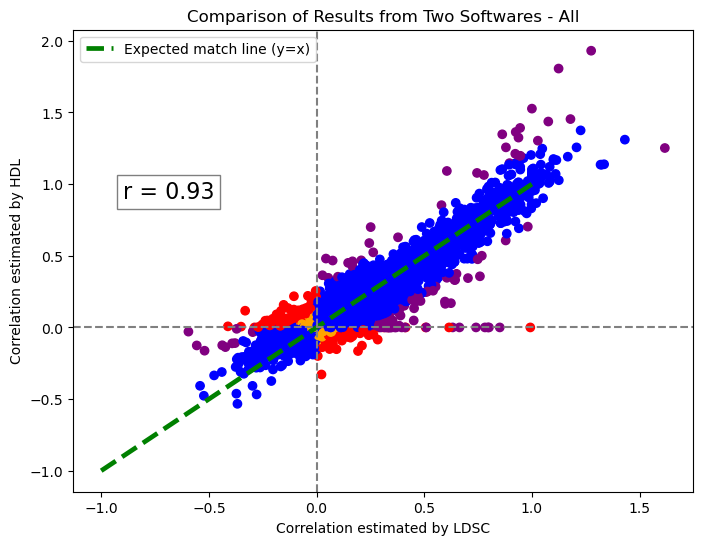

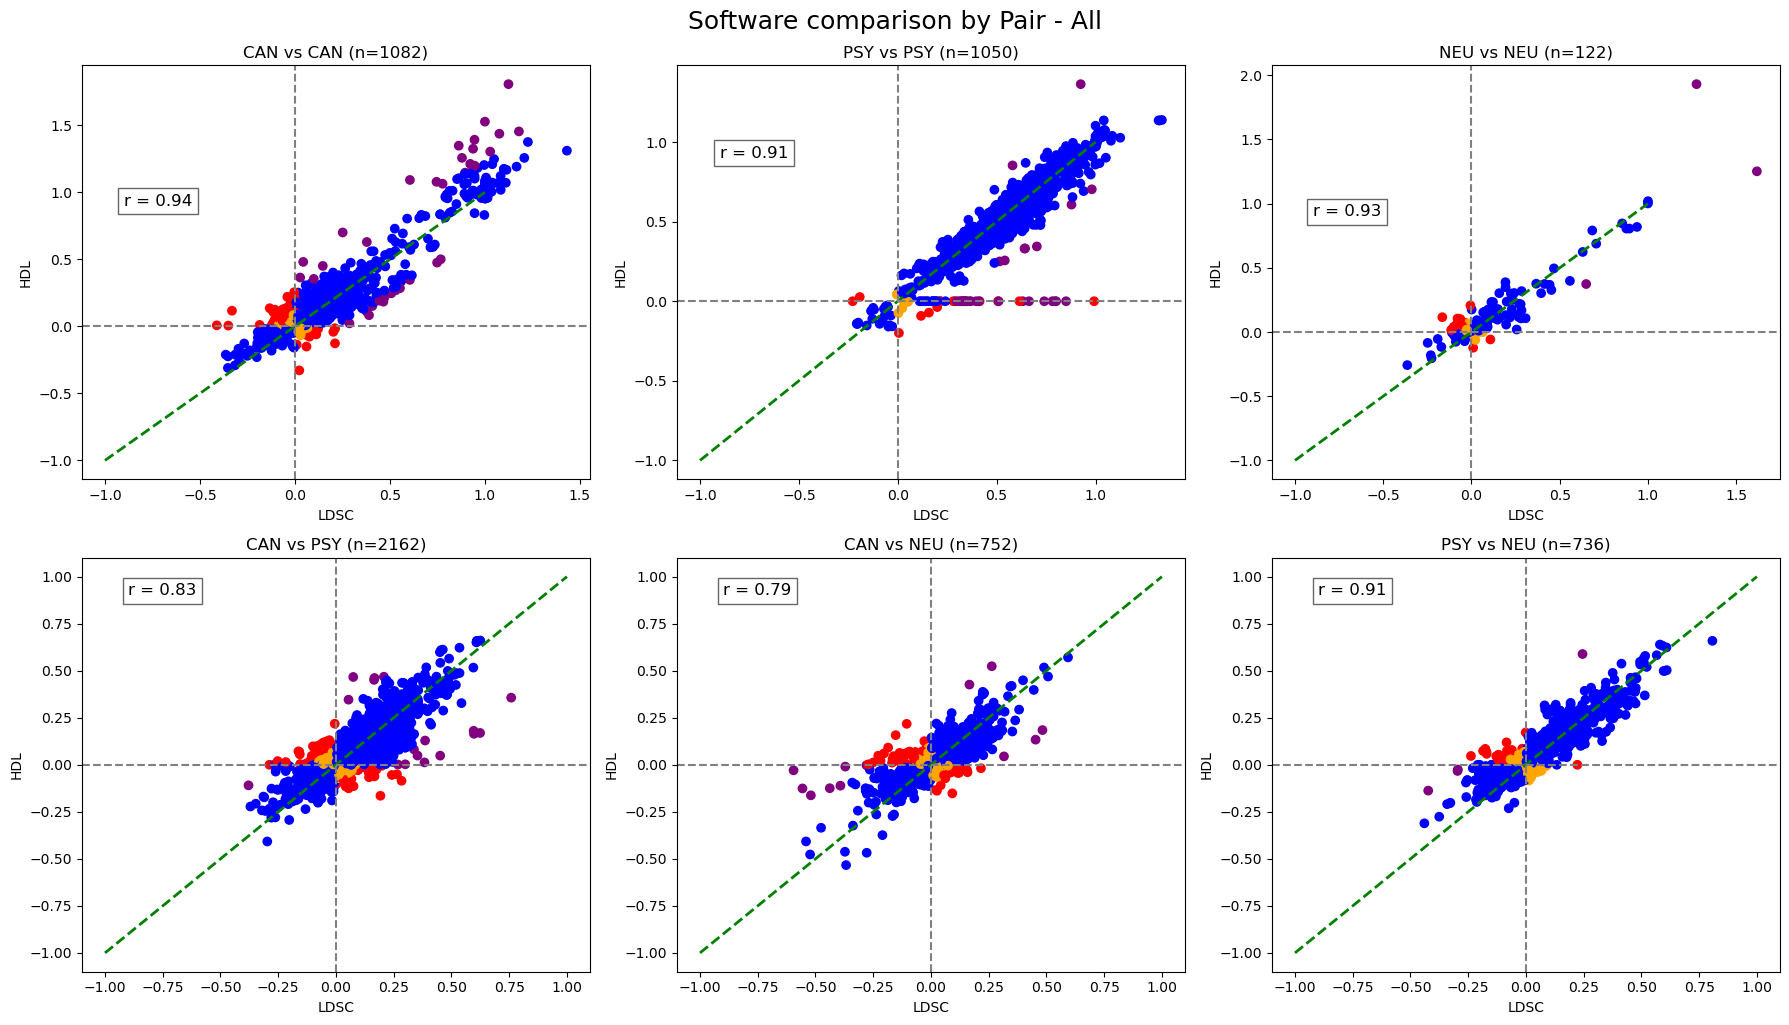

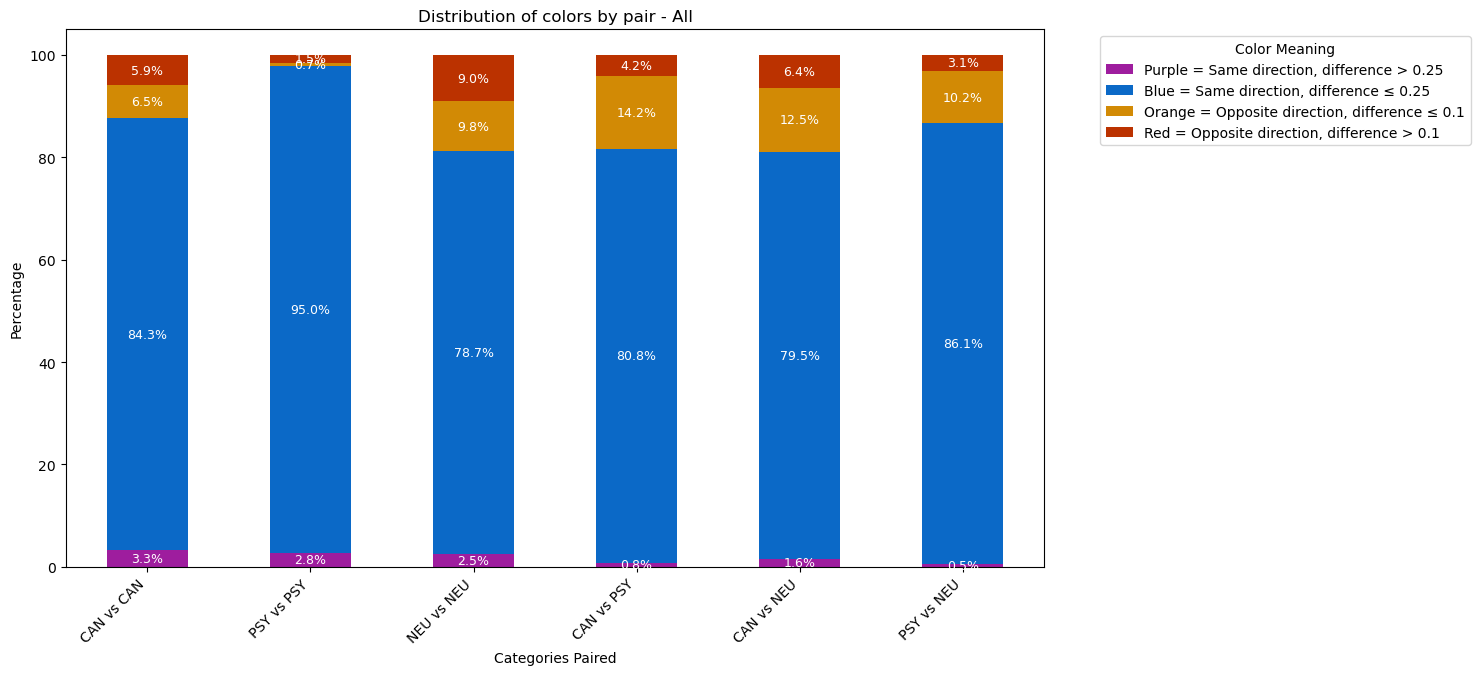

In [193]:
ldsc_hdl_both, table_colors_scatter_all, opposite_colors_all = comparison_scatter_colors(
    df=ldsc_hdl_both,
    selection_name="All",
    plot_name="all",
    comparison_plots_dir=comparison_plots_dir,
    comparison_tables_dir=comparison_tables_dir,
)

#### All significant

Number of red points (opposite sign and |difference| > 0.1): 12, percentage: 0.47%
Number of orange points (opposite sign): 2, percentage: 0.08
Number of purple points (|difference| > 0.25): 73, percentage: 2.88%
Number of blue points (same sign, |difference| ≤ 0.25): 2450, percentage: 96.57%
The total number of point in the same direction is: 2523 and the total number of points in the opposite direction is: 14


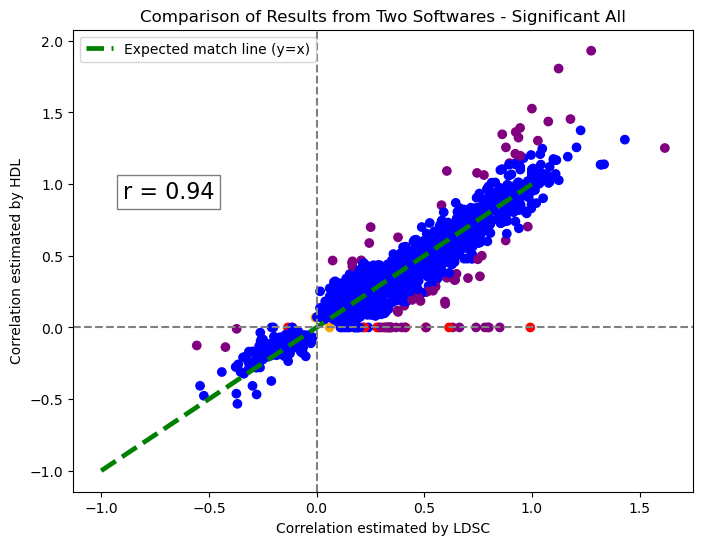

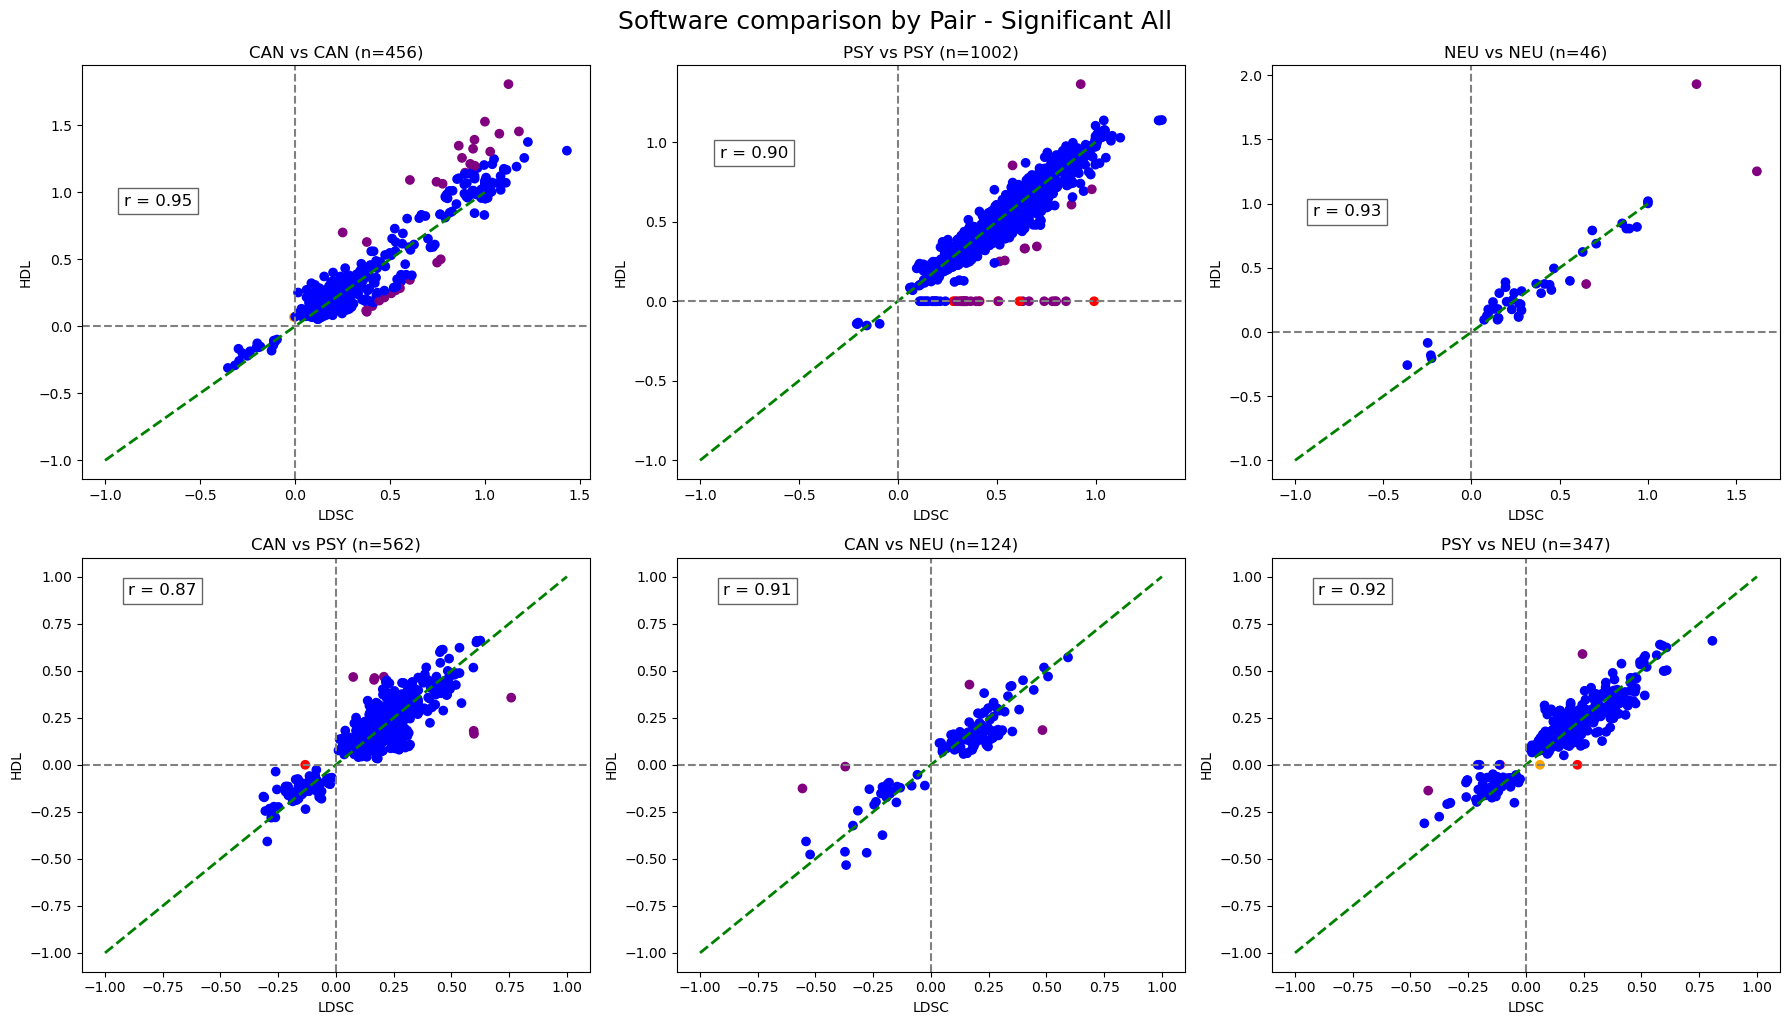

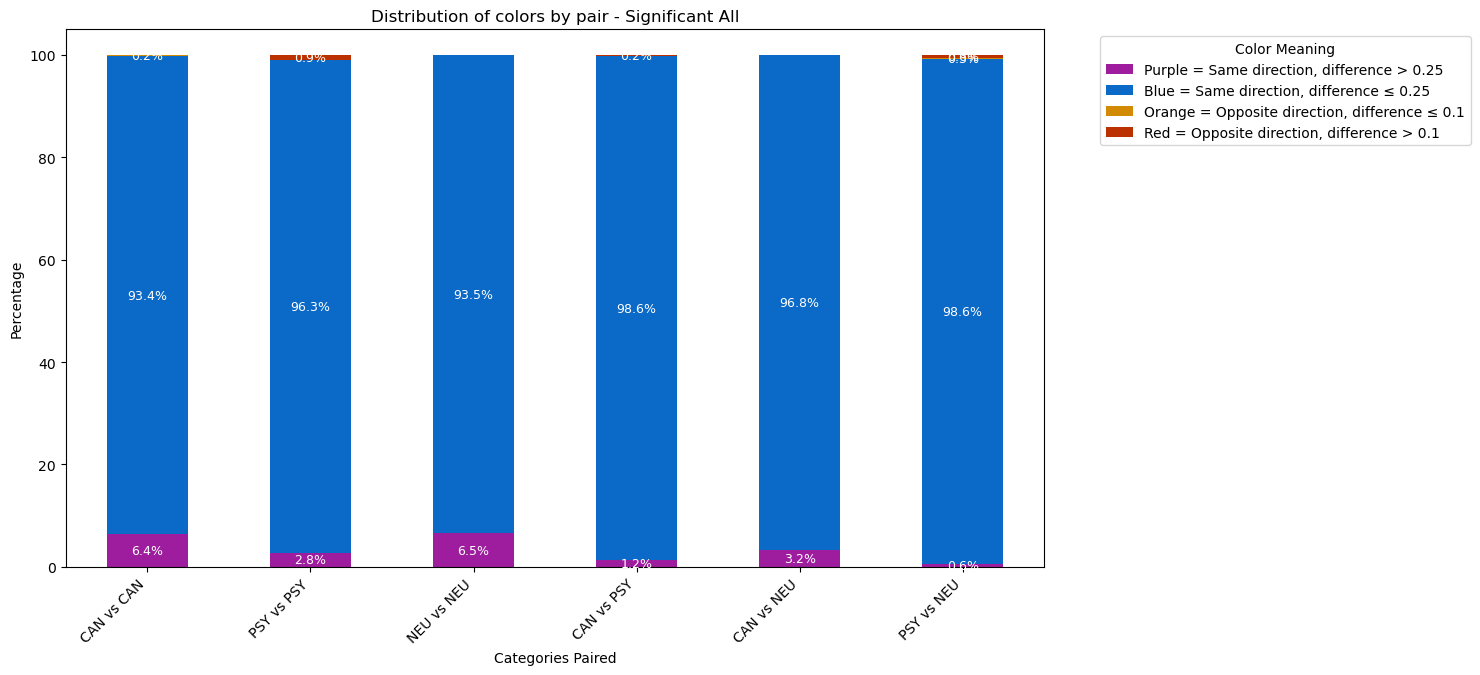

In [196]:
ldsc_hdl_significant_either, table_colors_scatter_all_significant, opposite_colors_all_significant = comparison_scatter_colors(
    df=ldsc_hdl_significant_either,
    selection_name="Significant All",
    plot_name="significant_all",
    comparison_plots_dir=comparison_plots_dir,
    comparison_tables_dir=comparison_tables_dir,
)

#### Both Significant

Number of red points (opposite sign and |difference| > 0.1): 4, percentage: 0.22%
Number of orange points (opposite sign): 0, percentage: 0.00
Number of purple points (|difference| > 0.25): 36, percentage: 2.02%
Number of blue points (same sign, |difference| ≤ 0.25): 1739, percentage: 97.75%
The total number of point in the same direction is: 1775 and the total number of points in the opposite direction is: 4


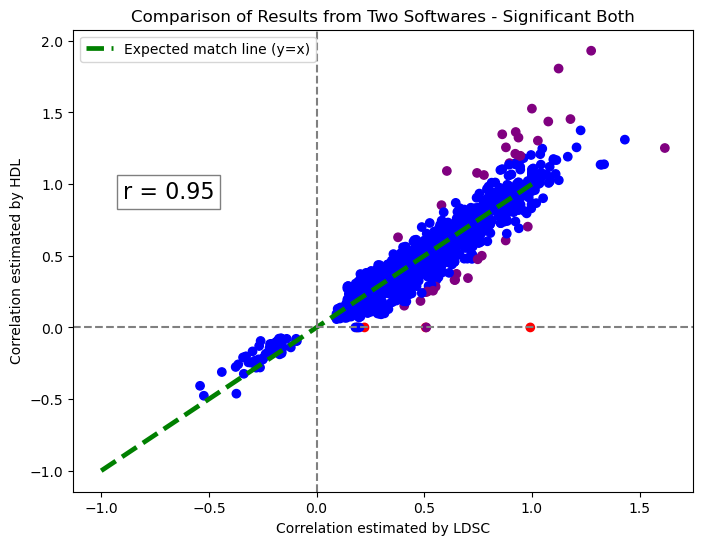

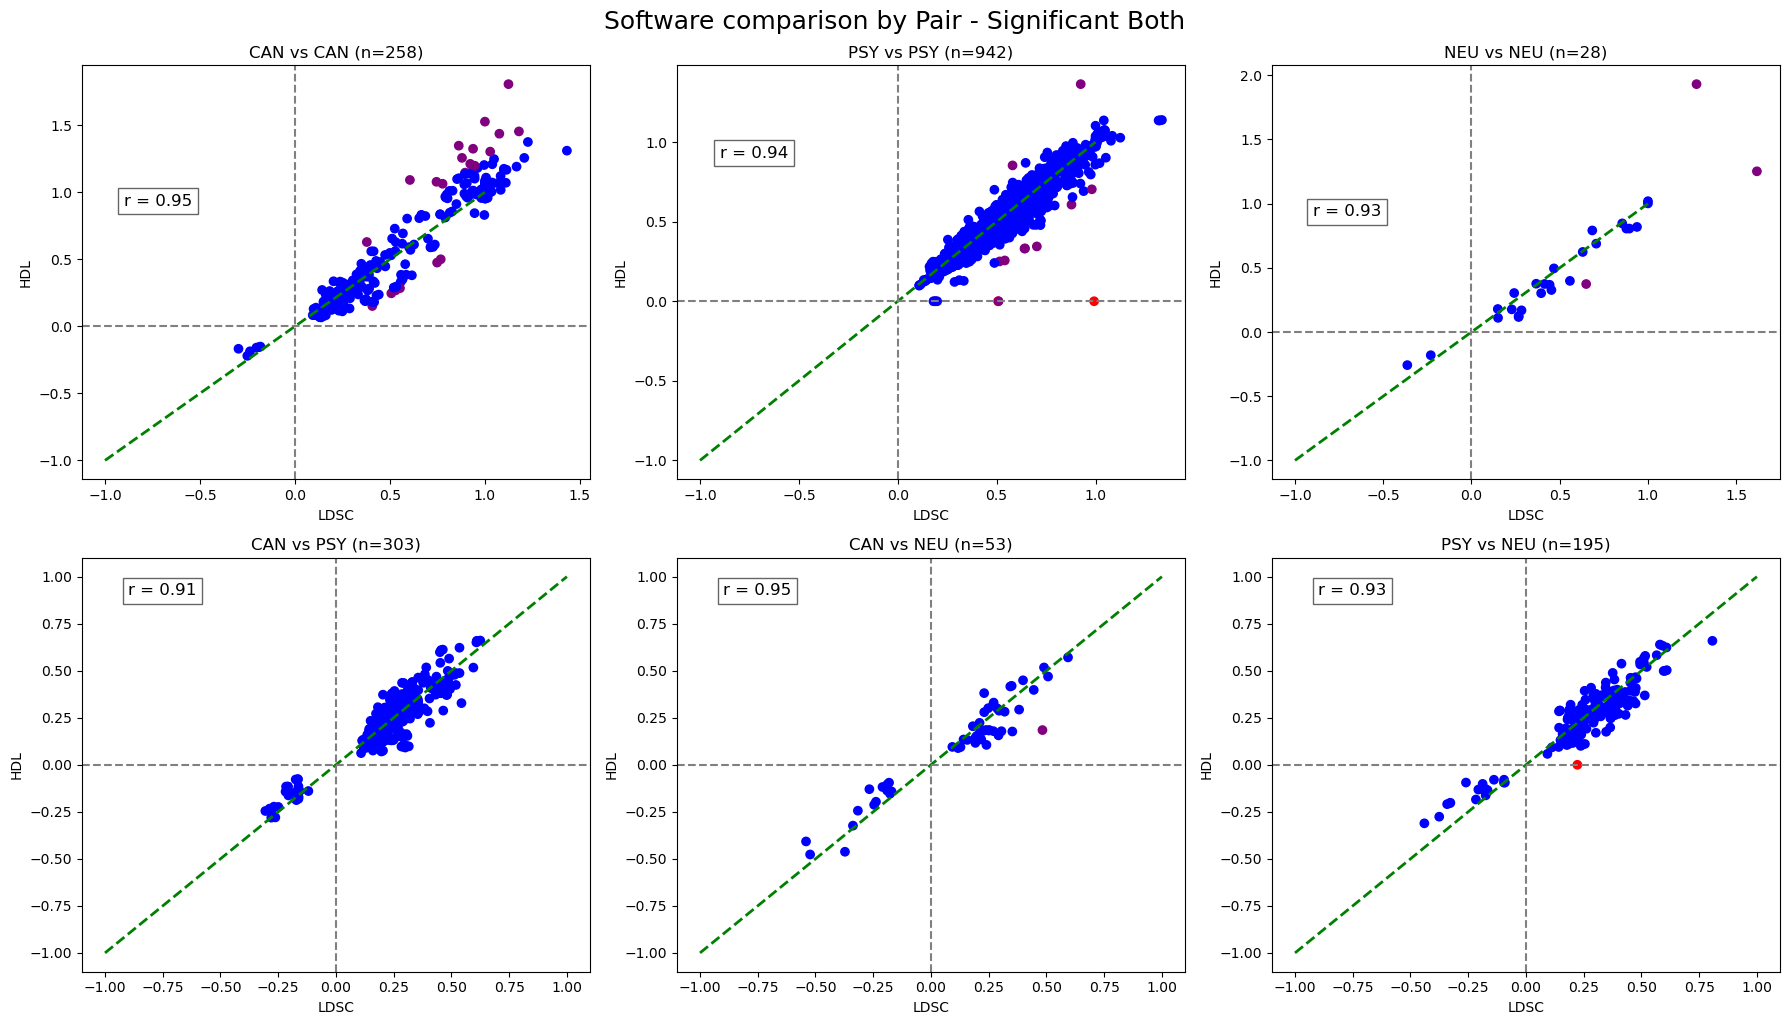

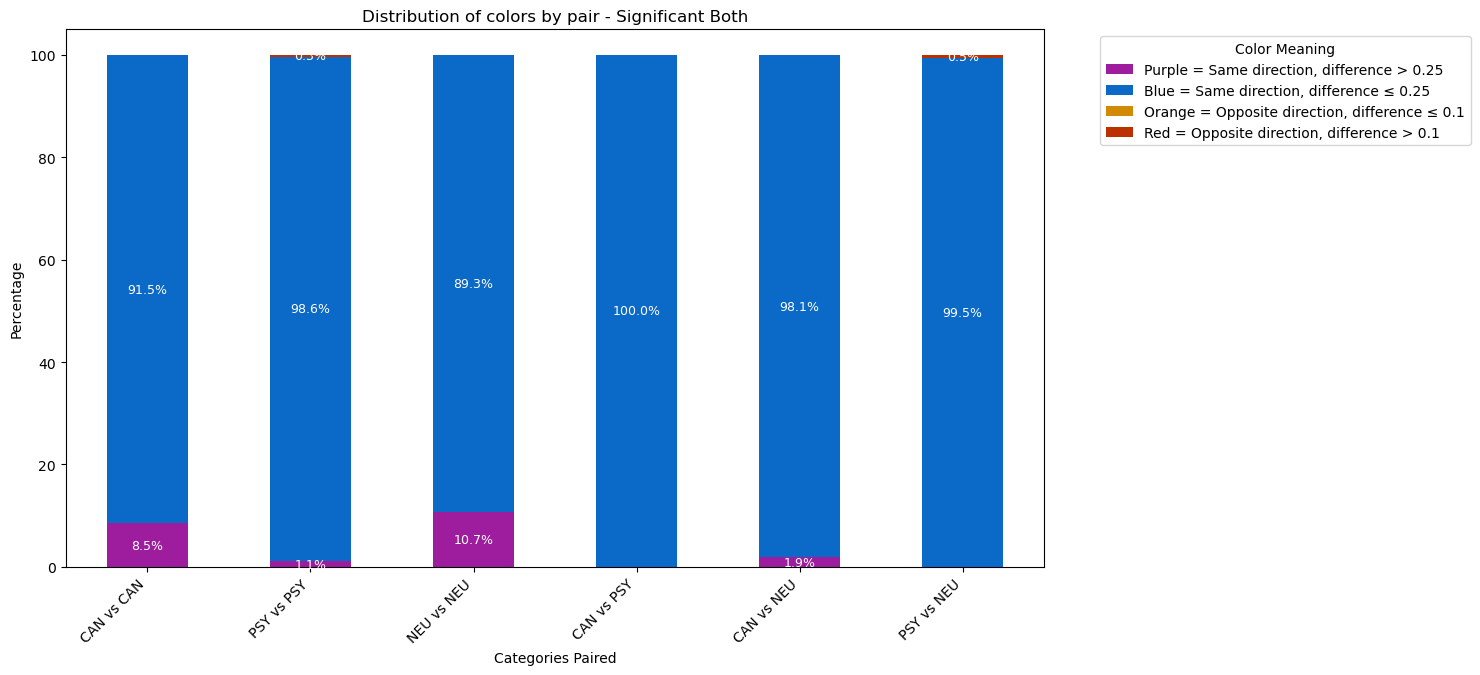

In [197]:
ldsc_hdl_significant_both, table_colors_scatter_both_significant, opposite_colors_both_significant = comparison_scatter_colors(
    df=ldsc_hdl_significant_both,
    selection_name="Significant Both",
    plot_name="significant_both",
    comparison_plots_dir=comparison_plots_dir,
    comparison_tables_dir=comparison_tables_dir,
)

In [30]:
#full display all rows only for this cell
pd.set_option('display.max_rows', None)

ldsc_hdl_significant_either[((ldsc_hdl_significant_either["disease_1"]=="bipolar disorder")&(ldsc_hdl_significant_either["disease_2"]=="epilepsy"))|((ldsc_hdl_significant_either["disease_1"]=="epilepsy")&(ldsc_hdl_significant_either["disease_2"]=="bipolar disorder"))][["label_1", "disease_1", "type_1", "selection_1", "label_2", "disease_2", "type_2", "selection_2",
	"rg_ldsc", "Polarity_ldsc", "p_FDR_rejected_ldsc", "rg_hdl", "Polarity_hdl", "p_FDR_rejected_hdl", "color"]] 

,label_1,disease_1,type_1,selection_1,label_2,disease_2,type_2,selection_2,rg_ldsc,Polarity_ldsc,p_FDR_rejected_ldsc,rg_hdl,Polarity_hdl,p_FDR_rejected_hdl,color
97,BIP-PGC-2011,bipolar disorder,PSY,minor,epilepsy-2,epilepsy,NEU,main,-0.2087,Negative,True,-0.000003,Negative,False,blue
99,BIP-PGC-2011,bipolar disorder,PSY,minor,partial-epilepsy-1,epilepsy,NEU,subtype,-0.2005,Negative,False,-0.000005,Negative,True,blue
6639,BIP-PGC-2021,bipolar disorder,PSY,main,epilepsy-2,epilepsy,NEU,main,-0.1430,Negative,True,-0.050000,Negative,False,blue
6640,BIP-PGC-2021,bipolar disorder,PSY,main,generalised-epilepsy,epilepsy,NEU,subtype,-0.1385,Negative,True,-0.079600,Negative,True,blue
6642,BIP-PGC-2021,bipolar disorder,PSY,main,partial-epilepsy-2,epilepsy,NEU,subtype,-0.1978,Negative,True,-0.063900,Negative,False,blue


In [26]:
ldsc_hdl_significant_either.columns

Index(['id_1', 'label_1', 'type_1', 'disease_1', 'selection_1',
       'disease_subtype_1', 'pubmedId_1', 'id_2', 'label_2', 'disease_2',
       'type_2', 'selection_2', 'disease_subtype_2', 'pubmedId_2', 'rg_ldsc',
       'se_ldsc', 'z', 'p_ldsc', 'p_corrected_bonf_ldsc',
       'p_bonf_rejected_ldsc', 'p_corrected_FDR_ldsc', 'p_FDR_rejected_ldsc',
       'Category', 'Polarity_ldsc', 'Pair', 'rg_hdl', 'se_hdl', 'p_hdl',
       'p_corrected_bonf_hdl', 'p_bonf_rejected_hdl', 'p_corrected_FDR_hdl',
       'p_FDR_rejected_hdl', 'Polarity_hdl', '_merge', 'color'],
      dtype='object')

#### All Main

Number of red points (opposite sign and |difference| > 0.1): 14, percentage: 3.17%
Number of orange points (opposite sign): 50, percentage: 11.34
Number of purple points (|difference| > 0.25): 4, percentage: 0.91%
Number of blue points (same sign, |difference| ≤ 0.25): 373, percentage: 84.58%
The total number of point in the same direction is: 377 and the total number of points in the opposite direction is: 64


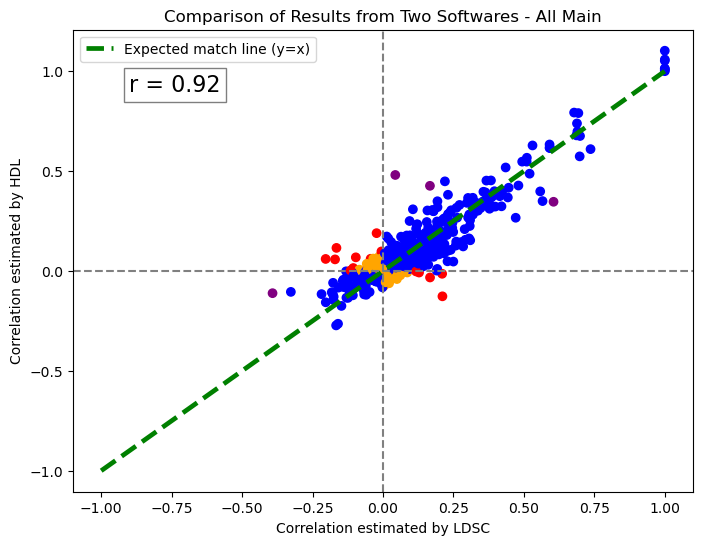

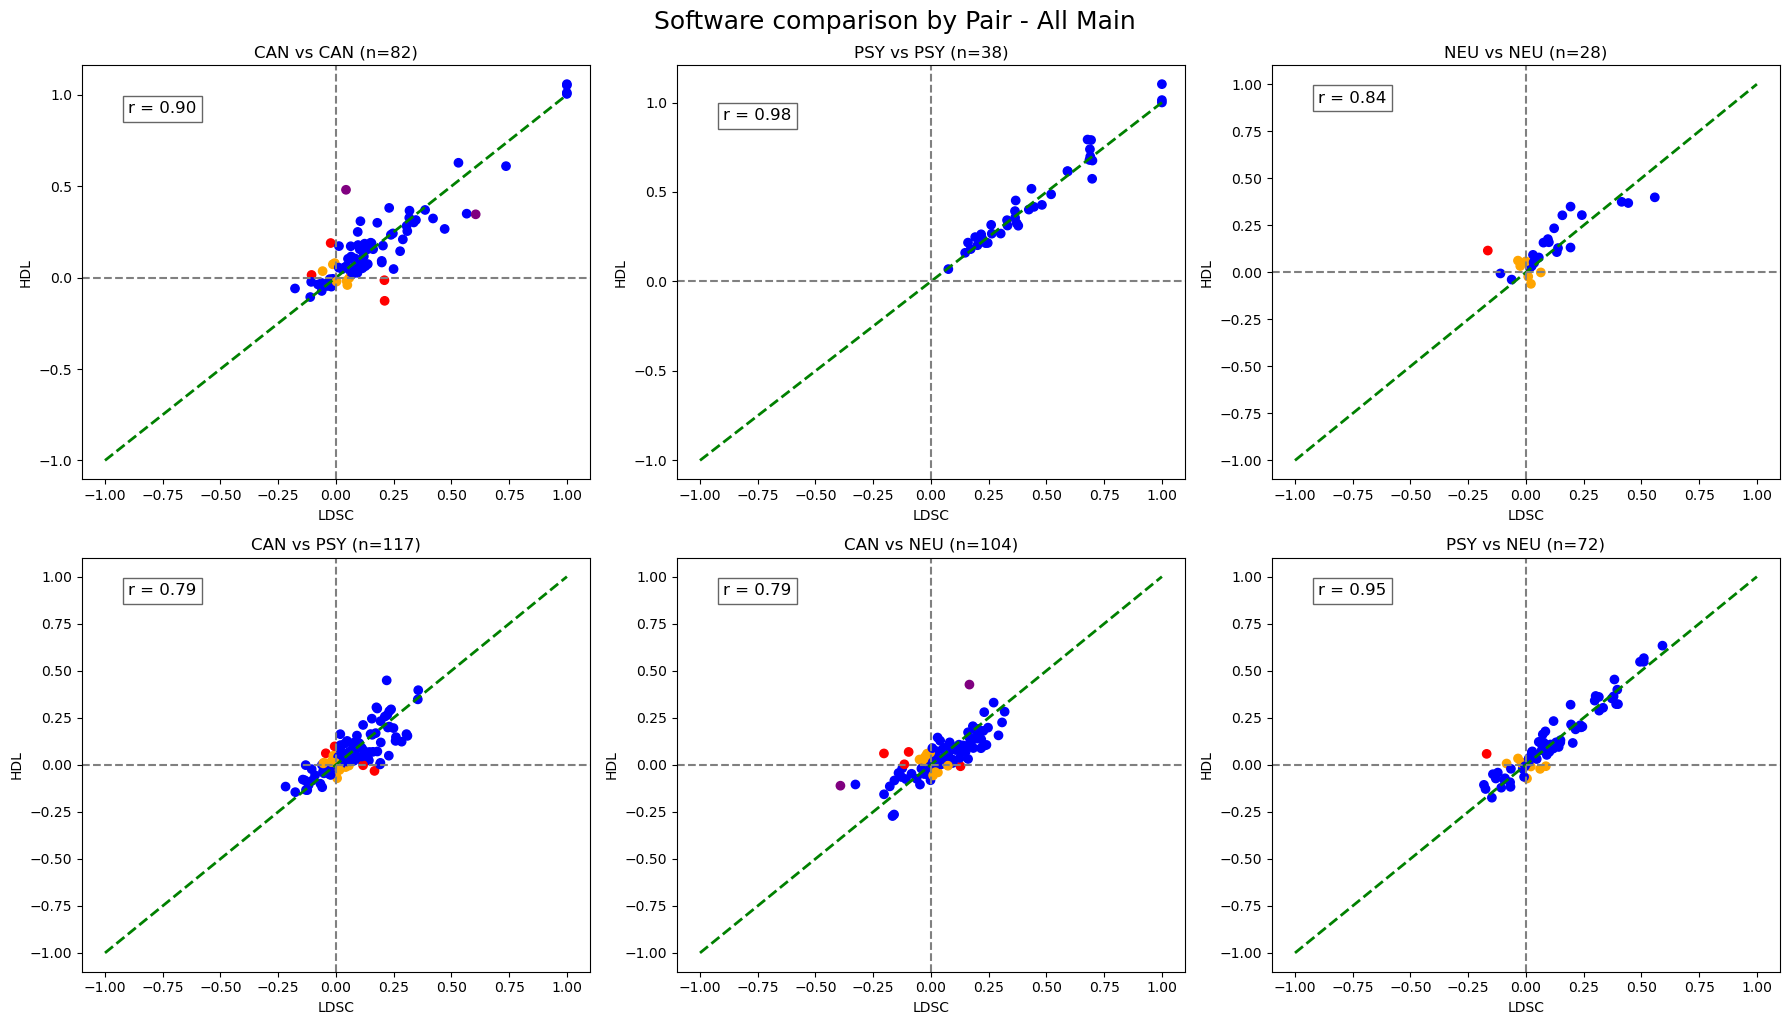

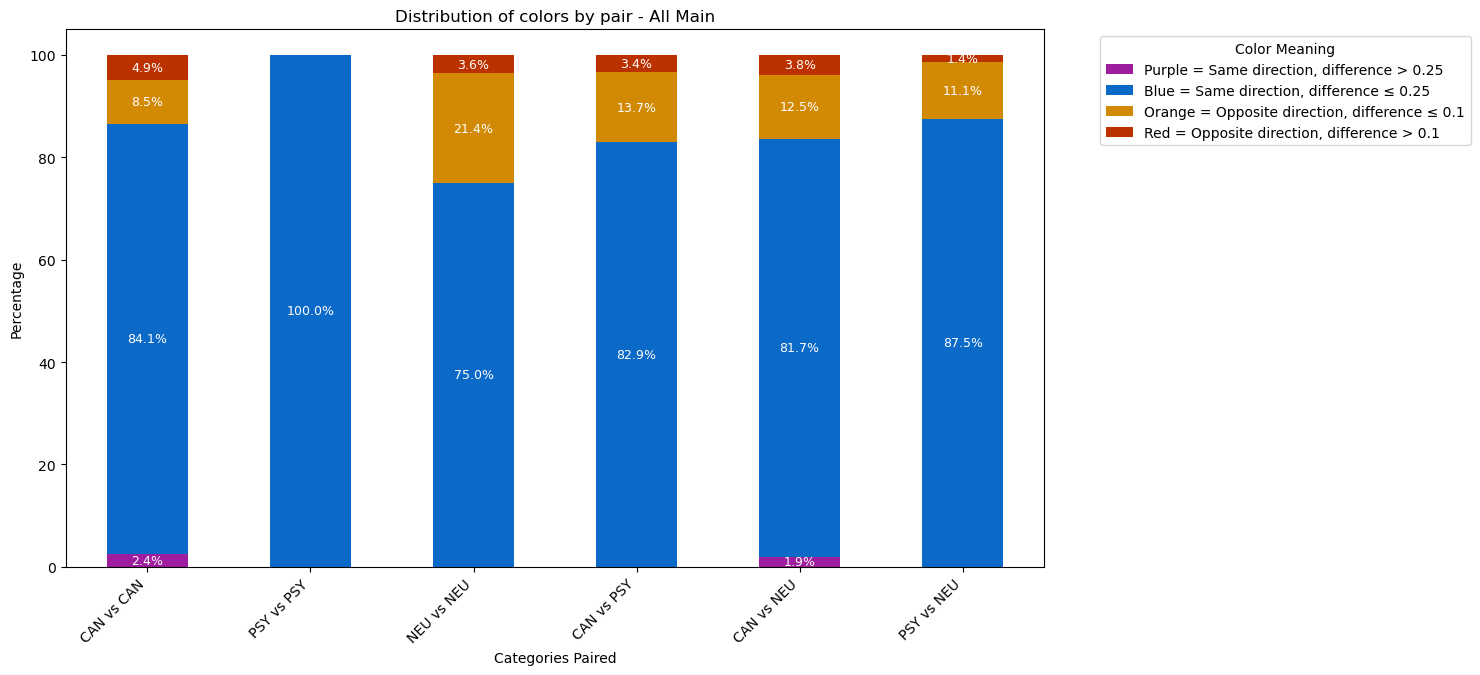

In [194]:
ldsc_hdl_both_main, table_colors_scatter_main, opposite_colors_main = comparison_scatter_colors(
    df=ldsc_hdl_both_main,
    selection_name="All Main",
    plot_name="all_main",
    comparison_plots_dir=comparison_plots_dir,
    comparison_tables_dir=comparison_tables_dir,
)

#### Significant main

Number of red points (opposite sign and |difference| > 0.1): 0, percentage: 0.00%
Number of orange points (opposite sign): 0, percentage: 0.00
Number of purple points (|difference| > 0.25): 2, percentage: 1.20%
Number of blue points (same sign, |difference| ≤ 0.25): 165, percentage: 98.80%
The total number of point in the same direction is: 167 and the total number of points in the opposite direction is: 0


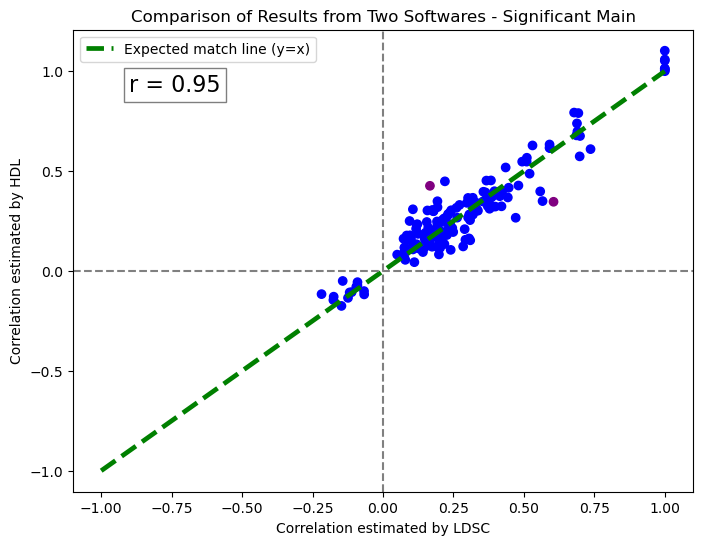

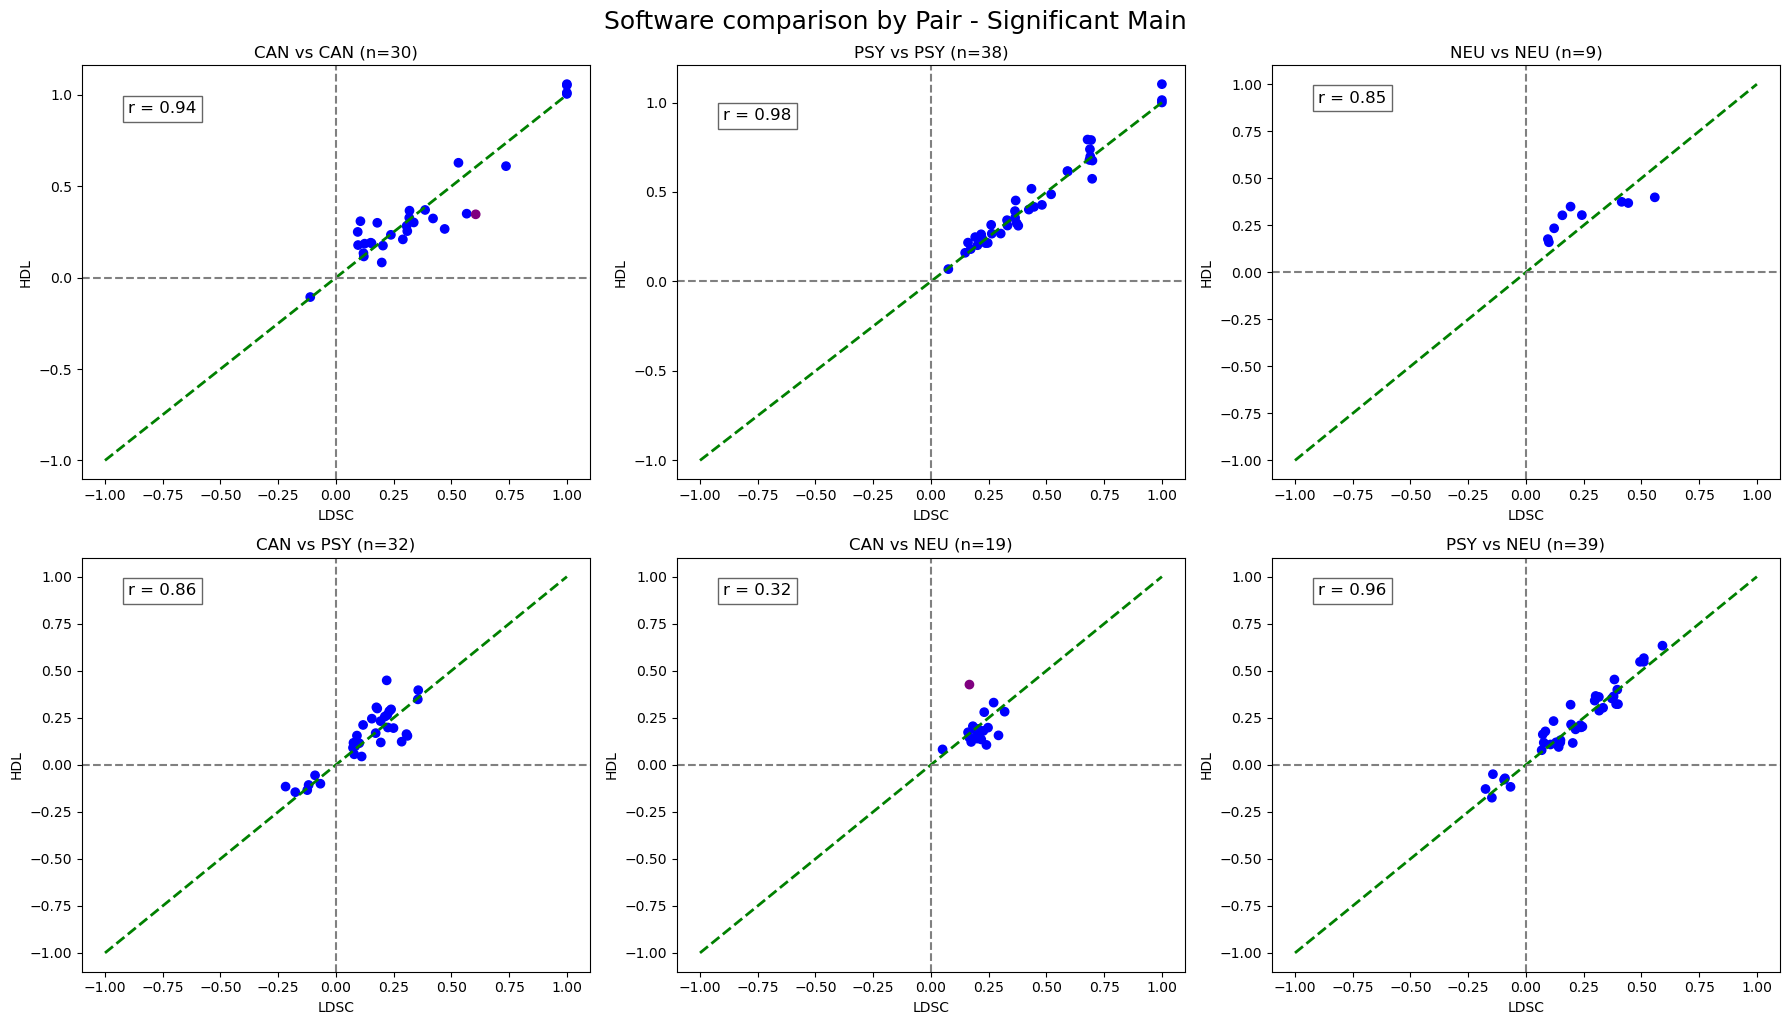

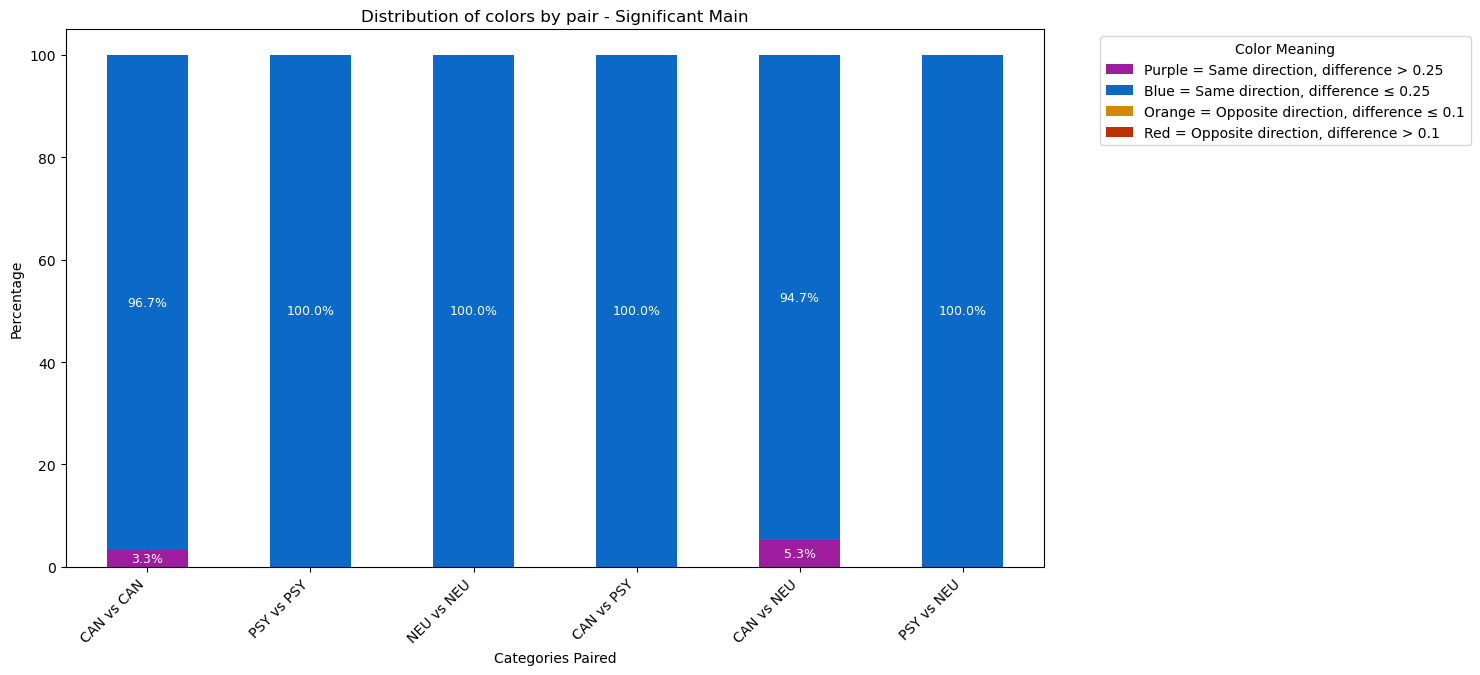

In [195]:
ldsc_hdl_both_main_significant, table_colors_scatter_main_significant, opposite_colors_main_significant = comparison_scatter_colors(
    df=ldsc_hdl_both_main_significant,
    selection_name="Significant Main",
    plot_name="significant_main",
    comparison_plots_dir=comparison_plots_dir,
    comparison_tables_dir=comparison_tables_dir,
)

### Jaccard

#### Simple

In [72]:
A = ldsc_hdl_both["p_FDR_rejected_ldsc"]
print(f"Number of significant pairs in LDSC: {A.sum()}")
B = ldsc_hdl_both["p_FDR_rejected_hdl"]
print(f"Number of significant pairs in HDL: {B.sum()}")

jaccard_all_significant = (A & B).sum() / (A | B).sum()
print(f"Number of pairs significant in both: {(A & B).sum()}")
print(f"Global Jaccard Index for significant pairs: {jaccard_all_significant:.3f}")

Number of significant pairs in LDSC: 1897
Number of significant pairs in HDL: 2419
Number of pairs significant in both: 1779
Global Jaccard Index for significant pairs: 0.701


In [74]:
A = (
    (ldsc_hdl_both["p_FDR_rejected_ldsc"]) &
    (ldsc_hdl_both["rg_ldsc"] > 0)
)
print(f"Number of positive significant pairs in LDSC: {A.sum()}")

B = (
    (ldsc_hdl_both["p_FDR_rejected_hdl"]) &
    (ldsc_hdl_both["rg_hdl"] > 0)
)
print(f"Number of positive significant pairs in HDL: {B.sum()}")

jaccard_positive = (A & B).sum() / (A | B).sum()
print(f"Number of pairs positive significant in both: {(A & B).sum()}")
print(f"Jaccard Index for positive significant correlations: {jaccard_positive:.3f}")

Number of positive significant pairs in LDSC: 1810
Number of positive significant pairs in HDL: 2247
Number of pairs positive significant in both: 1710
Jaccard Index for positive significant correlations: 0.729


In [ ]:
A = (
    (ldsc_hdl_both["p_FDR_rejected_ldsc"]) &
    (ldsc_hdl_both["rg_ldsc"] < 0)
)
print(f"Number of negative significant pairs in LDSC: {A.sum()}")

B = (
    (ldsc_hdl_both["p_FDR_rejected_hdl"]) &
    (ldsc_hdl_both["rg_hdl"] < 0)
)
print(f"Number of negative significant pairs in HDL: {B.sum()}")

jaccard_negative = (A & B).sum() / (A | B).sum()
print(f"Number of pairs negative significant in both: {(A & B).sum()}")
print(f"Jaccard Index for negative significant correlations: {jaccard_negative:.3f}")

Number of negative significant pairs in LDSC: 87
Number of negative significant pairs in HDL: 172
Number of pairs negative significant in both: 65
Jaccard Index for negative significant correlations: 0.335


In [108]:

df = ldsc_hdl_both.copy()
types_order = ["PSY", "CAN", "NEU"]

# Output folder for plots
output_dir = Path(jaccard_plots_dir)
output_dir.mkdir(parents=True, exist_ok=True)

# Unordered type-pair for Part 3
df["type_pair"] = df.apply(
    lambda r: tuple(sorted([r["type_1"], r["type_2"]])),
    axis=1
)

# -------------------------------
# Small helper for Jaccard
# -------------------------------
def jaccard_from_masks(mask_a, mask_b):
    intersection = (mask_a & mask_b).sum()
    union = (mask_a | mask_b).sum()
    jaccard = intersection / union if union != 0 else np.nan
    return intersection, union, jaccard

In [109]:
# ============================================================
# Part 1 - Overall Jaccard (ignoring polarity)
# ============================================================

sig_ldsc = df["p_FDR_rejected_ldsc"]
sig_hdl  = df["p_FDR_rejected_hdl"]

both_sig, union_sig, jaccard_global = jaccard_from_masks(sig_ldsc, sig_hdl)

part1_table = pd.DataFrame([{
    "pairs_significant_ldsc": sig_ldsc.sum(),
    "pairs_significant_hdl": sig_hdl.sum(),
    "pairs_significant_in_both": both_sig,
    "jaccard_index": jaccard_global
}])

print(f"Number of significant pairs in LDSC: {sig_ldsc.sum()}")
print(f"Number of significant pairs in HDL: {sig_hdl.sum()}")
print(f"Number of significant pairs in both: {both_sig}")
print(f"Global Jaccard Index for significant pairs: {jaccard_global:.3f}")

part1_table

Number of significant pairs in LDSC: 1897
Number of significant pairs in HDL: 2419
Number of significant pairs in both: 1779
Global Jaccard Index for significant pairs: 0.701


,pairs_significant_ldsc,pairs_significant_hdl,pairs_significant_in_both,jaccard_index
0,1897,2419,1779,0.701222


In [111]:
# ============================================================
# Part 2 - Significant pairs by polarity
# ============================================================

# Non-exclusive polarity masks
pos_ldsc = df["p_FDR_rejected_ldsc"] & (df["rg_ldsc"] > 0)
neg_ldsc = df["p_FDR_rejected_ldsc"] & (df["rg_ldsc"] < 0)

pos_hdl = df["p_FDR_rejected_hdl"] & (df["rg_hdl"] > 0)
neg_hdl = df["p_FDR_rejected_hdl"] & (df["rg_hdl"] < 0)

rows = []
for label, mask_ldsc, mask_hdl in [
    ("Positive", pos_ldsc, pos_hdl),
    ("Negative", neg_ldsc, neg_hdl)
]:
    both, union, jacc = jaccard_from_masks(mask_ldsc, mask_hdl)
    rows.append({
        "polarity": label,
        "significant_ldsc": mask_ldsc.sum(),
        "significant_hdl": mask_hdl.sum(),
        "significant_in_both": both,
        "jaccard_index": jacc
    })

part2_table = pd.DataFrame(rows)
part2_table

,polarity,significant_ldsc,significant_hdl,significant_in_both,jaccard_index
0,Positive,1810,2247,1710,0.728590
1,Negative,87,172,65,0.335052


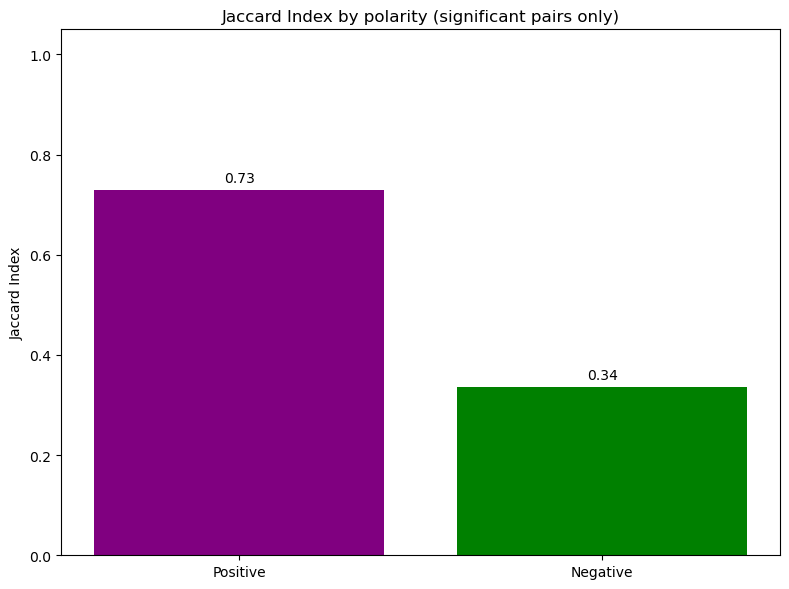

In [112]:
# Bar plot of Jaccard by polarity
plt.figure(figsize=(8, 6))

plot_df = part2_table.copy()
colors = ["purple", "green"]

bars = plt.bar(
    plot_df["polarity"],
    plot_df["jaccard_index"],
    color=colors
)

for bar, value in zip(bars, plot_df["jaccard_index"]):
    txt = f"{value:.2f}" if pd.notna(value) else "NA"
    y = value if pd.notna(value) else 0
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.01, txt, ha="center", va="bottom")

plt.ylim(0, 1.05)
plt.ylabel("Jaccard Index")
plt.title("Jaccard Index by polarity (significant pairs only)")
plt.tight_layout()

plt.savefig(output_dir / "part2_jaccard_by_polarity.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "part2_jaccard_by_polarity.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [113]:
# ============================================================
# Part 3 - Jaccard by type and polarity
# Includes raw count tables for manual checking
# ============================================================

part3_global_table   = pd.DataFrame(index=types_order, columns=types_order, dtype=float)
part3_positive_table = pd.DataFrame(index=types_order, columns=types_order, dtype=float)
part3_negative_table = pd.DataFrame(index=types_order, columns=types_order, dtype=float)

global_rows = []
positive_rows = []
negative_rows = []

for t1 in types_order:
    for t2 in types_order:
        pair = tuple(sorted([t1, t2]))
        sub = df[df["type_pair"] == pair].copy()

        # -------------------------------
        # Global
        # -------------------------------
        mask_ldsc_global = sub["p_FDR_rejected_ldsc"]
        mask_hdl_global  = sub["p_FDR_rejected_hdl"]

        both_global, union_global, j_global = jaccard_from_masks(mask_ldsc_global, mask_hdl_global)

        part3_global_table.loc[t1, t2] = j_global

        global_rows.append({
            "type_1": t1,
            "type_2": t2,
            "n_pairs": len(sub),
            "significant_ldsc": mask_ldsc_global.sum(),
            "significant_hdl": mask_hdl_global.sum(),
            "significant_in_both": both_global,
            "union": union_global,
            "jaccard_index": j_global
        })

        # -------------------------------
        # Positive
        # -------------------------------
        mask_ldsc_pos = sub["p_FDR_rejected_ldsc"] & (sub["rg_ldsc"] > 0)
        mask_hdl_pos  = sub["p_FDR_rejected_hdl"] & (sub["rg_hdl"] > 0)

        both_pos, union_pos, j_pos = jaccard_from_masks(mask_ldsc_pos, mask_hdl_pos)

        part3_positive_table.loc[t1, t2] = j_pos

        positive_rows.append({
            "type_1": t1,
            "type_2": t2,
            "n_pairs": len(sub),
            "significant_positive_ldsc": mask_ldsc_pos.sum(),
            "significant_positive_hdl": mask_hdl_pos.sum(),
            "significant_positive_in_both": both_pos,
            "union": union_pos,
            "jaccard_index": j_pos
        })

        # -------------------------------
        # Negative
        # -------------------------------
        mask_ldsc_neg = sub["p_FDR_rejected_ldsc"] & (sub["rg_ldsc"] < 0)
        mask_hdl_neg  = sub["p_FDR_rejected_hdl"] & (sub["rg_hdl"] < 0)

        both_neg, union_neg, j_neg = jaccard_from_masks(mask_ldsc_neg, mask_hdl_neg)

        part3_negative_table.loc[t1, t2] = j_neg

        negative_rows.append({
            "type_1": t1,
            "type_2": t2,
            "n_pairs": len(sub),
            "significant_negative_ldsc": mask_ldsc_neg.sum(),
            "significant_negative_hdl": mask_hdl_neg.sum(),
            "significant_negative_in_both": both_neg,
            "union": union_neg,
            "jaccard_index": j_neg
        })

# Raw count tables
part3_global_counts = pd.DataFrame(global_rows)
part3_positive_counts = pd.DataFrame(positive_rows)
part3_negative_counts = pd.DataFrame(negative_rows)

print("Global Jaccard by type")
display(part3_global_table)

print("Positive Jaccard by type")
display(part3_positive_table)

print("Negative Jaccard by type")
display(part3_negative_table)

print("Raw counts behind GLOBAL type-level Jaccard")
display(part3_global_counts)

print("Raw counts behind POSITIVE type-level Jaccard")
display(part3_positive_counts)

print("Raw counts behind NEGATIVE type-level Jaccard")
display(part3_negative_counts)

Global Jaccard by type


,PSY,CAN,NEU
PSY,0.940120,0.539146,0.561960
CAN,0.539146,0.565789,0.427419
NEU,0.561960,0.427419,0.608696


Positive Jaccard by type


,PSY,CAN,NEU
PSY,0.941825,0.573770,0.612676
CAN,0.573770,0.574032,0.402062
NEU,0.612676,0.402062,0.619048


Negative Jaccard by type


...

,type_1,type_2,n_pairs,significant_ldsc,significant_hdl,significant_in_both,union,jaccard_index
0,PSY,PSY,1050,972,972,942,1002,0.940120
1,PSY,CAN,2162,336,529,303,562,0.539146
2,PSY,NEU,736,206,336,195,347,0.561960
3,CAN,PSY,2162,336,529,303,562,0.539146
4,CAN,CAN,1082,285,429,258,456,0.565789
5,CAN,NEU,752,69,108,53,124,0.427419
6,NEU,PSY,736,206,336,195,347,0.561960
7,NEU,CAN,752,69,108,53,124,0.427419
8,NEU,NEU,122,29,45,28,46,0.608696


Raw counts behind POSITIVE type-level Jaccard


,type_1,type_2,n_pairs,significant_positive_ldsc,significant_positive_hdl,significant_positive_in_both,union,jaccard_index
0,PSY,PSY,1050,972,964,939,997,0.941825
1,PSY,CAN,2162,304,464,280,488,0.573770
2,PSY,NEU,736,178,280,174,284,0.612676
3,CAN,PSY,2162,304,464,280,488,0.573770
4,CAN,CAN,1082,279,412,252,439,0.574032
5,CAN,NEU,752,51,85,39,97,0.402062
6,NEU,PSY,736,178,280,174,284,0.612676
7,NEU,CAN,752,51,85,39,97,0.402062
8,NEU,NEU,122,26,42,26,42,0.619048


Raw counts behind NEGATIVE type-level Jaccard


,type_1,type_2,n_pairs,significant_negative_ldsc,significant_negative_hdl,significant_negative_in_both,union,jaccard_index
0,PSY,PSY,1050,0,8,0,8,0.000000
1,PSY,CAN,2162,32,65,23,74,0.310811
2,PSY,NEU,736,28,56,20,64,0.312500
3,CAN,PSY,2162,32,65,23,74,0.310811
4,CAN,CAN,1082,6,17,6,17,0.352941
5,CAN,NEU,752,18,23,14,27,0.518519
6,NEU,PSY,736,28,56,20,64,0.312500
7,NEU,CAN,752,18,23,14,27,0.518519
8,NEU,NEU,122,3,3,2,4,0.500000


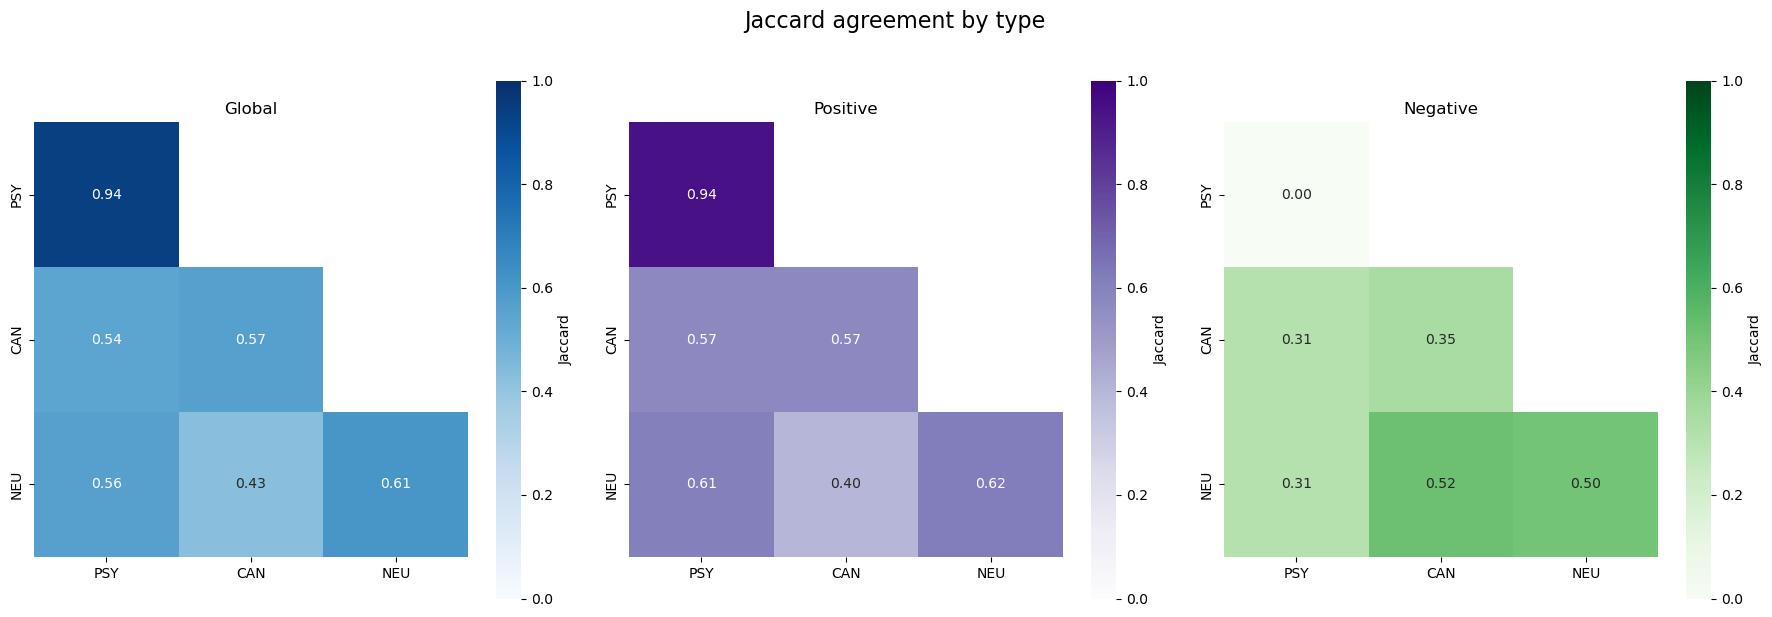

In [114]:
mask_upper = np.triu(np.ones_like(part3_global_table, dtype=bool), k=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.heatmap(
    part3_global_table,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=0,
    vmax=1,
    mask=mask_upper | part3_global_table.isna(),
    square=True,
    cbar=True,
    cbar_kws={"label": "Jaccard"}
)
axes[0].set_title("Global")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    part3_positive_table,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="Purples",
    vmin=0,
    vmax=1,
    mask=mask_upper | part3_positive_table.isna(),
    square=True,
    cbar=True,
    cbar_kws={"label": "Jaccard"}
)
axes[1].set_title("Positive")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

sns.heatmap(
    part3_negative_table,
    ax=axes[2],
    annot=True,
    fmt=".2f",
    cmap="Greens",
    vmin=0,
    vmax=1,
    mask=mask_upper | part3_negative_table.isna(),
    square=True,
    cbar=True,
    cbar_kws={"label": "Jaccard"}
)
axes[2].set_title("Negative")
axes[2].set_xlabel("")
axes[2].set_ylabel("")

fig.suptitle("Jaccard agreement by type", fontsize=16, y=1.02)
plt.tight_layout()

plt.savefig(output_dir / "part3_jaccard_by_type.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "part3_jaccard_by_type.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# ============================================================
# Part 4 - Global Jaccard by disease
# ============================================================

all_diseases = pd.unique(pd.concat([df["disease_1"], df["disease_2"]], axis=0))

rows = []
for disease in all_diseases:
    sub = df[(df["disease_1"] == disease) | (df["disease_2"] == disease)].copy()

    both, union, jacc = jaccard_from_masks(sub["p_FDR_rejected_ldsc"], sub["p_FDR_rejected_hdl"])

    rows.append({
        "disease": disease,
        "total_pairs_containing_disease": len(sub),
        "significant_ldsc": sub["p_FDR_rejected_ldsc"].sum(),
        "significant_hdl": sub["p_FDR_rejected_hdl"].sum(),
        "significant_in_both": both,
        "jaccard_index": jacc
    })

part4_table = pd.DataFrame(rows).sort_values("jaccard_index", ascending=False, na_position="last").reset_index(drop=True)
part4_table

,disease,total_pairs_containing_disease,significant_ldsc,significant_hdl,significant_in_both,jaccard_index
0,attention deficit disorder,427,267,311,267,0.858521
1,peripheral nervous system disease,108,46,50,44,0.846154
2,mood disorder,107,61,71,60,0.833333
3,major depression disorder,1611,760,854,731,0.827860
4,anxiety,939,417,484,407,0.823887
5,autism,428,189,214,182,0.823529
6,melanoma,108,14,13,12,0.800000
7,post-traumatic stress disorder,108,51,64,51,0.796875
8,anorexia nervosa,108,40,48,39,0.795918
9,renal cancer,109,55,68,54,0.782609


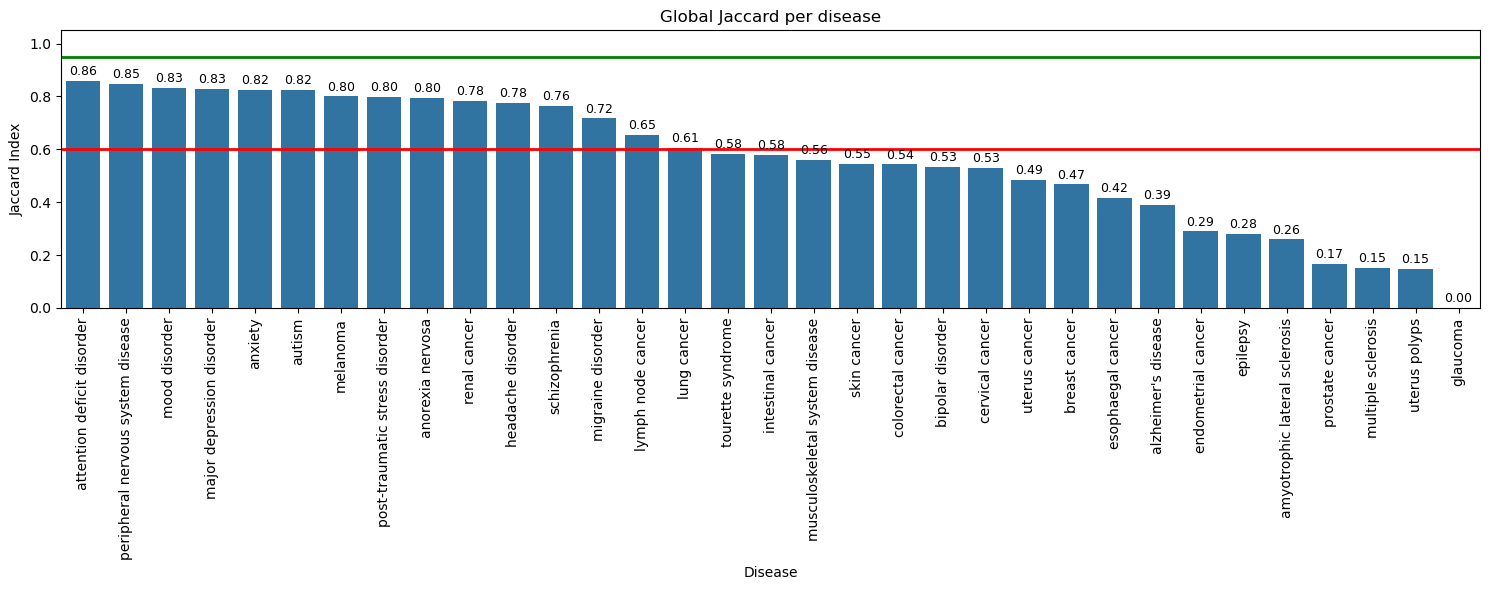

In [116]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(
    data=part4_table,
    x="disease",
    y="jaccard_index",
    order=part4_table["disease"],
    errorbar=None
)

ax.axhline(0.95, color="green", linewidth=2)
ax.axhline(0.60, color="red", linewidth=2)

ax.set_ylim(0, 1.05)
ax.set_title("Global Jaccard per disease")
ax.set_xlabel("Disease")
ax.set_ylabel("Jaccard Index")
ax.tick_params(axis="x", rotation=90)

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height():.2f}" if pd.notna(v.get_height()) else "NA" for v in container],
        padding=2,
        fontsize=9
    )

plt.tight_layout()
plt.savefig(output_dir / "part4_global_jaccard_by_disease.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "part4_global_jaccard_by_disease.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [117]:
# ============================================================
# Part 5 - Positive and negative Jaccard by disease
# ============================================================

# Keep the same disease order as Part 4
disease_order = part4_table["disease"].tolist()

rows_pos = []
rows_neg = []

for disease in disease_order:
    sub = df[(df["disease_1"] == disease) | (df["disease_2"] == disease)].copy()

    # Positive
    pos_ldsc = sub["p_FDR_rejected_ldsc"] & (sub["rg_ldsc"] > 0)
    pos_hdl  = sub["p_FDR_rejected_hdl"] & (sub["rg_hdl"] > 0)
    both_pos, union_pos, jacc_pos = jaccard_from_masks(pos_ldsc, pos_hdl)

    rows_pos.append({
        "disease": disease,
        "total_pairs_containing_disease": len(sub),
        "significant_positive_ldsc": pos_ldsc.sum(),
        "significant_positive_hdl": pos_hdl.sum(),
        "significant_positive_in_both": both_pos,
        "jaccard_positive": jacc_pos
    })

    # Negative
    neg_ldsc = sub["p_FDR_rejected_ldsc"] & (sub["rg_ldsc"] < 0)
    neg_hdl  = sub["p_FDR_rejected_hdl"] & (sub["rg_hdl"] < 0)
    both_neg, union_neg, jacc_neg = jaccard_from_masks(neg_ldsc, neg_hdl)

    rows_neg.append({
        "disease": disease,
        "total_pairs_containing_disease": len(sub),
        "significant_negative_ldsc": neg_ldsc.sum(),
        "significant_negative_hdl": neg_hdl.sum(),
        "significant_negative_in_both": both_neg,
        "jaccard_negative": jacc_neg
    })

part5_positive_table = pd.DataFrame(rows_pos)
part5_negative_table = pd.DataFrame(rows_neg)

print("Positive table")
display(part5_positive_table)

print("Negative table")
display(part5_negative_table)

Positive table


,disease,total_pairs_containing_disease,significant_positive_ldsc,significant_positive_hdl,significant_positive_in_both,jaccard_positive
0,attention deficit disorder,427,256,290,256,0.882759
1,peripheral nervous system disease,108,39,42,37,0.840909
2,mood disorder,107,61,68,60,0.869565
3,major depression disorder,1611,744,817,717,0.849526
4,anxiety,939,413,471,404,0.841667
5,autism,428,184,197,177,0.867647
6,melanoma,108,8,8,8,1.000000
7,post-traumatic stress disorder,108,51,62,51,0.822581
8,anorexia nervosa,108,38,44,38,0.863636
9,renal cancer,109,53,65,52,0.787879


Negative table


,disease,total_pairs_containing_disease,significant_negative_ldsc,significant_negative_hdl,significant_negative_in_both,jaccard_negative
0,attention deficit disorder,427,11,21,11,0.523810
1,peripheral nervous system disease,108,7,8,7,0.875000
2,mood disorder,107,0,3,0,0.000000
3,major depression disorder,1611,16,37,14,0.358974
4,anxiety,939,4,13,2,0.133333
5,autism,428,5,17,4,0.222222
6,melanoma,108,6,5,4,0.571429
7,post-traumatic stress disorder,108,0,2,0,0.000000
8,anorexia nervosa,108,2,4,1,0.200000
9,renal cancer,109,2,3,2,0.666667


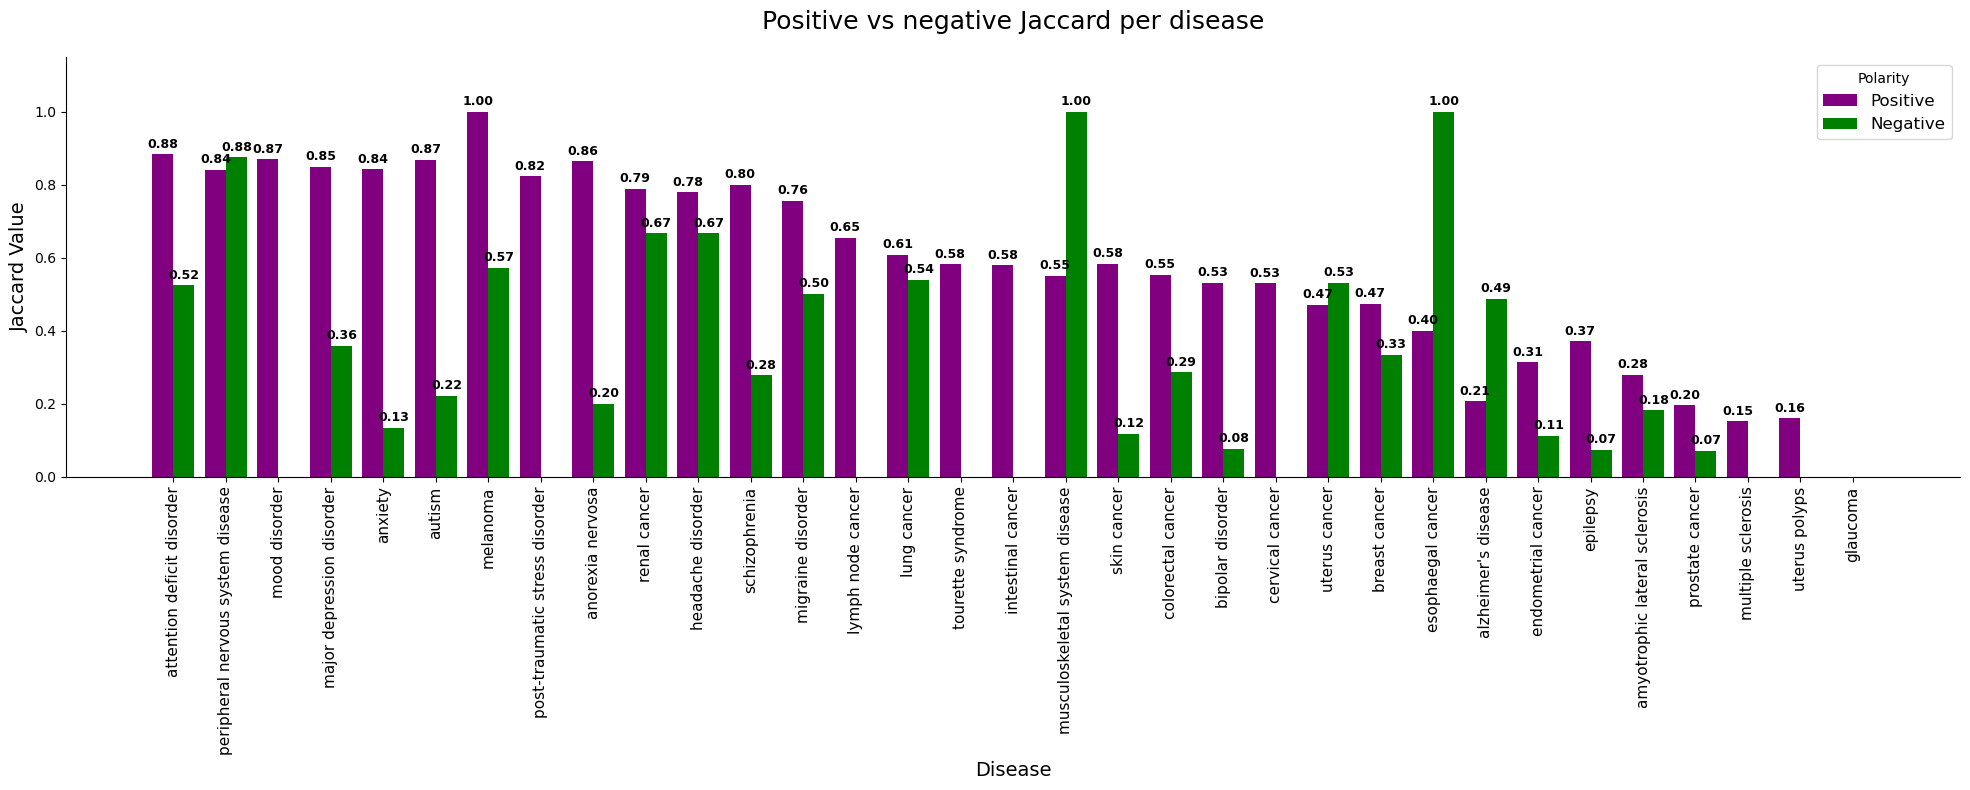

In [118]:
plot5_df = part5_positive_table[["disease", "jaccard_positive"]].merge(
    part5_negative_table[["disease", "jaccard_negative"]],
    on="disease",
    how="inner"
)

plot5_df = plot5_df.set_index("disease").loc[disease_order].reset_index()
plot5_df[["jaccard_positive", "jaccard_negative"]] = plot5_df[["jaccard_positive", "jaccard_negative"]].fillna(0)

plt.figure(figsize=(max(14, 0.6 * len(disease_order)), 8))
ax = plt.gca()

x = np.arange(len(disease_order))
width = 0.4

pos_vals = plot5_df["jaccard_positive"].to_numpy()
neg_vals = plot5_df["jaccard_negative"].to_numpy()

ax.bar(x - width/2, pos_vals, width, label="Positive", color="purple", edgecolor="none")
ax.bar(x + width/2, neg_vals, width, label="Negative", color="green", edgecolor="none")

for i in range(len(disease_order)):
    if pos_vals[i] > 0:
        ax.text(
            i - width/2,
            pos_vals[i] + 0.01,
            f"{pos_vals[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            fontweight="bold"
        )
    if neg_vals[i] > 0:
        ax.text(
            i + width/2,
            neg_vals[i] + 0.01,
            f"{neg_vals[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            fontweight="bold"
        )

ax.set_ylim(0, 1.15)
ax.set_title("Positive vs negative Jaccard per disease", fontsize=18, pad=20)
ax.set_xlabel("Disease", fontsize=14)
ax.set_ylabel("Jaccard Value", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(disease_order, rotation=90, fontsize=11)
ax.legend(title="Polarity", frameon=True, fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(output_dir / "part5_positive_negative_jaccard_by_disease.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "part5_positive_negative_jaccard_by_disease.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [119]:
# ============================================================
# Part 5 - Positive and negative Jaccard by disease
# ============================================================

# Keep the same disease order as Part 4
disease_order = part4_table["disease"].tolist()

rows_pos = []
rows_neg = []

for disease in disease_order:
    sub = df[(df["disease_1"] == disease) | (df["disease_2"] == disease)].copy()

    # Positive
    pos_ldsc = sub["rg_ldsc"] > 0
    pos_hdl  = sub["rg_hdl"] > 0
    both_pos, union_pos, jacc_pos = jaccard_from_masks(pos_ldsc, pos_hdl)

    rows_pos.append({
        "disease": disease,
        "total_pairs_containing_disease": len(sub),
        "significant_positive_ldsc": pos_ldsc.sum(),
        "significant_positive_hdl": pos_hdl.sum(),
        "significant_positive_in_both": both_pos,
        "jaccard_positive": jacc_pos
    })

    # Negative
    neg_ldsc = sub["rg_ldsc"] < 0
    neg_hdl  = sub["rg_hdl"] < 0
    both_neg, union_neg, jacc_neg = jaccard_from_masks(neg_ldsc, neg_hdl)

    rows_neg.append({
        "disease": disease,
        "total_pairs_containing_disease": len(sub),
        "significant_negative_ldsc": neg_ldsc.sum(),
        "significant_negative_hdl": neg_hdl.sum(),
        "significant_negative_in_both": both_neg,
        "jaccard_negative": jacc_neg
    })

part5_positive_table = pd.DataFrame(rows_pos)
part5_negative_table = pd.DataFrame(rows_neg)

print("Positive table")
display(part5_positive_table)

print("Negative table")
display(part5_negative_table)

Positive table


,disease,total_pairs_containing_disease,significant_positive_ldsc,significant_positive_hdl,significant_positive_in_both,jaccard_positive
0,attention deficit disorder,427,384,373,369,0.951031
1,peripheral nervous system disease,108,71,77,68,0.850000
2,mood disorder,107,97,95,93,0.939394
3,major depression disorder,1611,1288,1288,1198,0.869376
4,anxiety,939,740,764,699,0.868323
5,autism,428,295,295,268,0.832298
6,melanoma,108,50,55,45,0.750000
7,post-traumatic stress disorder,108,89,92,87,0.925532
8,anorexia nervosa,108,72,73,65,0.812500
9,renal cancer,109,95,98,93,0.930000


Negative table


,disease,total_pairs_containing_disease,significant_negative_ldsc,significant_negative_hdl,significant_negative_in_both,jaccard_negative
0,attention deficit disorder,427,43,54,39,0.672414
1,peripheral nervous system disease,108,37,31,28,0.700000
2,mood disorder,107,10,12,8,0.571429
3,major depression disorder,1611,323,323,233,0.564165
4,anxiety,939,199,175,134,0.558333
5,autism,428,133,133,106,0.662500
6,melanoma,108,58,53,48,0.761905
7,post-traumatic stress disorder,108,19,16,14,0.666667
8,anorexia nervosa,108,36,35,28,0.651163
9,renal cancer,109,14,11,9,0.562500


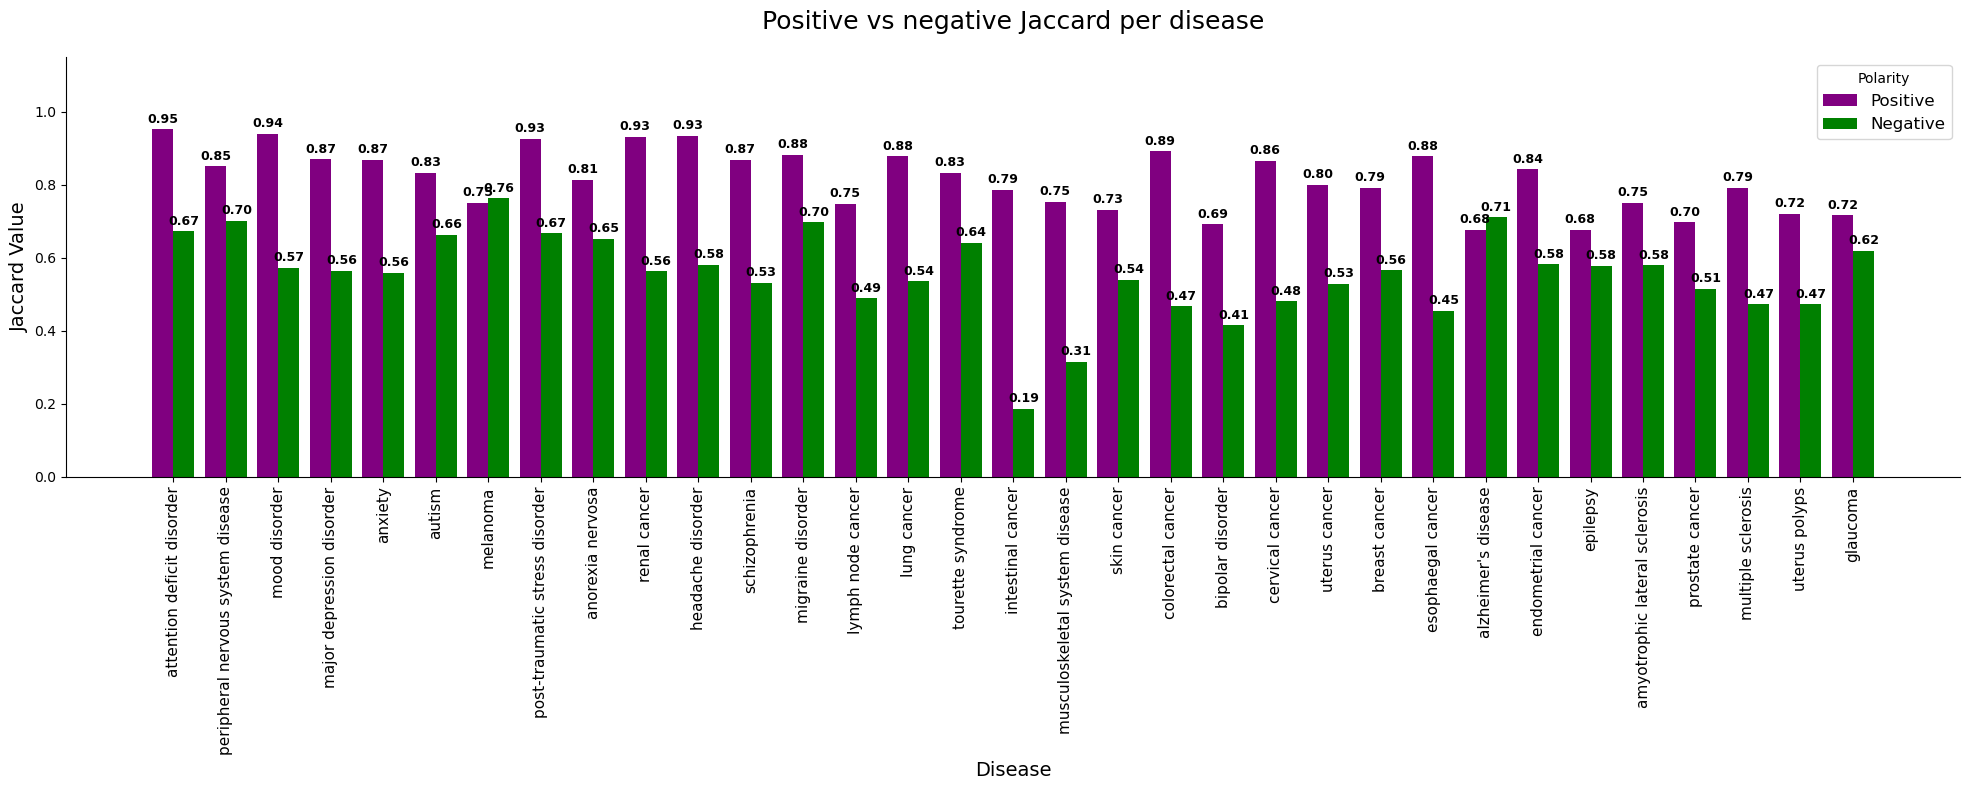

In [120]:
plot5_df = part5_positive_table[["disease", "jaccard_positive"]].merge(
    part5_negative_table[["disease", "jaccard_negative"]],
    on="disease",
    how="inner"
)

plot5_df = plot5_df.set_index("disease").loc[disease_order].reset_index()
plot5_df[["jaccard_positive", "jaccard_negative"]] = plot5_df[["jaccard_positive", "jaccard_negative"]].fillna(0)

plt.figure(figsize=(max(14, 0.6 * len(disease_order)), 8))
ax = plt.gca()

x = np.arange(len(disease_order))
width = 0.4

pos_vals = plot5_df["jaccard_positive"].to_numpy()
neg_vals = plot5_df["jaccard_negative"].to_numpy()

ax.bar(x - width/2, pos_vals, width, label="Positive", color="purple", edgecolor="none")
ax.bar(x + width/2, neg_vals, width, label="Negative", color="green", edgecolor="none")

for i in range(len(disease_order)):
    if pos_vals[i] > 0:
        ax.text(
            i - width/2,
            pos_vals[i] + 0.01,
            f"{pos_vals[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            fontweight="bold"
        )
    if neg_vals[i] > 0:
        ax.text(
            i + width/2,
            neg_vals[i] + 0.01,
            f"{neg_vals[i]:.2f}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            fontweight="bold"
        )

ax.set_ylim(0, 1.15)
ax.set_title("Positive vs negative Jaccard per disease", fontsize=18, pad=20)
ax.set_xlabel("Disease", fontsize=14)
ax.set_ylabel("Jaccard Value", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(disease_order, rotation=90, fontsize=11)
ax.legend(title="Polarity", frameon=True, fontsize=12)

sns.despine()
plt.tight_layout()

plt.savefig(output_dir / "part5_positive_negative_jaccard_by_disease.png", dpi=300, bbox_inches="tight")
plt.savefig(output_dir / "part5_positive_negative_jaccard_by_disease.jpg", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

### Function OLD VERSIONS

In [78]:
"""
============================================================
Helpers
============================================================
"""

def _savefig(output_dir, filename, dpi=300):
    """Create output_dir if needed and save the current Matplotlib figure there."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    path = output_dir / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    return str(path)


def _disease_order_by_frequency(df):
    """
    Order diseases by how often they appear in the dataframe (disease_1 or disease_2),
    from most frequent to least frequent.
    """
    s = pd.concat([df["disease_1"], df["disease_2"]], axis=0)
    return s.value_counts().index.tolist()


def _subset_for_typepair(df, t1, t2):
    """Subset rows matching an unordered (type_1, type_2) pair."""
    pair = tuple(sorted([t1, t2]))
    return df[df["type_pair"] == pair].copy()


def _subset_for_disease(df, disease):
    """Subset rows where 'disease' appears in either disease_1 or disease_2."""
    return df[(df["disease_1"] == disease) | (df["disease_2"] == disease)].copy()


def _lower_triangle_mask(mat):
    """Mask the upper triangle (including diagonal) so only the lower triangle is shown."""
    return np.triu(np.ones_like(mat, dtype=bool), k=1)


def _jaccard_from_counts(intersection_count, count_a, count_b):
    """
    Standard Jaccard:
        J(A,B) = |A∩B| / |A∪B| = both / (a + b - both)

    If the union is empty (denominator=0), return NaN (standard/undefined).
    """
    denom = count_a + count_b - intersection_count
    return intersection_count / denom if denom != 0 else np.nan


"""
============================================================
Sign assignment among SIGNIFICANT results only
============================================================
"""

def add_sign_columns_exclusive(df, neutral_thresh=0.1):
    """
    Assign mutually exclusive sign classes for LDSC and HDL,
    but ONLY among significant pairs.

    Sign classes:
        positive: rg > +neutral_thresh
        negative: rg < -neutral_thresh
        neutral : otherwise (|rg| <= neutral_thresh)

    Adds boolean columns:
        sig_ldsc, sig_hdl, sig_both
        positive_ldsc, negative_ldsc, neutral_ldsc
        positive_hdl,  negative_hdl,  neutral_hdl
        positive_both, negative_both, neutral_both

    Also adds:
        type_pair: unordered tuple(sorted([type_1, type_2]))

    IMPORTANT:
        A pair is only assigned to positive/negative/neutral for a method
        if that pair is significant in that method.
    """
    df = df.copy()
    thr = float(neutral_thresh)

    # -------------------------------
    # Significance masks
    # -------------------------------
    df["sig_ldsc"] = df["p_FDR_rejected_ldsc"].fillna(False).astype(bool)
    df["sig_hdl"]  = df["p_FDR_rejected_hdl"].fillna(False).astype(bool)
    df["sig_both"] = df["sig_ldsc"] & df["sig_hdl"]

    # -------------------------------
    # LDSC sign classes among significant LDSC pairs
    # -------------------------------
    df["positive_ldsc"] = df["sig_ldsc"] & (df["rg_ldsc"] >  thr)
    df["negative_ldsc"] = df["sig_ldsc"] & (df["rg_ldsc"] < -thr)
    df["neutral_ldsc"]  = df["sig_ldsc"] & (~df["positive_ldsc"]) & (~df["negative_ldsc"])

    # -------------------------------
    # HDL sign classes among significant HDL pairs
    # -------------------------------
    df["positive_hdl"] = df["sig_hdl"] & (df["rg_hdl"] >  thr)
    df["negative_hdl"] = df["sig_hdl"] & (df["rg_hdl"] < -thr)
    df["neutral_hdl"]  = df["sig_hdl"] & (~df["positive_hdl"]) & (~df["negative_hdl"])

    # -------------------------------
    # Same-sign overlap between methods
    # -------------------------------
    df["positive_both"] = df["positive_ldsc"] & df["positive_hdl"]
    df["negative_both"] = df["negative_ldsc"] & df["negative_hdl"]
    df["neutral_both"]  = df["neutral_ldsc"]  & df["neutral_hdl"]

    # -------------------------------
    # Unordered type pair
    # -------------------------------
    df["type_pair"] = df.apply(lambda r: tuple(sorted([r["type_1"], r["type_2"]])), axis=1)

    return df

"""
============================================================
Metrics
============================================================
"""

def compute_jaccards_by_sign(sub_df, include_neutral=True):
    """
    Compute sign-specific standard Jaccards among SIGNIFICANT results:

        J_pos = J(sig+positive in LDSC, sig+positive in HDL)
        J_neg = J(sig+negative in LDSC, sig+negative in HDL)
        J_neu = J(sig+neutral  in LDSC, sig+neutral  in HDL)  (optional)
    """
    out = {
        "positive": _jaccard_from_counts(
            sub_df["positive_both"].sum(),
            sub_df["positive_ldsc"].sum(),
            sub_df["positive_hdl"].sum()
        ),
        "negative": _jaccard_from_counts(
            sub_df["negative_both"].sum(),
            sub_df["negative_ldsc"].sum(),
            sub_df["negative_hdl"].sum()
        ),
    }

    if include_neutral:
        out["neutral"] = _jaccard_from_counts(
            sub_df["neutral_both"].sum(),
            sub_df["neutral_ldsc"].sum(),
            sub_df["neutral_hdl"].sum()
        )

    return out

def compute_global_jaccard_across_signs(sub_df, include_neutral=True):
    """
    Compute GLOBAL Jaccard for significance overlap, regardless of sign:

        J_global = J(significant in LDSC, significant in HDL)

    The include_neutral argument is kept only so the rest of the code
    does not break, but it is not used here.
    """
    return _jaccard_from_counts(
        sub_df["sig_both"].sum(),
        sub_df["sig_ldsc"].sum(),
        sub_df["sig_hdl"].sum()
    )


"""
============================================================
Plot 1 — Global bar (by sign)
============================================================
"""

def plot1_global_bar(df, title_suffix, output_dir, output_suffix, show, dpi, include_neutral=True):
    """
    Bar chart of sign-specific Jaccard indices at the global level.
    """
    vals = compute_jaccards_by_sign(df, include_neutral=include_neutral)

    labels = ["Positive", "Negative"] + (["Neutral"] if include_neutral else [])
    keys   = ["positive", "negative"] + (["neutral"] if include_neutral else [])
    colors = ["purple", "green"] + (["grey"] if include_neutral else [])

    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, [vals[k] for k in keys], color=colors)

    for b in bars:
        h = b.get_height()
        txt = f"{h:.2f}" if np.isfinite(h) else "NA"
        y = h if np.isfinite(h) else 0
        plt.text(b.get_x() + b.get_width()/2, y, txt, ha="center", va="bottom")

    plt.ylim(0, 1)
    plt.ylabel("Jaccard Index")
    plt.title(f"Global Jaccard Index - {title_suffix} values")

    file_base = f"1_jaccard_global_bar_{output_suffix}".strip("_")
    _savefig(output_dir, f"{file_base}.png", dpi=dpi)
    _savefig(output_dir, f"{file_base}.jpg", dpi=dpi)

    if show:
        plt.show()
    plt.close()

    return vals


"""
============================================================
Plot 2 — Triangular matrices by TYPES (3 panels in one figure)
============================================================
"""

def plot2_types_triangles_three_panels(
    df,
    title_suffix,
    output_dir,
    output_suffix,
    show,
    dpi,
    types=("CAN", "NEU", "PSY"),
    include_neutral_in_global=True,
):
    """
    Create ONE figure with THREE triangular heatmaps in a row:
        - Global Jaccard (across signs)
        - Positive Jaccard
        - Negative Jaccard

    Axes show TYPES (e.g., CAN/NEU/PSY). Each cell corresponds to a type-pair subset.
    """
    types = list(types)

    mat_global = pd.DataFrame(index=types, columns=types, dtype=float)
    mat_pos    = pd.DataFrame(index=types, columns=types, dtype=float)
    mat_neg    = pd.DataFrame(index=types, columns=types, dtype=float)

    for i, t1 in enumerate(types):
        for j, t2 in enumerate(types):
            sub = _subset_for_typepair(df, t1, t2)
            mat_global.loc[t1, t2] = compute_global_jaccard_across_signs(sub, include_neutral=include_neutral_in_global)
            j_by_sign = compute_jaccards_by_sign(sub, include_neutral=False)
            mat_pos.loc[t1, t2] = j_by_sign["positive"]
            mat_neg.loc[t1, t2] = j_by_sign["negative"]

    """
    We only show the lower triangle (no duplicated information).
    """
    mask = _lower_triangle_mask(mat_global)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    sns.heatmap(
        mat_global, ax=axes[0], annot=True, fmt=".2f",
        cmap="Blues", vmin=0, vmax=1,
        mask=mask | mat_global.isna(),
        square=True, cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[0].set_title(f"Global")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("")

    sns.heatmap(
        mat_pos, ax=axes[1], annot=True, fmt=".2f",
        cmap="Purples", vmin=0, vmax=1,
        mask=mask | mat_pos.isna(),
        square=True, cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[1].set_title(f"Positive")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("")

    sns.heatmap(
        mat_neg, ax=axes[2], annot=True, fmt=".2f",
        cmap="Greens", vmin=0, vmax=1,
        mask=mask | mat_neg.isna(),
        square=True, cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[2].set_title(f"Negative")
    axes[2].set_xlabel("")
    axes[2].set_ylabel("")

    fig.suptitle(f"Jaccard agreement by polarity and type - {title_suffix} values", fontsize=16, y=1.02)
    plt.tight_layout()

    file_base = f"2_jaccard_types_triangles_{output_suffix}".strip("_")
    _savefig(output_dir, f"{file_base}.png", dpi=dpi)
    _savefig(output_dir, f"{file_base}.jpg", dpi=dpi)

    if show:
        plt.show()
    plt.close()

    return {"global": mat_global, "positive": mat_pos, "negative": mat_neg}


"""
============================================================
Plot 3 — Disease × other-type (3 panels in one figure)
============================================================
"""

def plot3_disease_by_othertype_three_panels(
    df,
    title_suffix,
    output_dir,
    output_suffix,
    show,
    dpi,
    types=("PSY", "CAN", "NEU"),
    include_neutral_in_global=True,
    disease_order=None,
):
    """
    Create ONE figure with THREE heatmaps in a row (global/positive/negative) where:

        rows = diseases (ordered by frequency unless provided)
        cols = other-type (the category of the counterpart disease in each pair)

    Each cell uses the subset of pairs that involve the row disease and whose counterpart type == col.
    """
    types = list(types)
    if disease_order is None:
        disease_order = _disease_order_by_frequency(df)

    mat_global = pd.DataFrame(index=disease_order, columns=types, dtype=float)
    mat_pos    = pd.DataFrame(index=disease_order, columns=types, dtype=float)
    mat_neg    = pd.DataFrame(index=disease_order, columns=types, dtype=float)

    for d in disease_order:
        sub = _subset_for_disease(df, d)

        """
        Determine the 'other' type relative to the focal disease d.
        """
        other_type = np.where(sub["disease_1"] == d, sub["type_2"], sub["type_1"])
        sub = sub.assign(other_type=other_type)

        for t in types:
            cell = sub[sub["other_type"] == t]
            mat_global.loc[d, t] = compute_global_jaccard_across_signs(cell, include_neutral=include_neutral_in_global)
            j_by_sign = compute_jaccards_by_sign(cell, include_neutral=False)
            mat_pos.loc[d, t] = j_by_sign["positive"]
            mat_neg.loc[d, t] = j_by_sign["negative"]

    fig_h = max(6, 0.25 * len(disease_order))
    fig, axes = plt.subplots(1, 3, figsize=(22, fig_h))

    sns.heatmap(
        mat_global, ax=axes[0], annot=True, fmt=".2f",
        cmap="Blues", vmin=0, vmax=1,
        mask=mat_global.isna(),
        cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[0].set_title(f"Global")
    axes[0].set_xlabel("Type")
    axes[0].set_ylabel("Disease")

    sns.heatmap(
        mat_pos, ax=axes[1], annot=True, fmt=".2f",
        cmap="Purples", vmin=0, vmax=1,
        mask=mat_pos.isna(),
        cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[1].set_title(f"Positive")
    axes[1].set_xlabel("Type")
    axes[1].set_ylabel("")

    sns.heatmap(
        mat_neg, ax=axes[2], annot=True, fmt=".2f",
        cmap="Greens", vmin=0, vmax=1,
        mask=mat_neg.isna(),
        cbar=True, cbar_kws={"label": "Jaccard"}
    )
    axes[2].set_title(f"Negative")
    axes[2].set_xlabel("Type")
    axes[2].set_ylabel("")

    fig.suptitle(f"Disease-level agreement by polarity and type - {title_suffix} values",
                 fontsize=16, y=1.02)
    plt.tight_layout()

    file_base = f"3_jaccard_disease_by_type_{output_suffix}".strip("_")
    _savefig(output_dir, f"{file_base}.png", dpi=dpi)
    _savefig(output_dir, f"{file_base}.jpg", dpi=dpi)

    if show:
        plt.show()
    plt.close()

    return {"global": mat_global, "positive": mat_pos, "negative": mat_neg}


"""
============================================================
Runner — Only plots 1–3
============================================================
"""

def run_jaccard_plots_1to3(
    df,
    title_suffix=None,
    output_dir=".",
    output_suffix="",
    neutral_thresh=0.1,
    types=("CAN", "NEU", "PSY"),
    show=False,
    dpi=300,
    include_neutral_in_global=True,
    include_neutral_in_plot1=True,
):
    """
    Generate plots 1–3 only (as requested), with minimal plot count:

        Plot 1: single bar chart (Jaccard by sign)
        Plot 2: single figure with 3 triangular panels (global/positive/negative) at TYPE level
        Plot 3: single figure with 3 panels (global/positive/negative) at DISEASE × OTHER-TYPE level
    """
    df2 = add_sign_columns_exclusive(df, neutral_thresh=neutral_thresh)

    out = {}

    out["plot1_vals"] = plot1_global_bar(
        df2, title_suffix, output_dir, output_suffix, show, dpi,
        include_neutral=include_neutral_in_plot1
    )

    out["plot2_mats"] = plot2_types_triangles_three_panels(
        df2, title_suffix, output_dir, output_suffix, show, dpi,
        types=types,
        include_neutral_in_global=include_neutral_in_global,
    )

    out["plot3_mats"] = plot3_disease_by_othertype_three_panels(
        df2, title_suffix, output_dir, output_suffix, show, dpi,
        types=types,
        include_neutral_in_global=include_neutral_in_global,
    )

    return out

In [79]:
def run_plots_4_5_together(
    df,
    title_suffix=None,
    output_dir=".",
    output_suffix="",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=False,
    dpi=300,
    line_high=0.95,
    line_low=0.60,
):
    df2 = add_sign_columns_exclusive(df, neutral_thresh=neutral_thresh)
    diseases = _disease_order_by_frequency(df2)

    rows = []
    for d in diseases:
        sub = _subset_for_disease(df2, d)
        j_global = compute_global_jaccard_across_signs(sub, include_neutral=include_neutral_in_global)
        j_sign = compute_jaccards_by_sign(sub, include_neutral=False)
        rows.append({
            "disease": d,
            "jaccard_global": j_global,
            "jaccard_positive": j_sign["positive"],
            "jaccard_negative": j_sign["negative"],
        })

    out = pd.DataFrame(rows).sort_values("jaccard_global", ascending=False, na_position="last")
    order = out["disease"].tolist()

    """
    ============================================================
    Plot 4:
        One bar plot (hist-style) of GLOBAL Jaccard per disease, ordered by value.
        Includes horizontal reference lines at line_high (green) and line_low (red).
    ============================================================
    """
    plt.figure(figsize=(15,6))
    ax4 = sns.barplot(data=out, x="disease", y="jaccard_global", order=order, errorbar=None)
    ax4.axhline(line_high, color="green", linewidth=2)
    ax4.axhline(line_low, color="red", linewidth=2)
    ax4.set_ylim(0, 1.05)
    ax4.set_title(f"Global Jaccard per disease - {title_suffix} values", fontsize=16)
    ax4.set_xlabel("Disease")
    ax4.set_ylabel("Jaccard Index")
    ax4.tick_params(axis="x", labelrotation=90)

    ax4.bar_label(
        ax4.containers[0],
        labels=[f"{p.get_height():.2f}" if np.isfinite(p.get_height()) else "NA" for p in ax4.containers[0]],
        padding=2,
        fontsize=10,
    )

    file_base4 = f"4_global_jaccard_by_disease_{output_suffix}".strip("_")
    _savefig(output_dir, f"{file_base4}.png", dpi=dpi)
    _savefig(output_dir, f"{file_base4}.jpg", dpi=dpi)
    if show: plt.show()
    plt.close()



    """
    ============================================================
    Plot 5:
        One grouped bar plot per disease with TWO bars:
            - Positive Jaccard
            - Negative Jaccard

    Ordering:
        - "global": order by global Jaccard across signs (recommended default)
        - "positive": order by positive Jaccard
        - "negative": order by negative Jaccard
        - "name": alphabetical

    Notes:
        - Uses exclusive sign assignment with neutral_thresh.
        - Uses standard Jaccard (empty union -> NaN); NaNs will appear as missing bars.
    
    ============================================================
    """
    # out5 = out.copy()
    # out5[["jaccard_positive", "jaccard_negative"]] = out5[["jaccard_positive", "jaccard_negative"]].fillna(0)

    # plt.figure(figsize=(max(12, 0.28 * len(order)), 7))
    # ax5 = plt.gca()

    # x = np.arange(len(order))
    # pos = out5["jaccard_positive"].to_numpy()
    # neg = out5["jaccard_negative"].to_numpy()

    # ax5.bar(x, pos, label="Positive", color="purple")
    # ax5.bar(x, neg, bottom=pos, label="Negative", color="green")

    # # label each stacked segment near the top of its segment (slightly below the segment end)
    # for i in range(len(order)):
    #     if pos[i] > 0:
    #         ax5.text(i, pos[i] - 0.02, f"{pos[i]:.2f}", ha="center", va="top", fontsize=9, color="white")
    #     if neg[i] > 0:
    #         ax5.text(i, pos[i] + neg[i] - 0.02, f"{neg[i]:.2f}", ha="center", va="top", fontsize=9, color="white")

    # ax5.set_ylim(0, 1.05)
    # ax5.set_title(f"Stacked Positive/Negative Jaccard per disease - {title_suffix} values", fontsize=16)
    # ax5.set_xlabel("Disease")
    # ax5.set_ylabel("Jaccard")
    # ax5.set_xticks(x)
    # ax5.set_xticklabels(order, rotation=90)
    # ax5.legend(title="Polarity", frameon=True)

    # file_base5 = f"5_pos_neg_stacked_by_disease_{output_suffix}".strip("_")
    # _savefig(output_dir, f"{file_base5}.png", dpi=dpi)
    # _savefig(output_dir, f"{file_base5}.jpg", dpi=dpi)
    # if show: plt.show()
    # plt.close()

    out5 = out.copy()
    out5[["jaccard_positive", "jaccard_negative"]] = out5[["jaccard_positive", "jaccard_negative"]].fillna(0)

    # Aumentamos el factor de separación (0.6 en lugar de 0.4) para que los ticks respiren
    plt.figure(figsize=(max(14, 0.6 * len(order)), 8))
    ax5 = plt.gca()

    x = np.arange(len(order))
    width = 0.4  # Ancho de cada barra

    pos = out5["jaccard_positive"].to_numpy()
    neg = out5["jaccard_negative"].to_numpy()

    # Barras lado a lado (sin espacio entre ellas si width es 0.4 o 0.45)
    ax5.bar(x - width/2, pos, width, label="Positive", color="purple", edgecolor='none')
    ax5.bar(x + width/2, neg, width, label="Negative", color="green", edgecolor='none')

    # Etiquetas de datos en NEGRO sobre cada barra
    for i in range(len(order)):
        if pos[i] > 0:
            ax5.text(i - width/2, pos[i] + 0.01, f"{pos[i]:.2f}", 
                    ha="center", va="bottom", fontsize=9, color="black", fontweight='bold')
        if neg[i] > 0:
            ax5.text(i + width/2, neg[i] + 0.01, f"{neg[i]:.2f}", 
                    ha="center", va="bottom", fontsize=9, color="black", fontweight='bold')

    ax5.set_ylim(0, 1.15) # Un poco más de espacio para que no corten los números negros
    ax5.set_title(f"Positive vs Negative Jaccard per disease - {title_suffix} values", fontsize=18, pad=20)
    ax5.set_xlabel("Disease", fontsize=14)
    ax5.set_ylabel("Jaccard Value", fontsize=14)

    # Configuración de los ticks para que no se amontonen
    ax5.set_xticks(x)
    ax5.set_xticklabels(order, rotation=90, fontsize=11)
    ax5.legend(title="Polarity", frameon=True, fontsize=12)

    sns.despine()
    plt.tight_layout() # Importante para que no se corten los nombres de abajo

    file_base5 = f"5_pos_neg_grouped_by_disease_{output_suffix}".strip("_")
    _savefig(output_dir, f"{file_base5}.png", dpi=dpi)
    _savefig(output_dir, f"{file_base5}.jpg", dpi=dpi)

    if show: plt.show()
    plt.close()

    return out




#### All

/tmp/ipykernel_39807/1616636352.py:88: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sig_hdl"]  = df["p_FDR_rejected_hdl"].fillna(False).astype(bool)


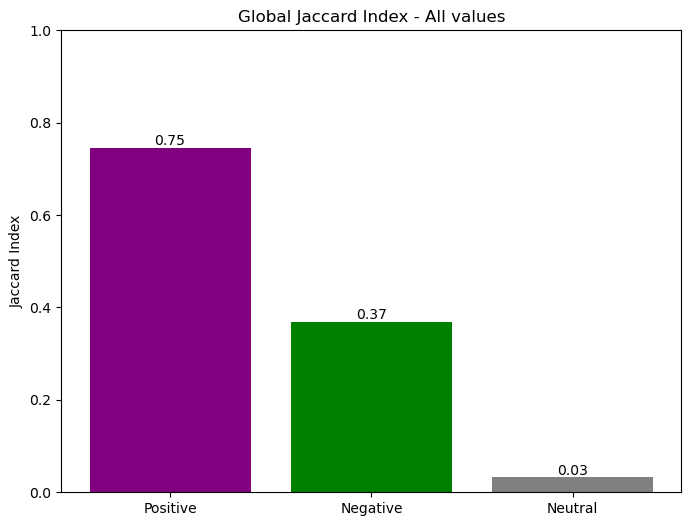

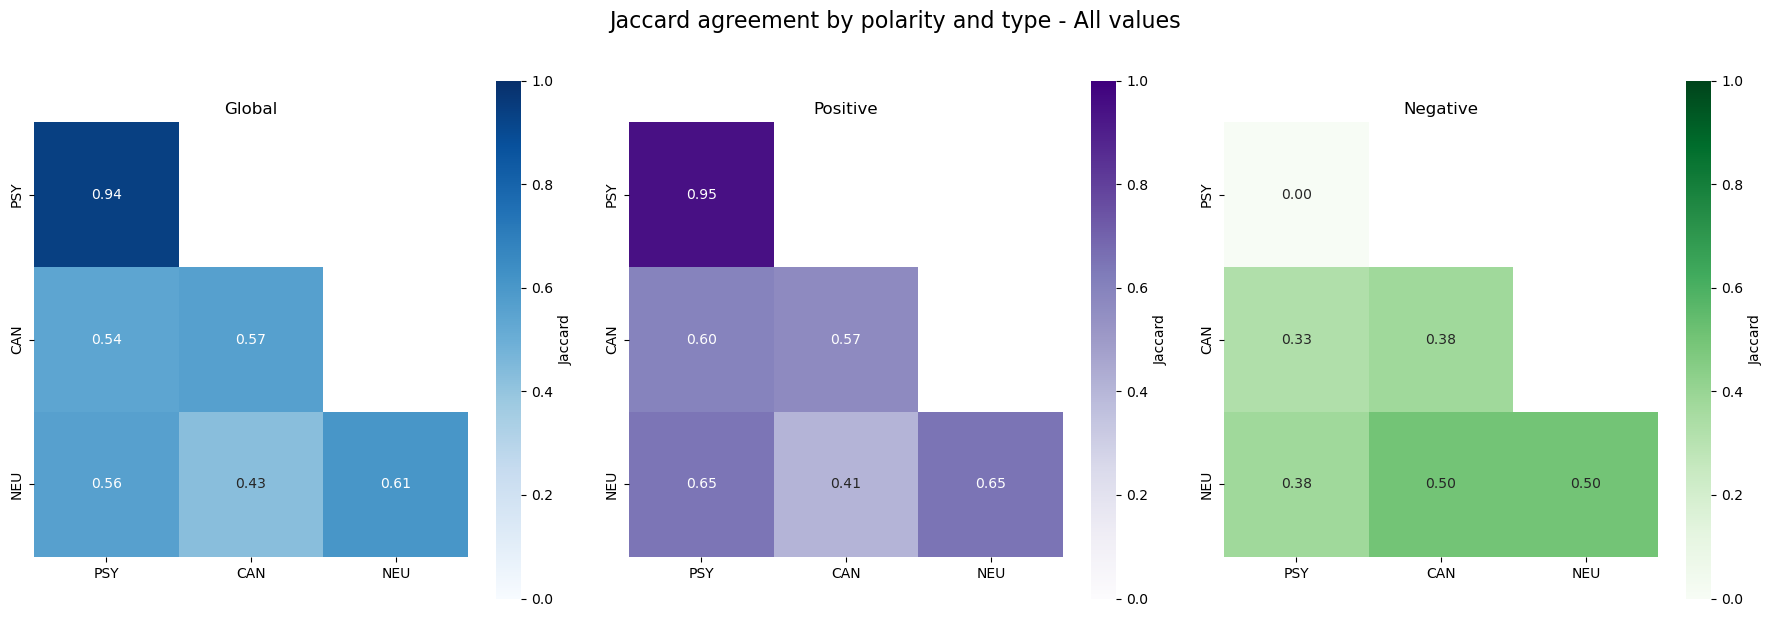

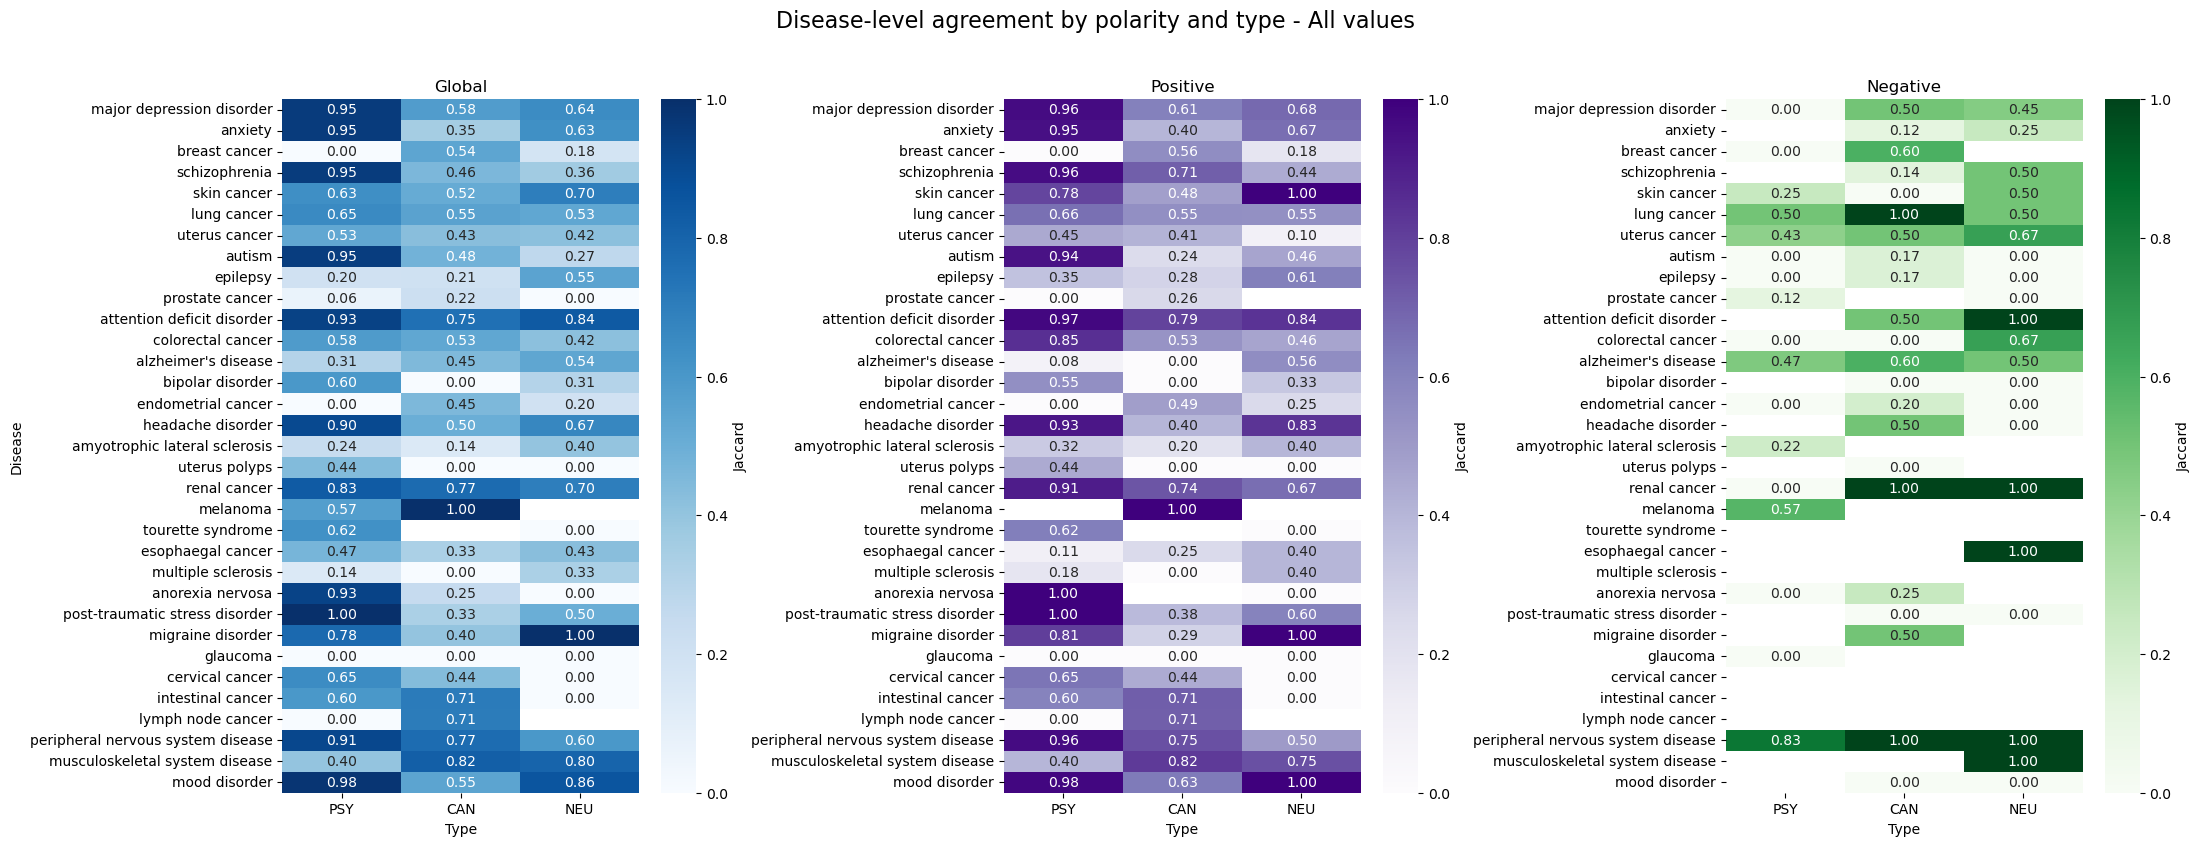

In [80]:
all_jaccard_123 = run_jaccard_plots_1to3(
    df=ldsc_hdl_both,
    title_suffix="All",
    output_dir=jaccard_plots_dir,
    output_suffix="all_TEST",
    neutral_thresh=0.1,
    types=("PSY", "CAN", "NEU"),
    show=True,
    dpi=300,
    include_neutral_in_global=True, 
    include_neutral_in_plot1=True     
)

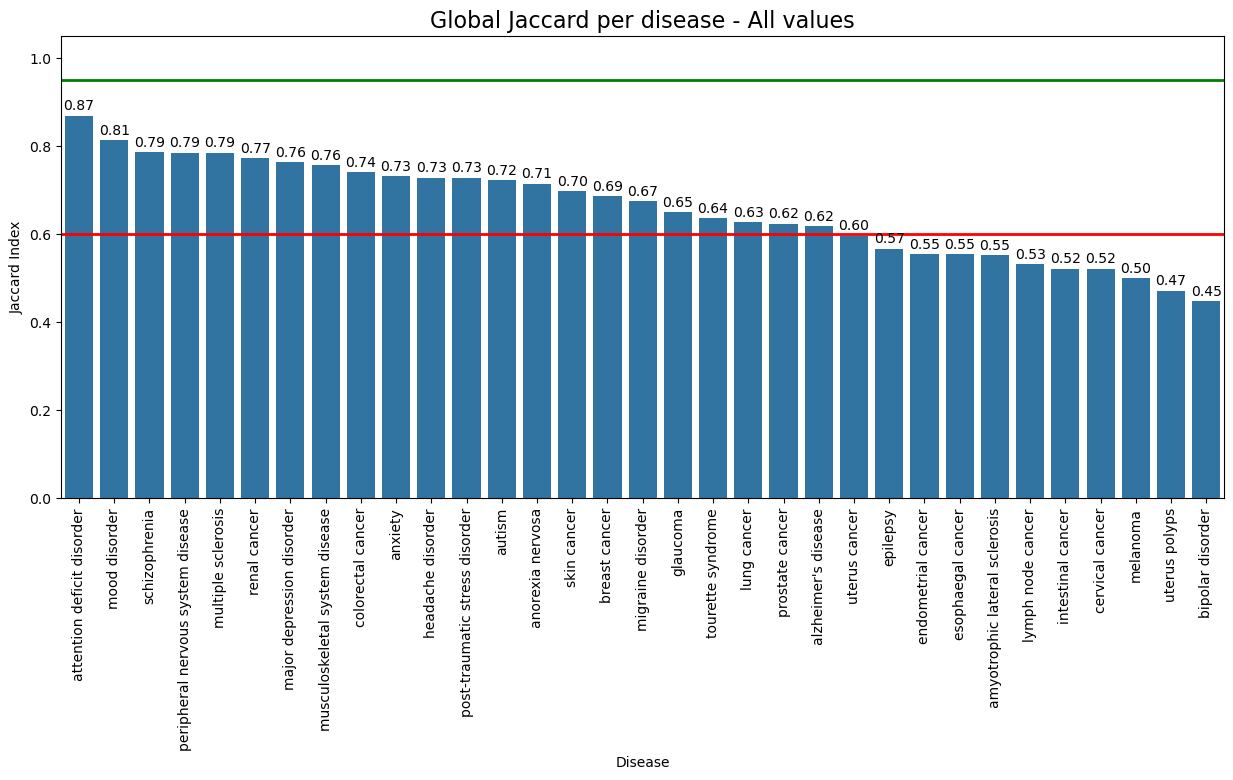

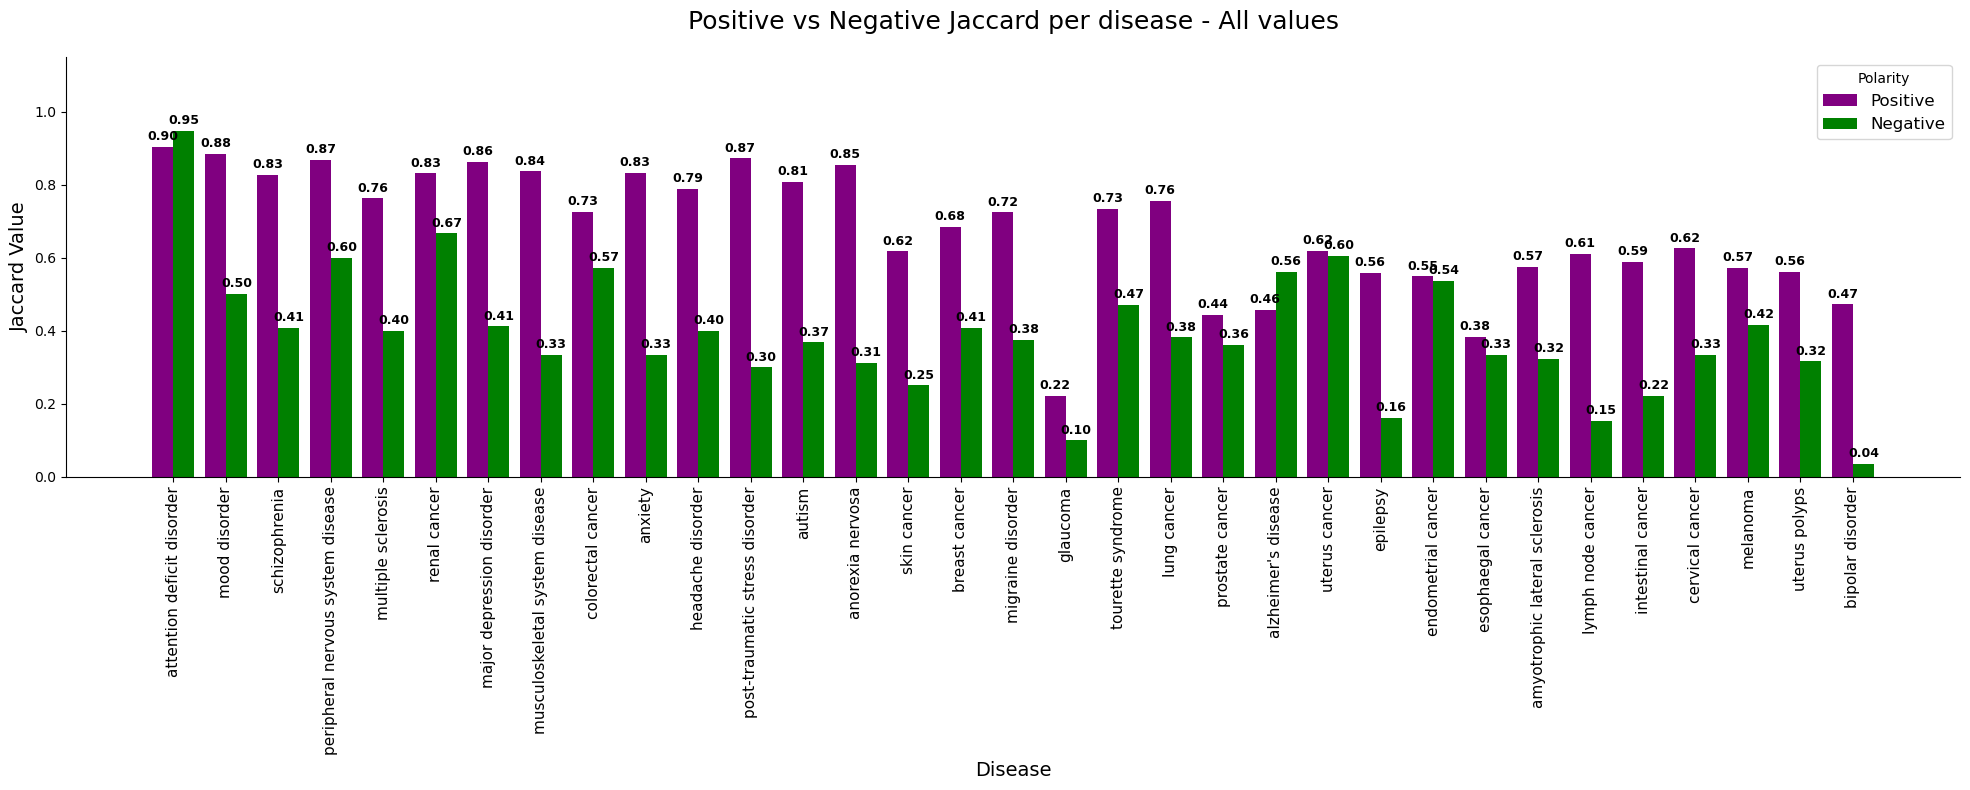

In [250]:
all_jaccard_45 = run_plots_4_5_together(
    df=ldsc_hdl_both,
    title_suffix="All",
    output_dir=jaccard_plots_dir,
    output_suffix="all",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=True,
    dpi=300,
)

#### All significant

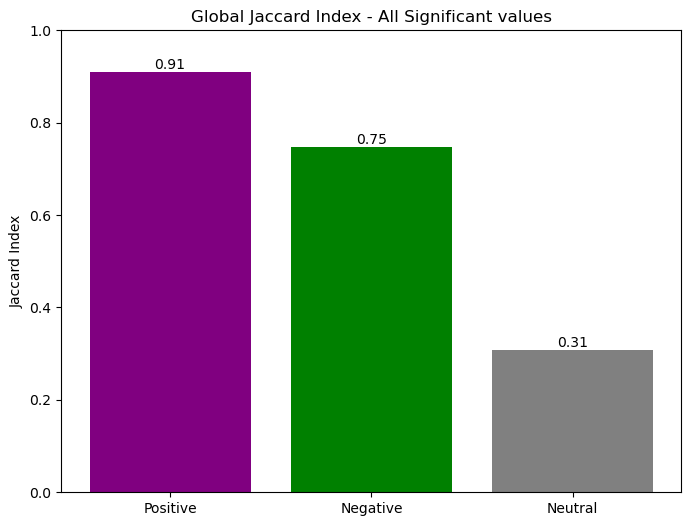

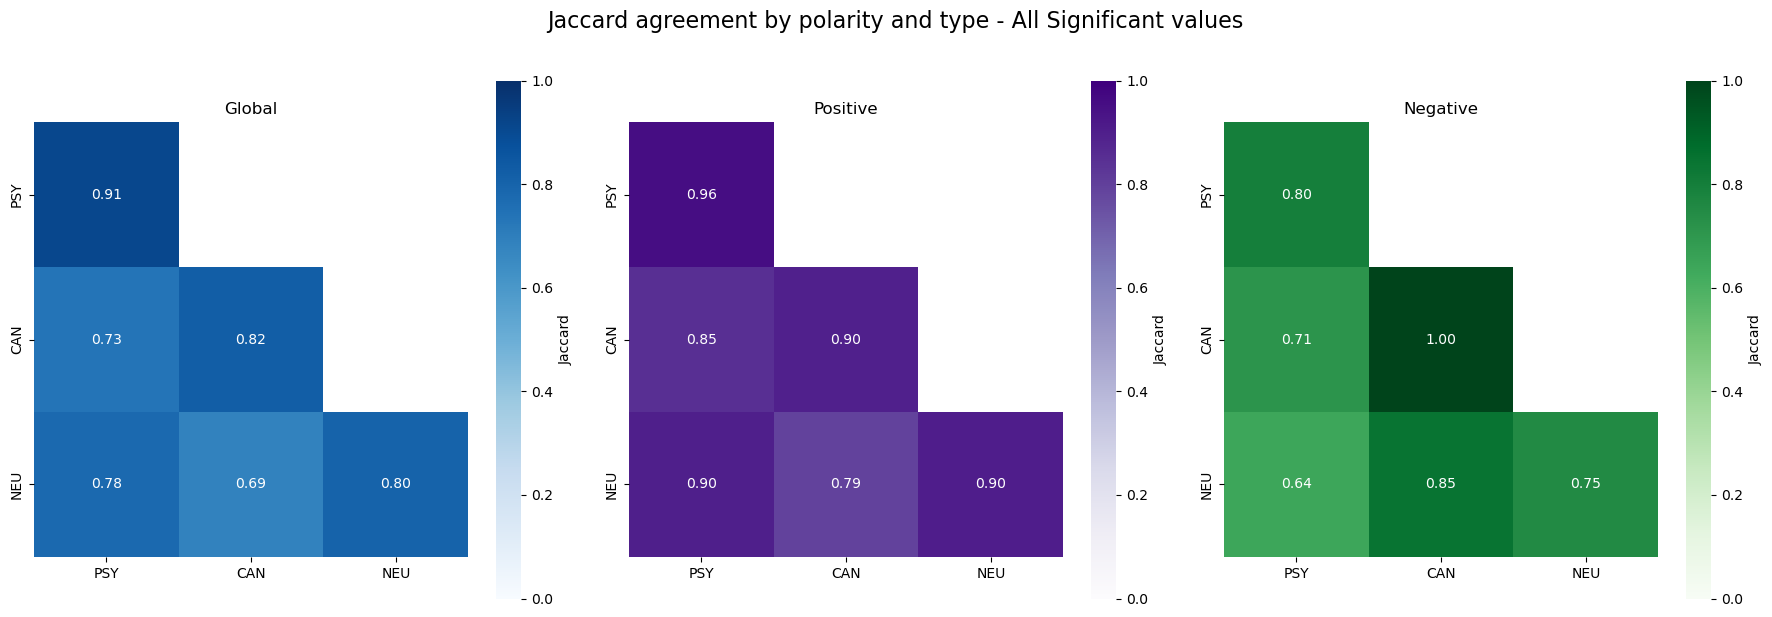

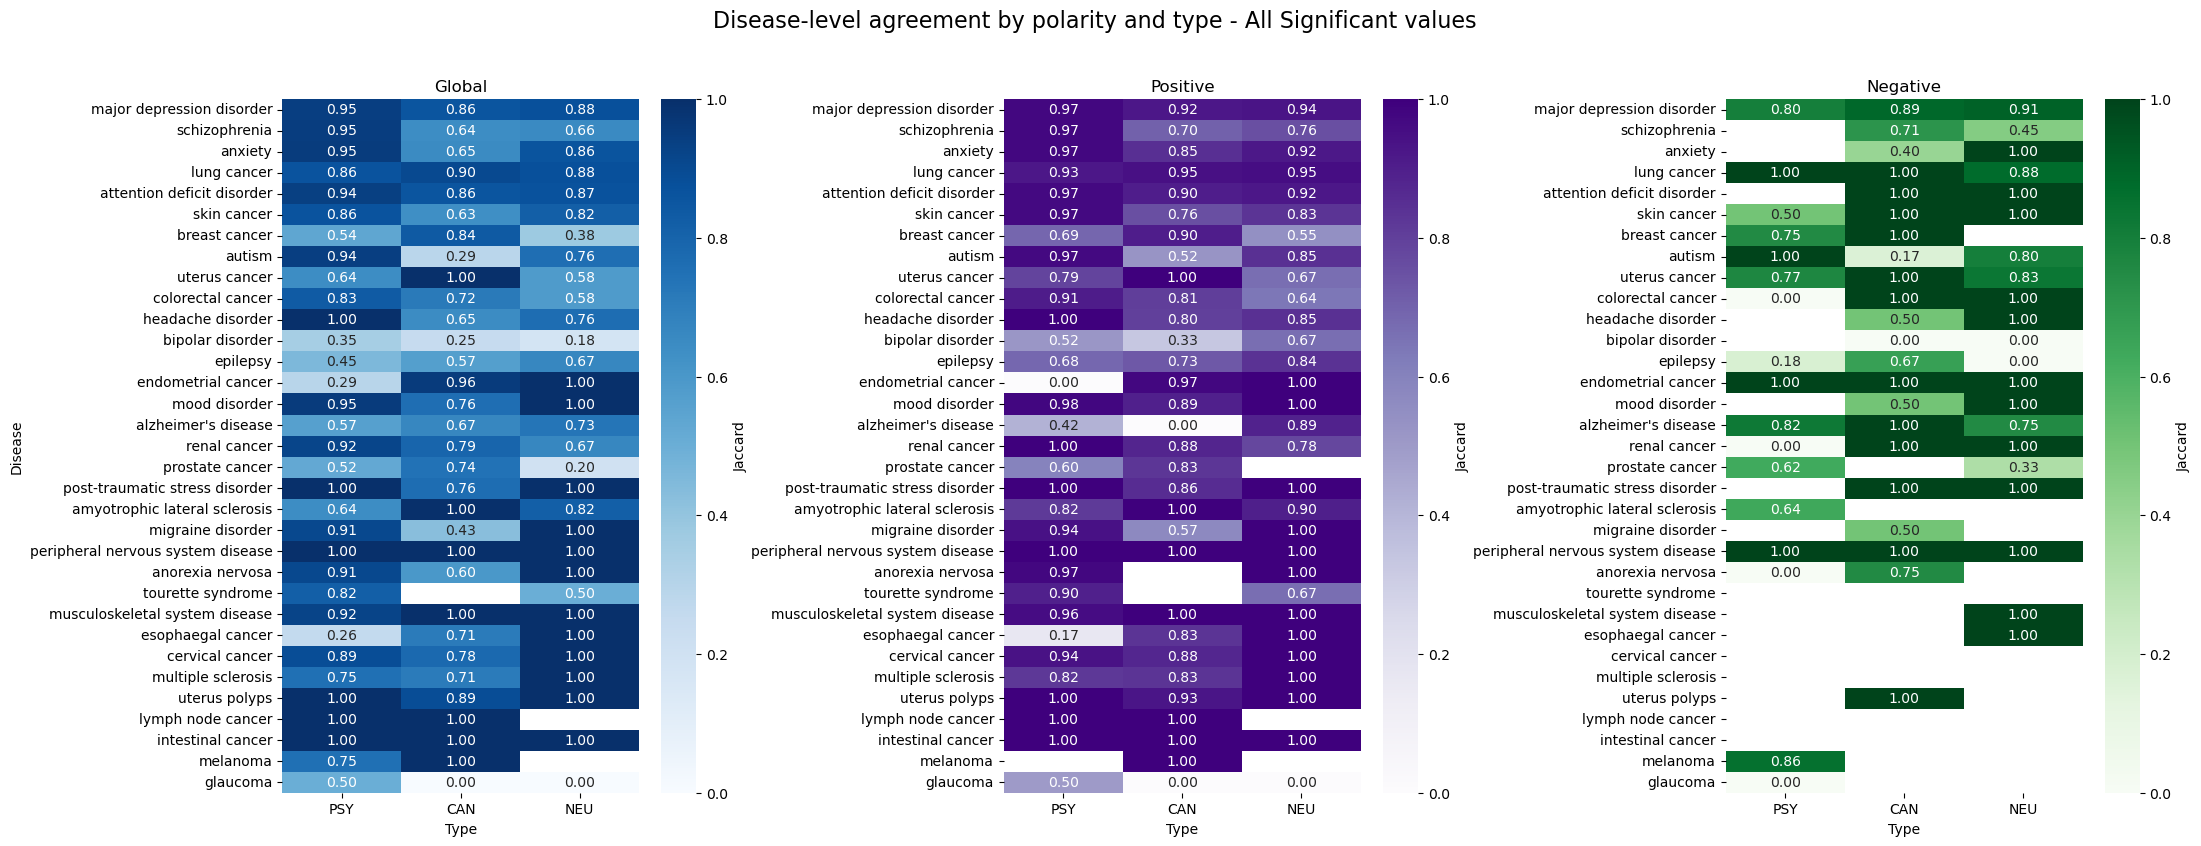

In [217]:
all_significant_jaccard_123 = run_jaccard_plots_1to3(
    df=ldsc_hdl_significant_either,
    title_suffix="All Significant",
    output_dir=jaccard_plots_dir,
    output_suffix="all_significant",
    neutral_thresh=0.1,
    types=("PSY", "CAN", "NEU"),
    show=True,
    dpi=300,
    include_neutral_in_global=True, 
    include_neutral_in_plot1=True     
)

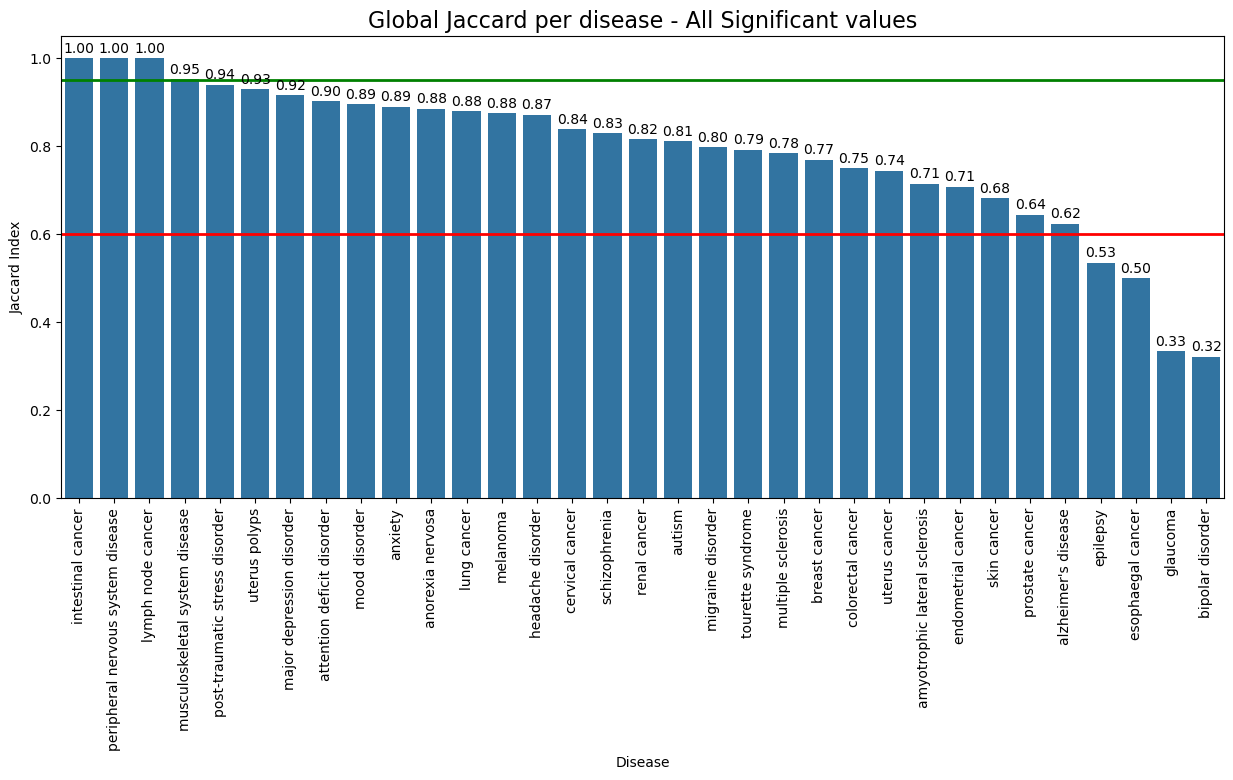

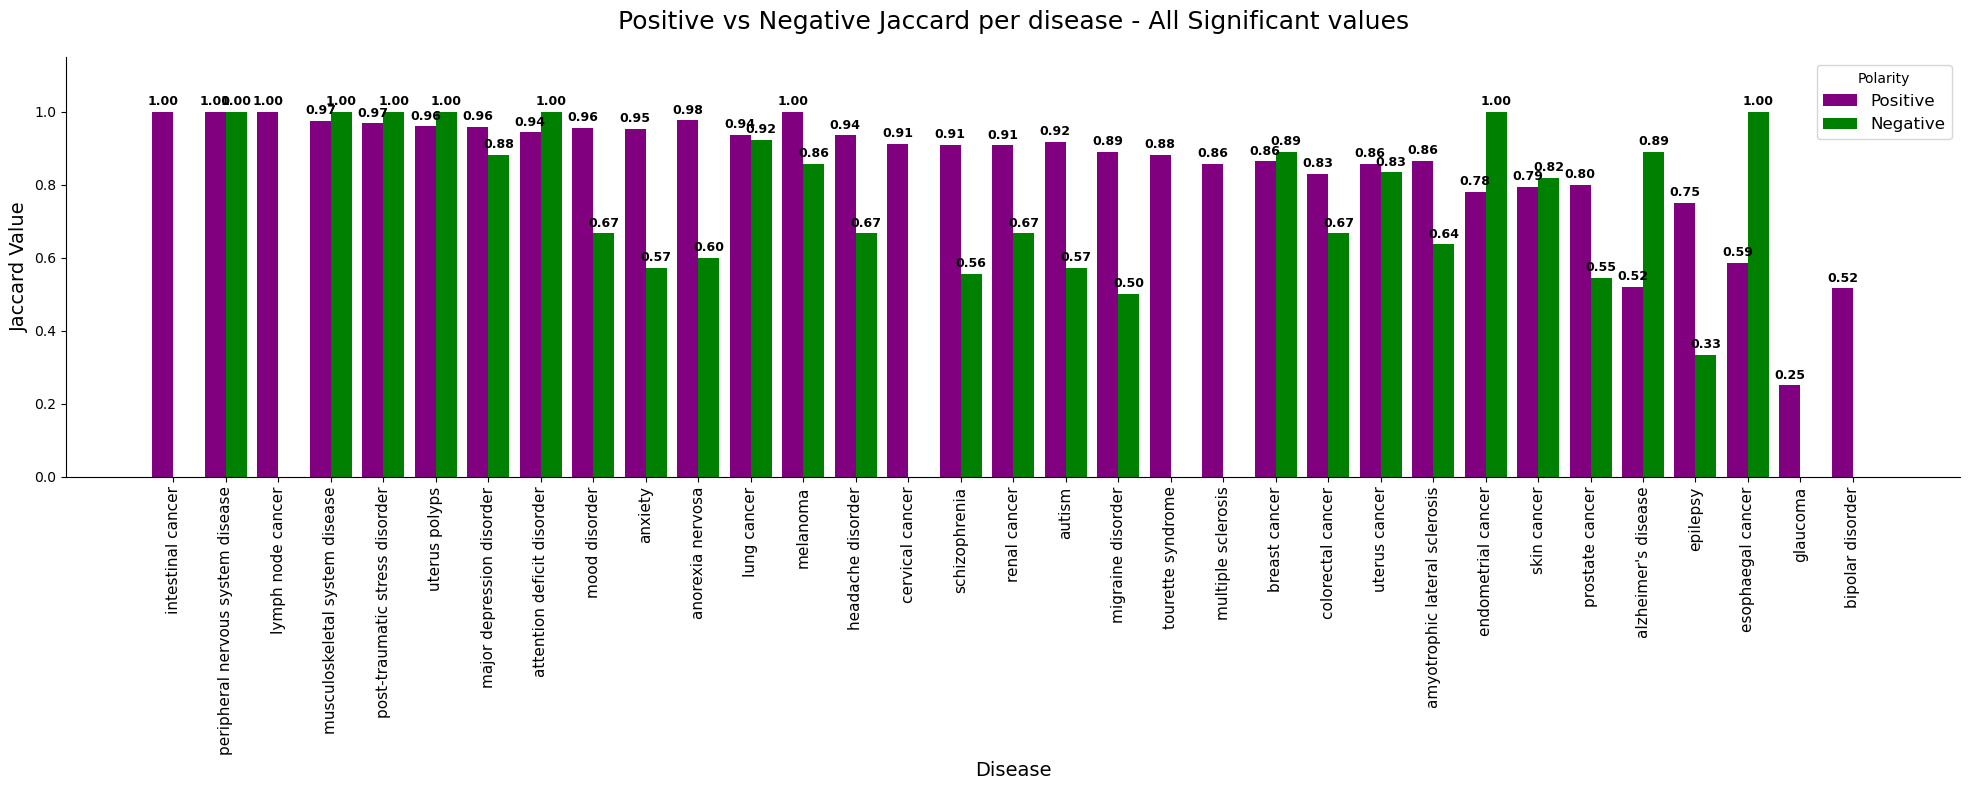

In [251]:
all_significant_jaccard_45 = run_plots_4_5_together(
    df=ldsc_hdl_significant_either,
    title_suffix="All Significant",
    output_dir=jaccard_plots_dir,
    output_suffix="all_significant",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=True,
    dpi=300,
)

####  Both significant

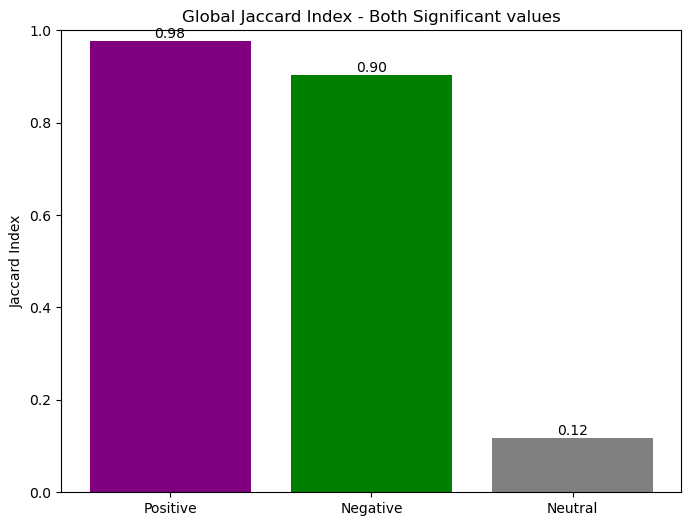

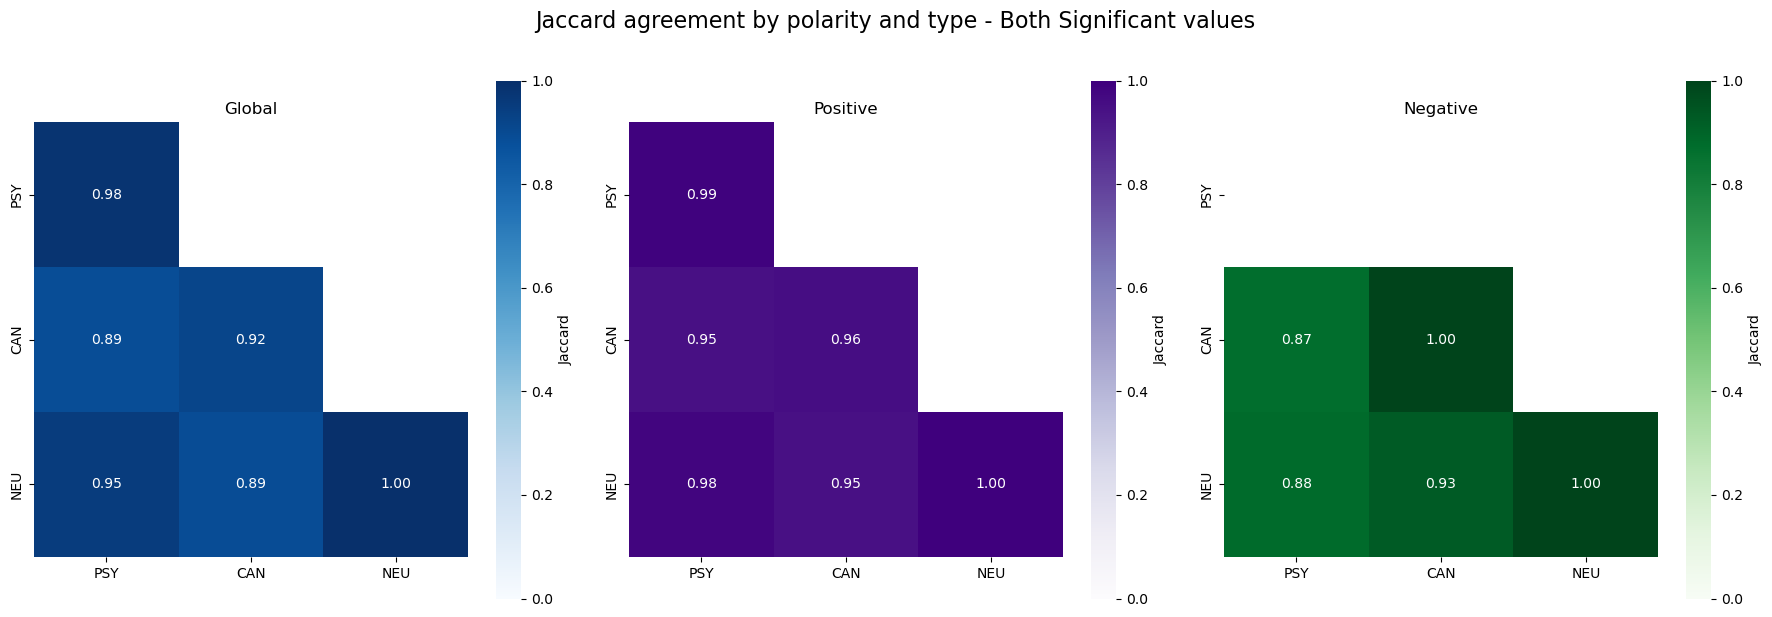

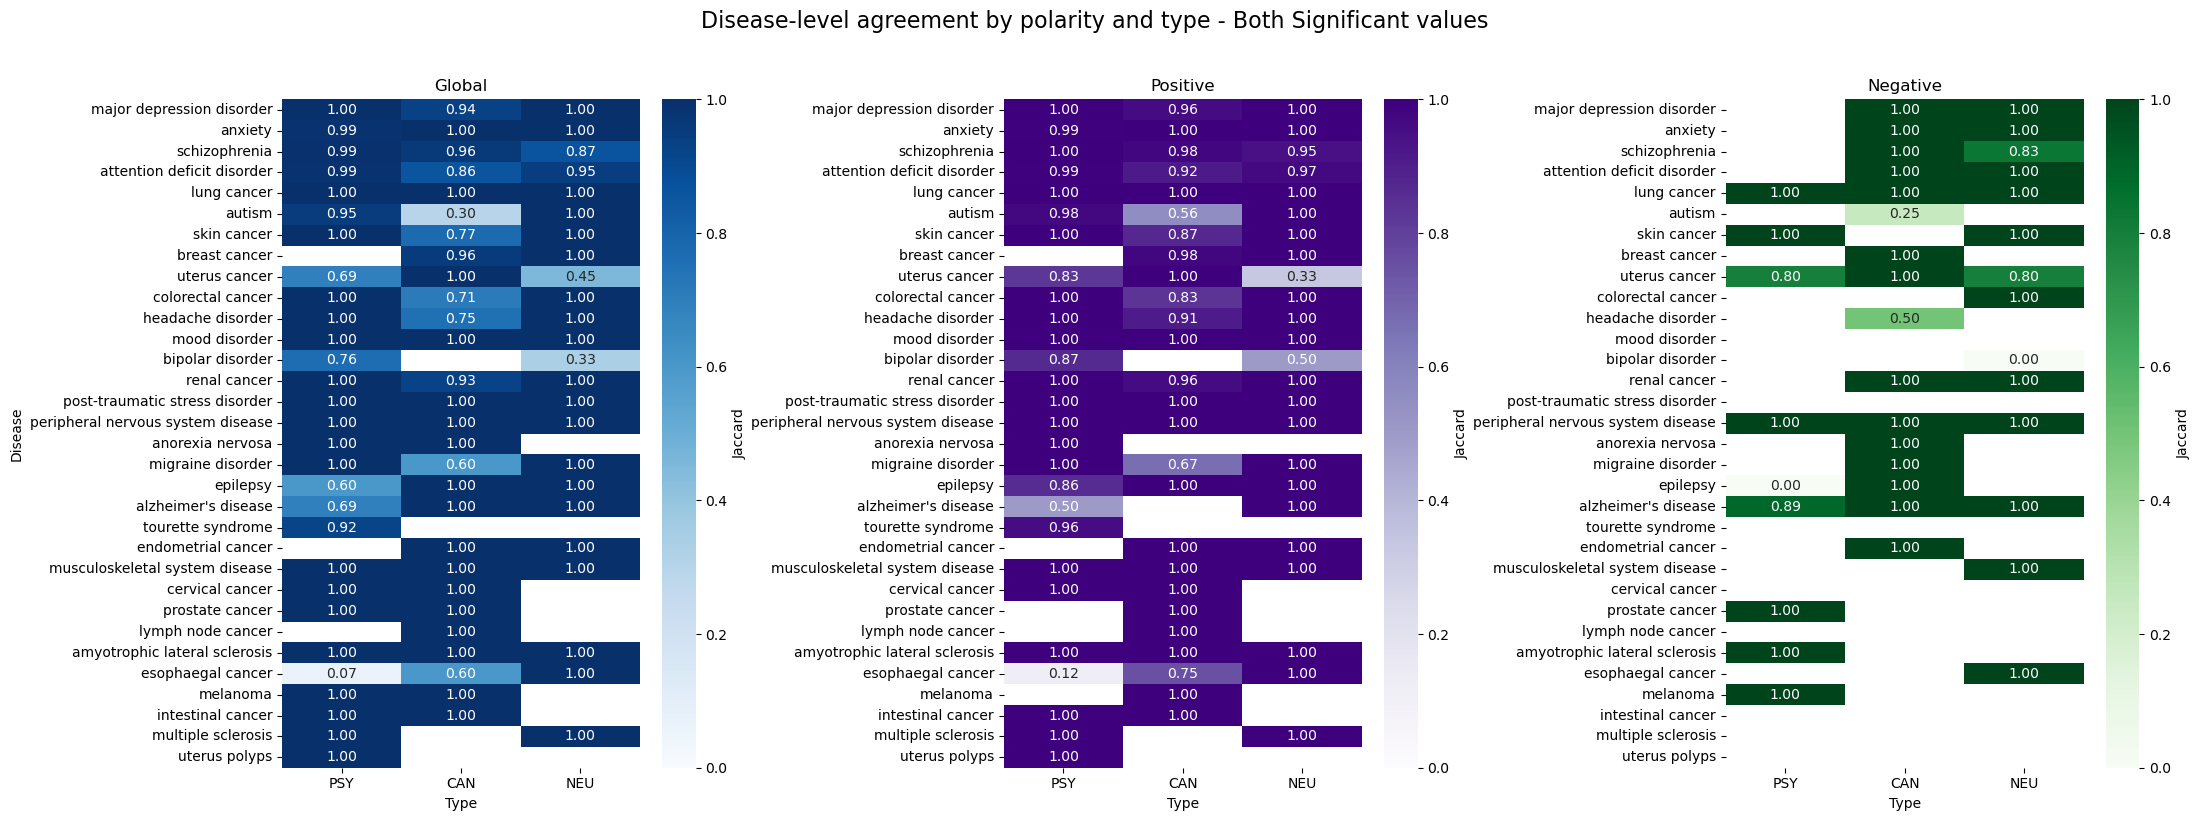

In [218]:
both_significant_jaccard_123 = run_jaccard_plots_1to3(
    df=ldsc_hdl_significant_both,
    title_suffix="Both Significant",
    output_dir=jaccard_plots_dir,
    output_suffix="both_significant",
    neutral_thresh=0.1,
    types=("PSY", "CAN", "NEU"),
    show=True,
    dpi=300,
    include_neutral_in_global=True, 
    include_neutral_in_plot1=True     
)

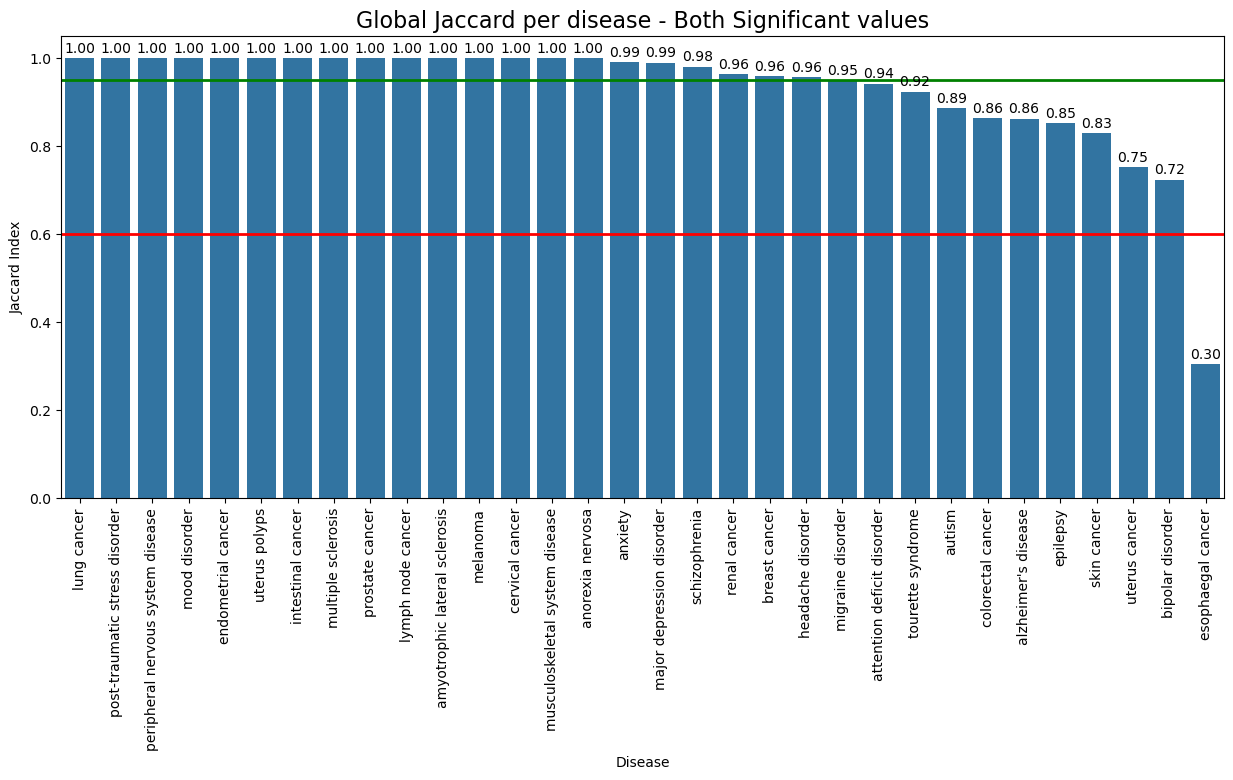

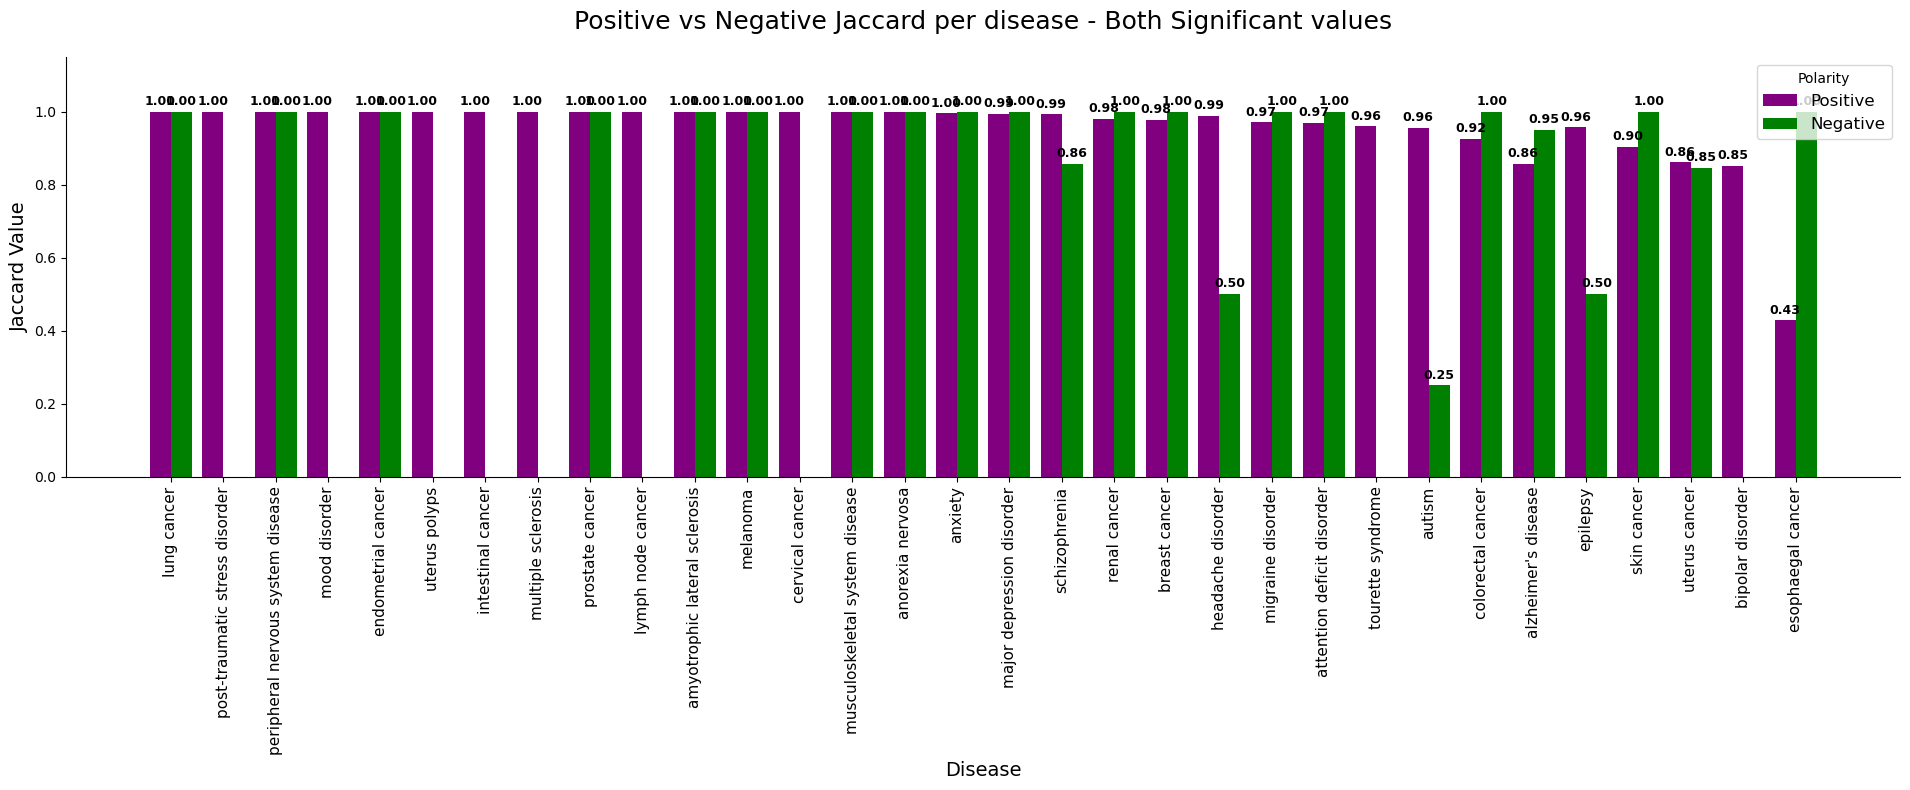

In [252]:
both_significant_jaccard_45 = run_plots_4_5_together(
    df=ldsc_hdl_significant_both,
    title_suffix="Both Significant",
    output_dir=jaccard_plots_dir,
    output_suffix="both_significant",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=True,
    dpi=300,
)

#### All Main

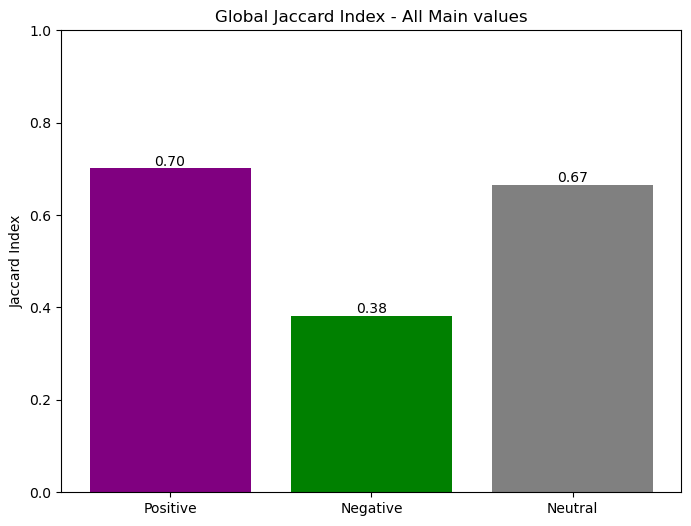

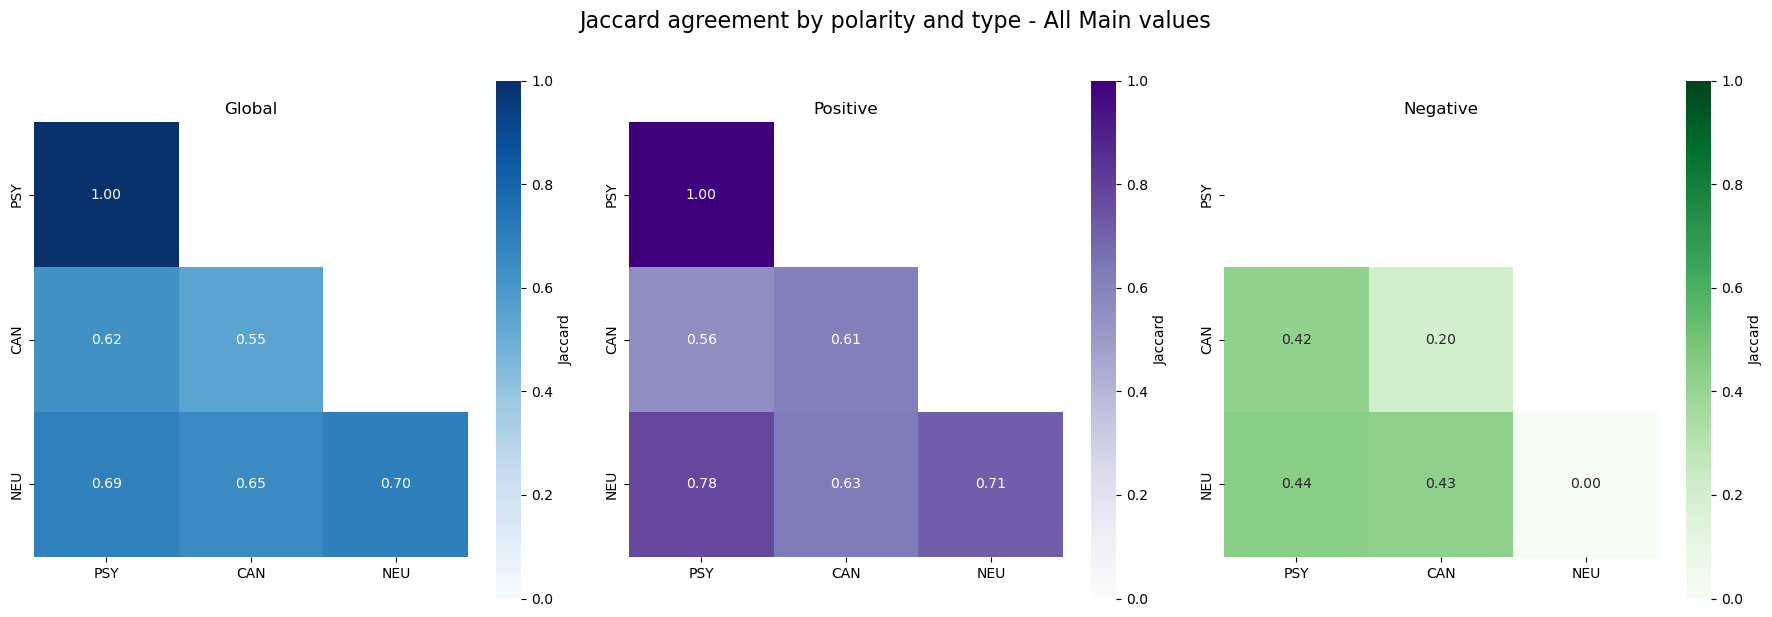

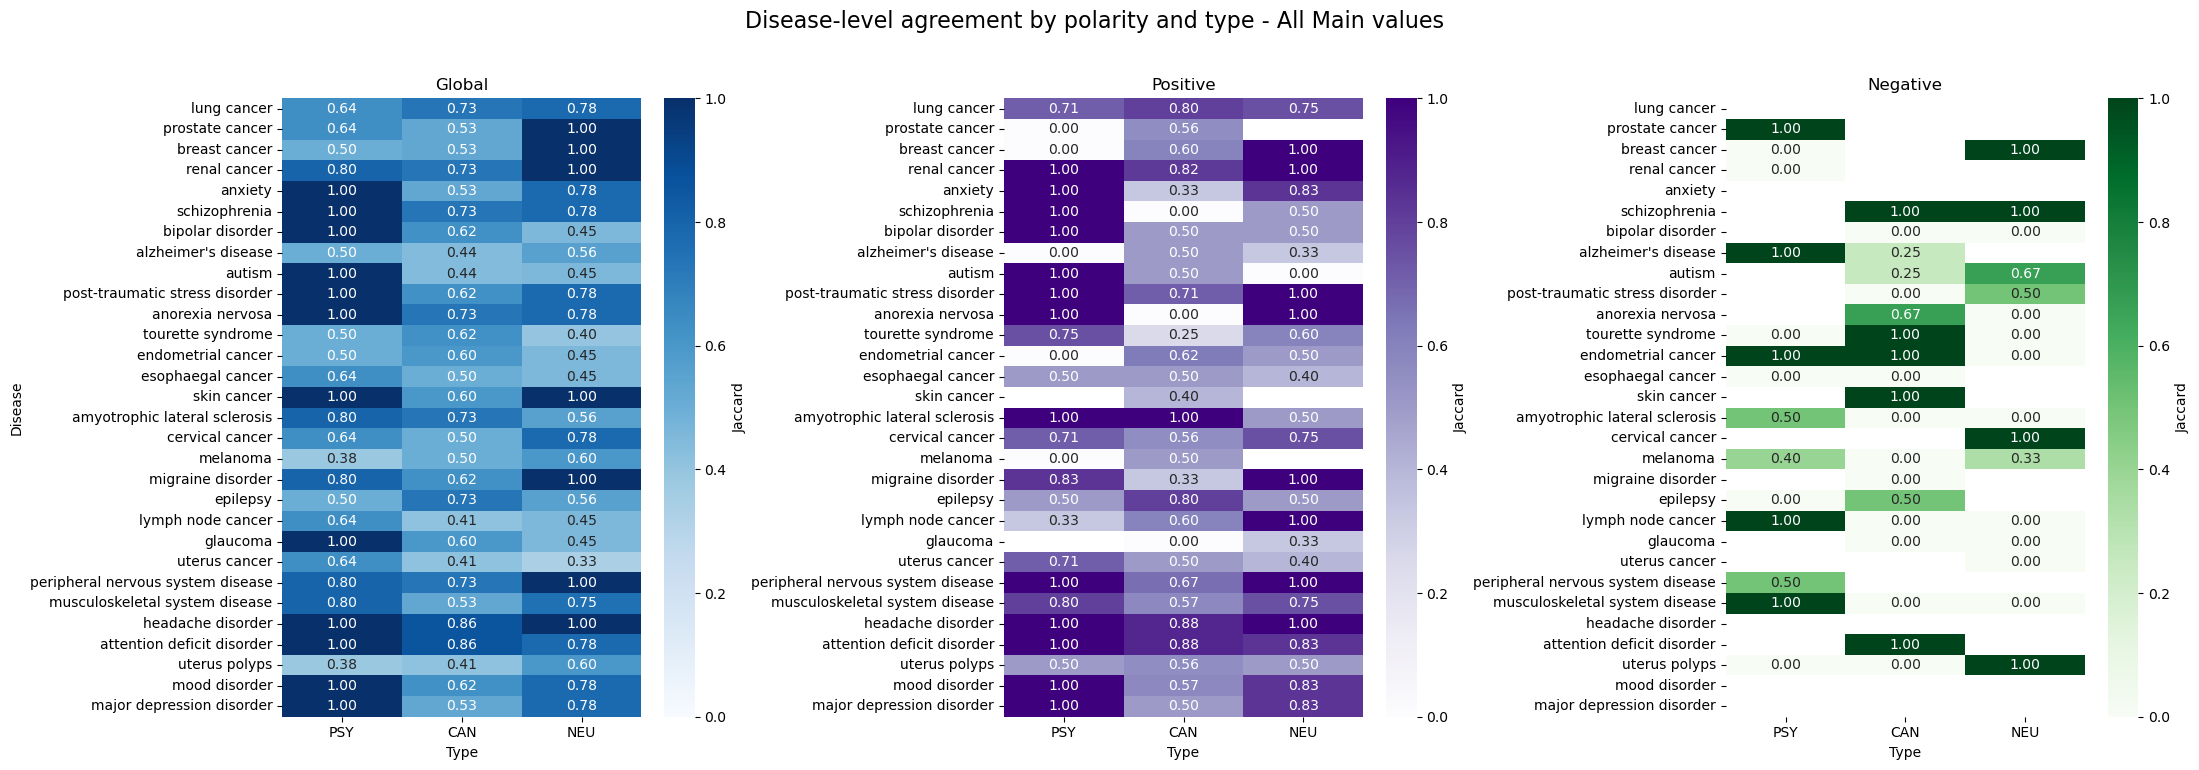

In [219]:
all_main_jaccard_123 = run_jaccard_plots_1to3(
    df=ldsc_hdl_both_main,
    title_suffix="All Main",
    output_dir=jaccard_plots_dir,
    output_suffix="_main",
    neutral_thresh=0.1,
    types=("PSY", "CAN", "NEU"),
    show=True,
    dpi=300,
    include_neutral_in_global=True, 
    include_neutral_in_plot1=True     
)

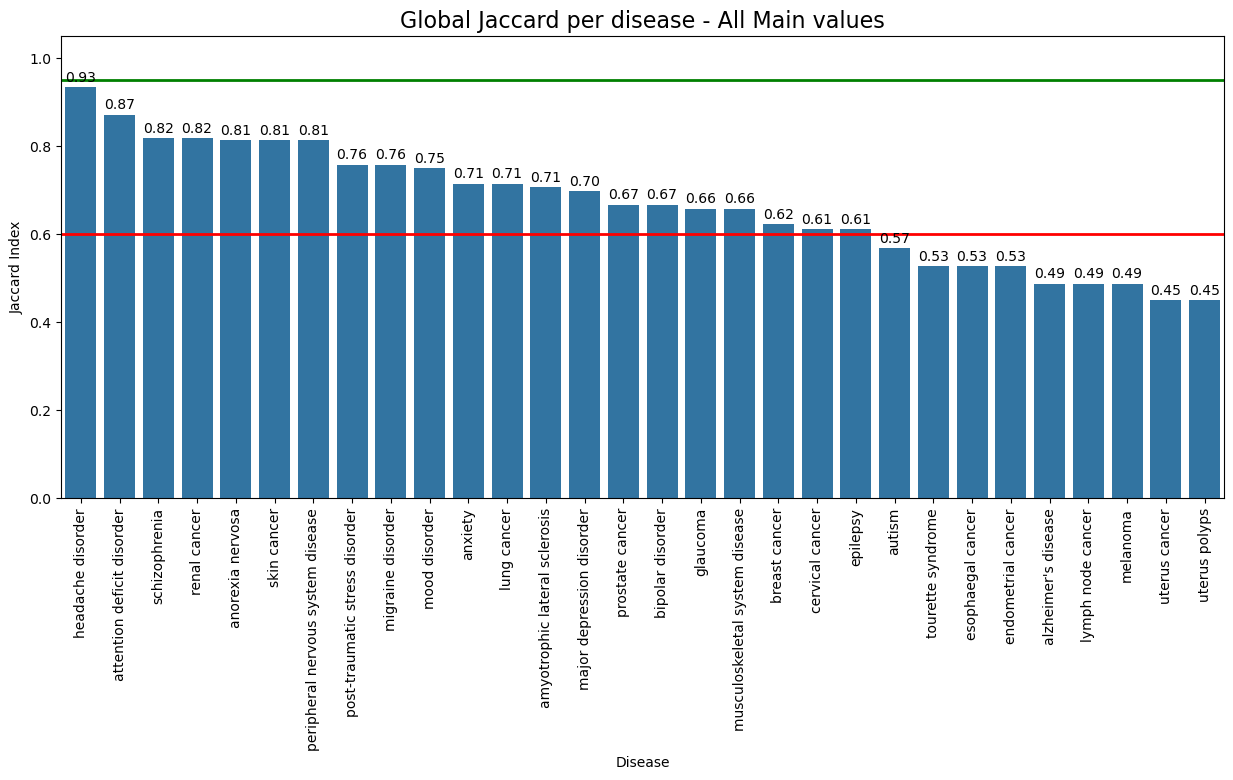

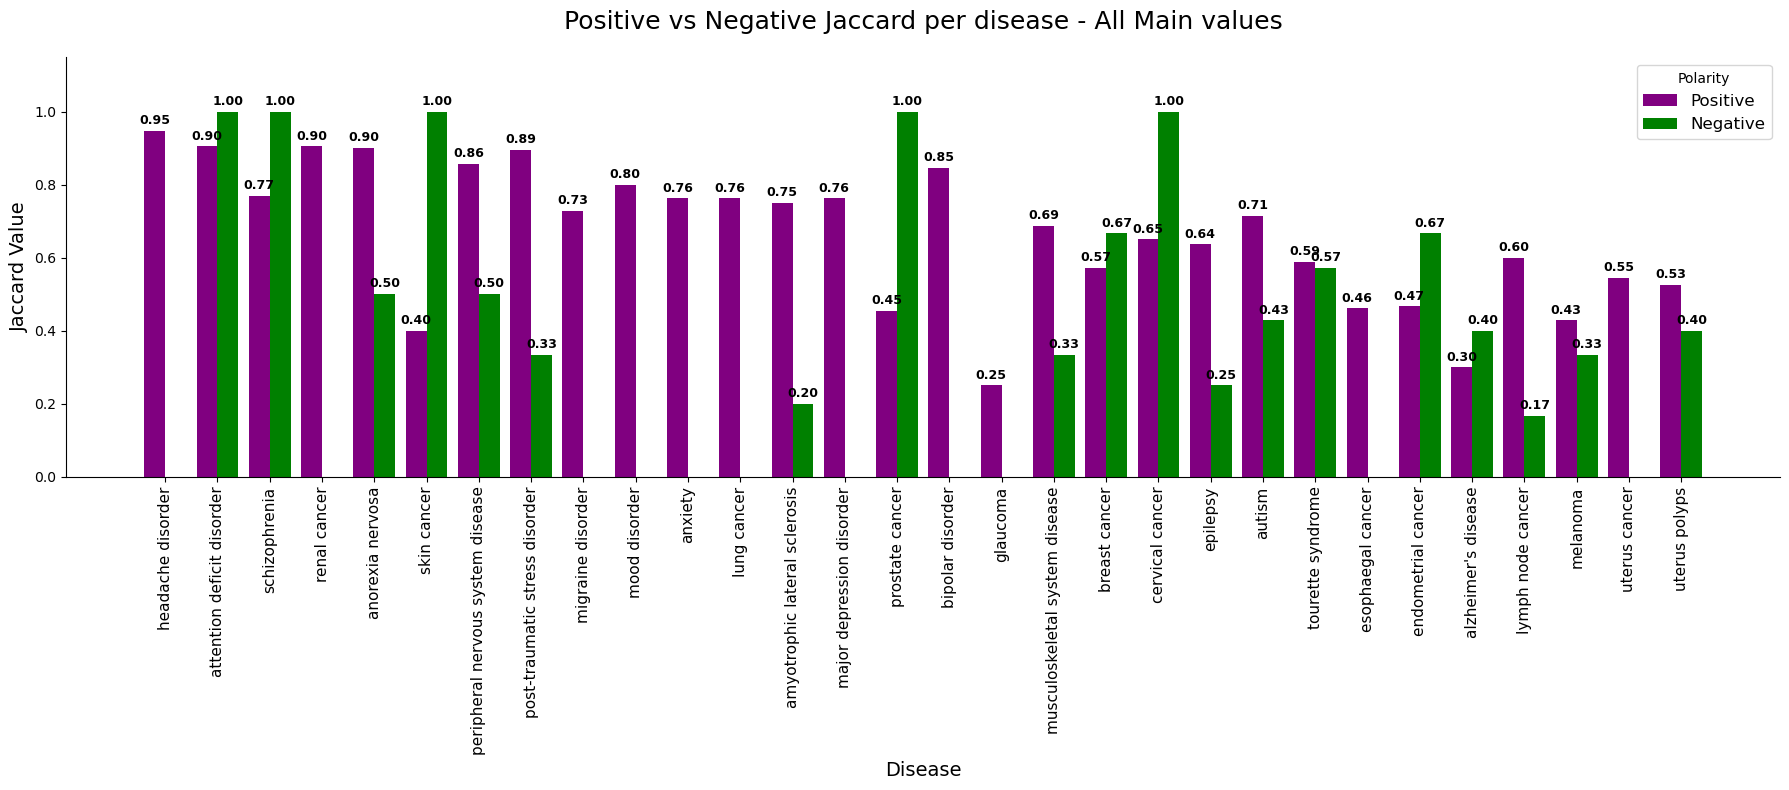

In [253]:
main_jaccard_45 = run_plots_4_5_together(
    df=ldsc_hdl_both_main,
    title_suffix="All Main",
    output_dir=jaccard_plots_dir,
    output_suffix="main",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=True,
    dpi=300,
)

#### Significant Main

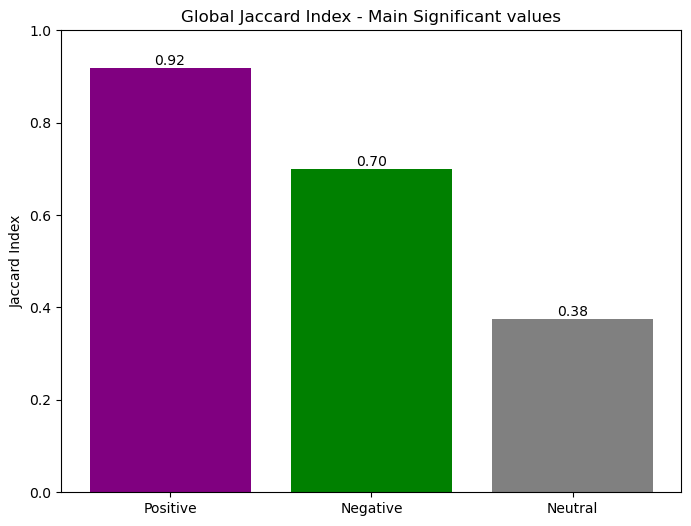

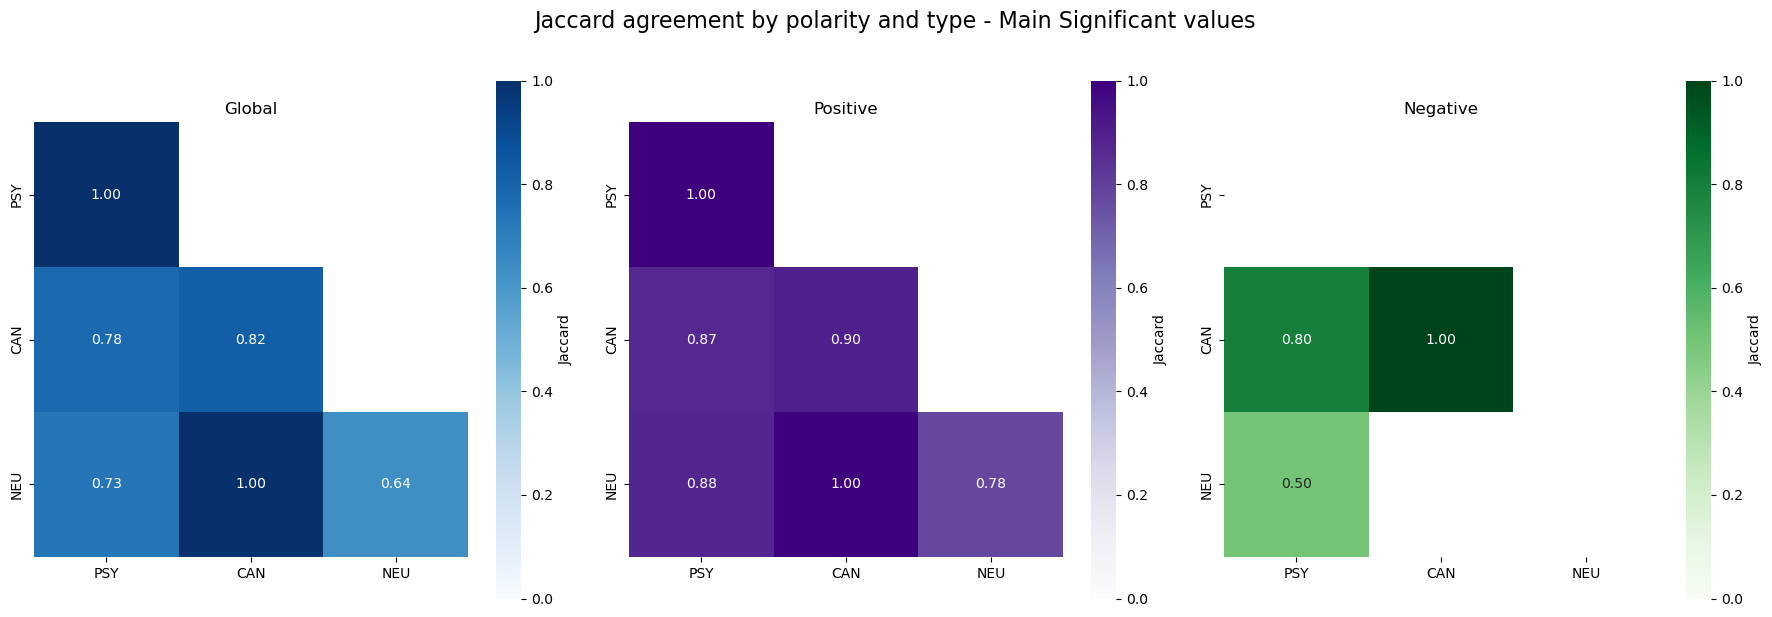

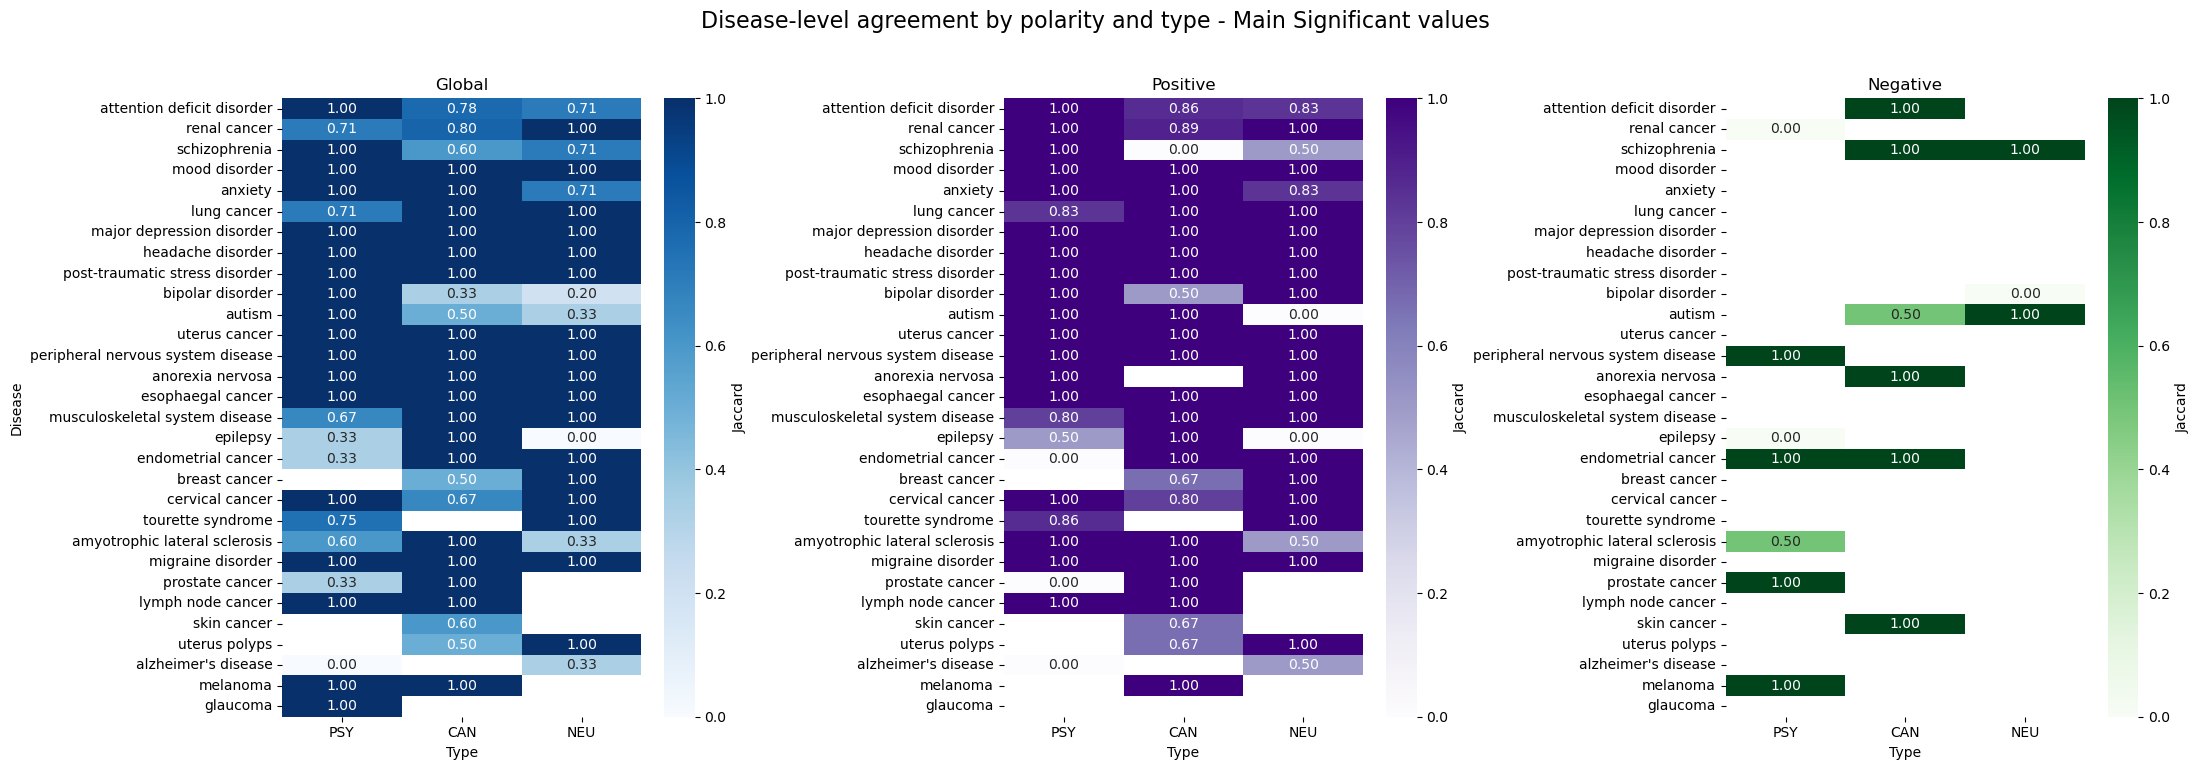

In [220]:
significant_main_jaccard_123 = run_jaccard_plots_1to3(
    df=ldsc_hdl_both_main_significant,
    title_suffix="Main Significant",
    output_dir=jaccard_plots_dir,
    output_suffix="_main_significant",
    neutral_thresh=0.1,
    types=("PSY", "CAN", "NEU"),
    show=True,
    dpi=300,
    include_neutral_in_global=True, 
    include_neutral_in_plot1=True     
)

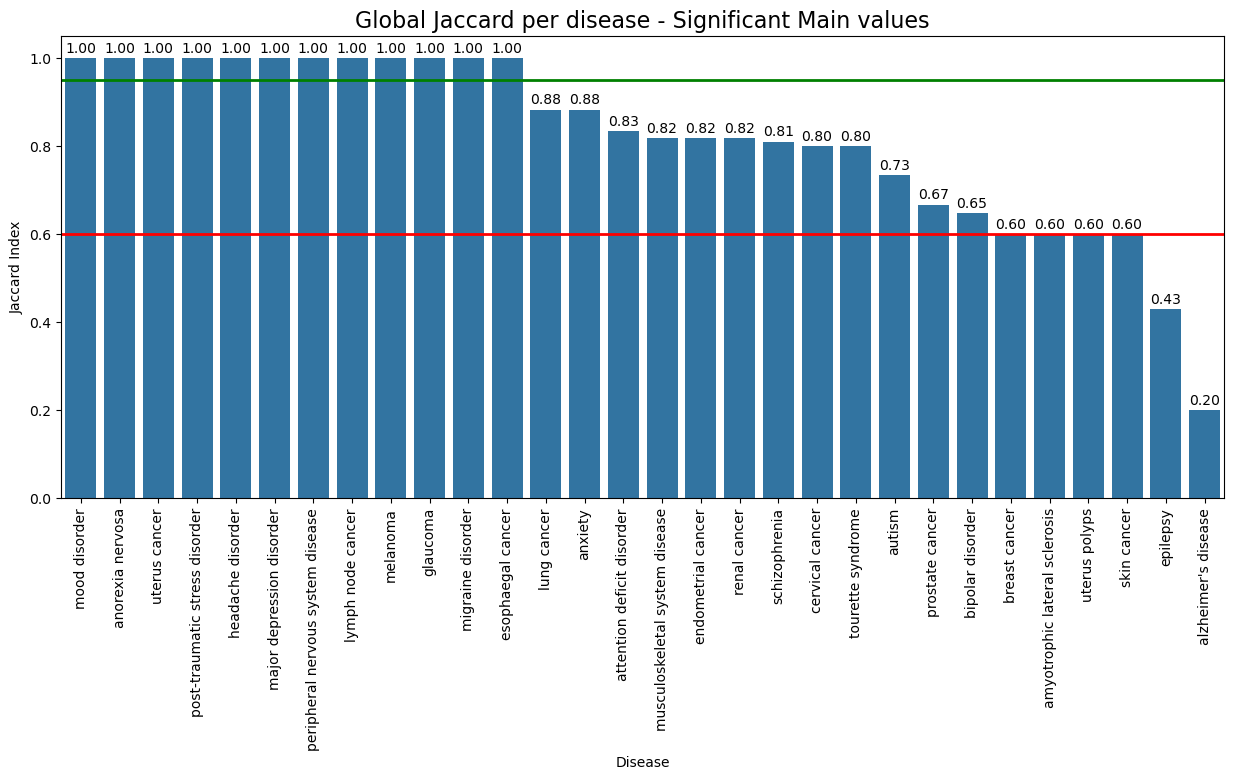

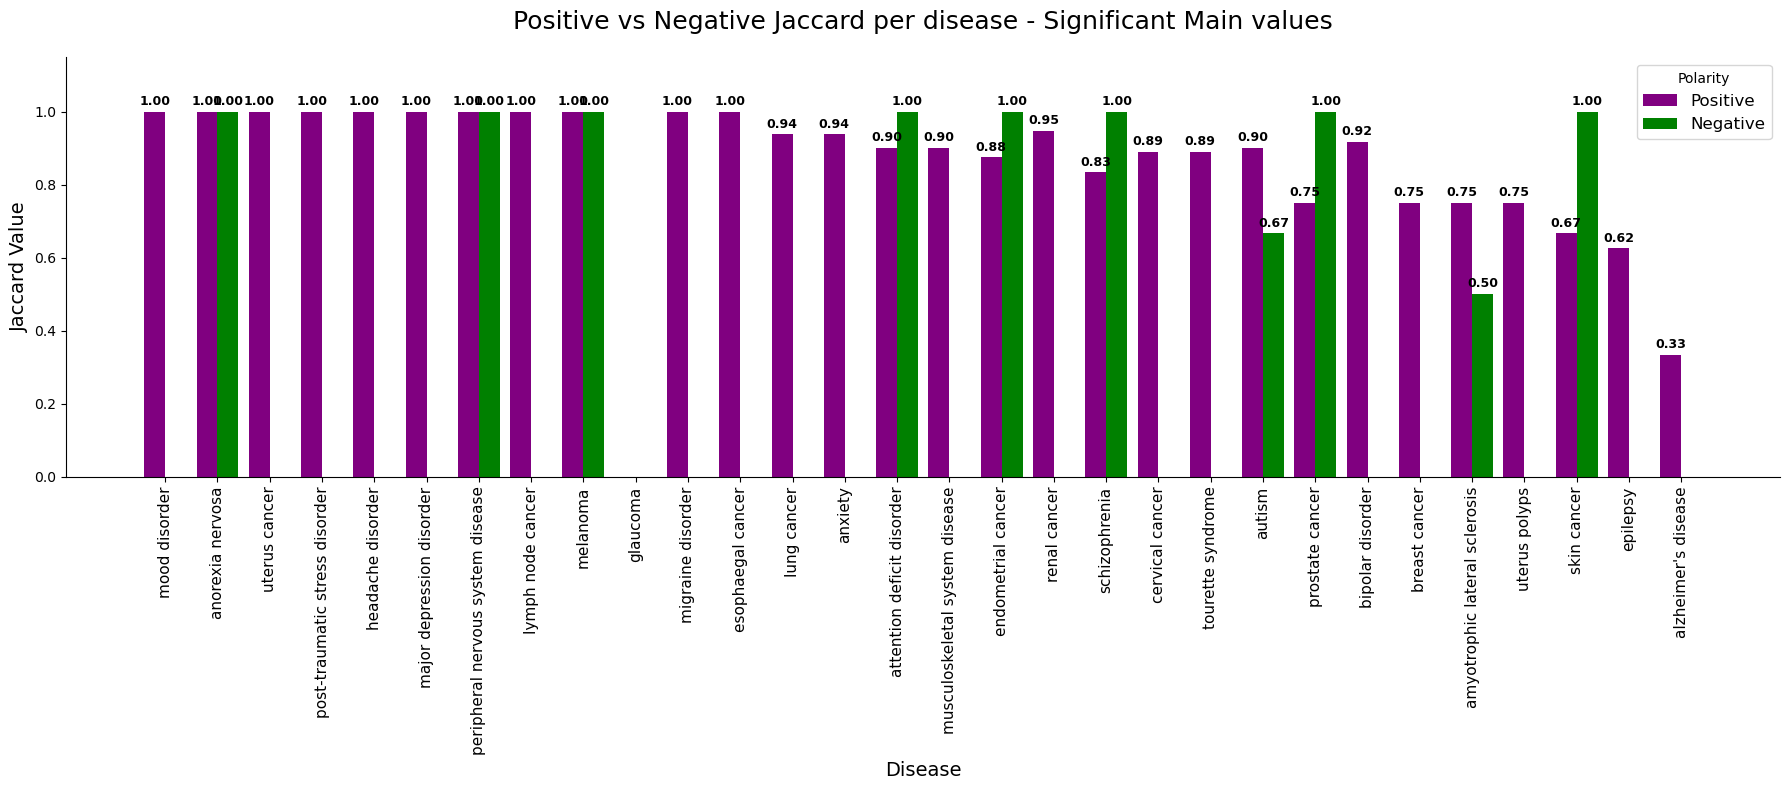

In [254]:
significant_main_jaccard_45 = run_plots_4_5_together(
    df=ldsc_hdl_both_main_significant,
    title_suffix="Significant Main",
    output_dir=jaccard_plots_dir,
    output_suffix="main_significant",
    neutral_thresh=0.1,
    include_neutral_in_global=True,
    show=True,
    dpi=300,
)

## Significance

### Total significance

In [255]:
#For LDSC
print(f"The number of disease-pairs that are relevant without correction are", {len(ldsc_corr[ldsc_corr["p"]<0.05])},"out of", {len(ldsc_corr)})
print(f"And the number of pairs that were accepted with bonferroni are: {len(ldsc_corr[ldsc_corr['p_bonf_rejected'] == True])}, that's a percentage of {((len(ldsc_corr[ldsc_corr['p_bonf_rejected'] == True])/(len(ldsc_corr)))*100)}")
print(f"And the number of pairs that were accepted with FDR are: {len(ldsc_corr[ldsc_corr['p_FDR_rejected'] == True])}, that's a percentage of {((len(ldsc_corr[ldsc_corr['p_FDR_rejected'] == True])/(len(ldsc_corr)))*100)}")

The number of disease-pairs that are relevant without correction are {2444} out of {6670}
And the number of pairs that were accepted with bonferroni are: 1204, that's a percentage of 18.05097451274363
And the number of pairs that were accepted with FDR are: 2040, that's a percentage of 30.584707646176913


In [256]:
#For HDL
print(f"The number of disease-pairs that are relevant without correction are", {len(hdl_corr[hdl_corr["p"]<0.05])},"out of", {len(hdl_corr)})
print(f"And the number of pairs that were accepted with bonferroni are: {len(hdl_corr[hdl_corr['p_bonf_rejected'] == True])}, that's a percentage of {((len(hdl_corr[hdl_corr['p_bonf_rejected'] == True])/(len(hdl_corr)))*100)}")
print(f"And the number of pairs that were accepted with FDR are: {len(hdl_corr[hdl_corr['p_FDR_rejected'] == True])}, that's a percentage of {((len(hdl_corr[hdl_corr['p_FDR_rejected'] == True])/(len(hdl_corr)))*100)}")

The number of disease-pairs that are relevant without correction are {2778} out of {5904}
And the number of pairs that were accepted with bonferroni are: 1441, that's a percentage of 24.407181571815716
And the number of pairs that were accepted with FDR are: 2419, that's a percentage of 40.97222222222222


In [342]:
#For both (significant in either ldsc or hdl, but not duplicating)
ldsc_significant = ldsc_corr[ldsc_corr["p_corrected_FDR"]<0.05][["label_1","label_2"]]
hdl_significant = hdl_corr[hdl_corr["p_corrected_FDR"]<0.05][["label_1","label_2"]]
both_significant = pd.concat([ldsc_significant, hdl_significant]).drop_duplicates().reset_index(drop=True)
print(f"The number of disease-pairs that are significant in either LDSC or HDL (FDR) are: {len(both_significant)}, that's a percentage of {((len(both_significant)/(len(ldsc_corr)))*100)}")

The number of disease-pairs that are significant in either LDSC or HDL (FDR) are: 2680, that's a percentage of 40.17991004497751


In [345]:
# Print how many pairs are significant in either or both using ldsc_hdl_significant_both and ldsc_hdl_significant_either
print(f"Number of disease-pairs significant in both LDSC and HDL: {len(ldsc_hdl_significant_both)} ({len(ldsc_hdl_significant_both)/len(ldsc_hdl_both)*100:.2f}%)")
print(f"Number of disease-pairs significant in either LDSC or HDL: {len(ldsc_hdl_significant_either)} ({len(ldsc_hdl_significant_either)/len(ldsc_hdl_both)*100:.2f}%)")

Number of disease-pairs significant in both LDSC and HDL: 1779 (30.13%)
Number of disease-pairs significant in either LDSC or HDL: 2537 (42.97%)


In [351]:
# Table to save to excell with the significance combinations, first significance and percentage for LDSC, HDL, then either LDSC or HDL, then both, and finally the total number of pairs
significance_summary = pd.DataFrame({
	"Selection": ["Any Software (FDR)", "Only LDSC (FDR)", "Only HDL (FDR)", "Either Common (FDR)", "Both Common(FDR)"],
	"Significant": [len(both_significant), len(ldsc_corr[ldsc_corr["p_FDR_rejected"] == True]), len(hdl_corr[hdl_corr["p_FDR_rejected"] == True]), len(both_significant), len(ldsc_hdl_significant_both)],
	"Total Count": [len(ldsc_corr), len(ldsc_corr), len(hdl_corr), len(ldsc_hdl_both), len(ldsc_hdl_both)],
	"Percentage": [
		f"{((len(both_significant)/(len(ldsc_corr)))*100):.2f}",
		f"{(len(ldsc_corr[ldsc_corr["p_FDR_rejected"] == True]) / len(ldsc_corr)) * 100:.2f}%",
		f"{(len(hdl_corr[hdl_corr["p_FDR_rejected"] == True]) / len(hdl_corr)) * 100:.2f}%",
		f"{(len(both_significant) / len(ldsc_hdl_both)) * 100:.2f}%",	
		f"{(len(ldsc_hdl_significant_both) / len(ldsc_hdl_both)) * 100:.2f}%"
	]
})	
significance_summary.to_excel(os.path.join(significance_tables_dir, "significance_summary_softwares_overall.xlsx"), index=False)

In [264]:
def table_significance(ldsc_df, hdl_df, output_folder):
    """
    Computes % of significant results only (p_FDR_rejected == True) without polarity splits.

    Outputs (ONLY significant rows):
      1) Method-level: count_sig, perc_sig_of_method
      2) Method x Category (Intra/Inter): count_sig, perc_sig_of_category, perc_sig_of_method
      3) Method x Pair: count_sig, perc_sig_of_pair, perc_sig_of_method

    Saves a single Excel with 3 sheets:
      - method
      - category
      - pair
    """
    os.makedirs(output_folder, exist_ok=True)

    results_method = []
    results_category = []
    results_pair = []

    pairs_list = ["CAN-CAN", "PSY-PSY", "NEU-NEU", "CAN-PSY", "CAN-NEU", "NEU-PSY"]
    categories = ["Intra", "Inter"]

    for method_name, df in [("LDSC", ldsc_df), ("HDL", hdl_df)]:
        df = df.copy()
        total_method = len(df)

        sig_mask = df["p_FDR_rejected"].astype(bool)
        sig_df = df[sig_mask]

        sig_count_method = len(sig_df)
        perc_sig_method = round((sig_count_method / total_method) * 100, 2) if total_method else 0.0

        results_method.append({
            "Method": method_name,
            "Total Method": total_method,
            "Significant count": sig_count_method,
            "Significant % (of Method)": perc_sig_method,
        })

        for cat in categories:
            cat_df = df[df["Category"] == cat]
            total_cat = len(cat_df)
            if total_cat == 0:
                continue

            sig_cat = cat_df[cat_df["p_FDR_rejected"].astype(bool)]
            sig_count_cat = len(sig_cat)

            results_category.append({
                "Method": method_name,
                "Total Method": total_method,
                "Category": cat,
                "Total Category": total_cat,
                "Significant count": sig_count_cat,
                "Significant % (of Category)": round((sig_count_cat / total_cat) * 100, 2),
                "Significant % (of Method)": round((sig_count_cat / total_method) * 100, 2) if total_method else 0.0,
            })

        for pair in pairs_list:
            pair_df = df[df["Pair"] == pair]
            total_pair = len(pair_df)
            if total_pair == 0:
                continue

            sig_pair = pair_df[pair_df["p_FDR_rejected"].astype(bool)]
            sig_count_pair = len(sig_pair)

            results_pair.append({
                "Method": method_name,
                "Total Method": total_method,
                "Pair": pair,
                "Total Pair": total_pair,
                "Significant count": sig_count_pair,
                "Significant % (of Pair)": round((sig_count_pair / total_pair) * 100, 2),
                "Significant % (of Method)": round((sig_count_pair / total_method) * 100, 2) if total_method else 0.0,
            })

    df_method = pd.DataFrame(results_method)
    df_category = pd.DataFrame(results_category)
    df_pair = pd.DataFrame(results_pair)

    save_xlsx = os.path.join(output_folder, "tabla_significance.xlsx")
    with pd.ExcelWriter(save_xlsx, engine="openpyxl") as writer:
        df_method.to_excel(writer, index=False, sheet_name="method")
        df_category.to_excel(writer, index=False, sheet_name="category")
        df_pair.to_excel(writer, index=False, sheet_name="pair")

    return {"method": df_method, "category": df_category, "pair": df_pair}

In [265]:
significances_tables = table_significance(ldsc, hdl, output_folder=significance_tables_dir)
significances_tables

{'method':   Method  Total Method  Significant count  Significant % (of Method)
 0   LDSC          6670               2040                      30.58
 1    HDL          5904               2419                      40.97,
 'category':   Method  Total Method Category  Total Category  Significant count  \
 0   LDSC          6670    Intra            2578               1424   
 1   LDSC          6670    Inter            4092                616   
 2    HDL          5904    Intra            2254               1446   
 3    HDL          5904    Inter            3650                973   
 
    Significant % (of Category)  Significant % (of Method)  
 0                        55.24                      21.35  
 1                        15.05                       9.24  
 2                        64.15                      24.49  
 3                        26.66                      16.48  ,
 'pair':    Method  Total Method     Pair  Total Pair  Significant count  \
 0    LDSC          6670  CA

In [266]:
def table_significance_perc(ldsc_df, hdl_df, output_folder):
    
    results = []
    
    pairs_list = ["CAN-CAN", "PSY-PSY", "NEU-NEU", "CAN-PSY", "CAN-NEU", "NEU-PSY"]
    
    for Method_name, df in [("LDSC", ldsc_df), ("HDL", hdl_df)]:
        total_Method = len(df)

        for pair in pairs_list:
            pair_df = df[df["Pair"] == pair].copy()
            total_pair = len(pair_df)
            
            if total_pair == 0:
                continue

            for polarity in ["Positive", "Negative"]:
                pol_pair_df = pair_df[pair_df["Polarity"] == polarity].copy()
                total_pol_pair = len(pol_pair_df)
                
                if total_pol_pair == 0:
                    continue
                  

                significant_count = pol_pair_df["p_FDR_rejected"].sum() 
                
                not_significant_count = total_pol_pair - significant_count
                
                perc_significant = round((significant_count / total_pol_pair) * 100, 2)
                 
                results.append({
                    "Method": Method_name,
                    "Total Method": total_Method,  
                    "Pair": pair,
                    "Total Pair": total_pair,        
                    "Polarity": polarity,
                    "Total Polarity": total_pol_pair, 
                    "Significant": "Significant",
                    "Count": significant_count,       
                    "Pol. %": perc_significant,       
                    "Total %": round((significant_count / total_Method) * 100, 2) 
                })
                
                results.append({
                    "Method": Method_name,
                    "Total Method": total_Method,
                    "Pair": pair,
                    "Total Pair": total_pair,
                    "Polarity": polarity,
                    "Total Polarity": total_pol_pair,
                    "Significant": "Not Significant",
                    "Count": not_significant_count,
                    "Pol. %": round(100 - perc_significant, 2), 
                    "Total %": round((not_significant_count / total_Method) * 100, 2)
                })


    tabla = pd.DataFrame(results)

    final_index = [
        "Method", "Total Method", 
        "Pair", "Total Pair", 
        "Polarity", "Total Polarity", 
        "Significant"
    ]
    

    final_cols = ["Count", "Pol. %", "Total %"]
    
    all_columns_ordered = final_index + final_cols
    tabla = tabla[all_columns_ordered]

    tabla_final = tabla.set_index(final_index)
    
    save_tabla_sample_polarity_perc_xlsx = os.path.join(output_folder, "tabla_sample_polarity_perc.xlsx")
    tabla_final.to_excel(save_tabla_sample_polarity_perc_xlsx, index=True)


    return tabla_final

In [267]:
table_significance_polarity_perc = table_significance_perc(ldsc, hdl, significance_tables_dir)
table_significance_polarity_perc

Count  \
Method Total Method Pair    Total Pair Polarity Total Polarity Significant              
LDSC   6670         CAN-CAN 1326       Positive 1091           Significant        365   
                                                               Not Significant    726   
                                       Negative 235            Significant         10   
                                                               Not Significant    225   
                    PSY-PSY 1081       Positive 1058           Significant       1003   
                                                               Not Significant     55   
                                       Negative 23             Significant          0   
                                                               Not Significant     23   
                    NEU-NEU 171        Positive 124            Significant         43   
                                                               Not Significant     81   
                                       Negative 47             Significant          3   
                                                               Not Significant     44   
                    CAN-PSY 2346       Positive 1576           Significant        304   
                                                               Not Significant   1272   
                                       Negative 770            Significant         32   
                                                               Not Significant    738   
                    CAN-NEU 918        Positive 538            Significant         52   
                                                               Not Significant    486   
                                       Negative 380            Significant         19   
                                                               Not Significant    361   
                    NEU-PSY 828        Positive 521            Significant        181   
                                                               Not Significant    340   
                                       Negative 307            Significant         28   
                                                               Not Significant    279   
HDL    5904         CAN-CAN 1082       Positive 916            Significant        412   
                                                               Not Significant    504   
                                       Negative 166            Significant         17   
                                                               Not Significant    149   
                    PSY-PSY 1050       Positive 1012           Significant        964   
                                                               Not Significant     48   
                                       Negative 38             Significant          8   
                                                               Not Significant     30   
                    NEU-NEU 122        Positive 99             Significant         42   
                                                               Not Significant     57   
                                       Negative 23             Significant          3   
                                                               Not Significant     20   
                    CAN-PSY 2162       Positive 1483           Significant        464   
                                                               Not Significant   1019   
                                       Negative 679            Significant         65   
                                                               Not Significant    614   
                    CAN-NEU 752        Positive 480            Significant         85   
                                                               Not Significant    395   
                                       Negative 272            Significant         23   
                                                               Not Signific

In [273]:
def matrix_polarity_heatmap(df):

	results = {}

	for polarity in ["Positive", "Negative"]:

		df_name = f"{df}_pos_grouped" if polarity =="Positive" else f"{df}_neg_grouped"
		sig_matrix_name = f"{df}_pos_sig_matrix" if polarity =="Positive" else f"{df}_neg_sig_matrix"
		
		df_temp = df[df["Polarity"]==polarity].groupby(["Pair"])["p_FDR_rejected"].mean()
		df_temp = df_temp.reset_index()
		df_temp.columns = ["Pair", "Significance_percentage"]
		df_temp["Significance_percentage"] = df_temp["Significance_percentage"] * 100
		
		df_temp["type_1"] = df_temp["Pair"].str.split("-").str[0]
		df_temp["type_2"] = df_temp["Pair"].str.split("-").str[1]


		sig_matrix_temp = df_temp.pivot(
			index="type_1", 
			columns="type_2", 
			values="Significance_percentage"
			)

		sig_matrix_temp = sig_matrix_temp.fillna(sig_matrix_temp.T)

		results[sig_matrix_name] = sig_matrix_temp

	return results[f"{df}_pos_sig_matrix"], results[f"{df}_neg_sig_matrix"]

In [274]:
ldsc_pos_matrix, ldsc_neg_matrix = matrix_polarity_heatmap(ldsc)
hdl_pos_matrix, hdl_neg_matrix = matrix_polarity_heatmap(hdl)

/tmp/ipykernel_550848/4119576448.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


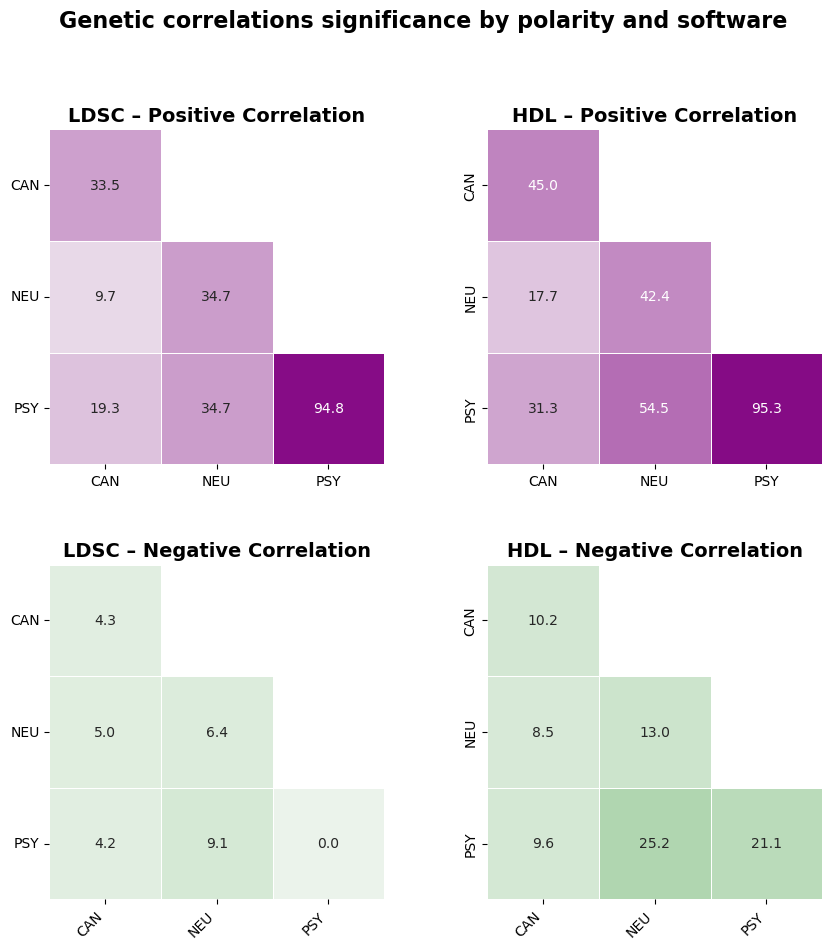

In [276]:
fig = plt.figure(figsize=(10, 10))

gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
ax1 = fig.add_subplot(gs[0, 0])  # LDSC Positive
ax2 = fig.add_subplot(gs[0, 1], sharex=ax1, sharey=ax1)  # HDL Positive
ax3 = fig.add_subplot(gs[1, 0], sharex=ax1, sharey=ax1)  # LDSC Negative 
ax4 = fig.add_subplot(gs[1, 1], sharex=ax1, sharey=ax1)  # HDL Negative 

# Define custom color maps
cmap_positive = sns.light_palette("purple", as_cmap=True)
cmap_negative = sns.light_palette("green", as_cmap=True)

# Common heatmap parameters
common_params = dict(annot=True, fmt='.1f', vmin=0, vmax=100, square=True, 
                     linewidths=0.5, cbar=False) # cbar=False

def create_triangle_mask(matrix):
    mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)
    return mask

# LDSC Positive (top-left)
sns.heatmap(ldsc_pos_matrix, ax=ax1, cmap=cmap_positive,
            mask=create_triangle_mask(ldsc_pos_matrix),
            **common_params)
ax1.set_title('LDSC – Positive Correlation', fontsize=14, fontweight='bold')
ax1.set_ylabel('', fontsize=12)
ax1.set_xlabel('') 

# HDL Positive (top-right)
sns.heatmap(hdl_pos_matrix, ax=ax2, cmap=cmap_positive,
            mask=create_triangle_mask(hdl_pos_matrix),
            **common_params)
ax2.set_title('HDL – Positive Correlation', fontsize=14, fontweight='bold')
ax2.set_xlabel('') 
ax2.set_ylabel('', fontsize=12)

# ax2.tick_params(labelleft=False) 

# LDSC Negative (bottom-left)
sns.heatmap(ldsc_neg_matrix, ax=ax3, cmap=cmap_negative,
            mask=create_triangle_mask(ldsc_neg_matrix),
            **common_params)
ax3.set_title('LDSC – Negative Correlation', fontsize=14, fontweight='bold')
ax3.set_xlabel('', fontsize=12)
ax3.set_ylabel('', fontsize=12)

# HDL Negative (bottom-right)
sns.heatmap(hdl_neg_matrix, ax=ax4, cmap=cmap_negative,
            mask=create_triangle_mask(hdl_neg_matrix),
            **common_params)
ax4.set_title('HDL – Negative Correlation', fontsize=14, fontweight='bold')
ax4.set_xlabel('', fontsize=12)
ax4.set_ylabel('', fontsize=12)
# ax4.tick_params(labelleft=False) 


plt.suptitle('Genetic correlations significance by polarity and software', fontsize=16, fontweight='bold', y=1.0)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax1.get_yticklabels(), rotation=0)
plt.setp(ax3.get_yticklabels(), rotation=0)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 

heatmap_significance_path = f"{significance_plots_dir}significance_heatmap_polarity"

plt.savefig(heatmap_significance_path + ".png", dpi=300, bbox_inches='tight')
plt.savefig(heatmap_significance_path + ".jpg", dpi=300, bbox_inches='tight')
plt.show()

### Overlap

Text(0.5, 1.0, 'Venn Diagram of Significant Correlations')

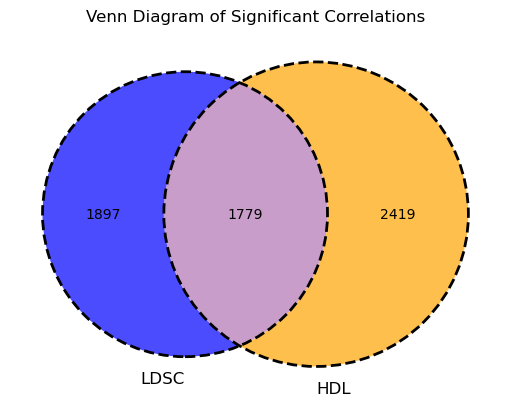

In [277]:
venn2(subsets=(len(ldsc_hdl_significant_either[ldsc_hdl_significant_either["p_FDR_rejected_ldsc"]==True]), 
			   len(ldsc_hdl_significant_either[ldsc_hdl_significant_either["p_FDR_rejected_hdl"]==True]), 
			   len(ldsc_hdl_significant_both)), 
			   set_labels=('LDSC', 'HDL'), 
			   set_colors=('blue', 'orange'),
			   alpha=0.7)
venn2_circles(subsets=(len(ldsc_hdl_significant_either[ldsc_hdl_significant_either["p_FDR_rejected_ldsc"]==True]), 
			   len(ldsc_hdl_significant_either[ldsc_hdl_significant_either["p_FDR_rejected_hdl"]==True]), 
			   len(ldsc_hdl_significant_both)), 
			   linestyle="dashed", linewidth=2)

venn_all_significant_save = f"{significance_plots_dir}venn_all_significant"
plt.savefig(f"{venn_all_significant_save}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{venn_all_significant_save}.jpg", dpi=300, bbox_inches="tight")
plt.title("Venn Diagram of Significant Correlations")

Text(0.5, 1.0, 'Venn Diagram of Significant Correlations')

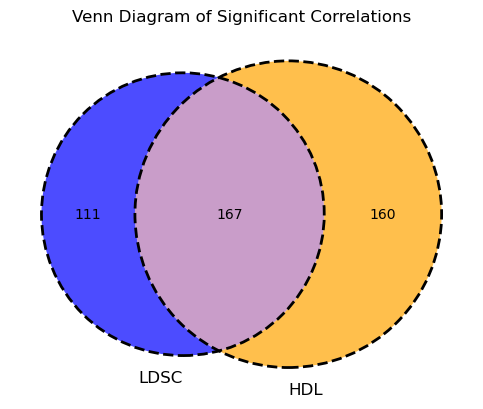

In [278]:
venn2(subsets=(len(ldsc_hdl_both_main_significant[ldsc_hdl_both_main_significant["p_FDR_rejected_ldsc"]==True]), 
			   len(ldsc_hdl_both_main_significant[ldsc_hdl_both_main_significant["p_FDR_rejected_hdl"]==True]), 
			   len(ldsc_hdl_both_main_significant)), 
			   set_labels=('LDSC', 'HDL'), 
			   set_colors=('blue', 'orange'),
			   alpha=0.7)
venn2_circles(subsets=(len(ldsc_hdl_both_main_significant[ldsc_hdl_both_main_significant["p_FDR_rejected_ldsc"]==True]), 
			   len(ldsc_hdl_both_main_significant[ldsc_hdl_both_main_significant["p_FDR_rejected_hdl"]==True]), 
			   len(ldsc_hdl_both_main_significant)), 
			   linestyle="dashed", linewidth=2)

venn_all_significant_save = f"{significance_plots_dir}venn_main_significant"
plt.savefig(f"{venn_all_significant_save}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{venn_all_significant_save}.jpg", dpi=300, bbox_inches="tight")
plt.title("Venn Diagram of Significant Correlations")

### Fisher test

#### Old functions

In [18]:
def fisher_test_all_combinations(
    df,
    method=False,
    category=False,
    types=False,
    polarity=False,
    pair_selection=None,
    category_selection=None,
    polarity_selection=None,
    table_name="Fisher_Test",
    compare=None,   # NEW: "method" | "category" | "types" | "polarity"
):
    data = df.copy()

    # ---------------------------------------------------------
    # 1) Decide what the MAIN comparison is
    #    - If compare is provided, it overrides everything.
    #    - Otherwise, we use a rule that matches your intent:
    #      method > types > polarity > category
    #
    #    This ensures: if method=False and category=True and types=True,
    #    we compare "types" (pair vs rest) and category acts as a filter.
    # ---------------------------------------------------------
    active = {
        "method": bool(method),
        "category": bool(category),
        "types": bool(types),
        "polarity": bool(polarity),
    }

    if compare is not None:
        if compare not in active:
            raise ValueError("compare must be one of: 'method', 'category', 'types', 'polarity'")
        if not active[compare]:
            raise ValueError(f"compare='{compare}' but the corresponding flag is False")
        comparison = compare
    else:
        if active["method"]:
            comparison = "method"
        elif active["types"]:
            comparison = "types"
        elif active["polarity"]:
            comparison = "polarity"
        elif active["category"]:
            # Only if nothing else is active, category becomes the comparison
            comparison = "category"
        else:
            return pd.DataFrame([{
                "Test": table_name, "Comparison": "None",
                "Group_A": np.nan, "Group_B": np.nan,
                "Sig_A": np.nan, "NoSig_A": np.nan,
                "Sig_B": np.nan, "NoSig_B": np.nan,
                "OR": np.nan, "P-Value": np.nan,
                "N_universe": 0
            }])

    # ---------------------------------------------------------
    # 2) Apply filters that are NOT the main comparison
    #    Here is the key change: category can be a filter even
    #    if category=True, as long as comparison != "category".
    # ---------------------------------------------------------
    universe = data

    # Category filter
    if category and comparison != "category":
        if category_selection is None:
            raise ValueError("category=True used as a filter, but category_selection=None")
        universe = universe[universe["Category"] == category_selection]

    # Types filter
    if types and comparison != "types":
        if pair_selection is None:
            raise ValueError("types=True used as a filter, but pair_selection=None")
        universe = universe[universe["Pair"] == pair_selection]

    # Polarity filter (combined across the two polarity columns)
    if polarity and comparison != "polarity":
        if polarity_selection is None:
            raise ValueError("polarity=True used as a filter, but polarity_selection=None")
        universe = universe[
            (universe["Polarity_ldsc"] == polarity_selection) |
            (universe["Polarity_hdl"] == polarity_selection)
        ]

    if universe.empty:
        return pd.DataFrame([{
            "Test": table_name, "Comparison": f"{comparison} (empty universe)",
            "Group_A": np.nan, "Group_B": np.nan,
            "Sig_A": 0, "NoSig_A": 0,
            "Sig_B": 0, "NoSig_B": 0,
            "OR": np.nan, "P-Value": np.nan,
            "N_universe": 0
        }])

    # ---------------------------------------------------------
    # 3) Build the two groups for the chosen comparison
    # ---------------------------------------------------------
    if comparison == "method":
        group_A_name, group_B_name = "HDL", "LDSC"

        # If polarity is the comparison, we'd be in comparison=="polarity".
        # Here, polarity=True means either filter (handled above) or
        # method-specific polarity counting (your special case).
        if polarity:
            # Interpret polarity as "method-specific" polarity selection only
            # when comparison == "method" AND polarity_selection is provided.
            if polarity_selection is None:
                raise ValueError("method comparison with polarity=True requires polarity_selection")

            hdl_rows = universe[universe["Polarity_hdl"] == polarity_selection]
            ldsc_rows = universe[universe["Polarity_ldsc"] == polarity_selection]

            Sig_A = (hdl_rows["p_FDR_rejected_hdl"] == True).sum()
            Sig_B = (ldsc_rows["p_FDR_rejected_ldsc"] == True).sum()
            NoSig_A = len(hdl_rows) - Sig_A
            NoSig_B = len(ldsc_rows) - Sig_B
        else:
            Sig_A = (universe["p_FDR_rejected_hdl"] == True).sum()
            Sig_B = (universe["p_FDR_rejected_ldsc"] == True).sum()
            NoSig_A = len(universe) - Sig_A
            NoSig_B = len(universe) - Sig_B

    else:
        # Combined significance for non-method comparisons
        def sig_any(d):
            return (d["p_FDR_rejected_ldsc"] == True) | (d["p_FDR_rejected_hdl"] == True)

        if comparison == "category":
            # Compare Intra vs Inter inside the current universe
            # (If you filtered by pair/polarity above, it compares within that subset)
            if category_selection is None:
                group_A_name, group_B_name = "Intra", "Inter"
            else:
                group_A_name = category_selection
                group_B_name = "Inter" if category_selection == "Intra" else "Intra"

            group_A_universe = universe[universe["Category"] == group_A_name]
            group_B_universe = universe[universe["Category"] == group_B_name]

        elif comparison == "types":
            # Compare selected Pair vs Rest inside the current universe
            if pair_selection is None:
                raise ValueError("types comparison requires pair_selection")
            group_A_name, group_B_name = pair_selection, "Rest"
            group_A_universe = universe[universe["Pair"] == pair_selection]
            group_B_universe = universe[universe["Pair"] != pair_selection]

        elif comparison == "polarity":
            # Compare Positive vs Negative inside the current universe
            if polarity_selection is None:
                raise ValueError("polarity comparison requires polarity_selection")
            opposite = "Negative" if polarity_selection == "Positive" else "Positive"
            group_A_name, group_B_name = polarity_selection, opposite

            group_A_universe = universe[
                (universe["Polarity_ldsc"] == group_A_name) |
                (universe["Polarity_hdl"] == group_A_name)
            ]
            group_B_universe = universe[
                (universe["Polarity_ldsc"] == group_B_name) |
                (universe["Polarity_hdl"] == group_B_name)
            ]

        Sig_A = sig_any(group_A_universe).sum()
        Sig_B = sig_any(group_B_universe).sum()
        NoSig_A = len(group_A_universe) - Sig_A
        NoSig_B = len(group_B_universe) - Sig_B

    # ---------------------------------------------------------
    # 4) Fisher exact test + output
    # ---------------------------------------------------------
    contingency = [[Sig_A, NoSig_A], [Sig_B, NoSig_B]]
    try:
        odds_ratio, p_value = stats.fisher_exact(contingency)
    except Exception:
        odds_ratio, p_value = np.nan, np.nan

    return pd.DataFrame([{
        "Test": table_name,
        "Comparison": f"{group_A_name} vs {group_B_name}",
        "Compare_Target": comparison,
        "Group_A": group_A_name,
        "Group_B": group_B_name,
        "Sig_A": int(Sig_A),
        "NoSig_A": int(NoSig_A),
        "Sig_B": int(Sig_B),
        "NoSig_B": int(NoSig_B),
        "OR": odds_ratio,
        "P-Value": p_value,
        "N_universe": int(len(universe))
    }])



In [19]:
def build_fisher_table(
    df,
    fisher_fn,                 # your modified fisher_test_all_combinations (with compare=)
    use_method=True,           # True: HDL vs LDSC. False: Pair vs Rest (combined sig)
    include_polarity=True,     # True: Overall/Positive/Negative. False: only Overall.
    pairs_intra=None,
    pairs_inter=None,
    table_name="Fisher_Table"
):
    data = df.copy()

    # -------------------------
    # Infer intra/inter pair membership if not provided (avoids NA spam)
    # -------------------------
    if pairs_intra is None or pairs_inter is None:
        pair_to_categories = (
            data[["Pair", "Category"]]
            .dropna()
            .drop_duplicates()
            .groupby("Pair")["Category"]
            .apply(lambda x: sorted(x.unique().tolist()))
        )
        inferred_intra = [pair for pair, cats in pair_to_categories.items() if cats == ["Intra"]]
        inferred_inter = [pair for pair, cats in pair_to_categories.items() if cats == ["Inter"]]

        if pairs_intra is None:
            pairs_intra = inferred_intra
        if pairs_inter is None:
            pairs_inter = inferred_inter

    pairs_all = list(dict.fromkeys(pairs_intra + pairs_inter))
    polarities = ["Overall"] + (["Positive", "Negative"] if include_polarity else [])

    # -------------------------
    # Helper: run your fisher function once and return compact strings
    # -------------------------
    def run_one(category_value, pair_value, polarity_value):
        use_category_filter = (category_value != "All")
        use_pair_filter = (pair_value != "All")
        use_polarity_filter = (polarity_value != "Overall")

        if use_method:
            # HDL vs LDSC inside the selected universe
            out = fisher_fn(
                data,
                method=True,
                category=use_category_filter,
                category_selection=(category_value if use_category_filter else None),
                types=use_pair_filter,
                pair_selection=(pair_value if use_pair_filter else None),
                polarity=use_polarity_filter,
                polarity_selection=(polarity_value if use_polarity_filter else None),
                table_name=table_name,
                compare="method"   # <- key
            )
            A_label, B_label = "HDL", "LDSC"

        else:
            # No method: keep ONE consistent comparison for all Pair rows => Pair vs Rest
            # Category/polarity can still be used as filters, because compare="types" forces the comparison.
            if pair_value == "All":
                # "All|All" doesn't work for Pair vs Rest, so use a meaningful global: Intra vs Inter
                out = fisher_fn(
                    data,
                    method=False,
                    category=True,
                    category_selection="Intra",   # sets group A; group B becomes Inter
                    types=False,
                    polarity=use_polarity_filter,
                    polarity_selection=(polarity_value if use_polarity_filter else None),
                    table_name=table_name,
                    compare="category"            # <- key
                )
                A_label, B_label = "Intra", "Inter"
            else:
                out = fisher_fn(
                    data,
                    method=False,
                    category=use_category_filter,
                    category_selection=(category_value if use_category_filter else None),
                    types=True,
                    pair_selection=pair_value,    # compares pair vs Rest
                    polarity=use_polarity_filter,
                    polarity_selection=(polarity_value if use_polarity_filter else None),
                    table_name=table_name,
                    compare="types"               # <- key: forces Pair vs Rest
                )
                A_label, B_label = "Pair", "Others"

        OR = out.loc[0, "OR"]
        p = out.loc[0, "P-Value"]
        N = int(out.loc[0, "N_universe"])
        sig_A = int(out.loc[0, "Sig_A"])
        sig_B = int(out.loc[0, "Sig_B"])

        fisher_str = "NA" if (pd.isna(OR) or pd.isna(p)) else f"{OR:.2f} (p={p:.2e})"
        samples_str = f"{A_label}={sig_A} | {B_label}={sig_B} | N={N}"

        return fisher_str, samples_str

    # -------------------------
    # Rows (no repetition: intra pairs only under Intra; inter pairs only under Inter)
    # -------------------------
    row_tuples = [("All", "All")] \
        + [("All", p) for p in pairs_all] \
        + [("Intra", p) for p in pairs_intra] \
        + [("Inter", p) for p in pairs_inter]

    # -------------------------
    # Columns: (Polarity, Fisher/Samples)
    # -------------------------
    columns = pd.MultiIndex.from_product(
        [polarities, ["Fisher", "Samples"]],
        names=["Polarity", "Info"]
    )

    table = pd.DataFrame(
        index=pd.MultiIndex.from_tuples(row_tuples, names=["Category", "Pair"]),
        columns=columns,
        dtype=object
    )

    for (cat, pair) in table.index:
        for pol in polarities:
            fisher_str, samples_str = run_one(cat, pair, pol)
            table.loc[(cat, pair), (pol, "Fisher")] = fisher_str
            table.loc[(cat, pair), (pol, "Samples")] = samples_str

    # -------------------------
    # Header mini-row "above"
    # -------------------------
    header_fisher, header_samples = run_one("All", "All", "Overall")
    header_name = "HDL vs LDSC (global)" if use_method else "Intra vs Inter (global)"

    header_df = pd.DataFrame([{
        "Test": table_name,
        "Header": header_name,
        "Fisher": header_fisher,
        "Samples": header_samples
    }])

    return header_df, table



In [23]:
def build_fisher_table_(
    df,
    fisher_fn,
    use_method=True,
    include_polarity=True,
    pairs_intra=None,
    pairs_inter=None,
    table_name="Fisher_Table"
):
    data = df.copy()

    # -------------------------
    # Infer intra/inter pair membership if not provided
    # -------------------------
    if pairs_intra is None or pairs_inter is None:
        pair_to_categories = (
            data[["Pair", "Category"]]
            .dropna()
            .drop_duplicates()
            .groupby("Pair")["Category"]
            .apply(lambda x: sorted(x.unique().tolist()))
        )
        inferred_intra = [pair for pair, cats in pair_to_categories.items() if cats == ["Intra"]]
        inferred_inter = [pair for pair, cats in pair_to_categories.items() if cats == ["Inter"]]

        if pairs_intra is None:
            pairs_intra = inferred_intra
        if pairs_inter is None:
            pairs_inter = inferred_inter

    pairs_all = list(dict.fromkeys(pairs_intra + pairs_inter))
    polarities = ["Overall"] + (["Positive", "Negative"] if include_polarity else [])

    # -------------------------
    # Helper: run fisher once and return compact strings
    # -------------------------
    def run_one(category_value, pair_value, polarity_value):
        # Treat ("X","All") as "filter only by X"
        use_category_filter = (category_value != "All")
        use_pair_filter = (pair_value != "All")
        use_polarity_filter = (polarity_value != "Overall")

        if use_method:
            out = fisher_fn(
                data,
                method=True,
                category=use_category_filter,
                category_selection=(category_value if use_category_filter else None),
                types=use_pair_filter,
                pair_selection=(pair_value if use_pair_filter else None),
                polarity=use_polarity_filter,
                polarity_selection=(polarity_value if use_polarity_filter else None),
                table_name=table_name,
                compare="method"
            )
            A_label, B_label = "HDL", "LDSC"

        else:
            # Keep your previous meaning for no-method (Pair vs Rest),
            # BUT: for the rows where pair_value=="All", give a meaningful category comparison.
            if pair_value == "All":
                out = fisher_fn(
                    data,
                    method=False,
                    category=True,
                    category_selection="Intra",
                    types=False,
                    polarity=use_polarity_filter,
                    polarity_selection=(polarity_value if use_polarity_filter else None),
                    table_name=table_name,
                    compare="category"
                )
                A_label, B_label = "Intra", "Inter"
            else:
                out = fisher_fn(
                    data,
                    method=False,
                    category=use_category_filter,  # category used as FILTER
                    category_selection=(category_value if use_category_filter else None),
                    types=True,
                    pair_selection=pair_value,
                    polarity=use_polarity_filter,
                    polarity_selection=(polarity_value if use_polarity_filter else None),
                    table_name=table_name,
                    compare="types"
                )
                A_label, B_label = "Pair", "Others"

        OR = out.loc[0, "OR"]
        p = out.loc[0, "P-Value"]
        N = int(out.loc[0, "N_universe"])
        sig_A = int(out.loc[0, "Sig_A"])
        sig_B = int(out.loc[0, "Sig_B"])

        fisher_str = "NA" if (pd.isna(OR) or pd.isna(p)) else f"{OR:.2f} (p={p:.2e})"
        samples_str = f"{A_label}={sig_A} | {B_label}={sig_B} | N={N}"

        return fisher_str, samples_str

    # -------------------------
    # ✅ NEW ROW STRUCTURE (no duplicates)
    # - Global: ("All","All")
    # - Category block: ("Intra","All"), ("Inter","All")
    # - Pair block: ("Pair","<pairname>") for every pair once
    # -------------------------
    row_tuples = [("All", "All")] + [("Intra", "All")] + [("Inter", "All")] + [("Pair", p) for p in pairs_all]

    # Columns
    columns = pd.MultiIndex.from_product(
        [polarities, ["Fisher", "Samples"]],
        names=["Polarity", "Info"]
    )

    table = pd.DataFrame(
        index=pd.MultiIndex.from_tuples(row_tuples, names=["Group", "Label"]),
        columns=columns,
        dtype=object
    )

    # Fill
    for (group, label) in table.index:
        for pol in polarities:
            if group == "All":
                fisher_str, samples_str = run_one("All", "All", pol)
            elif group == "Intra":
                fisher_str, samples_str = run_one("Intra", "All", pol)   # filter only by category
            elif group == "Inter":
                fisher_str, samples_str = run_one("Inter", "All", pol)   # filter only by category
            elif group == "Pair":
                fisher_str, samples_str = run_one("All", label, pol)     # filter only by pair (no category)
            else:
                fisher_str, samples_str = "NA", "NA"

            table.loc[(group, label), (pol, "Fisher")] = fisher_str
            table.loc[(group, label), (pol, "Samples")] = samples_str

    # Header
    header_fisher, header_samples = run_one("All", "All", "Overall")
    header_name = "HDL vs LDSC (global)" if use_method else "Intra vs Inter (global)"

    header_df = pd.DataFrame([{
        "Test": table_name,
        "Header": header_name,
        "Fisher": header_fisher,
        "Samples": header_samples
    }])

    return header_df, table


In [20]:
def _pretty_for_image(df, wrap_width=22):
    """
    - Turns MultiIndex rows into 2 columns: Category, Pair
    - Blanks repeated Category values (visual grouping)
    - Flattens columns like ('Overall','Fisher') -> 'Overall_Fisher'
    - Wraps long cell strings into multiple lines
    """
    out = df.copy()

    # --- MultiIndex rows -> columns ---
    if isinstance(out.index, pd.MultiIndex):
        out = out.reset_index()
        # Blank repeated Category to mimic multirow grouping
        if "Category" in out.columns:
            out["Category"] = out["Category"].where(out["Category"].ne(out["Category"].shift()), "")

    # --- MultiIndex columns -> flat names ---
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = ["_".join([str(x) for x in col if str(x) != ""]) for col in out.columns]

    # --- Wrap text in cells ---
    def wrap_cell(x):
        if pd.isna(x):
            return ""
        s = str(x)
        # Keep separators readable
        s = s.replace(" | ", "\n")
        return "\n".join(textwrap.wrap(s, width=wrap_width, break_long_words=False))

    return out.applymap(wrap_cell)


In [21]:
def save_table_image(df, filename_png="table.png", filename_pdf="table.pdf",
                     dpi=300, font_size=8, wrap_width=22):
    show_df = _pretty_for_image(df, wrap_width=wrap_width)

    nrows, ncols = show_df.shape

    # Figure size heuristic (tune if needed)
    fig_w = max(10, ncols * 2.2)
    fig_h = max(4, nrows * 0.45)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis("off")

    table = ax.table(
        cellText=show_df.values,
        colLabels=show_df.columns,
        loc="center",
        cellLoc="center",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)

    # Auto column widths (works better after drawing)
    try:
        table.auto_set_column_width(col=list(range(ncols)))
    except Exception:
        pass

    # Slight scaling to give breathing room
    table.scale(1.0, 1.4)

    plt.tight_layout()
    if filename_pdf:
        plt.savefig(filename_pdf, bbox_inches="tight")      # vector = best for paper
    plt.savefig(filename_png, dpi=dpi, bbox_inches="tight")
    plt.close(fig)


#### Function

In [19]:
def fisher_exact_to_excel(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    excel_file: str,
    tab_name: str,
    output_folder: str,
    sig_col: str,
    group1_name: str = "Group 1",
    group2_name: str = "Group 2",
) -> pd.DataFrame:
    """
    Fisher exact test on counts of significant results (sig_col==True) in df1 vs df2.
    Writes to one Excel workbook with one sheet per test. If sheet exists, replace.
    Returns a tidy dataframe including odds ratio and p-value.
    """

    if sig_col not in df1.columns:
        raise KeyError(f"Column '{sig_col}' not found in df1.")
    if sig_col not in df2.columns:
        raise KeyError(f"Column '{sig_col}' not found in df2.")

    s1 = df1[sig_col].astype(bool)
    s2 = df2[sig_col].astype(bool)

    total_1 = int(len(df1))
    total_2 = int(len(df2))
    sig_1 = int(s1.sum())
    sig_2 = int(s2.sum())
    nonsig_1 = total_1 - sig_1
    nonsig_2 = total_2 - sig_2

    contingency = [[sig_1, nonsig_1], [sig_2, nonsig_2]]
    or_12, p_value = stats.fisher_exact(contingency)

    # OR invertido (manejo seguro)
    if or_12 == 0:
        or_21 = np.inf
    elif np.isinf(or_12):
        or_21 = 0.0
    else:
        or_21 = 1.0 / or_12

    interp_12 = f"Odds of finding significance in {group1_name} vs {group2_name}"
    interp_21 = f"Odds of finding significance in {group2_name} vs {group1_name}"

    result_df = pd.DataFrame({
        "Group": [group1_name, group2_name],
        "Total": [total_1, total_2],
        "Significant": [sig_1, sig_2],
        "Not Significant": [nonsig_1, nonsig_2],
        "Odds Ratio": [f"{or_12:.3f}", f"{or_21:.3f}"],
        "P-Value": [p_value, p_value],
        "Interpretation": [interp_12, interp_21],
    })

    os.makedirs(output_folder, exist_ok=True)
    save_path = os.path.join(output_folder, excel_file)
    file_exists = os.path.exists(save_path)

    if file_exists:
        with pd.ExcelWriter(save_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
            result_df.to_excel(writer, sheet_name=tab_name, index=False, startrow=0)
    else:
        with pd.ExcelWriter(save_path, engine="openpyxl", mode="w") as writer:
            result_df.to_excel(writer, sheet_name=tab_name, index=False, startrow=0)

    return result_df

In [20]:
def _safe_sheet_name(name: str, max_len: int = 31) -> str:
    name = str(name)
    name = re.sub(r"[\[\]\:\*\?\/\\]", "_", name).strip()
    return (name if name else "sheet")[:max_len]

def stack_fisher_outputs_to_excel(
    outputs: dict,
    excel_file: str,
    output_folder: str,
    tab_name: str = "SUMMARY",
    test_order: list | None = None,
    software1_label: str = "LDSC",
    software2_label: str = "HDL",
) -> pd.DataFrame:
    """
    Crea una tabla combinada con header doble (MultiIndex) y la guarda en una tab nueva.
    NOTA: para evitar NotImplementedError de pandas, escribimos con index=True (Test como índice).
    """

    if test_order is None:
        test_names = list(outputs.keys())
    else:
        test_names = test_order

    rows = []
    for test in test_names:
        df = outputs[test].copy()
        if df.shape[0] < 2:
            raise ValueError(f"El output '{test}' no tiene 2 filas (Group1/Group2).")

        g1 = df.iloc[0]  # LDSC
        g2 = df.iloc[1]  # HDL

        sig1 = int(g1["Significant"])
        nonsig1 = int(g1["Not Significant"])
        sig2 = int(g2["Significant"])
        nonsig2 = int(g2["Not Significant"])

        if "Odds Ratio (G1 vs G2)" in df.columns:
            or_12 = float(g1["Odds Ratio (G1 vs G2)"])
        elif "Odds Ratio" in df.columns:
            or_12 = float(g1["Odds Ratio"])
        else:
            raise KeyError("No encuentro columna de Odds Ratio en el output.")

        if "Odds Ratio (G2 vs G1)" in df.columns:
            or_21 = float(g1["Odds Ratio (G2 vs G1)"])
        else:
            or_21 = (1.0 / or_12) if or_12 != 0 else float("inf")

        if "P-Value" in df.columns:
            pval = float(g1["P-Value"])
        else:
            raise KeyError("No encuentro columna 'P-Value' en el output.")

        rows.append([test, sig1, nonsig1, or_12, sig2, nonsig2, or_21, pval])

    cols = pd.MultiIndex.from_tuples([
        (software1_label, "N sig"),
        (software1_label, "N no sig"),
        (software1_label, "OR"),
        (software2_label, "N sig"),
        (software2_label, "N no sig"),
        (software2_label, "OR"),
        ("", "p-value"),
    ])

    # Test como índice (así Excel sale bonito y evitamos el bug)
    summary_df = pd.DataFrame(
        [r[1:] for r in rows],
        index=[r[0] for r in rows],
        columns=cols
    )
    summary_df.index.name = ("Test")  # para que el header del index salga como "Test"

    # --- write excel ---
    os.makedirs(output_folder, exist_ok=True)
    path = os.path.join(output_folder, excel_file)
    mode = "a" if os.path.exists(path) else "w"
    sheet = _safe_sheet_name(tab_name)

    if mode == "a":
        with pd.ExcelWriter(path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
            summary_df.to_excel(writer, sheet_name=sheet, merge_cells=True)  # index=True por defecto
    else:
        with pd.ExcelWriter(path, engine="openpyxl", mode="w") as writer:
            summary_df.to_excel(writer, sheet_name=sheet, merge_cells=True)

    return summary_df

#### Sofware comparison

In [21]:
overall_software_comparison = fisher_exact_to_excel(
    df1=ldsc,
    df2=hdl,
    excel_file="fisher_software_comparison.xlsx",
    tab_name="software_overall",
    output_folder=significance_tables_dir,
    sig_col="p_FDR_rejected",
	group1_name="LDSC",
	group2_name="HDL"
)

overall_software_comparison

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC,6670,2040,4630,0.635,6.733156e-34,Odds of finding significance in LDSC vs HDL
1,HDL,5904,2419,3485,1.575,6.733156e-34,Odds of finding significance in HDL vs LDSC


In [22]:
# Loop to create combinations of category
for category in ["Intra", "Inter"]:
	category_ldsc = ldsc[ldsc["Category"] == category]
	category_hdl = hdl[hdl["Category"] == category]

	locals()[f"software_{category.lower()}_comparison"] = fisher_exact_to_excel(
		df1=category_ldsc,
		df2=category_hdl,
		excel_file="fisher_software_comparison.xlsx",
		tab_name=f"software_{category}",
		output_folder=significance_tables_dir,
		sig_col="p_FDR_rejected",
		group1_name=f"LDSC: {category}",
		group2_name=f"HDL: {category}"
	)

display(software_intra_comparison)
display(software_inter_comparison)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: Intra,2578,1424,1154,0.690,3.228115e-10,Odds of finding significance in LDSC: Intra vs...
1,HDL: Intra,2254,1446,808,1.450,3.228115e-10,Odds of finding significance in HDL: Intra vs ...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: Inter,4092,616,3476,0.488,1.834708e-36,Odds of finding significance in LDSC: Inter vs...
1,HDL: Inter,3650,973,2677,2.051,1.834708e-36,Odds of finding significance in HDL: Inter vs ...


In [23]:
# Loop to create combinations of polarity
for polarity in ['Negative', 'Positive']:
	polarity_ldsc = ldsc[ldsc["Polarity"] == polarity]
	polarity_hdl = hdl[hdl["Polarity"] == polarity]

	locals()[f"software_{polarity.lower()}_comparison"] = fisher_exact_to_excel(
		df1=polarity_ldsc,
		df2=polarity_hdl,
		excel_file="fisher_software_comparison.xlsx",
		tab_name=f"software_{polarity}",
		output_folder=significance_tables_dir,
		sig_col="p_FDR_rejected",
		group1_name=f"LDSC: {polarity}",
		group2_name=f"HDL: {polarity}"
	)

display(software_negative_comparison)
display(software_positive_comparison)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: Negative,1762,92,1670,0.393,1.403647e-12,Odds of finding significance in LDSC: Negative...
1,HDL: Negative,1400,172,1228,2.542,1.403647e-12,Odds of finding significance in HDL: Negative ...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: Positive,4908,1948,2960,0.661,3.054516e-23,Odds of finding significance in LDSC: Positive...
1,HDL: Positive,4504,2247,2257,1.513,3.054516e-23,Odds of finding significance in HDL: Positive ...


In [24]:
# Loop to create combinations of pairs
for pair in ['CAN-CAN','PSY-PSY', 'NEU-NEU','CAN-NEU','CAN-PSY','NEU-PSY']:
	pair_ldsc = ldsc[ldsc["Pair"] == pair]
	pair_hdl = hdl[hdl["Pair"] == pair]

	locals()[f"software_{pair.lower().replace('-', '_')}_comparison"] = fisher_exact_to_excel(
		df1=pair_ldsc,
		df2=pair_hdl,
		excel_file="fisher_software_comparison.xlsx",
		tab_name=f"software_{pair}",
		output_folder=significance_tables_dir,
		sig_col="p_FDR_rejected",
		group1_name=f"LDSC: {pair}",
		group2_name=f"HDL: {pair}"
	)

display(software_can_can_comparison)
display(software_psy_psy_comparison)
display(software_neu_neu_comparison)
display(software_can_neu_comparison)
display(software_can_psy_comparison)
display(software_neu_psy_comparison)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: CAN-CAN,1326,375,951,0.600,4.360980e-09,Odds of finding significance in LDSC: CAN-CAN ...
1,HDL: CAN-CAN,1082,429,653,1.666,4.360980e-09,Odds of finding significance in HDL: CAN-CAN v...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: PSY-PSY,1081,1003,78,1.032,0.868173,Odds of finding significance in LDSC: PSY-PSY ...
1,HDL: PSY-PSY,1050,972,78,0.969,0.868173,Odds of finding significance in HDL: PSY-PSY v...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: NEU-NEU,171,46,125,0.630,0.074135,Odds of finding significance in LDSC: NEU-NEU ...
1,HDL: NEU-NEU,122,45,77,1.588,0.074135,Odds of finding significance in HDL: NEU-NEU v...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: CAN-NEU,918,71,847,0.500,0.000016,Odds of finding significance in LDSC: CAN-NEU ...
1,HDL: CAN-NEU,752,108,644,2.001,0.000016,Odds of finding significance in HDL: CAN-NEU v...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: CAN-PSY,2346,336,2010,0.516,5.954316e-18,Odds of finding significance in LDSC: CAN-PSY ...
1,HDL: CAN-PSY,2162,529,1633,1.938,5.954316e-18,Odds of finding significance in HDL: CAN-PSY v...


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,LDSC: NEU-PSY,828,209,619,0.402,3.088006e-17,Odds of finding significance in LDSC: NEU-PSY ...
1,HDL: NEU-PSY,736,336,400,2.488,3.088006e-17,Odds of finding significance in HDL: NEU-PSY v...


In [25]:
software_all_stack = {

    "Overall": overall_software_comparison,
    "Intra": software_intra_comparison,
    "Inter": software_inter_comparison,    
	"Negative": software_negative_comparison,
    "Positive": software_positive_comparison,
	"CAN-CAN": software_can_can_comparison,
	"PSY-PSY": software_psy_psy_comparison,
	"NEU-NEU": software_neu_neu_comparison,
	"CAN-NEU": software_can_neu_comparison,
	"CAN-PSY": software_can_psy_comparison,
	"NEU-PSY": software_neu_psy_comparison,
}

software_all_summary = stack_fisher_outputs_to_excel(
    outputs=software_all_stack,
    excel_file="fisher_software_comparison.xlsx",
    output_folder=significance_tables_dir,
    tab_name="software_summmary",
    test_order=["Overall", "Intra", "Inter", "Positive", "Negative", "CAN-CAN", "PSY-PSY", "NEU-NEU", "CAN-NEU", "CAN-PSY", "NEU-PSY"],
	software1_label="LDSC",
    software2_label="HDL",
)

display(software_all_summary)

LDSC                   HDL                                 
         N sig N no sig     OR N sig N no sig        OR       p-value
Test                                                                 
Overall   2040     4630  0.635  2419     3485  1.574803  6.733156e-34
Intra     1424     1154  0.690  1446      808  1.449275  3.228115e-10
Inter      616     3476  0.488   973     2677  2.049180  1.834708e-36
Positive  1948     2960  0.661  2247     2257  1.512859  3.054516e-23
Negative    92     1670  0.393   172     1228  2.544529  1.403647e-12
CAN-CAN    375      951  0.600   429      653  1.666667  4.360980e-09
PSY-PSY   1003       78  1.032   972       78  0.968992  8.681733e-01
NEU-NEU     46      125  0.630    45       77  1.587302  7.413451e-02
CAN-NEU     71      847  0.500   108      644  2.000000  1.584633e-05
CAN-PSY    336     2010  0.516   529     1633  1.937984  5.954316e-18
NEU-PSY    209      619  0.402   336      400  2.487562  3.088006e-17

In [ ]:
comparison_export = software_all_summary.copy()

comparison_export.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in comparison_export.columns]

csv_path = os.path.join(significance_tables_dir, "software_summary_plain.csv")
comparison_export.to_csv(csv_path, index=False)

print(f"Archivo guardado para R en: {csv_path}")
comparison_export

Archivo guardado para R en: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/significance/software_summary_plain.csv


,LDSC_N sig,LDSC_N no sig,LDSC_OR,HDL_N sig,HDL_N no sig,HDL_OR,_p-value
Test,,,,,,,
Overall,2040,4630,0.635,2419,3485,1.574803,6.733156e-34
Intra,1424,1154,0.690,1446,808,1.449275,3.228115e-10
Inter,616,3476,0.488,973,2677,2.049180,1.834708e-36
Positive,1948,2960,0.661,2247,2257,1.512859,3.054516e-23
Negative,92,1670,0.393,172,1228,2.544529,1.403647e-12
CAN-CAN,375,951,0.600,429,653,1.666667,4.360980e-09
PSY-PSY,1003,78,1.032,972,78,0.968992,8.681733e-01
NEU-NEU,46,125,0.630,45,77,1.587302,7.413451e-02
CAN-NEU,71,847,0.500,108,644,2.000000,1.584633e-05


#### LDSC

In [28]:
ldsc_intra = ldsc[ldsc["Category"] == "Intra"]
ldsc_inter = ldsc[ldsc["Category"] == "Inter"]

ldsc_intra_vs_inter = fisher_exact_to_excel(
    df1=ldsc_intra,
    df2=ldsc_inter,
    excel_file="fisher_LDSC.xlsx",
    tab_name=f"Intra_vs_Inter",
    output_folder=significance_tables_dir,
    sig_col="p_FDR_rejected",
    group1_name=f"Intra",
    group2_name=f"Inter",
)

display(ldsc_intra_vs_inter)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,Intra,2578,1424,1154,6.963,5.819777e-263,Odds of finding significance in Intra vs Inter
1,Inter,4092,616,3476,0.144,5.819777e-263,Odds of finding significance in Inter vs Intra


In [29]:
ldsc_pos = ldsc[ldsc["Polarity"] == "Positive"]
ldsc_neg = ldsc[ldsc["Polarity"] == "Negative"]

ldsc_pos_vs_neg = fisher_exact_to_excel(
    df1=ldsc_pos,
    df2=ldsc_neg,
    excel_file="fisher_LDSC.xlsx",
    tab_name=f"Positive_vs_Negative",
    output_folder=significance_tables_dir,
    sig_col="p_FDR_rejected",
    group1_name=f"Positive",
    group2_name=f"Negative",
)

display(ldsc_pos_vs_neg)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,Positive,4908,1948,2960,11.946,8.991895e-197,Odds of finding significance in Positive vs Ne...
1,Negative,1762,92,1670,0.084,8.991895e-197,Odds of finding significance in Negative vs Po...


In [30]:
intra_pairs = ldsc[ldsc["Category"] == "Intra"]["Pair"].unique()
inter_pairs = ldsc[ldsc["Category"] == "Inter"]["Pair"].unique()

for pair in intra_pairs:
    pair_safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(pair)).strip("_").lower()
    if pair_safe and pair_safe[0].isdigit():
        pair_safe = f"x_{pair_safe}"

    # 1) pair vs resto (global)
    df_pair = ldsc[ldsc["Pair"] == pair]
    df_rest = ldsc[ldsc["Pair"] != pair]

    globals()[f"ldsc_{pair_safe}_vs_all"] = fisher_exact_to_excel(
        df1=df_pair,
        df2=df_rest,
        excel_file="fisher_LDSC.xlsx",
        tab_name=f"{pair}_vs_all",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="All pairs",
    )

    # 2) pair vs resto dentro de Intra
    df_cat = ldsc[ldsc["Category"] == "Intra"]
    df_pair_cat = df_cat[df_cat["Pair"] == pair]
    df_rest_cat = df_cat[df_cat["Pair"] != pair]

    globals()[f"ldsc_{pair_safe}_vs_intra_rest"] = fisher_exact_to_excel(
        df1=df_pair_cat,
        df2=df_rest_cat,
        excel_file="fisher_LDSC.xlsx",
        tab_name=f"{pair}_vs_Intra_rest",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="Intra Others",
    )

print("LDSC Intra pairs comparisons:")
print(f"ldsc_can_can_vs_all")
display(ldsc_can_can_vs_all)
print(f"ldsc_can_can_vs_intra_rest")
display(ldsc_can_can_vs_intra_rest)
print(f"ldsc_psy_psy_vs_all")
display(ldsc_psy_psy_vs_all)
print(f"ldsc_psy_psy_vs_intra_rest")
display(ldsc_psy_psy_vs_intra_rest)
print(f"ldsc_neu_neu_vs_all")
display(ldsc_neu_neu_vs_all)
print(f"ldsc_neu_neu_vs_intra_rest")
display(ldsc_neu_neu_vs_intra_rest)



for pair in inter_pairs:
    pair_safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(pair)).strip("_").lower()
    if pair_safe and pair_safe[0].isdigit():
        pair_safe = f"x_{pair_safe}"

    # 1) pair vs resto (global)
    df_pair = ldsc[ldsc["Pair"] == pair]
    df_rest = ldsc[ldsc["Pair"] != pair]

    globals()[f"ldsc_{pair_safe}_vs_all"] = fisher_exact_to_excel(
        df1=df_pair,
        df2=df_rest,
        excel_file="fisher_LDSC.xlsx",
        tab_name=f"{pair}_vs_all",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="All pairs",
    )

    # 2) pair vs resto dentro de Intra
    df_cat = ldsc[ldsc["Category"] == "Inter"]
    df_pair_cat = df_cat[df_cat["Pair"] == pair]
    df_rest_cat = df_cat[df_cat["Pair"] != pair]

    globals()[f"ldsc_{pair_safe}_vs_inter_rest"] = fisher_exact_to_excel(
        df1=df_pair_cat,
        df2=df_rest_cat,
        excel_file="fisher_LDSC.xlsx",
        tab_name=f"{pair}_vs_Inter_rest",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="Inter Others",
    )


print("LDSC Inter pairs comparisons:")
print(f"ldsc_can_psy_vs_all")
display(ldsc_can_psy_vs_all)
print(f"ldsc_can_psy_vs_inter_rest")
display(ldsc_can_psy_vs_inter_rest)
print(f"ldsc_can_neu_vs_all")
display(ldsc_can_neu_vs_all)
print(f"ldsc_can_neu_vs_inter_rest")
display(ldsc_can_neu_vs_inter_rest)
print(f"ldsc_neu_psy_vs_all")
display(ldsc_neu_psy_vs_all)
print(f"ldsc_neu_psy_vs_inter_rest")
display(ldsc_neu_psy_vs_inter_rest)


LDSC Intra pairs comparisons:
ldsc_can_can_vs_all


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-CAN,1326,375,951,0.871,0.042305,Odds of finding significance in CAN-CAN vs All...
1,All pairs,5344,1665,3679,1.148,0.042305,Odds of finding significance in All pairs vs C...


ldsc_can_can_vs_intra_rest


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-CAN,1326,375,951,0.076,1.167103e-187,Odds of finding significance in CAN-CAN vs Int...
1,Intra Others,1252,1049,203,13.105,1.167103e-187,Odds of finding significance in Intra Others v...


ldsc_psy_psy_vs_all


...

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-NEU,918,71,847,0.404,9.412978e-14,Odds of finding significance in CAN-NEU vs Int...
1,Inter Others,3174,545,2629,2.473,9.412978e-14,Odds of finding significance in Inter Others v...


ldsc_neu_psy_vs_all


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,NEU-PSY,828,209,619,0.740,0.000331,Odds of finding significance in NEU-PSY vs All...
1,All pairs,5842,1831,4011,1.352,0.000331,Odds of finding significance in All pairs vs N...


ldsc_neu_psy_vs_inter_rest


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,NEU-PSY,828,209,619,2.370,3.099454e-18,Odds of finding significance in NEU-PSY vs Int...
1,Inter Others,3264,407,2857,0.422,3.099454e-18,Odds of finding significance in Inter Others v...


In [31]:
software_ldsc_stack = {

    "Category": ldsc_intra_vs_inter,
    "Polarity": ldsc_pos_vs_neg,    
	"Pair: CAN-CAN": ldsc_can_can_vs_all,
	"Pair: PSY-PSY": ldsc_psy_psy_vs_all,
	"Pair: NEU-NEU": ldsc_neu_neu_vs_all,
	"Pair: CAN-NEU": ldsc_can_neu_vs_all,
	"Pair: CAN-PSY": ldsc_can_psy_vs_all,
	"Pair: NEU-PSY": ldsc_neu_psy_vs_all,
}

ldsc_all_summary = stack_fisher_outputs_to_excel(
    outputs=software_ldsc_stack,
    excel_file="fisher_LDSC.xlsx",
    output_folder=significance_tables_dir,
    tab_name="ldsc_all_summary",
    test_order=["Category", "Polarity", "Pair: CAN-CAN", "Pair: PSY-PSY", "Pair: NEU-NEU", "Pair: CAN-NEU", "Pair: CAN-PSY", "Pair: NEU-PSY"],
	software1_label="TEST1",
    software2_label="HTEST2",
)

display(ldsc_all_summary)

TEST1                  HTEST2                                  
              N sig N no sig      OR  N sig N no sig        OR        p-value
Test                                                                         
Category       1424     1154   6.963    616     3476  0.143616  5.819777e-263
Polarity       1948     2960  11.946     92     1670  0.083710  8.991895e-197
Pair: CAN-CAN   375      951   0.871   1665     3679  1.148106   4.230521e-02
Pair: PSY-PSY  1003       78  56.446   1037     4552  0.017716   0.000000e+00
Pair: NEU-NEU    46      125   0.831   1994     4505  1.203369   3.135897e-01
Pair: CAN-NEU    71      847   0.161   1969     3783  6.211180   1.123642e-71
Pair: CAN-PSY   336     2010   0.257   1704     2620  3.891051  8.212383e-108
Pair: NEU-PSY   209      619   0.740   1831     4011  1.351351   3.311492e-04

In [32]:
ldsc_export = ldsc_all_summary.copy()

ldsc_export.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in ldsc_export.columns]

csv_path = os.path.join(significance_tables_dir, "ldsc_summary_plain.csv")
ldsc_export.to_csv(csv_path, index=False)

print(f"Archivo guardado para R en: {csv_path}")
ldsc_export

Archivo guardado para R en: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/significance/ldsc_summary_plain.csv


,TEST1_N sig,TEST1_N no sig,TEST1_OR,HTEST2_N sig,HTEST2_N no sig,HTEST2_OR,_p-value
Test,,,,,,,
Category,1424,1154,6.963,616,3476,0.143616,5.819777e-263
Polarity,1948,2960,11.946,92,1670,0.083710,8.991895e-197
Pair: CAN-CAN,375,951,0.871,1665,3679,1.148106,4.230521e-02
Pair: PSY-PSY,1003,78,56.446,1037,4552,0.017716,0.000000e+00
Pair: NEU-NEU,46,125,0.831,1994,4505,1.203369,3.135897e-01
Pair: CAN-NEU,71,847,0.161,1969,3783,6.211180,1.123642e-71
Pair: CAN-PSY,336,2010,0.257,1704,2620,3.891051,8.212383e-108
Pair: NEU-PSY,209,619,0.740,1831,4011,1.351351,3.311492e-04


#### HDL

In [33]:
hdl_intra = hdl[hdl["Category"] == "Intra"]
hdl_inter = hdl[hdl["Category"] == "Inter"]

hdl_intra_vs_inter = fisher_exact_to_excel(
    df1=hdl_intra,
    df2=hdl_inter,
    excel_file="fisher_HDL.xlsx",
    tab_name=f"Intra_vs_Inter",
    output_folder=significance_tables_dir,
    sig_col="p_FDR_rejected",
    group1_name=f"Intra",
    group2_name=f"Inter",
)

display(hdl_intra_vs_inter)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,Intra,2254,1446,808,4.924,1.594229e-179,Odds of finding significance in Intra vs Inter
1,Inter,3650,973,2677,0.203,1.594229e-179,Odds of finding significance in Inter vs Intra


In [34]:
hdl_pos = hdl[hdl["Polarity"] == "Positive"]
hdl_neg = hdl[hdl["Polarity"] == "Negative"]

hdl_pos_vs_neg = fisher_exact_to_excel(
    df1=hdl_pos,
    df2=hdl_neg,
    excel_file="fisher_HDL.xlsx",
    tab_name=f"Positive_vs_Negative",
    output_folder=significance_tables_dir,
    sig_col="p_FDR_rejected",
    group1_name=f"Positive",
    group2_name=f"Negative",
)

display(hdl_pos_vs_neg)

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,Positive,4504,2247,2257,7.108,6.745673e-155,Odds of finding significance in Positive vs Ne...
1,Negative,1400,172,1228,0.141,6.745673e-155,Odds of finding significance in Negative vs Po...


In [35]:
intra_pairs = hdl[hdl["Category"] == "Intra"]["Pair"].unique()
inter_pairs = hdl[hdl["Category"] == "Inter"]["Pair"].unique()

for pair in intra_pairs:
    pair_safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(pair)).strip("_").lower()
    if pair_safe and pair_safe[0].isdigit():
        pair_safe = f"x_{pair_safe}"

    # 1) pair vs resto (global)
    df_pair = hdl[hdl["Pair"] == pair]
    df_rest = hdl[hdl["Pair"] != pair]

    globals()[f"hdl_{pair_safe}_vs_all"] = fisher_exact_to_excel(
        df1=df_pair,
        df2=df_rest,
        excel_file="fisher_HDL.xlsx",
        tab_name=f"{pair}_vs_all",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="All pairs",
    )

    # 2) pair vs resto dentro de Intra
    df_cat = hdl[hdl["Category"] == "Intra"]
    df_pair_cat = df_cat[df_cat["Pair"] == pair]
    df_rest_cat = df_cat[df_cat["Pair"] != pair]

    globals()[f"hdl_{pair_safe}_vs_intra_rest"] = fisher_exact_to_excel(
        df1=df_pair_cat,
        df2=df_rest_cat,
        excel_file="fisher_HDL.xlsx",
        tab_name=f"{pair}_vs_Intra_rest",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="Intra Others",
    )

print("hdl Intra pairs comparisons:")
print(f"hdl_can_can_vs_all")
display(hdl_can_can_vs_all)
print(f"hdl_can_can_vs_intra_rest")
display(hdl_can_can_vs_intra_rest)
print(f"hdl_psy_psy_vs_all")
display(hdl_psy_psy_vs_all)
print(f"hdl_psy_psy_vs_intra_rest")
display(hdl_psy_psy_vs_intra_rest)
print(f"hdl_neu_neu_vs_all")
display(hdl_neu_neu_vs_all)
print(f"hdl_neu_neu_vs_intra_rest")
display(hdl_neu_neu_vs_intra_rest)



for pair in inter_pairs:
    pair_safe = re.sub(r"[^0-9a-zA-Z_]+", "_", str(pair)).strip("_").lower()
    if pair_safe and pair_safe[0].isdigit():
        pair_safe = f"x_{pair_safe}"

    # 1) pair vs resto (global)
    df_pair = hdl[hdl["Pair"] == pair]
    df_rest = hdl[hdl["Pair"] != pair]

    globals()[f"hdl_{pair_safe}_vs_all"] = fisher_exact_to_excel(
        df1=df_pair,
        df2=df_rest,
        excel_file="fisher_HDL.xlsx",
        tab_name=f"{pair}_vs_all",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="All pairs",
    )

    # 2) pair vs resto dentro de Intra
    df_cat = hdl[hdl["Category"] == "Inter"]
    df_pair_cat = df_cat[df_cat["Pair"] == pair]
    df_rest_cat = df_cat[df_cat["Pair"] != pair]

    globals()[f"hdl_{pair_safe}_vs_inter_rest"] = fisher_exact_to_excel(
        df1=df_pair_cat,
        df2=df_rest_cat,
        excel_file="fisher_HDL.xlsx",
        tab_name=f"{pair}_vs_Inter_rest",
        output_folder=significance_tables_dir,
        sig_col="p_FDR_rejected",
        group1_name=f"{pair}",
        group2_name="Inter Others",
    )


print("hdl Inter pairs comparisons:")
print(f"hdl_can_psy_vs_all")
display(hdl_can_psy_vs_all)
print(f"hdl_can_psy_vs_inter_rest")
display(hdl_can_psy_vs_inter_rest)
print(f"hdl_can_neu_vs_all")
display(hdl_can_neu_vs_all)
print(f"hdl_can_neu_vs_inter_rest")
display(hdl_can_neu_vs_inter_rest)
print(f"hdl_neu_psy_vs_all")
display(hdl_neu_psy_vs_all)
print(f"hdl_neu_psy_vs_inter_rest")
display(hdl_neu_psy_vs_inter_rest)

hdl Intra pairs comparisons:
hdl_can_can_vs_all


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-CAN,1082,429,653,0.935,0.3383,Odds of finding significance in CAN-CAN vs All...
1,All pairs,4822,1990,2832,1.070,0.3383,Odds of finding significance in All pairs vs C...


hdl_can_can_vs_intra_rest


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-CAN,1082,429,653,0.100,3.307764e-126,Odds of finding significance in CAN-CAN vs Int...
1,Intra Others,1172,1017,155,9.987,3.307764e-126,Odds of finding significance in Intra Others v...


hdl_psy_psy_vs_all


...

,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,CAN-NEU,752,108,644,0.394,3.370778e-19,Odds of finding significance in CAN-NEU vs Int...
1,Inter Others,2898,865,2033,2.537,3.370778e-19,Odds of finding significance in Inter Others v...


hdl_neu_psy_vs_all


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,NEU-PSY,736,336,400,1.244,0.006426,Odds of finding significance in NEU-PSY vs All...
1,All pairs,5168,2083,3085,0.804,0.006426,Odds of finding significance in All pairs vs N...


hdl_neu_psy_vs_inter_rest


,Group,Total,Significant,Not Significant,Odds Ratio,P-Value,Interpretation
0,NEU-PSY,736,336,400,3.003,4.745856e-36,Odds of finding significance in NEU-PSY vs Int...
1,Inter Others,2914,637,2277,0.333,4.745856e-36,Odds of finding significance in Inter Others v...


In [36]:
software_hdl_stack = {

    "Category": hdl_intra_vs_inter,
    "Polarity": hdl_pos_vs_neg,    
	"CAN-CAN": hdl_can_can_vs_all,
	"PSY-PSY": hdl_psy_psy_vs_all,
	"NEU-NEU": hdl_neu_neu_vs_all,
	"CAN-NEU": hdl_can_neu_vs_all,
	"CAN-PSY": hdl_can_psy_vs_all,
	"NEU-PSY": hdl_neu_psy_vs_all,
}

hdl_all_summary = stack_fisher_outputs_to_excel(
    outputs=software_hdl_stack,
    excel_file="fisher_HDL.xlsx",
    output_folder=significance_tables_dir,
    tab_name="hdl_all_summary",
    test_order=["Category", "Polarity", "CAN-CAN", "PSY-PSY", "NEU-NEU", "CAN-NEU", "CAN-PSY", "NEU-PSY"],
	software1_label="TEST1",
    software2_label="HTEST2",
)

display(hdl_all_summary)

TEST1                  HTEST2                                  
         N sig N no sig      OR  N sig N no sig        OR        p-value
Test                                                                    
Category  1446      808   4.924    973     2677  0.203087  1.594229e-179
Polarity  2247     2257   7.108    172     1228  0.140687  6.745673e-155
CAN-CAN    429      653   0.935   1990     2832  1.069519   3.382999e-01
PSY-PSY    972       78  29.341   1447     3407  0.034082   0.000000e+00
NEU-NEU     45       77   0.839   2374     3408  1.191895   4.026223e-01
CAN-NEU    108      644   0.206   2311     2841  4.854369   1.393233e-63
CAN-PSY    529     1633   0.317   1890     1852  3.154574   1.942043e-88
NEU-PSY    336      400   1.244   2083     3085  0.803859   6.425660e-03

In [37]:
hdl_export = hdl_all_summary.copy()

hdl_export.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in hdl_export.columns]

csv_path = os.path.join(significance_tables_dir, "hdl_summary_plain.csv")
hdl_export.to_csv(csv_path, index=False)

print(f"Archivo guardado para R en: {csv_path}")
hdl_export

Archivo guardado para R en: /home/maria/git/SOROLLA/Results/OUTPUTS/tables/significance/hdl_summary_plain.csv


,TEST1_N sig,TEST1_N no sig,TEST1_OR,HTEST2_N sig,HTEST2_N no sig,HTEST2_OR,_p-value
Test,,,,,,,
Category,1446,808,4.924,973,2677,0.203087,1.594229e-179
Polarity,2247,2257,7.108,172,1228,0.140687,6.745673e-155
CAN-CAN,429,653,0.935,1990,2832,1.069519,3.382999e-01
PSY-PSY,972,78,29.341,1447,3407,0.034082,0.000000e+00
NEU-NEU,45,77,0.839,2374,3408,1.191895,4.026223e-01
CAN-NEU,108,644,0.206,2311,2841,4.854369,1.393233e-63
CAN-PSY,529,1633,0.317,1890,1852,3.154574,1.942043e-88
NEU-PSY,336,400,1.244,2083,3085,0.803859,6.425660e-03


#### All

In [24]:
header_methods_fisher, table_methods_fisher = build_fisher_table_(ldsc_hdl_both, fisher_test_all_combinations,
                                    use_method=True, include_polarity=True)
table_methods_fisher

Polarity                 Overall                                 \
Info                      Fisher                        Samples   
Group Label                                                       
All   All      1.47 (p=2.17e-23)  HDL=2419 | LDSC=1897 | N=5904   
Intra All      1.35 (p=1.24e-06)  HDL=1446 | LDSC=1286 | N=2254   
Inter All      1.81 (p=8.12e-25)    HDL=973 | LDSC=611 | N=3650   
Pair  CAN-CAN  1.84 (p=5.60e-11)    HDL=429 | LDSC=285 | N=1082   
      NEU-NEU  1.87 (p=3.63e-02)       HDL=45 | LDSC=29 | N=122   
      PSY-PSY  1.00 (p=1.00e+00)    HDL=972 | LDSC=972 | N=1050   
      CAN-NEU  1.66 (p=2.29e-03)      HDL=108 | LDSC=69 | N=752   
      CAN-PSY  1.76 (p=2.42e-13)    HDL=529 | LDSC=336 | N=2162   
      NEU-PSY  2.16 (p=2.63e-12)     HDL=336 | LDSC=206 | N=736   

Polarity                Positive                                 \
Info                      Fisher                        Samples   
Group Label                                                       
All   All      1.41 (p=7.75e-16)  HDL=2247 | LDSC=1810 | N=4849   
Intra All      1.31 (p=6.54e-05)  HDL=1418 | LDSC=1277 | N=2101   
Inter All      1.74 (p=7.11e-18)    HDL=829 | LDSC=533 | N=2748   
Pair  CAN-CAN  1.76 (p=7.52e-09)     HDL=412 | LDSC=279 | N=965   
      NEU-NEU  1.76 (p=7.05e-02)       HDL=42 | LDSC=26 | N=105   
      PSY-PSY  1.14 (p=5.45e-01)    HDL=964 | LDSC=972 | N=1031   
      CAN-NEU  1.65 (p=9.17e-03)       HDL=85 | LDSC=51 | N=532   
      CAN-PSY  1.75 (p=5.35e-11)    HDL=464 | LDSC=304 | N=1676   
      NEU-PSY  1.95 (p=2.86e-07)     HDL=280 | LDSC=178 | N=540   

Polarity                Negative                              
Info                      Fisher                     Samples  
Group Label                                                   
All   All      2.32 (p=4.01e-10)  HDL=172 | LDSC=87 | N=1873  
Intra All      3.91 (p=2.53e-04)     HDL=28 | LDSC=9 | N=333  
Inter All      2.14 (p=1.49e-07)  HDL=144 | LDSC=78 | N=1540  
Pair  CAN-CAN  3.73 (p=4.73e-03)     HDL=17 | LDSC=6 | N=251  
      NEU-NEU  1.55 (p=6.77e-01)       HDL=3 | LDSC=3 | N=40  
      PSY-PSY   inf (p=1.99e-02)       HDL=8 | LDSC=0 | N=42  
      CAN-NEU  1.50 (p=2.56e-01)    HDL=23 | LDSC=18 | N=362  
      CAN-PSY  2.18 (p=4.56e-04)    HDL=65 | LDSC=32 | N=884  
      NEU-PSY  2.89 (p=2.04e-05)    HDL=56 | LDSC=28 | N=294

In [ ]:
save_fisher_path = f"{results_tables_dir}Table_Fisher"
with pd.ExcelWriter(f"{save_fisher_path}.xlsx", engine="xlsxwriter") as writer:
    table_methods_fisher.to_excel(writer, sheet_name="Main_Table_Methods")
    table_nomethods_fisher.to_excel(writer, sheet_name="Main_Table_NoMethods")


flat_table_methods_fisher = table_methods_fisher.copy()
flat_table_methods_fisher.columns = [
    f"{pol}_{info}" for pol, info in flat_table_methods_fisher.columns
]
flat_table_methods_fisher.reset_index().to_csv(f"{save_fisher_path}_methods.csv", index=False)


In [ ]:
save_table_image(flat_table_methods_fisher,
                 filename_png=f"{save_fisher_path}_methods.png",
                 filename_pdf=f"{save_fisher_path}_methods.pdf",
                 dpi=300,
                 font_size=7,
                 wrap_width=24)

/tmp/ipykernel_83299/1327319972.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return out.applymap(wrap_cell)
/tmp/ipykernel_83299/1327319972.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return out.applymap(wrap_cell)


In [42]:
df_fisher = ldsc_hdl_both.copy()
df_fisher["is_significant"] = (
    (df_fisher["p_FDR_rejected_hdl"] == True) |
    (df_fisher["p_FDR_rejected_ldsc"] == True)
)

fisher_table = pd.DataFrame(columns=[
    "Comparison",
    "Group_A",
    "Group_B",
    "Sig_A", "NoSig_A",
    "Sig_B", "NoSig_B",
    "OR", "P-Value",
    "N"
])

# Categories

group_A = df_fisher[df_fisher["Category"] == "Intra"]
group_B = df_fisher[df_fisher["Category"] == "Inter"]

Sig_A = group_A["is_significant"].sum()
NoSig_A = len(group_A) - Sig_A
Sig_B = group_B["is_significant"].sum()
NoSig_B = len(group_B) - Sig_B

OR, p = fisher_exact([[Sig_A, NoSig_A], [Sig_B, NoSig_B]])

fisher_table.loc[len(fisher_table)] = [
    "Category",
    "Intra", "Inter",
    Sig_A, NoSig_A,
    Sig_B, NoSig_B,
    OR, p,
    len(group_A) + len(group_B)
]


# Polarity

group_A = df_fisher[
    (df_fisher["Polarity_hdl"] == "Positive") &
    (df_fisher["Polarity_ldsc"] == "Positive")
]

group_B = df_fisher[
    (df_fisher["Polarity_hdl"] == "Negative") &
    (df_fisher["Polarity_ldsc"] == "Negative")
]

Sig_A = group_A["is_significant"].sum()
NoSig_A = len(group_A) - Sig_A
Sig_B = group_B["is_significant"].sum()
NoSig_B = len(group_B) - Sig_B

OR, p = fisher_exact([[Sig_A, NoSig_A], [Sig_B, NoSig_B]])

fisher_table.loc[len(fisher_table)] = [
    "Polarity",
    "Positive", "Negative",
    Sig_A, NoSig_A,
    Sig_B, NoSig_B,
    OR, p,
    len(group_A) + len(group_B)
]


# Pairs

pairs = sorted(df_fisher["Pair"].unique())

for pair in pairs:
    group_A = df_fisher[df_fisher["Pair"] == pair]
    group_B = df_fisher[df_fisher["Pair"] != pair]

    Sig_A = group_A["is_significant"].sum()
    NoSig_A = len(group_A) - Sig_A
    Sig_B = group_B["is_significant"].sum()
    NoSig_B = len(group_B) - Sig_B

    OR, p = fisher_exact([[Sig_A, NoSig_A], [Sig_B, NoSig_B]])

    fisher_table.loc[len(fisher_table)] = [
        "Pair",
        pair, "Rest",
        Sig_A, NoSig_A,
        Sig_B, NoSig_B,
        OR, p,
        len(group_A) + len(group_B)
    ]


In [37]:
group_A = df_fisher[
    (df_fisher["Polarity_hdl"] == "Positive") |
    (df_fisher["Polarity_ldsc"] == "Positive")
]

group_B = df_fisher[
    (df_fisher["Polarity_hdl"] == "Negative") |
    (df_fisher["Polarity_ldsc"] == "Negative")
]

Sig_A = group_A["is_significant"].sum()
NoSig_A = len(group_A) - Sig_A
Sig_B = group_B["is_significant"].sum()
NoSig_B = len(group_B) - Sig_B

OR, p = fisher_exact([[Sig_A, NoSig_A], [Sig_B, NoSig_B]])

fisher_table.loc[len(fisher_table)] = [
    "Polarity",
    "Positive", "Negative",
    Sig_A, NoSig_A,
    Sig_B, NoSig_B,
    OR, p,
    len(group_A) + len(group_B)
]


In [43]:
fisher_table

,Comparison,Group_A,Group_B,Sig_A,NoSig_A,Sig_B,NoSig_B,OR,P-Value,N
0,Category,Intra,Inter,1504,750,1033,2617,5.080307,7.062113e-187,5904
1,Polarity,Positive,Negative,2335,1696,188,867,6.349248,8.920217e-127,5086
2,Pair,CAN-CAN,Rest,456,626,2081,2741,0.959461,5.635529e-01,5904
3,Pair,CAN-NEU,Rest,124,628,2413,2739,0.224128,4.494889e-61,5904
4,Pair,CAN-PSY,Rest,562,1600,1975,1767,0.314258,6.993403e-92,5904
5,Pair,NEU-NEU,Rest,46,76,2491,3291,0.799647,2.675084e-01,5904
6,Pair,NEU-PSY,Rest,347,389,2190,2978,1.212999,1.519559e-02,5904
7,Pair,PSY-PSY,Rest,1002,48,1535,3319,45.136238,0.000000e+00,5904


#### Main

In [26]:
header_methods_fisher_main, table_methods_fisher_main = build_fisher_table_(ldsc_hdl_both_main, fisher_test_all_combinations,
                                    use_method=True, include_polarity=True)
table_methods_fisher_main

Polarity                 Overall                              \
Info                      Fisher                     Samples   
Group Label                                                    
All   All      1.69 (p=4.49e-04)  HDL=160 | LDSC=111 | N=441   
Intra All      1.59 (p=6.14e-02)    HDL=75 | LDSC=58 | N=148   
Inter All      1.85 (p=2.47e-03)    HDL=85 | LDSC=53 | N=293   
Pair  CAN-CAN  1.84 (p=1.17e-01)     HDL=28 | LDSC=18 | N=82   
      NEU-NEU  2.84 (p=2.05e-01)       HDL=9 | LDSC=4 | N=28   
      PSY-PSY   inf (p=4.93e-01)     HDL=38 | LDSC=36 | N=38   
      CAN-NEU  1.77 (p=2.29e-01)    HDL=18 | LDSC=11 | N=104   
      CAN-PSY  2.08 (p=4.57e-02)    HDL=29 | LDSC=16 | N=117   
      NEU-PSY  1.98 (p=6.47e-02)     HDL=38 | LDSC=26 | N=72   

Polarity                Positive                              \
Info                      Fisher                     Samples   
Group Label                                                    
All   All      1.65 (p=1.91e-03)  HDL=149 | LDSC=106 | N=366   
Intra All      1.66 (p=5.94e-02)    HDL=74 | LDSC=58 | N=136   
Inter All      1.76 (p=1.01e-02)    HDL=75 | LDSC=48 | N=230   
Pair  CAN-CAN  1.88 (p=1.01e-01)     HDL=27 | LDSC=18 | N=72   
      NEU-NEU  2.89 (p=1.89e-01)       HDL=9 | LDSC=4 | N=26   
      PSY-PSY   inf (p=4.93e-01)     HDL=38 | LDSC=36 | N=38   
      CAN-NEU  1.64 (p=3.00e-01)     HDL=18 | LDSC=11 | N=81   
      CAN-PSY  1.95 (p=9.62e-02)     HDL=24 | LDSC=14 | N=92   
      NEU-PSY  2.08 (p=7.94e-02)     HDL=33 | LDSC=23 | N=57   

Polarity                Negative                           
Info                      Fisher                  Samples  
Group Label                                                
All   All      2.59 (p=1.17e-01)  HDL=11 | LDSC=5 | N=139  
Intra All       inf (p=1.00e+00)    HDL=1 | LDSC=0 | N=30  
Inter All      2.42 (p=1.75e-01)  HDL=10 | LDSC=5 | N=109  
Pair  CAN-CAN   inf (p=1.00e+00)    HDL=1 | LDSC=0 | N=21  
      NEU-NEU                 NA     HDL=0 | LDSC=0 | N=9  
      PSY-PSY                 NA     HDL=0 | LDSC=0 | N=0  
      CAN-NEU                 NA    HDL=0 | LDSC=0 | N=40  
      CAN-PSY  2.93 (p=2.53e-01)    HDL=5 | LDSC=2 | N=45  
      NEU-PSY  2.02 (p=4.51e-01)    HDL=5 | LDSC=3 | N=24

In [ ]:
save_fisher_path_main = f"{results_tables_dir}Table_Fisher_MAIN"
with pd.ExcelWriter(f"{save_fisher_path_main}.xlsx", engine="xlsxwriter") as writer:
    table_methods_fisher_main.to_excel(writer, sheet_name="Main_Table_Methods")
    table_nomethods_fisher_main.to_excel(writer, sheet_name="Main_Table_NoMethods")


flat_table_methods_fisher_main = table_methods_fisher_main.copy()
flat_table_methods_fisher_main.columns = [
    f"{pol}_{info}" for pol, info in flat_table_methods_fisher_main.columns
]
flat_table_methods_fisher_main.reset_index().to_csv(f"{save_fisher_path_main}_methods.csv", index=False)

In [ ]:
save_table_image(flat_table_methods_fisher_main,
                 filename_png=f"{save_fisher_path_main}_methods.png",
                 filename_pdf=f"{save_fisher_path_main}_methods.pdf",
                 dpi=300,
                 font_size=7,
                 wrap_width=24)



/tmp/ipykernel_83299/1327319972.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return out.applymap(wrap_cell)
/tmp/ipykernel_83299/1327319972.py:34: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return out.applymap(wrap_cell)


### Cohen Kappa

In [170]:
def agreement_table(labels_a, labels_b, name_a="A", name_b="B"):
    return pd.crosstab(
        pd.Series(labels_a, name=name_a),
        pd.Series(labels_b, name=name_b),
        rownames=[name_a],
        colnames=[name_b]
    )


In [ ]:
def cohen_kappa_from_table(tbl):
    """
    Compute Cohen's Kappa from a 2x2 agreement table
    produced by pd.crosstab.

    Rows: classifier A (False, True)
    Cols: classifier B (False, True)
    """

    # Ensure order
    tbl = tbl.reindex(index=[False, True], columns=[False, True], fill_value=0)

    d = tbl.loc[False, False]
    c = tbl.loc[False, True]
    b = tbl.loc[True, False]
    a = tbl.loc[True, True]

    N = a + b + c + d
    if N == 0:
        return np.nan

    Po = (a + d) / N

    Pe = (
        ((a + b) / N) * ((a + c) / N)
        +
        ((c + d) / N) * ((b + d) / N)
    )

    if Pe == 1:
        return np.nan

    kappa = (Po - Pe) / (1 - Pe)
    return kappa


In [215]:
def interpret_kappa(kappa_value):
	if kappa_value < 0:
		interpretation = "Worse than chance"
	elif kappa_value < 0.2:
		interpretation = "Weak agreement"
	elif kappa_value < 0.4:
		interpretation = "Slight agreement"
	elif kappa_value < 0.6:
		interpretation = "Moderate agreement"
	elif kappa_value < 0.8:
		interpretation = "Strong agreement"
	else:
		interpretation = "Almost perfect"
	return interpretation


In [228]:
# Build table
kappa_table = pd.DataFrame(
    columns=["Test", "N", "Kappa", "Interpretation"]
)

# Overall
table_agreement_methods = agreement_table(
    ldsc_hdl_both["p_FDR_rejected_hdl"],
    ldsc_hdl_both["p_FDR_rejected_ldsc"],
    name_a="HDL",
    name_b="LDSC"
)

print(f"Method Agreement Table (HDL vs LDSC):")
display(table_agreement_methods)

table_agreement_methods_kappa = cohen_kappa_from_table(table_agreement_methods)
print(f"Cohen's kappa = {table_agreement_methods_kappa:.3f}, association {interpret_kappa(table_agreement_methods_kappa)}")
print("\n")

kappa_table.loc[len(kappa_table)] = [
    "Methods",
    int(table_agreement_methods.values.sum()),
    round(table_agreement_methods_kappa, 3),
    interpret_kappa(table_agreement_methods_kappa)
]


#Polarity
## Positive
polarity_positive_kappa = ldsc_hdl_both[
    (ldsc_hdl_both["Polarity_hdl"] == "Positive") |
    (ldsc_hdl_both["Polarity_ldsc"] == "Positive")
]

table_agreement_polarity_positive = agreement_table(
    polarity_positive_kappa["p_FDR_rejected_hdl"],
    polarity_positive_kappa["p_FDR_rejected_ldsc"],
    name_a="HDL",
    name_b="LDSC"
)

print(f"Method Agreement Positive Polarity (HDL vs LDSC):")
display(table_agreement_polarity_positive)

table_agreement_polarity_positive_kappa = cohen_kappa_from_table(table_agreement_polarity_positive)

print(f"Cohen's kappa = {table_agreement_polarity_positive_kappa:.3f}, association {interpret_kappa(table_agreement_polarity_positive_kappa)}")
print("\n")

kappa_table.loc[len(kappa_table)] = [
    "Positives",
    int(table_agreement_polarity_positive.values.sum()),
    round(table_agreement_polarity_positive_kappa, 3),
    interpret_kappa(table_agreement_polarity_positive_kappa)
]

## Negative
polarity_negative_kappa = ldsc_hdl_both[
    (ldsc_hdl_both["Polarity_hdl"] == "Negative") |
    (ldsc_hdl_both["Polarity_ldsc"] == "Negative")
]

table_agreement_polarity_negative = agreement_table(
    polarity_negative_kappa["p_FDR_rejected_hdl"],
    polarity_negative_kappa["p_FDR_rejected_ldsc"],
    name_a="HDL",
    name_b="LDSC"
)

print(f"Method Agreement Negative Polarity (HDL vs LDSC):")
display(table_agreement_polarity_negative)
table_agreement_polarity_negative_kappa = cohen_kappa_from_table(table_agreement_polarity_negative)
print(f"Cohen's kappa = {table_agreement_polarity_negative_kappa:.3f}, association {interpret_kappa(table_agreement_polarity_negative_kappa)}")
print("\n")

kappa_table.loc[len(kappa_table)] = [
    "Negatives",
    int(table_agreement_polarity_negative.values.sum()),
    round(table_agreement_polarity_negative_kappa, 3),
    interpret_kappa(table_agreement_polarity_negative_kappa)
]

# Category
## Intracategory
category_intra_kappa = ldsc_hdl_both[
    (ldsc_hdl_both["Category"] == "Intra")
]

table_agreement_category_intra = agreement_table(
    category_intra_kappa["p_FDR_rejected_hdl"],
    category_intra_kappa["p_FDR_rejected_ldsc"],
    name_a="HDL",
    name_b="LDSC"
)

print(f"Method Agreement Intra-category (HDL vs LDSC):")
display(table_agreement_category_intra)
table_agreement_category_intra_kappa = cohen_kappa_from_table(table_agreement_category_intra)
print(f"Cohen's kappa = {table_agreement_category_intra_kappa:.3f}, association {interpret_kappa(table_agreement_category_intra_kappa)}")
print("\n")

kappa_table.loc[len(kappa_table)] = [
    "Intracategory",
    int(table_agreement_category_intra.values.sum()),
    round(table_agreement_category_intra_kappa, 3),
    interpret_kappa(table_agreement_category_intra_kappa)
]

## Intercategory
category_inter_kappa = ldsc_hdl_both[
    (ldsc_hdl_both["Category"] == "Inter")
]   

table_agreement_category_inter = agreement_table(
    category_inter_kappa["p_FDR_rejected_hdl"],
    category_inter_kappa["p_FDR_rejected_ldsc"],
    name_a="HDL",
    name_b="LDSC"
)

print(f"Method Agreement Inter-category (HDL vs LDSC):")
display(table_agreement_category_inter)
table_agreement_category_inter_kappa = cohen_kappa_from_table(table_agreement_category_inter)
print(f"Cohen's kappa = {table_agreement_category_inter_kappa:.3f}, association {interpret_kappa(table_agreement_category_inter_kappa)}")
print("\n")

kappa_table.loc[len(kappa_table)] = [
    "Intercategory",
    int(table_agreement_category_inter.values.sum()),
    round(table_agreement_category_inter_kappa, 3),
    interpret_kappa(table_agreement_category_inter_kappa)
]

Method Agreement Table (HDL vs LDSC):


LDSC,False,True
HDL,,
False,3367,118
True,640,1779


Cohen's kappa = 0.726, association Strong agreement


Method Agreement Positive Polarity (HDL vs LDSC):


LDSC,False,True
HDL,,
False,2500,97
True,538,1714


Cohen's kappa = 0.733, association Strong agreement


Method Agreement Negative Polarity (HDL vs LDSC):


...

Cohen's kappa = 0.474, association Moderate agreement


Method Agreement Intra-category (HDL vs LDSC):


LDSC,False,True
HDL,,
False,750,58
True,218,1228


Cohen's kappa = 0.745, association Strong agreement


Method Agreement Inter-category (HDL vs LDSC):


LDSC,False,True
HDL,,
False,2617,60
True,422,551


Cohen's kappa = 0.617, association Strong agreement




In [229]:
kappa_table

,Test,N,Kappa,Interpretation
0,Methods,5904,0.726,Strong agreement
1,Positives,4849,0.733,Strong agreement
2,Negatives,1873,0.474,Moderate agreement
3,Intracategory,2254,0.745,Strong agreement
4,Intercategory,3650,0.617,Strong agreement


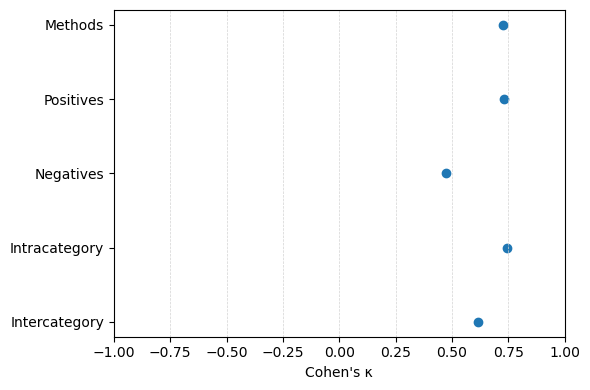

In [239]:
plot_kappa = kappa_table.copy()
plot_kappa = plot_kappa.set_index("Test")

fig, ax = plt.subplots(figsize=(6, 4))

y_pos = range(len(plot_kappa))

ax.scatter(plot_kappa["Kappa"], y_pos)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_kappa.index)
ax.set_xlabel("Cohen's κ")
ax.set_xlim(-1, 1.0)

for tick in ax.get_xticks():
    if tick >= ax.get_xlim()[0] and tick <= ax.get_xlim()[1]:
        ax.axvline(tick, color="lightgray", linestyle="--", linewidth=0.5, zorder=1)

ax.invert_yaxis() 

plt.tight_layout()
plt.show()
